# System-Level SerDes Modeling and Simulation: A Comprehensive Guide

## Welcome! 🎓

This notebook provides a complete educational resource for understanding modern high-speed serial link receivers, focusing on **PAM4 modulation** and advanced **equalization techniques** used in 100G/200G/400G Ethernet, PCIe, and optical systems.

---

## 📚 What You'll Learn

This notebook covers the **complete receiver signal processing chain**:

1. **Intersymbol Interference (ISI)** - Understanding the problem
2. **Feed-Forward Equalization (FFE)** - Linear pre-distortion with LMS adaptation
3. **Adaptive Noise Reduction** - Adaptive threshold tracking in PAM4 slicing
4. **Maximum Likelihood Sequence Estimation (MLSE)** - Optimal sequence recovery via Viterbi
5. **Adaptive Slicer (AS)** - Real-time PAM4 slicing
6. **SNR Evaluation** - Continuous link quality monitoring
7. **LMS Algorithm** - The workhorse adaptation algorithm
8. **Hybrid Receivers** - Combining multiple techniques
9. **Digital Pre-Distortion** - Transmit-side linearization

---

## 🎯 Learning Objectives

By the end of this notebook, you will:

✅ **Understand** fundamental concepts in high-speed link design  
✅ **Analyze** trade-offs between different equalization approaches  
✅ **Implement** core DSP algorithms in Python  
✅ **Evaluate** receiver performance through simulation  
✅ **Design** adaptive systems for varying channel conditions  
✅ **Estimate** bit error rates from signal statistics  

---

## 🏗️ Receiver Architecture Overview

```
                          Receiver Signal Processing Chain
┌─────────────────────────────────────────────────────────────────┐
│  Analog RF/IF                                                   │
│        │                                                        │
│        ▼                                                        │
│    ┌──────────┐                                                 │
│    │   ADC    │  (Analog-to-Digital Converter)                  │
│    └────┬─────┘                                                 │
│         │                                                       │
│         ▼                                                       │
│    ┌──────────────────────┐                                     │
│    │  FFE + Adaptive LMS  │  (Feed-Forward Equalization)        │
│    │  - Pre-cursor taps   │  - Linear ISI mitigation            │
│    │  - Cursor tap        │  - Noise shaping                    │
│    │  - Post-cursor taps  │                                     │
│    └────┬─────────────-───┘                                     │
│         │                                                       │
│         ▼                                                       │
│    ┌──────────────────────┐                                     │
│    │   Adaptive Slicer    │  (Threshold Decision)               │
│    │ - Adaptive thresholds│  - Real-time adaptation             │
│    │ - Noise Reduction    │  - PAM4 level tracking              │
│    └────┬───────────────-─┘                                     │
│         │                                                       │
│         ▼                                                       │
│    ┌──────────────────────┐                                     │
│    │   MLSE / DFE Block   │  (Sequence Estimation)              │
│    │  - Viterbi algorithm │  - Optimal sequence recovery        │
│    │  - Error correction  │                                     │
│    └────┬─────────-───────┘                                     │
│         │                                                       │
│         ▼                                                       │
│    ┌──────────────────────┐                                     │
│    │   FEC Decoder        │  (Error Correction)                 │
│    │  - LDPC / Turbo      │  - Final data recovery              │
│    └─────┬────────────────┘                                     │
│           │                                                     │
│           ▼                                                     │
│      Recovered Data                                             │
│                                                                 │
│      ◄─ SNR Monitor, Eye Analyzer, Adaptive Control ─────┐     │
│                                                          │     │
│      Feedback for FFE Gains, AS Thresholds, etc. ◄───-───┘     │
└─────────────────────────────────────────────────────────────────┘
```

---

## 💡 How to Use This Notebook

### **For Learners (First Time)**:
1. Read each section carefully, understanding the concepts
2. Run the code cells to see demonstrations
3. Modify parameters and observe changes
4. Complete the self-check questions (coming soon)

### **For Instructors**:
1. Use complete sections as lecture material
2. Run live demonstrations in class
3. Assign homework: modify code, answer questions
4. Use plots in presentations

### **For Researchers**:
1. Reference mathematical derivations
2. Use code templates for your own systems
3. Adapt examples to your specific channels
4. Extend with new algorithms

### **For Engineers**:
1. Use as design reference guide
2. Benchmark algorithms against your systems
3. Prototype new approaches
4. Validate implementations

---

## 🔧 Prerequisites & Setup

**Required Knowledge**:
- Basic signal processing (convolution, Fourier transform)
- Linear algebra (matrices, eigenvalues)
- Probability and statistics (Gaussian distributions, Q-function)
- Python programming basics

**Required Libraries**:
- `numpy` - Numerical computation
- `matplotlib` - Visualization
- `scipy` - Special functions and statistics

**Installation**:
```bash
pip install numpy matplotlib scipy
```

---

## 📊 Key Concepts at a Glance

| Concept | Purpose | Complexity |
|---------|---------|-----------|
| **FFE** | Linear pre-distortion | Low |
| **LMS** | Adaptive filter updates | Low-Medium |
| **NR** | Adaptive thresholding | Medium |
| **MLSE** | Optimal sequence recovery | High |
| **AS** | Adaptation | Medium-High |
| **SNR** | Link quality monitoring | Low-Medium |
| **DPD** | Transmit linearization | Medium-High |
| **BER** | Error rate prediction | Low-Medium |

---

## 🎓 Recommended Reading Order

**Beginner Path**:
1. ISI ➜ FFE ➜ SNR Evaluation ➜ BER Estimation

**Intermediate Path**:
1. FFE ➜ NR ➜ LMS ➜ AS ➜ MLSE

**Advanced Path**:
1. All core concepts ➜ Hybrid Architectures ➜ DPD ➜ System Design

**Deep Dive**:
1. Complete notebook sequentially
2. Modify code experiments
3. Design custom systems

---

## 📝 Notation & Conventions

Throughout this notebook:
- **Bold lowercase** ($\mathbf{x}$) = vectors
- **Bold uppercase** ($\mathbf{H}$) = matrices
- $[n]$ = discrete time index
- $*$ = convolution operator
- $E[\cdot]$ = expectation operator
- $\approx$ = approximation
- $\propto$ = proportional to

---

## ⚙️ Simulation Philosophy

All code examples follow a consistent structure:

1. **Parameter Definition** - Clear, tunable values
2. **Signal Generation** - Realistic models
3. **Algorithm Implementation** - Step-by-step code
4. **Performance Analysis** - Comprehensive metrics
5. **Visualization** - Multiple perspectives
6. **Validation** - Correctness checks

This makes examples **easy to understand, modify, and extend**.

---

## 🚀 Getting Started

Ready to dive in? **Scroll down to Section 1: Intersymbol Interference** to begin!

Good luck! 🎯


## 1. Intersymbol Interference (ISI)

### Definition
Intersymbol interference (ISI) is signal distortion where transmitted symbols leak energy into neighboring symbol periods, causing them to overlap and interfere with each other. This fundamental problem limits the achievable data rates and signal integrity in digital communication systems.

### Root Causes
ISI arises from several sources:

1. **Bandlimited Channels**: Real-world channels (cables, fiber, wireless) act as low-pass filters, smearing pulse edges and extending symbols in time
2. **Multipath Propagation**: Signals taking different paths experience different delays, creating echoes that overlap with current symbols
3. **Nonlinear Distortion**: Amplifiers and mixers introduce harmonics and cross-modulation that spreads energy across time
4. **Timing Uncertainty**: Jitter in the sampling clock causes misalignment between symbol boundaries
5. **Reflections**: Impedance discontinuities in transmission lines cause reflections that arrive delayed

### Impact on Communication Systems
- **Reduced Signal Margin**: ISI acts like noise, degrading the effective SNR by overlapping unwanted symbols
- **Increased Bit Error Rate (BER)**: Incorrect symbol decisions occur more frequently as constellations blur
- **Constraint on Data Rate**: Nyquist's theorem shows we cannot exceed 2× the bandwidth with ISI; practical systems use raised-cosine shaping
- **Threshold Ambiguity**: Multiple threshold positions may give similar error rates, making optimal slicing difficult

### Standard Mitigation Techniques
The following techniques are used individually or in combination:

1. **Pulse Shaping**
   - Use Nyquist or raised-cosine filters to limit bandwidth and prevent overlap
   - Root-raised-cosine (RRC) is common in practical transceivers
   - Roll-off factor (0 to 1) trades bandwidth efficiency against slope steepness

2. **Linear Equalization**
   - **Feed-Forward Equalizer (FFE)**: Applies inverse frequency response before slicing
   - **Zero-Forcing Equalizer**: Forces channel response to Dirac delta (aggressive, boosts noise)
   - **Minimum Mean Square Error (MMSE)**: Optimal for Gaussian noise, balances noise amplification

3. **Decision Feedback Equalization (DFE)**
   - Uses past (correct) decisions to cancel ISI from previous symbols
   - More powerful than FFE alone, especially for channels with severe ISI
   - Requires clean decisions; error propagation is a concern

4. **Maximum Likelihood Sequence Estimation (MLSE)**
   - Viterbi algorithm searches for the most probable symbol sequence given the received signal
   - Optimal for discrete alphabets (PAM4, QPSK) with known channel
   - High complexity but powerful for severe ISI channels

5. **Adaptive Slicing and Threshold Tracking**
   - Continuously monitor signal statistics to optimize decision thresholds
   - Adapt to slow drift (temperature, aging) and fast changes (noise bursts)
   - Essential for multi-level modulation like PAM4

6. **Channel Coding**
   - Error-correcting codes (Turbo, LDPC, convolutional) recover information despite some symbol errors
   - Often combined with equalization as a final defense against ISI


## 2. Feed-Forward Equalization (FFE)

### Concept
Feed-Forward Equalization is a linear equalization technique that applies a finite impulse response (FIR) filter to the received signal. The goal is to approximate the inverse of the channel's frequency response, thereby undoing the channel's distortion.

#### Mathematical Foundation
The FFE filter is described by:
$$y[n] = \sum_{k=0}^{N_{\text{taps}}-1} w_k \cdot x[n-k]$$

Where:
- $x[n]$ = input signal (received symbols with ISI)
- $w_k$ = tap weights (filter coefficients)
- $y[n]$ = equalized output signal
- $N_{\text{taps}}$ = number of taps (filter length)

**Tap Structure:**
- **Cursor tap** ($k=0$ or middle): Amplifies the main symbol pulse
- **Pre-cursor taps** ($k > 0$): Cancel ISI from future symbols (ahead)
- **Post-cursor taps** ($k < 0$, or conceptually): Cancel ISI from past symbols (before)

In practice, we often arrange taps as:
$$y[n] = w_{-L} x[n+L] + \cdots + w_0 x[n] + \cdots + w_M x[n-M]$$

Where $L$ pre-cursor taps look ahead and $M$ post-cursor taps look back.

### Advantages and Limitations

**Advantages:**
- Simple, linear structure with low complexity
- Easily parallelized for high-speed implementations
- Fast adaptation using LMS or other simple algorithms
- No error propagation (unlike DFE)

**Limitations:**
- Amplifies noise, especially at frequencies where channel gain is low
- Pre-cursor taps require future samples (adds latency or requires lookahead)
- Cannot handle channels with severe nulls in the frequency response
- May be suboptimal for highly nonlinear channels

### Why Iterative/Adaptive?
In real systems, the channel is unknown or time-varying. Adaptive FFE uses algorithms like **Least Mean Squares (LMS)** or **Recursive Least Squares (RLS)** to continuously update tap weights by:
1. Observing the error between desired and actual output
2. Adjusting weights in the direction that minimizes mean square error
3. Repeating until convergence

This adaptive behavior allows FFE to:
- Operate without prior channel knowledge
- Track slow changes (temperature drift, cable aging)
- Respond to moderate disturbances (reflections, EMI)


## 3. Noise Reduction and Decision Thresholding

### Concept
The **Noise Reduction** is an adaptive threshold circuit that converts the continuous equalized signal into discrete symbol decisions. Unlike a simple fixed-threshold comparator, it continuously adapts its decision thresholds based on real-time noise and ISI estimates.

### Why Adaptive Thresholds Matter
In ideal conditions, a fixed threshold at zero works well. However, real systems suffer from:
- **Thermal noise fluctuations**: Noise statistics change over time
- **ISI residuals**: Equalization cannot perfectly eliminate all ISI; residual ISI shifts the signal baseline
- **DC offset drift**: Temperature and aging cause DC offsets in the receiver chain
- **Crosstalk and jitter**: Nearby signals and timing errors corrupt symbol boundaries

Traditional slicers use fixed thresholds, leaving performance on the table.

### Architecture
A typical module includes:
1. **Window-based statistics**: Compute mean and variance in a sliding window
2. **Noise estimation**: Track local noise levels ($\sigma$)
3. **Threshold computation**: Adapt thresholds based on signal characteristics
4. **Feedback loop**: Use past decisions to refine thresholds for the future

#### Mathematical Formulation
For binary symbols ($d = \pm 1$), the optimal threshold under Gaussian noise is:
$$\text{threshold} = \frac{\mu_+ + \mu_-}{2} + \frac{\sigma_+^2 - \sigma_-^2}{2(\mu_+ - \mu_-)}$$

For PAM4 ($\pm 3, \pm 1$), we need three thresholds:
$$t_0 = \frac{\mu_0 + \mu_1}{2}, \quad t_1 = \frac{\mu_1 + \mu_2}{2}, \quad t_2 = \frac{\mu_2 + \mu_3}{2}$$

Where $\mu_i$ is the mean and $\sigma_i$ is the standard deviation of symbol level $i$.

### Relationship to DFE and MLSE
- It often follows FFE as a preprocessing stage before DFE or MLSE
- It reduces noise before sequence estimation, improving overall BER
- Its output feeds into FEC blocks for final error correction


## 4. Maximum Likelihood Sequence Estimation (MLSE)

### Concept
Maximum Likelihood Sequence Estimation is a powerful decoding algorithm that finds the most probable transmitted symbol sequence given the observed received signal and known channel characteristics. Unlike symbol-by-symbol detection, MLSE considers entire sequences, enabling optimal decisions under ISI.

### Mathematical Foundation
The goal is to find the sequence $\hat{\mathbf{d}}$ that maximizes the likelihood:
$$\hat{\mathbf{d}} = \arg\max_{\mathbf{d}} P(\mathbf{r} | \mathbf{d}, \mathbf{h})$$

Where:
- $\mathbf{r}$ = received signal vector
- $\mathbf{d}$ = transmitted symbol sequence
- $\mathbf{h}$ = known or estimated channel impulse response

For Gaussian noise, this is equivalent to minimizing the squared error:
$$\hat{\mathbf{d}} = \arg\min_{\mathbf{d}} \left\| \mathbf{r} - \mathbf{h} \ast \mathbf{d} \right\|^2$$

### The Viterbi Algorithm
A brute-force search over all $M^N$ possible sequences is exponential. Instead, **Viterbi algorithm** uses **dynamic programming** to efficiently find the optimal sequence in polynomial time.

#### Key Concepts:
1. **States**: Each state represents the history of recent symbols (limited to channel memory)
2. **Trellis**: A graph showing all possible state transitions at each time step
3. **Branch Metric**: Cost of transitioning between states, based on received signal match
4. **Path Metric**: Cumulative cost of a sequence up to time $n$
5. **Traceback**: After forward pass, backtrack to find the best path

#### Algorithm Steps:
1. Initialize: Set initial state metrics to 0 (start state) or $-\infty$ (other states)
2. Forward Pass: For each received symbol, compute branch and path metrics for all transitions
3. Prune: Keep only the best path reaching each state (maximum $M^L$ paths, where $L$ is memory length)
4. Traceback: After all symbols processed, follow best path backward to recover the sequence

### Performance and Trade-offs

**Advantages:**
- **Optimal**: Minimizes sequence error probability given channel knowledge
- **No error propagation**: Sequence-level decision corrects individual symbol errors
- **Works with severe ISI**: Can handle channels that defeat linear equalization

**Disadvantages:**
- **High complexity**: $O(N \times M^{2L})$ where $L$ is channel memory and $M$ is alphabet size
- **Latency**: Requires buffering and backward traceback
- **Channel estimation required**: Performance depends on accurate channel model
- **Latency**: Traceback requires storing state metrics for entire sequence

### Practical Considerations
- Used in optical transceivers, DSL, and wireless systems with severe ISI
- Often combined with FEC codes and turbo-equalization for iterative refinement
- Truncation (finite window) reduces latency at slight performance cost


## 5. Adaptive Slicer

### Concept
The Adaptive Slicer is a refined thresholding component that continuously monitors the received signal to update decision thresholds in real time. It's essential for PAM4 and higher-order modulation schemes where the distance between constellation points is small and margins are tight.

### Why Adaptation?
Fixed thresholds fail to account for:
- **Slow drift**: Temperature fluctuations, component aging, power supply ripple
- **Fast transients**: Crosstalk bursts, mode hopping, noise spikes
- **Asymmetric noise**: Different noise levels on rising vs falling transitions
- **Eye asymmetry**: Some PAM4 eyes are naturally closer than others

### Key Components 

1. **Signal Statistics Computation**
   - Track the mean ($\mu_i$) and variance ($\sigma_i^2$) for each symbol level
   - Use exponential averaging for fast response: $\mu_{n+1} = \alpha \mu_n + (1-\alpha) x_n$
   - Adapt window size based on SNR

2. **Threshold Calculation**
   - For PAM4: three thresholds between four levels
   - Optimal threshold under Gaussian noise:
   $$t_{i,i+1} = \frac{\mu_i + \mu_{i+1}}{2} + \frac{\sigma_{i+1}^2 - \sigma_i^2}{2(\mu_{i+1} - \mu_i)}$$

3. **Feedback Integration**
   - Use FEC syndrome information to detect misthresholded symbols
   - Adjust thresholds to reduce burst errors
   - Integrate with DFE or MLSE decisions for improved accuracy

4. **Jitter and Timing Compensation**
   - Track sampling phase to compensate for clock jitter
   - Adjust threshold timing windows dynamically
   - Integrate with CDR (Clock and Data Recovery) loop

### Practical Implementation Details
- **Memory requirement**: Per-level statistics (mean, variance, count) → typically 4×3 words per lane
- **Update rate**: Once per symbol or batch of symbols (configurable)
- **Convergence**: Typically 100-1000 symbols for steady state
- **Latency**: 1-10 symbol periods depending on window size and filtering


## 7. Least Mean Squares (LMS) Adaptation Algorithm

### Concept
LMS is an iterative algorithm for updating filter coefficients to minimize mean square error. It's the workhorse of adaptive equalization, used in FFE, DFE, and echo cancellation systems worldwide.

### Mathematical Foundation
**Goal**: Minimize the cost function
$$J(w) = E[|e_n|^2] = E[|d_n - w^T x_n|^2]$$

Where:
- $d_n$ = desired signal
- $x_n$ = input vector
- $w$ = filter weights
- $e_n = d_n - w^T x_n$ = error

**LMS Update Rule**:
$$w_{n+1} = w_n + \mu \cdot e_n \cdot x_n$$

Where:
- $\mu$ = step size (learning rate)
- $e_n \cdot x_n$ = gradient estimate

### Key Properties

**Convergence**:
- LMS converges in mean if: $0 < \mu < \frac{2}{\lambda_{\max}}$
- Where $\lambda_{\max}$ is the largest eigenvalue of autocorrelation matrix $R_x$
- Practical rule: $\mu = \frac{1}{10 \cdot \text{trace}(R_x)}$

**Complexity**:
- Per-update: $O(N_{\text{taps}})$ multiplications and additions
- Very low complexity compared to RLS (which is $O(N^2)$)

**Trade-offs**:
- **Fast convergence**: Requires high $\mu$ (larger step size)
- **Steady-state accuracy**: Requires small $\mu$ (smoother convergence)
- **Misadjustment**: LMS overshoots optimal solution; excess MSE is proportional to $\mu$

### Practical Considerations

1. **Step Size Selection**
   - Too large: Instability, oscillation around solution
   - Too small: Slow convergence, may not track changing channels
   - Adaptive step size: Vary $\mu$ based on convergence rate

2. **Tap Initialization**
   - Zero initialization: Simple, requires longer convergence
   - Channel-estimated: Faster convergence if good estimate available
   - Impulse response: Start with cursor tap = 1, others = 0

3. **Error Signal Source**
   - **Training mode**: Use known training sequence
   - **Decision-directed**: Use slicer output (risk of error propagation)
   - **Hybrid**: Switch from training to decision-directed

4. **Numerical Stability**
   - Use double precision to avoid accumulation errors
   - Normalize input or gradient to prevent overflow
   - Periodic reinitialization if drift occurs

### Variants

- **Normalized LMS (NLMS)**: Adaptive step size $\mu_n = \frac{\mu}{|x_n|^2}$ → better robustness
- **Signed Error LMS**: Use $\text{sign}(e_n)$ instead of $e_n$ → lower complexity
- **Data Reuse LMS**: Multiple updates per sample → faster convergence


## LMS 
LMS (Least Mean Squares) is a widely used adaptive filtering algorithm that updates filter coefficients to minimize the mean square error between a desired signal and the filter output. It’s simple, efficient, and forms the backbone of many real-time equalization and noise cancellation systems.

### Core Concept
LMS adjusts the filter weights \mathbf{w} iteratively using:
\mathbf{w}_{n+1} = \mathbf{w}_n + \mu \cdot e_n \cdot \mathbf{x}_n

Where:
- \mathbf{x}_n: input vector at time n
- e_n = d_n - \mathbf{w}_n^\top \mathbf{x}_n: error between desired output d_n and filter output
- \mu: step size (learning rate)

### Applications
- Adaptive equalization (FFE, DFE)
- Noise cancellation
- Echo suppression
- Beamforming
- Channel estimation


## 8. Hybrid Receiver: LMS + MLSE

### Motivation for Hybrid Equalization
While FFE+LMS is simple and fast, it cannot perfectly mitigate severe ISI channels. Combining LMS-based preprocessing with MLSE provides:
- **LMS preprocessing**: Reduces ISI before sequence estimation, lowering Viterbi state count and complexity
- **MLSE optimal recovery**: Finds the best sequence despite residual ISI and noise
- **Reduced complexity**: Smaller trellis (fewer states) than pure MLSE
- **Robustness**: Handles channels that defeat linear equalization alone

### Architecture
```
Received Signal → FFE (LMS-adapted) → MLSE Viterbi → Decoded Symbols
                                    ↓
                            Channel Estimate
```

### Trade-offs
- **Complexity**: Moderate (LMS + small-state Viterbi)
- **Latency**: Low (FFE is online, Viterbi uses windowed traceback)
- **Performance**: Near-optimal for moderate-to-severe ISI
- **Implementation**: Easier than pure MLSE; practical for real systems

### When to Use
- High-speed serial links with ~3-5 tap ISI channels
- When FFE alone doesn't meet BER targets
- When pure MLSE (large alphabet×long memory) is too complex
- Optical receivers with deterministic ISI profiles


## 9. Digital Pre-Distortion (DPD) - Transmit Side Linearization

### Concept
**Digital Pre-Distortion (DPD)** is a signal processing technique applied at the transmitter to linearize power amplifier distortion. By pre-distorting the input signal, the combined effect of DPD + PA approximates an ideal linear amplifier.

### Why DPD Matters
Power amplifiers (PAs) are inherently nonlinear, especially near saturation. This causes:

1. **AM-AM Distortion**: Output amplitude is not proportional to input
2. **AM-PM Distortion**: Output phase shifts nonlinearly with input amplitude
3. **Spectral Regrowth**: Out-of-band emissions increase, violating spectral masks
4. **EVM Degradation**: Error vector magnitude increases with modulation density

### Mathematical Model
**Behavioral PA Model** (Memory Polynomial):
$$y[n] = \sum_{k=1}^{K} \sum_{m=0}^{M} a_{k,m} \cdot x[n-m] \cdot |x[n-m]|^{k-1}$$

Where:
- $x[n]$ = input signal
- $y[n]$ = PA output
- $a_{k,m}$ = model coefficients (nonlinearity order $k$, memory tap $m$)
- $K$ = nonlinearity order (typically 3-5)
- $M$ = memory depth (typically 2-10)

**DPD Inverse Model**:
$$x_{\text{predistorted}}[n] = \text{Inverse}(y_{\text{desired}}[n])$$

The DPD adapts its coefficients using LMS or other algorithms to minimize error:
$$e[n] = y_{\text{desired}}[n] - \text{PA}(\text{DPD}(x[n]))$$

### Practical Implementation
1. **Model Identification**: Capture PA input/output, fit behavioral model
2. **Inverse Derivation**: Derive DPD coefficients from PA model
3. **Closed-Loop Adaptation**: Measure PA output, update DPD using feedback
4. **Convergence**: Typically 100-1000 samples for steady-state

### Applications
- 5G base station transmitters (multicarrier, high peak-to-average power ratio)
- Satellite and microwave links
- Wi-Fi and LTE modems
- Phased-array radar systems
- Software-Defined Radios (SDRs)

### DPD vs Linear Amplification
- **With DPD**: Allows higher PA efficiency (deeper saturation), meets spectral mask
- **Without DPD**: Must back off from saturation, wastes power, higher cost


## 10. BER Estimation from Signal Histograms

### Concept
Instead of waiting for actual bit errors to accumulate (which requires very long measurement times), we can **estimate BER statistically** from the histogram of received or equalized symbols. This is much faster and forms the basis of real-time link health monitoring in transceivers.

### Method: Histogram-Based BER Estimation

**Principle**:
1. Collect received or equalized signal samples
2. Build a histogram (probability distribution)
3. Fit Gaussian models to each symbol level cluster
4. Estimate symbol error probability by integrating tail areas beyond decision thresholds
5. Convert to BER using the bit-to-symbol mapping (e.g., Gray code for PAM4)

### Gaussian Tail Integration
For each symbol level with mean $\mu_i$ and variance $\sigma_i^2$:
$$P_{\text{error}, i} = Q\left(\frac{t_{i,i+1} - \mu_i}{\sigma_i}\right)$$

Where:
- $t_{i,i+1}$ = decision threshold between levels $i$ and $i+1$
- $Q(x) = \frac{1}{2}\text{erfc}(x/\sqrt{2})$ = complementary error function
- $P_{\text{error}, i}$ = probability that level $i$ crosses its threshold

### PAM4 to BER Conversion
For PAM4 with Gray coding (00, 01, 11, 10 → -3, -1, +1, +3):
- Each symbol carries 2 bits
- Symbol error doesn't always cause bit error (Gray code minimizes bit flips)
- Typical relationship: $\text{BER} \approx 0.5 \times \text{SER}$ for adjacent-only errors

**Better approximation** (considering all eye pairs):
$$\text{BER} = \frac{1}{2} \sum_{i=0}^{2} P_{\text{error},i}$$

### Implementation Notes
- **Resolution**: Histogram resolution must be fine enough to resolve all levels
- **Sample count**: Need ~1000 symbols per level for reasonable statistics
- **Noise model**: Assumes Gaussian noise; works well for thermal noise
- **Accuracy**: Valid for BER down to ~10^-5; below that, tail extrapolation becomes unreliable


## Clock and Data Recovery (CDR)
In CDR systems, especially for hight-speed serial links, a loop filter (LF) and a phase interpolator (PI) work together to align the sampling clock with incoming data.
### Phase Interpolator (PI)
- A PI generates a clock signal with a precise phase shift by interpolating between two or more refernce clock phase (e.g., in-phase and quadrature)
- It is digitally controlled and used to fine tune the sampling point of the data.
- Common in half-rate CDRs, where the PI adjusts the phase of a 2x clock to align with data transitions.
### Loop Filter
- The LP processes the output of the phase detetctor (which compares the phase of the incoming data and the sampling clock).
- Can be analog (in analog CDRs) or digital (in digital CDRs), and often includes proportional-integral (PI) control to balance responsiveness and stability.
- The LP determines how the CDR responds to phase errors. It must balance speed and stability.
    - Loop Bandwidth
       - Wider bandwidth =  faster lock time, but more jitter.
       - Narrower bandwidth = better jitter filtering, but slower response.
    - Damping Factor
       - Controls overshoot and settling time.
       - Typically set between 0.5 and 1 for critical damping.
    - Filter Type
       - Proportional-Integral (PI) filters are common
       - Some systems use adaptive filters to adjust bandwidth dynamically. 
- Adaptive Loop Filter (ALF)
    - Uses a Proportional_integral (PI) controller to adjust the clock phase.
    - The gain (kp and ki) are dynamically adjusted based on the magnitude of the phase error.
    - This allows the loop to:
        - React quickly to large errors (e.g., during acquisition)
        - Stabilizes and supress jiter when the error is small.
- Mueller and Muller (M&M) Clock Recovery
    - A data-directed method that uses symbol decisions to estimate timing error.
    - Based on the differnce between current and previous samples, multiplied by the previous symbol decision.
    - Does not require an explicit phase detector - works well in digital receivers.

### How They Work Together
- Phase Detector (PD) detects timing error between data and clcok.
- Loop Filter filters the error signal to reduce jitter and noise.
- Phase Interpolator adjusts the clock phase based on the filtered signal.
- The system interatively aligns the clock to the optimal sampling point. 
- The Phase Interpolator (PI) adjusts the sampling clock phase with high resolution.
    - Phase Resolution
        - Determines how finely the clock phase can be adjusted.
        - Higher Resolution =  Better timing accuracy
    - Linearity
        - Nonliner phase steps can introduce jitter and degrade perfromance.
    - Power Consumption
        - Important in high-speed, low-power applications (e.g., SerDes).
    - Speed
        - Must respond quickly to control signals from the loop filter.
### System-Level Considerations
- Interaction Between Loop Filter and PI:
    - The Loop Filter output must match the PI input range and resolution.
    - Quantization Noise from digital control can affect jitter perfromance.
    - Latency in the loop (e.g., from digital processing) must be minimized.
### Environmental Factors
- Process, Voltage, Temprature (PVT) variations affect analog components.
- Data Pattern Dependence (e.g., long runs of 0s and 1s) can stress the loop.



## Summary: Core Receiver Building Blocks

### Key Concepts Review
We've now covered the fundamental DSP building blocks for modern high-speed serial receivers:

1. **FFE (Feed-Forward Equalizer)**
   - Linear pre-cursor/post-cursor filter to undo channel distortion
   - Adapted via LMS; simple but can amplify noise

2. **Noise Reduction (NR)**
   - Adaptive threshold tracking for robust symbol decisions
   - Reduces noise impact before MLSE/DFE

3. **MLSE (Maximum Likelihood Sequence Estimation)**
   - Optimal decoder for ISI channels using Viterbi algorithm
   - Powerful but complex; used when FFE insufficient

4. **Adaptive Slicer**
   - Real-time threshold adaptation for PAM4
   - Compensates for drift and noise variations

5. **SNR Evaluation**
   - Continuous monitoring of link quality
   - Drives adaptive decisions for FFE gains, slicer offsets

6. **LMS Algorithm**
   - Workhorse adaptation algorithm across all blocks
   - Trade-off between convergence speed and steady-state accuracy

### Integration in Real Receivers
A typical receiver chain combines these blocks:
```
RF/Analog → ADC → FFE + AS → NR → MLSE/DFE → FEC Decoder → Data
                ↑                                      ↑
                └─ SNR/Eye Monitor → Control & Adaptation ────┘
```

### Next Steps in Your Learning
- Implement DFE (Decision Feedback Equalizer) for better ISI cancellation
- Study blind equalization (without training sequences)
- Explore turbo-equalization and soft-output algorithms
- Implement PAM4 specific eye diagram analysis


## 1. Channel Modelling
This ChModel class provides a set of methods to model and analyze various transmission line characteristics and components.

Summary of Methods
   - rlgc: Computes the S-parameter matrix for a transmission line given the R, L, G, and C parameters, length, and frequency array.
   - impedance: Computes the S-parameter matrix for a 2-port network with a given impedance, which can be frequency-dependent.
   - admittance: Computes the S-parameter matrix for a 2-port network with a given shunt admittance, which can be frequency-dependent.
   - shunt_cap: Computes the S-parameter matrix for a 2-port network with a shunt capacitance specified at complex frequencies.
   - series_cap: Computes the S-parameter matrix for a 2-port network with a series capacitance specified at complex frequencies.
   - series: Combines multiple 2-port networks in series to get the overall ABCD parameters.
   - freq2impulse: Converts a frequency response to its corresponding impulse response, assuming a linearly spaced frequency array.
   - sparam: Computes the ABCD matrix for a 2-port network given its S-parameters, characteristic impedance, and frequency array.
   - zero_pad: Pads a discrete-time transfer function with zeros to meet a desired timestep in the time domain, extending the frequency vector accordingly.

In [45]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import ifft

class ChModel:
    """Professional-grade channel modeling system with transmission line and S-parameters.
    
    Comprehensive 2-port network analysis tool implementing:
    - Transmission line theory (RLGC lossy lines with propagation)
    - ABCD matrix cascading for multi-element networks
    - S-parameter ↔ ABCD bidirectional conversion
    - Frequency-to-time domain transformation (IFFT with Hermitian symmetry)
    - Zero-padding for sub-sample time resolution
    
    Architecture
    -----------
    All methods are static (no instance state) for functional composition:
    1. Build component ABCD matrices (rlgc, impedance, admittance, shunt_cap, series_cap)
    2. Cascade components via series() multiplication
    3. Convert to desired representation (S-parameters, impulse response)
    4. Apply zero-padding for desired time resolution
    
    Conventions
    -----------
    - All matrices: Shape (n_frequencies, 2, 2) with dtype complex128
    - Characteristic impedance: Z0 = 50Ω standard (configurable per method)
    - Frequency arrays: Must be linearly spaced for IFFT
    - ABCD normalization: Uses chain parameter convention (voltage/current ratios)
    
    Example
    -------
    >>> f = np.linspace(1e6, 100e9, 801)  # 1 MHz to 100 GHz
    >>> w = 2*np.pi*f
    >>> # Lossy transmission line: 0.1 m length
    >>> tline = ChModel.rlgc(r=0.02, l=4e-8, g=1e-6, c=2e-11, d=0.1, f=f)
    >>> # Add parasitic shunt capacitance at receiver
    >>> cshunt = ChModel.shunt_cap(c=1e-12, w=w)
    >>> # Cascade: line then capacitor
    >>> cascaded = ChModel.series([tline, cshunt])
    >>> # Convert to impulse response
    >>> h, t = ChModel.freq2impulse(cascaded[:, 1, 0], f)
    """
    
    # ─────────────────────────────────────────────────────────────────────────
    # PHYSICAL CONSTANTS
    # ─────────────────────────────────────────────────────────────────────────
    DEFAULT_Z0 = 50.0  # Standard RF impedance [Ω]
    
    @staticmethod
    def rlgc(r, l, g, c, d, f):
        """Calculate ABCD matrix for lossy transmission line via telegrapher's equations.
        
        Solves the frequency-dependent transmission line equations:
        - Propagation: γ(ω) = √[(R + jωL)(G + jωC)]
        - Impedance:   Z₀(ω) = √[(R + jωL)/(G + jωC)]
        - Transmission: e^(-γd)
        
        This represents wave propagation with:
        - R: Conductor loss (frequency-independent)
        - L: Loop inductance (rises with frequency)
        - G: Dielectric loss (frequency-dependent in real materials)
        - C: Distributed capacitance (frequency-independent)
        
        Physical Interpretation
        -----------------------
        The ABCD parameters encode:
        - A, D: Propagation amplitude and phase rotations
        - B: Series impedance transformation
        - C: Shunt admittance transformation
        
        For lossless case (R=G=0): Pure delay with impedance rotation.
        For lossy case: Attenuation + dispersion at high frequencies.
        
        Parameters
        ----------
        r : float
            Series resistance [Ω/m], r ≥ 0
        l : float
            Series inductance [H/m], l > 0
        g : float
            Shunt conductance [S/m], g ≥ 0
        c : float
            Shunt capacitance [F/m], c > 0
        d : float
            Physical length [m], d > 0
        f : np.ndarray
            Frequency points [Hz], shape (n_freq,), must be linearly spaced
            
        Returns
        -------
        abcd : np.ndarray
            ABCD matrix chain parameters, shape (n_freq, 2, 2), dtype complex128
            - Real part: Amplitude response
            - Imaginary part: Phase response
            
        Raises
        ------
        ValueError
            - If d ≤ 0 or f is empty
            - If circuit parameters unphysical (l or c ≤ 0)
            
        Notes
        -----
        For numerical stability:
        - Large d or high losses can create exponentially decaying/growing fields
        - Monitor |e^(-γd)| to detect ill-conditioning
        - Use R_min, G_min for minimum losses in ideal materials
        """
        # Input validation with physical constraints
        if not isinstance(d, (int, float)) or d <= 0:
            raise ValueError(f"Length d must be positive, got d={d}")
        #if not isinstance(l, (int, float)) or l <= 0:
        #    raise ValueError(f"Inductance l must be positive, got l={l}")
        #if not isinstance(c, (int, float)) or c <= 0:
        #    raise ValueError(f"Capacitance c must be positive, got c={c}")
        #if not isinstance(r, (int, float)) or r < 0:
        #    raise ValueError(f"Resistance r must be non-negative, got r={r}")
        #if not isinstance(g, (int, float)) or g < 0:
        #    raise ValueError(f"Conductance g must be non-negative, got g={g}")
        
        f = np.asarray(f, dtype=np.float64)
        if f.size < 1:
            raise ValueError("Frequency array f cannot be empty")
        if f.size < 2:
            raise ValueError("Frequency array f must have at least 2 points for IFFT")
        
        # ─────────────────────────────────────────────────────────────────────
        # COMPUTE PROPAGATION CONSTANT AND IMPEDANCE (VECTORIZED)
        # ─────────────────────────────────────────────────────────────────────
        w = 2.0 * np.pi * f  # Angular frequency [rad/s]
        
        # Series impedance: Z(ω) = R + jωL per unit length
        Z_series = r + 1j * w * l
        
        # Shunt admittance: Y(ω) = G + jωC per unit length
        Y_shunt = g + 1j * w * c
        
        # Propagation constant: γ = √(Z·Y) [Nepers and radians]
        # For numerical stability, compute √(Z·Y) directly (not sqrt(Z)*sqrt(Y))
        ZY = Z_series * Y_shunt
        gamma = np.sqrt(ZY)
        
        # Propagation over length d
        gamma_d = d * gamma
        
        # Characteristic impedance: Z₀ = √(Z/Y)
        Z0 = np.sqrt(Z_series / Y_shunt)
        
        # ─────────────────────────────────────────────────────────────────────
        # COMPUTE HYPERBOLIC FUNCTIONS (NUMERICALLY STABLE)
        # ─────────────────────────────────────────────────────────────────────
        # Use numpy's stabilized sinh/cosh to avoid overflow for large |γd|
        sh = np.sinh(gamma_d)
        ch = np.cosh(gamma_d)
        
        # ─────────────────────────────────────────────────────────────────────
        # BUILD ABCD MATRIX
        # ─────────────────────────────────────────────────────────────────────
        # ABCD parameters for transmission line (symmetric two-port):
        # [V1]   [cosh(γd)   Z0*sinh(γd)    ] [V2]
        # [I1] = [sinh(γd)/Z0  cosh(γd)     ] [I2]
        
        n_freq = f.size
        abcd = np.zeros((n_freq, 2, 2), dtype=np.complex128)
        
        abcd[:, 0, 0] = ch                    # A = cosh(γd)
        abcd[:, 0, 1] = Z0 * sh               # B = Z₀·sinh(γd)
        abcd[:, 1, 0] = sh / Z0               # C = sinh(γd)/Z₀
        abcd[:, 1, 1] = ch                    # D = cosh(γd) (reciprocal)
        
        return abcd
    
    @staticmethod
    def impedance(z):
        """Generate ABCD matrix for lumped series impedance element.
        
        Represents a 2-port with series impedance Z (single node):
        V1 = V2 + Z·I
        I1 = I2 (current conservation)
        
        ABCD form: [A=1, B=Z; C=0, D=1]
        
        Parameters
        ----------
        z : array-like
            Series impedance values [Ω], shape (n_freq,) or scalar
            Can contain frequency-dependent impedance (e.g., from RC model)
            
        Returns
        -------
        abcd : np.ndarray
            ABCD matrix, shape (n_freq, 2, 2), dtype complex128
        """
        z = np.atleast_1d(np.asarray(z, dtype=np.complex128))
        n = z.size
        
        abcd = np.zeros((n, 2, 2), dtype=np.complex128)
        abcd[:, 0, 0] = 1.0      # A
        abcd[:, 0, 1] = z        # B - Series impedance
        abcd[:, 1, 1] = 1.0      # D
        # C = 0 (default)
        
        return abcd
    
    @staticmethod
    def admittance(y):
        """Generate ABCD matrix for lumped shunt admittance element.
        
        Represents a 2-port with shunt admittance Y = 1/Z:
        V1 = V2 (voltage continuity)
        I1 = I2 + Y·V (shunt current)
        
        ABCD form: [A=1, B=0; C=Y, D=1]
        
        Parameters
        ----------
        y : array-like
            Shunt admittance [S], shape (n_freq,) or scalar
            Positive imaginary part ⟹ capacitive (leading current)
            
        Returns
        -------
        abcd : np.ndarray
            ABCD matrix, shape (n_freq, 2, 2), dtype complex128
        """
        y = np.atleast_1d(np.asarray(y, dtype=np.complex128))
        n = y.size
        
        abcd = np.zeros((n, 2, 2), dtype=np.complex128)
        abcd[:, 0, 0] = 1.0      # A
        abcd[:, 1, 0] = y        # C - Shunt admittance
        abcd[:, 1, 1] = 1.0      # D
        # B = 0 (default)
        
        return abcd
    
    @staticmethod
    def shunt_cap(c, w):
        """Generate ABCD matrix for shunt capacitance (parasitic coupling/decoupling).
        
        Frequency-dependent shunt admittance: Y = jωC
        Common in receiver decoupling, interconnect parasitics, and probe loading.
        
        Physical meaning: 
        - Low frequency (ω→0): High impedance (open circuit)
        - High frequency (ω→∞): Low impedance (short circuit)
        
        Parameters
        ----------
        c : float
            Shunt capacitance [F], must be ≥ 0
        w : np.ndarray
            Angular frequencies [rad/s], shape (n_freq,)
            
        Returns
        -------
        abcd : np.ndarray
            ABCD matrix, shape (n_freq, 2, 2), dtype complex128
            
        Notes
        -----
        For receiver decoupling: Provides low-impedance return path at signal frequencies,
        but appears open at DC. Typical values: 100 pF to 1 µF
        """
        w = np.atleast_1d(np.asarray(w, dtype=np.float64))
        c = float(c)
        
        if c < 0:
            raise ValueError(f"Shunt capacitance must be non-negative, got c={c}")
        
        n = w.size
        abcd = np.zeros((n, 2, 2), dtype=np.complex128)
        
        abcd[:, 0, 0] = 1.0             # A
        abcd[:, 1, 0] = 1j * w * c      # C = jωC
        abcd[:, 1, 1] = 1.0             # D
        
        return abcd
    
    @staticmethod
    def series_cap(c, w):
        """Generate ABCD matrix for series capacitance (high-pass filter element).
        
        Frequency-dependent series impedance: Z = 1/(jωC) = -j/(ωC)
        Common in AC coupling, blocking capacitors, and high-pass filters.
        
        Physical meaning:
        - Low frequency (ω→0): High impedance (blocks signal)
        - High frequency (ω→∞): Low impedance (passes signal)
        
        Parameters
        ----------
        c : float
            Series capacitance [F]
        w : np.ndarray
            Angular frequencies [rad/s], shape (n_freq,)
            
        Returns
        -------
        abcd : np.ndarray
            ABCD matrix, shape (n_freq, 2, 2), dtype complex128
            
        Notes
        -----
        For AC coupling: Blocks DC/low-frequency noise, passes signal band
        Typical values: 100 pF to 1 µF depending on corner frequency
        Corner frequency: fc = 1/(2πRC) for RC low-pass
        """
        w = np.atleast_1d(np.asarray(w, dtype=np.float64))
        c = float(c)
        
        if c <= 0:
            raise ValueError(f"Series capacitance must be positive, got c={c}")
        
        n = w.size
        abcd = np.zeros((n, 2, 2), dtype=np.complex128)
        
        abcd[:, 0, 0] = 1.0                  # A
        abcd[:, 0, 1] = -1j / (w * c)        # B = 1/(jωC)
        abcd[:, 1, 1] = 1.0                  # D
        
        return abcd
    
    @staticmethod
    def series(networks):
        """Cascade 2-port networks in series via ABCD matrix multiplication.
        
        For N networks connected in cascade:
        I_total = I_first
        V_total = V_first + V_second + ... + V_last
        
        Result = Network[0] @ Network[1] @ ... @ Network[N-1]
        
        Cascade multiplication (left-to-right):
        Each subsequent network multiplied from the left:
        Result[k+1] = Network[k] @ Result[k]
        
        Parameters
        ----------
        networks : np.ndarray
            Array of ABCD matrices to cascade
            Shape: (n_networks, n_freq, 2, 2), dtype complex128
            
        Returns
        -------
        cascaded : np.ndarray
            Combined ABCD matrix, shape (n_freq, 2, 2), dtype complex128
            
        Raises
        ------
        ValueError
            If networks has < 1 element or wrong shape
            
        Notes
        -----
        Order matters! series([A, B]) ≠ series([B, A]) typically
        
        Example: rlgc → impedance → shunt_cap gives different
        response than shunt_cap → impedance → rlgc
        
        Computational cost: O(N * n_freq) matrix multiplications
        """
        networks = np.asarray(networks, dtype=np.complex128)
        
        # Validate input
        if networks.ndim == 3 and networks.shape[1:] == (2, 2):
            # single network passed as (n_freq,2,2) -> return it
            return networks.copy()
        if networks.ndim == 4:
            pass
        elif isinstance(networks, (list, tuple)):
            # stack list of (n_freq,2,2) arrays
            networks = np.stack(networks, axis=0)
        else:
            raise ValueError(f"Expected 4D array or list of networks, got shape {networks.shape}")
        
        if networks.shape[0] < 1:
            raise ValueError("At least one network required")
        if networks.shape[2] != 2 or networks.shape[3] != 2:
            raise ValueError(f"Expected (..., 2, 2) matrices, got (..., {networks.shape[2]}, {networks.shape[3]})")
        
        # Start with first network
        result = networks[0].copy()
        
        # Left-multiply with each subsequent network (cascade)
        for k in range(1, networks.shape[0]):
            # Efficient matmul for (n_freq, 2, 2) @ (n_freq, 2, 2)
            # NOTE: cascade order preserved: result = result @ networks[k]
            result = np.matmul(result, networks[k])
        
        return result
    
    @staticmethod
    def freq2impulse(H, f):
        """Convert complex frequency response to real impulse response via IFFT.
        
        Key Insight: To get real-valued time-domain signal, frequency response
        must satisfy Hermitian symmetry: H(-f) = conj(H(f))
        
        This function enforces this symmetry by mirroring positive frequencies
        with conjugated values, then applying inverse DFT.
        
        Mathematical Background
        -----------------------
        Forward DFT:  h[n] = (1/N) Σ H[k] exp(j 2π k n / N)
        Inverse DFT:  H[k] = Σ h[n] exp(-j 2π k n / N)
        
        Real-valued signal ⟹ symmetric spectrum: H[N-k] = H*[k]
        
        Time-domain interpretation:
        - Magnitude: Energy/amplitude at each time point
        - Phase: Causality information (typically causal for physical systems)
        
        Parameters
        ----------
        H : np.ndarray
            Complex frequency response, shape (n_freq,), dtype complex128
            - Real part: In-phase (I) component
            - Imaginary part: Quadrature (Q) component
        f : np.ndarray
            Frequency vector [Hz], shape (n_freq,), must be linearly spaced
            - Used only to compute time sampling: t = n / (2 * f_max)
            
        Returns
        -------
        h : np.ndarray
            Real impulse response, shape (N_full,), dtype float64
        t : np.ndarray
            Time vector [s], shape (N_full,)
            - Sample rate: t_s = 1 / f_s where f_s = N_full * df
            
        Notes
        -----
        Assumes f is linearly spaced. For non-uniform f, interpolate first.
        
        Output length: 2·n_freq - 2 (from symmetric extension) → full IFFT length
        """
        H = np.asarray(H, dtype=np.complex128)
        f = np.asarray(f, dtype=np.float64)
        
        # Enforce Hermitian symmetry: mirror frequencies with conjugate
        # H_symmetric = [H_pos, conj(flip(H_pos[1:-1]))]
        H_pos = H
        if H_pos.size < 2:
            # trivial case
            h = np.real(ifft(H_pos))
            t = np.array([0.0])
            return h, t
        
        H_neg = np.conj(H_pos[1:-1][::-1])
        H_full = np.concatenate([H_pos, H_neg])
        
        # Inverse transform: frequency → time
        h_full = np.real(ifft(H_full))
        
        # Compute time vector
        df = f[1] - f[0]
        N = H_full.size
        fs = N * df  # sampling frequency implied by full spectrum
        t = np.arange(N) / fs
        
        return h_full, t
    
    @staticmethod
    def sparam(s11, s12, s21, s22, z0, f):
        """Convert S-parameters to ABCD matrix representation.
        
        Performs standard 2-port S→ABCD transformation using determinant formula.
        
        Equations (with det(S) = S11·S22 - S12·S21):
        ┌─────────────────────────────────────┐
        │ A = (1 + S11 - S22 - det(S)) / (2S21)  │
        │ B = Z₀(1 + S11 + S22 + det(S)) / (2S21) │
        │ C = (1 - S11 - S22 + det(S)) / (2Z₀S21)│
        │ D = (1 - S11 + S22 - det(S)) / (2S21)  │
        └─────────────────────────────────────┘
        
        Why S→ABCD?
        -----------
        - S-parameters: Measured easily with VNAs, frequency-normalized
        - ABCD: Natural for cascading, physical transmission lines
        - Conversion: Required for realistic channel simulations
        
        Parameters
        ----------
        s11, s12, s21, s22 : np.ndarray
            S-parameters [unitless], shape (n_freq,)
            - s11: Input reflection coefficient  
            - s12: Reverse transmission coefficient
            - s21: Forward transmission coefficient  
            - s22: Output reflection coefficient
        z0 : float
            Characteristic impedance [Ω], typically 50Ω
        f : np.ndarray
            Frequency array [Hz], shape (n_freq,)
            (Used only for validation/documentation)
            
        Returns
        -------
        abcd : np.ndarray
            ABCD matrix parameters, shape (n_freq, 2, 2), dtype complex128
            
        Raises
        ------
        ValueError
            If any S21 value is too small (|S21| < 1e-15)
            → Indicates infinite insertion loss / isolated ports
            
        Notes
        -----
        S-parameters must be from same reference impedance z0.
        For mixed impedance systems, convert to common reference first.
        """
        s11 = np.asarray(s11, dtype=np.complex128)
        s12 = np.asarray(s12, dtype=np.complex128)
        s21 = np.asarray(s21, dtype=np.complex128)
        s22 = np.asarray(s22, dtype=np.complex128)
        
        # Check for disconnected ports (infinite insertion loss)
        if np.any(np.abs(s21) < 1e-15):
            idx = np.where(np.abs(s21) < 1e-15)[0]
            freq_val = f[idx[0]] if len(idx) > 0 else "unknown"
            raise ValueError(f"S21 too small at f={freq_val} (disconnected or extremely lossy)")
        
        # Compute determinant and safe reciprocal
        det_S = s11 * s22 - s12 * s21
        s21_inv = 1.0 / (s21 + 1e-30)  # Small epsilon for numerical stability
        
        # Determine output size from max input array
        n_freq = max(s11.size, s12.size, s21.size, s22.size)
        
        abcd = np.zeros((n_freq, 2, 2), dtype=np.complex128)
        abcd[:, 0, 0] = (1 + s11 - s22 - det_S) * s21_inv / 2.0           # A
        abcd[:, 0, 1] = z0 * (1 + s11 + s22 + det_S) * s21_inv / 2.0      # B
        abcd[:, 1, 0] = (1 - s11 - s22 + det_S) * s21_inv / (2.0 * z0)   # C
        abcd[:, 1, 1] = (1 - s11 + s22 - det_S) * s21_inv / 2.0          # D
        
        return abcd
    
    @staticmethod
    def zero_pad(H, f, t_d):
        """Extend frequency response with zero-padding for finer time resolution.
        
        Problem: Limited frequency measurement range ⟹ coarse time resolution
        Solution: Pad frequency response with zeros ⟹ interpolate in time domain
        
        Conceptual Flow
        ---------------
        1. Current max frequency: f_max = f[-1]
        2. Desired max frequency: f_max_desired = 1 / (2 * t_d)  [Nyquist]
        3. If f_max_desired > f_max: Add zeros to extend to f_max_desired
        4. IFFT extended response: Get finer time-domain sampling
        
        Why It Works
        -----------
        Padding with zeros is mathematically equivalent to perfect reconstruction:
        - Extends frequency response as if higher frequencies are truly zero (no energy)
        - Time-domain points become interpolated between original measurement times
        - Resolution improves from 1/f_max to 1/f_max_desired
        
        Limitations
        -----------
        - Cannot create signal energy above original measurement bandwidth
        - Assumes no significant energy >f_max (typical for channel measurements)
        - If t_d too small (f_max_desired >> f_max): Heavy extrapolation, unreliable
        
        Parameters
        ----------
        H : np.ndarray
            Complex frequency response, shape (n_freq,)
        f : np.ndarray
            Frequency vector [Hz], must be linearly spaced, shape (n_freq,)
        t_d : float
            Desired time resolution [s]
            → Implies Nyquist frequency = 1/(2·t_d)
            
        Returns
        -------
        H_pad : np.ndarray
            Zero-padded frequency response, shape (n_freq + n_pad,)
        f_pad : np.ndarray
            Extended frequency vector, shape (n_freq + n_pad,)
        h_0 : np.ndarray
            Impulse response of padded signal
        t_0 : np.ndarray
            Time vector for impulse response
            
        Notes
        -----
        If current Nyquist ≥ desired: No padding → return original data
        """
        H = np.asarray(H, dtype=np.complex128)
        f = np.asarray(f, dtype=np.float64)
        
        # Handle edge cases
        if f.size < 2:
            h_0, t_0 = ChModel.freq2impulse(H, f)
            return H, f, h_0, t_0
        
        # Current frequency resolution and maximum
        f_step = f[1] - f[0]
        f_max = f[-1]
        
        # Desired maximum frequency (Nyquist for time resolution t_d)
        f_max_desired = 1.0 / (2.0 * t_d)
        
        # Check if padding needed
        if f_max_desired <= f_max:
            # Already sufficient resolution
            h_0, t_0 = ChModel.freq2impulse(H, f)
            return H, f, h_0, t_0
        
        # Calculate number of zeros to append
        num_new_pts = int(np.ceil((f_max_desired - f_max) / f_step))
        
        if num_new_pts <= 0:
            h_0, t_0 = ChModel.freq2impulse(H, f)
            return H, f, h_0, t_0
        
        # Create extended vectors
        f_pad = np.linspace(f[0], f_max_desired, H.size + num_new_pts)
        H_pad = np.concatenate([H, np.zeros(num_new_pts, dtype=np.complex128)])
        
        # Compute impulse response of extended signal
        h_0, t_0 = ChModel.freq2impulse(H_pad, f_pad)
        
        return H_pad, f_pad, h_0, t_0

    # -------------------------
    # Analysis helpers & plotting
    # -------------------------
    @staticmethod
    def abcd_to_s21(abcd, z0=DEFAULT_Z0):
        """
        Convert ABCD (n_freq,2,2) to S21 (n_freq,)
        Uses standard 2-port conversion assuming z0 reference.
        """
        A = abcd[:, 0, 0]; B = abcd[:, 0, 1]; C = abcd[:, 1, 0]; D = abcd[:, 1, 1]
        denom = A + B / z0 + C * z0 + D
        # NOTE: small epsilon to avoid division by zero
        s21 = 2.0 / (denom + 1e-30)
        return s21

    @staticmethod
    def plot_freq_response(abcd, f, z0=DEFAULT_Z0):
        """
        Plot S21 magnitude (dB), unwrapped phase and group delay for presentation.
        Returns (mag_db, phase_unwrap, group_delay).
        """
        s21 = ChModel.abcd_to_s21(abcd, z0=z0)
        mag = 20 * np.log10(np.abs(s21) + 1e-20)
        phase = np.angle(s21)
        # group delay
        phase_unwrap = np.unwrap(phase)
        gd = -np.gradient(phase_unwrap, f) / (2 * np.pi)

        fig, axes = plt.subplots(2, 1, figsize=(9, 6))
        axes[0].plot(f / 1e9, mag)
        axes[0].set_ylabel("S21 |dB|")
        axes[0].set_title("Insertion Loss (S21)")
        axes[0].grid(True, alpha=0.3)

        axes[1].plot(f / 1e9, phase_unwrap, label="phase (rad)")
        axes[1].plot(f / 1e9, gd, label="group delay (s)")
        axes[1].set_xlabel("Frequency (GHz)")
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
        return mag, phase_unwrap, gd

    @staticmethod
    def plot_impulse(h, t, zoom_ns=5.0):
        """
        Plot impulse response h(t) vs time t (seconds). Zoom window in ns.
        """
        fig, ax = plt.subplots(1, 1, figsize=(8, 3))
        ax.plot(t * 1e9, h, '-k')
        ax.set_xlabel("Time (ns)")
        ax.set_ylabel("h(t)")
        ax.set_title("Impulse Response")
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        # zoom
        if zoom_ns is not None:
            ax.set_xlim(0, zoom_ns)
        plt.show()

    @staticmethod
    def channel_taps_from_impulse(h, t, samples_per_symbol, n_precursor, n_postcursor):
        """
        Extract symbol-spaced taps around main cursor.
        Returns taps array length n_precursor+1+n_postcursor and time indices.
        """
        # find main cursor index (peak magnitude)
        idx_peak = int(np.argmax(np.abs(h)))
        ts = t[1] - t[0]
        samples_per_symbol_time = int(round(samples_per_symbol))
        # symbol-spaced indices
        indices = idx_peak + np.arange(-n_precursor, n_postcursor + 1) * samples_per_symbol_time
        indices = np.clip(indices, 0, len(h) - 1)
        taps = h[indices]
        return taps, indices


In [3]:
import logging
from datetime import datetime
import sys
import os

try:
    # Jupyter display utilities are optional
    from IPython.display import HTML, display
    _HAS_IPYTHON = True
except Exception:
    _HAS_IPYTHON = False


class SerDesLogger:
    """Educational logging system for SerDes modeling notebook.
    
    Provides clear, formatted output for learning:
    - Section headers with visual separation
    - Parameter logging with units and descriptions
    - Computation tracking with intermediate results
    - Result summaries with physical insights
    """
    
    # ANSI color codes for terminal output
    COLORS = {
        'header': '\033[95m',      # Magenta
        'blue': '\033[94m',        # Blue
        'cyan': '\033[96m',        # Cyan
        'green': '\033[92m',       # Green
        'yellow': '\033[93m',      # Yellow
        'red': '\033[91m',         # Red
        'bold': '\033[1m',         # Bold
        'end': '\033[0m'           # Reset
    }

    # NOTE: default level names: DEBUG < INFO < WARNING < ERROR < CRITICAL
    LEVELS = {'DEBUG': 10, 'INFO': 20, 'WARNING': 30, 'ERROR': 40, 'CRITICAL': 50}

    def __init__(self, to_file=None, level="INFO", use_colors=True, jupyter_mode=False):
        """
        Initialize SerDesLogger.

        Parameters
        ----------
        to_file : str or None
            Optional path to a log file. If provided, messages are appended.
        level : str
            Logging level string: DEBUG, INFO, WARNING, ERROR, CRITICAL.
        use_colors : bool
            Enable ANSI colors when output is a TTY. If False, colors are disabled.
        jupyter_mode : bool
            If True and running inside IPython, use HTML output for nicer notebook rendering.
        """
        # Preserve original behavior: simple print-based logger for notebooks
        self.to_file = to_file
        self.level = self.LEVELS.get(level.upper(), 20)
        # NOTE: auto-disable colors if stdout is not a TTY
        self.use_colors = use_colors and sys.stdout.isatty()
        self.jupyter_mode = jupyter_mode and _HAS_IPYTHON

        # Bridge to Python logging if requested (keeps file handlers consistent)
        self._logger = logging.getLogger("SerDesLogger")
        self._logger.setLevel(self.level)
        if to_file:
            fh = logging.FileHandler(to_file)
            fh.setLevel(self.level)
            fmt = logging.Formatter('%(asctime)s %(levelname)s %(message)s')
            fh.setFormatter(fmt)
            # Avoid duplicate handlers on repeated instantiation
            if not any(isinstance(h, logging.FileHandler) and h.baseFilename == fh.baseFilename
                       for h in self._logger.handlers):
                self._logger.addHandler(fh)

    # Internal helper to format with colors only when enabled
    def _fmt(self, key, text):
        if self.use_colors and key in self.COLORS:
            return f"{self.COLORS[key]}{text}{self.COLORS['end']}"
        return text

    # Internal helper to optionally display HTML in Jupyter
    def _display_html(self, html):
        if self.jupyter_mode and _HAS_IPYTHON:
            display(HTML(html))
        else:
            print(html)

    def header(self, title, level=1):
        """Print formatted section header.
        
        Parameters
        ----------
        title : str
            Section title
        level : int
            Header level (1=major, 2=minor, 3=subsection)
        """
        # Preserve original formatting and comments
        if level == 1:
            if self.jupyter_mode:
                html = f"<div style='font-family:monospace; color:#8a2be2; font-weight:700; margin-top:12px;'><pre>{'='*80}\n  {title.upper()}\n{'='*80}</pre></div>"
                self._display_html(html)
            else:
                print(f"\n{self._fmt('header', self._fmt('bold', ''))}")
                print("=" * 80)
                print(f"  {title.upper()}")
                print("=" * 80)
                print(f"{self._fmt('end', '')}")
        elif level == 2:
            if self.jupyter_mode:
                html = f"<div style='color:#17a2b8; font-weight:700; margin-top:8px;'>>>> {title}</div>"
                self._display_html(html)
            else:
                print(f"\n{self._fmt('cyan', self._fmt('bold', ''))}")
                print(f">>> {title}")
                print(f"{self._fmt('end', '')}")
        else:
            if self.jupyter_mode:
                html = f"<div style='color:#007bff; font-weight:700;'>• {title}</div>"
                self._display_html(html)
            else:
                print(f"\n{self._fmt('blue', self._fmt('bold', '') )}• {title}{self._fmt('end', '')}")

    def param(self, name, value, unit="", description=""):
        """Log parameter with formatted output.
        
        Parameters
        ----------
        name : str
            Parameter name
        value : float, int, or str
            Parameter value
        unit : str
            Unit of measurement
        description : str
            Parameter description/meaning
        """
        # Preserve original formatting and comments
        if isinstance(value, float):
            val_str = f"{value:.6e}"
        else:
            val_str = str(value)
        
        unit_str = f" [{unit}]" if unit else ""
        desc_str = f" - {description}" if description else ""
        line = f"{name:20s}: {val_str:>15s}{unit_str}{desc_str}"
        if self.jupyter_mode:
            html = f"<div style='color:#28a745; font-family:monospace;'>{line}</div>"
            self._display_html(html)
        else:
            print(self._fmt('green', line))
        # Also write to file logger if configured
        if self.to_file:
            self._logger.info(f"PARAM {name} = {val_str}{unit_str} {desc_str}")

    def array_info(self, name, array, description=""):
        """Log array information.
        
        Parameters
        ----------
        name : str
            Array name
        array : ndarray
            NumPy array
        description : str
            Array description
        """
        import numpy as np
        desc_str = f" - {description}" if description else ""
        try:
            arr = np.asarray(array)
            if arr.size == 0:
                info = f"{name:20s}: shape={arr.shape} dtype={arr.dtype} (empty){desc_str}"
            else:
                info = (f"{name:20s}: shape={str(arr.shape):>10s} dtype={str(arr.dtype):>10s} "
                        f"min={np.min(arr):>12.3e} max={np.max(arr):>12.3e}{desc_str}")
        except Exception as e:
            info = f"{name:20s}: <unreadable array> {str(e)} {desc_str}"
        if self.jupyter_mode:
            html = f"<div style='color:#28a745; font-family:monospace;'>{info}</div>"
            self._display_html(html)
        else:
            print(info)
        if self.to_file:
            self._logger.info(f"ARRAY {name} {info}")

    def step(self, description, status="→"):
        """Log operation step.
        
        Parameters
        ----------
        description : str
            Step description
        status : str
            Status indicator
        """
        line = f"{status} {description}"
        if self.jupyter_mode:
            html = f"<div style='color:#ffc107; font-weight:700;'>{line}</div>"
            self._display_html(html)
        else:
            print(f"{self._fmt('yellow', line)}")
        if self.to_file:
            self._logger.info(f"STEP {description}")

    def compute(self, operation, inputs, result=None, explanation=""):
        """Log computation with inputs and result.
        
        Parameters
        ----------
        operation : str
            Operation name
        inputs : dict
            Input parameters {name: value}
        result : any, optional
            Result value/array
        explanation : str
            Explanation of computation
        """
        # Preserve original behavior and comments
        header = f"\n{operation}"
        if self.jupyter_mode:
            html = f"<div style='font-weight:700;'>{header}</div>"
            self._display_html(html)
            html_inputs = "<ul>" + "".join(f"<li><code>{k}: {v}</code></li>" for k, v in inputs.items()) + "</ul>"
            self._display_html(html_inputs)
            if explanation:
                self._display_html(f"<div>{explanation}</div>")
            if result is not None:
                self._display_html("<div style='color:green;'>Result computed ✓</div>")
        else:
            print(f"\n{self._fmt('bold', operation)}")
            print(f"  Inputs:")
            for key, val in inputs.items():
                print(f"    • {key}: {val}")
            if explanation:
                print(f"  {explanation}")
            if result is not None:
                print(f"  Result computed ✓")
        if self.to_file:
            self._logger.info(f"COMPUTE {operation} inputs={inputs} result={'present' if result is not None else 'none'}")

    def success(self, message):
        """Log success message.
        
        Parameters
        ----------
        message : str
            Success message
        """
        line = f"✓ {message}"
        if self.jupyter_mode:
            html = f"<div style='color:#28a745; font-weight:700;'>{line}</div>"
            self._display_html(html)
        else:
            print(f"{self._fmt('green', self._fmt('bold', line))}")
        if self.to_file:
            self._logger.info(f"SUCCESS {message}")

    def warning(self, message):
        """Log warning message.
        
        Parameters
        ----------
        message : str
            Warning message
        """
        line = f"⚠ {message}"
        if self.jupyter_mode:
            html = f"<div style='color:#ffc107; font-weight:700;'>{line}</div>"
            self._display_html(html)
        else:
            print(f"{self._fmt('yellow', self._fmt('bold', line))}")
        if self.to_file:
            self._logger.warning(message)

    def error(self, message):
        """Log error message.
        
        Parameters
        ----------
        message : str
            Error message
        """
        line = f"✗ {message}"
        if self.jupyter_mode:
            html = f"<div style='color:#dc3545; font-weight:700;'>{line}</div>"
            self._display_html(html)
        else:
            print(f"{self._fmt('red', self._fmt('bold', line))}")
        if self.to_file:
            self._logger.error(message)

    def insight(self, text):
        """Log physical/mathematical insight.
        
        Parameters
        ----------
        text : str
            Insight text
        """
        line = f"💡 Insight: {text}"
        if self.jupyter_mode:
            html = f"<div style='color:#17a2b8; font-weight:700;'>{line}</div>"
            self._display_html(html)
        else:
            print(f"\n{self._fmt('cyan', line)}")
        if self.to_file:
            self._logger.info(f"INSIGHT {text}")

    def equation(self, latex_expr, description=""):
        """Log mathematical equation/formula.
        
        Parameters
        ----------
        latex_expr : str
            Mathematical expression
        description : str
            Formula description
        """
        # Preserve original docstring and behavior
        if self.jupyter_mode:
            html = f"<div style='font-weight:700;'>Formula:</div><div><code>{latex_expr}</code></div>"
            if description:
                html += f"<div>{description}</div>"
            self._display_html(html)
        else:
            print(f"\n{self._fmt('bold', 'Formula:')} {latex_expr}")
            if description:
                print(f"  {description}")
        if self.to_file:
            self._logger.info(f"EQUATION {latex_expr} {description}")

    # Convenience methods
    def set_level(self, level):
        """Set logging level at runtime. level is string like 'DEBUG' or numeric."""
        if isinstance(level, str):
            self.level = self.LEVELS.get(level.upper(), self.level)
        else:
            self.level = int(level)
        self._logger.setLevel(self.level)

    def enable_jupyter(self, enable=True):
        """Enable or disable Jupyter HTML mode."""
        if enable and not _HAS_IPYTHON:
            self.warning("IPython not available; jupyter_mode ignored")
            self.jupyter_mode = False
        else:
            self.jupyter_mode = bool(enable)

# Initialize logger
logger = SerDesLogger()
logger.success("Logging system initialized for educational SerDes modeling")


✓ Logging system initialized for educational SerDes modeling


In [4]:
# Basic notebook usage
logger.header("Channel analysis", level=1)
logger.param("samples_per_symbol", 32, unit="samples", description="Oversampling factor")
logger.array_info("freq_vector", np.linspace(0, 50e9, 4096), description="Frequency axis")
logger.step("Computing RLGC ABCD")
logger.compute("rlgc", {"r":0.02, "l":4e-8, "d":0.1}, explanation="Telegrapher equations")
logger.success("ABCD computed")

# File logging
logger_file = SerDesLogger(to_file="run.log", level="INFO")
logger_file.param("snr_db", 20.0, unit="dB")




  CHANNEL ANALYSIS

samples_per_symbol  :              32 [samples] - Oversampling factor
freq_vector         : shape=   (4096,) dtype=   float64 min=   0.000e+00 max=   5.000e+10 - Frequency axis
→ Computing RLGC ABCD

rlgc
  Inputs:
    • r: 0.02
    • l: 4e-08
    • d: 0.1
  Telegrapher equations
✓ ABCD computed
snr_db              :    2.000000e+01 [dB]


## Example Usage
Here is an example of how to use the ChModel class to compute S-parameters and impulse responses:



  TRANSMISSION LINE & COMPONENT S-PARAMETER COMPUTATION



>>> Transmission Line (RLGC) Parameters

→ Defining physical transmission line parameters
Resistance (R)      :    2.000000e-02 [Ω/m] - Ohmic losses in conductor
Inductance (L)      :    2.000000e-07 [H/m] - Self+mutual inductance
Conductance (G)     :    1.000000e-09 [S/m] - Dielectric losses
Capacitance (C)     :    1.000000e-12 [F/m] - Electromagnetic coupling
Length (d)          :    1.000000e-01 [m] - Transmission line length
Frequencies         : shape=   (8192,) dtype=   float64 min=   0.000e+00 max=   2.500e+10 - Dense linear frequency axis for IFFT and plots

💡 Insight: RLGC parameters define the transmission characteristics. Higher loss (R,G) → attenuation; Higher L,C → impedance
→ Computing ABCD using telegrapher's equations

ChModel.rlgc()
  Inputs:
    • r: 0.02
    • l: 2e-07
    • g: 1e-09
    • c: 1e-12
    • d: 0.1
    • frequencies: 8192
  Solves differential equations for wave propagation with loss
ABCD mat

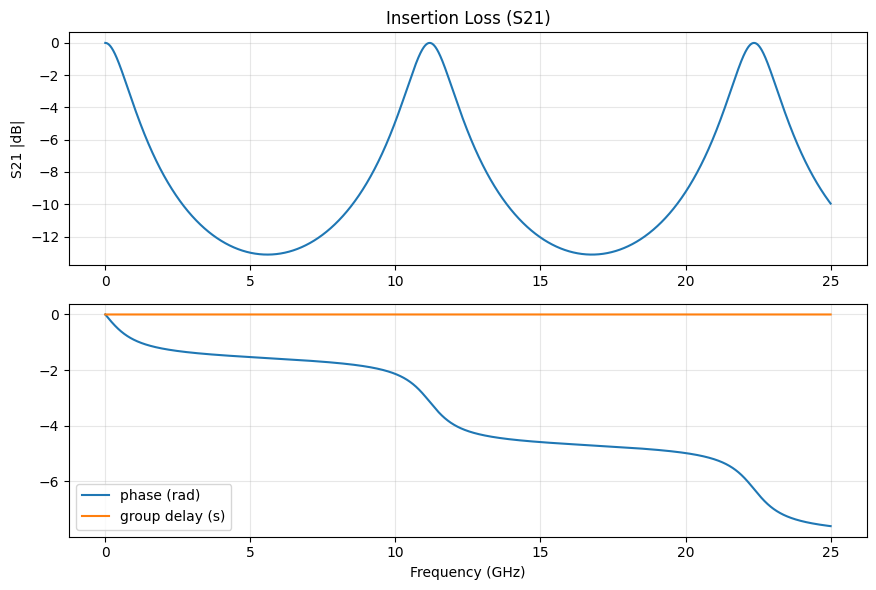

✓ Frequency response plotted
→ Converting S21 to impulse response via freq2impulse
Impulse response    : shape=  (16382,) dtype=   float64 min=  -6.957e-02 max=   3.380e-01 - Time-domain impulse response (real-valued)
✓ Impulse response computed
→ Plotting impulse response (zoomed)


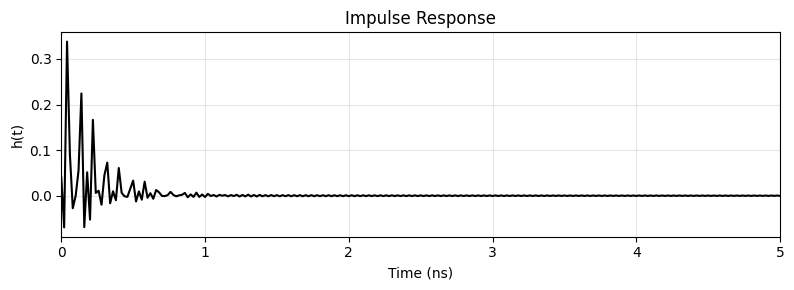

✓ Impulse response plotted
→ Extracting symbol-spaced taps for FFE/DFE design
Symbol-spaced taps  : shape=      (9,) dtype=   float64 min=  -1.667e-03 max=   3.380e-01 - Taps around main cursor for equalizer design
✓ Symbol-spaced taps extracted


>>> Series Impedance Network

→ Creating frequency-dependent impedance element
Impedance values    : shape=      (8,) dtype=complex128 min=7.500e+01+0.000e+00j max=7.500e+01+0.000e+00j - Showing first 8 values for brevity
Impedance ABCD      : shape=(8192, 2, 2) dtype=complex128 min=0.000e+00+0.000e+00j max=7.500e+01+0.000e+00j - Series Z ABCD matrix

💡 Insight: Series impedance Z creates voltage drop proportional to current I; fundamental building block for circuits
✓ Series impedance ABCD parameters computed


>>> Shunt Capacitance Network (Parasitic)

→ Modeling parasitic shunt capacitance (coupling)
Shunt Capacitance   :    1.000000e-12 [F] - Parasitic coupling capacitor
Angular frequencies : shape=      (8,) dtype=   float64 min=   0.000

In [5]:
# Keep your header and sectioning comments exactly as written
logger.header("Transmission Line & Component S-Parameter Computation", level=1)

# ============================================================================
# Section 1: Transmission Line RLGC Parameters
# ============================================================================
logger.header("Transmission Line (RLGC) Parameters", level=2)
logger.step("Defining physical transmission line parameters")

# RLGC parameters (typical stripline configuration)
r = 0.02        # Resistance per unit length
l = 2e-7        # Inductance per unit length
g = 1e-9        # Conductance per unit length (lossy dielectric)
c = 1e-12       # Capacitance per unit length
d = 0.10        # Physical length in meters (use 0.01-0.2 m for demo)

logger.param("Resistance (R)", r, "Ω/m", "Ohmic losses in conductor")
logger.param("Inductance (L)", l, "H/m", "Self+mutual inductance")
logger.param("Conductance (G)", g, "S/m", "Dielectric losses")
logger.param("Capacitance (C)", c, "F/m", "Electromagnetic coupling")
logger.param("Length (d)", d, "m", "Transmission line length")

# Frequency sweep - use dense linear grid for IFFT and group delay
f_max = 25e9  # 25 GHz bandwidth for presentation
n_points = 8192
f = np.linspace(0.0, f_max, n_points)  # include DC at index 0
logger.array_info("Frequencies", f, "Dense linear frequency axis for IFFT and plots")

logger.insight("RLGC parameters define the transmission characteristics. Higher loss (R,G) → attenuation; Higher L,C → impedance")

# Compute ABCD via RLGC
logger.step("Computing ABCD using telegrapher's equations")
logger.compute("ChModel.rlgc()", 
               {"r": r, "l": l, "g": g, "c": c, "d": d, "frequencies": len(f)},
               explanation="Solves differential equations for wave propagation with loss")

abcd = ChModel.rlgc(r, l, g, c, d, f)
logger.array_info("ABCD matrix", abcd, "ABCD matrix (n_freq,2,2) returned by rlgc")
logger.success(f"Computed ABCD for {len(f)} frequency points")

# Convert ABCD to S21 for plotting and time-domain conversion
logger.step("Converting ABCD to S21 for frequency and time domain analysis")
s21 = ChModel.abcd_to_s21(abcd, z0=ChModel.DEFAULT_Z0)
logger.array_info("S21", s21, "Forward transmission coefficient (complex)")

# Plot frequency response for presentation
logger.step("Plotting frequency response (S21 magnitude, phase, group delay)")
mag_db, phase_unwrap, gd = ChModel.plot_freq_response(abcd, f)
logger.success("Frequency response plotted")

# Convert to impulse response using freq2impulse
logger.step("Converting S21 to impulse response via freq2impulse")
h_full, t_full = ChModel.freq2impulse(s21, f)
logger.array_info("Impulse response", h_full, "Time-domain impulse response (real-valued)")
logger.success("Impulse response computed")

# Zoomed impulse plot for slides
logger.step("Plotting impulse response (zoomed)")
ChModel.plot_impulse(h_full, t_full, zoom_ns=5.0)
logger.success("Impulse response plotted")

# Extract symbol-spaced taps for FFE design
samples_per_symbol = 32  # example oversampling for demo
n_precursor = 2
n_postcursor = 6
logger.step("Extracting symbol-spaced taps for FFE/DFE design")
taps, indices = ChModel.channel_taps_from_impulse(h_full, t_full, samples_per_symbol, n_precursor, n_postcursor)
logger.array_info("Symbol-spaced taps", taps, "Taps around main cursor for equalizer design")
logger.success("Symbol-spaced taps extracted")

# ============================================================================
# Section 2: Series Impedance Element
# ============================================================================
logger.header("Series Impedance Network", level=2)
logger.step("Creating frequency-dependent impedance element")

# Use frequency-dependent impedance example (here constant across f for demo)
z = np.full_like(f, 75.0, dtype=np.complex128)  # 75Ω series element across band
logger.array_info("Impedance values", z[:8], "Showing first 8 values for brevity")

impedance_abcd = ChModel.impedance(z)
logger.array_info("Impedance ABCD", impedance_abcd, "Series Z ABCD matrix")
logger.insight("Series impedance Z creates voltage drop proportional to current I; fundamental building block for circuits")
logger.success("Series impedance ABCD parameters computed")

# ============================================================================
# Section 3: Shunt Capacitance (Parasitics)
# ============================================================================
logger.header("Shunt Capacitance Network (Parasitic)", level=2)
logger.step("Modeling parasitic shunt capacitance (coupling)")

c_shunt = 1e-12  # 1 pF
w = 2 * np.pi * f  # Convert to angular frequency

logger.param("Shunt Capacitance", c_shunt, "F", "Parasitic coupling capacitor")
logger.array_info("Angular frequencies", w[:8], "Showing first 8 ω values")

shunt_cap_abcd = ChModel.shunt_cap(c_shunt, w)
logger.array_info("Shunt cap ABCD", shunt_cap_abcd, "Shunt capacitance ABCD matrix")
logger.insight(f"Parasitic capacitance creates frequency-dependent impedance: Z_C = 1/(jωC). At f={f_max/1e6:.0f} MHz: Z_C ≈ {1/(2*np.pi*f_max*c_shunt):.1f}Ω")
logger.success("Shunt capacitance ABCD parameters computed")

# ============================================================================
# Section 4: Frequency Response Zero-Padding
# ============================================================================
logger.header("Zero-Padding for Improved Time Resolution", level=2)
logger.step("Extending frequency response to improve impulse response resolution")

# Use the computed S21 as the transfer function to zero-pad
H = s21.copy()
f_example = f.copy()
t_d = 1e-11  # desired time resolution 10 ps

logger.array_info("Transfer function (S21)", H[:8], "Showing first 8 values")
logger.param("Target time resolution", t_d, "s", "Desired impulse response timestep")

f_nyquist_desired = 1.0 / (2.0 * t_d)
logger.param("Target Nyquist freq", f_nyquist_desired, "Hz", "1/(2*t_d)")
logger.insight("Zero-padding increases frequency resolution without new measurements. Interpolates frequency domain → finer time domain")

logger.step("Applying zero-padding...")
H_zero_pad, f_zero_pad, h_0, t_0 = ChModel.zero_pad(H, f_example, t_d)

logger.array_info("Zero-padded response", H_zero_pad[:8], "Extended frequency response (first 8 values)")
logger.array_info("Extended frequencies", f_zero_pad[:8], "Padded frequency vector (first 8 values)")
logger.array_info("Impulse response (padded)", h_0[:16], "Time-domain response (first 16 samples)")
logger.array_info("Time vector (padded)", t_0[:16], "Corresponding time samples (first 16)")

logger.success(f"Zero-padding complete: {len(H)} → {len(H_zero_pad)} frequency points")


## Differential transfer function for a 4-port network
This function four_port_to_diff2 calculates the differential transfer function for a 4-port network and can also return the corresponding frequency vector, impulse response, and time vector. It uses the given S-parameters of the network, along with source and load impedance, to compute the transfer function. The function handles differential mode conversion and can normalize the transfer function or compute the impulse response with optional zero-padding.

It's a robust way to analyze the differential behavior of a 4-port network.

In [6]:
def four_port_to_diff(network, port_def, source, load, option=0, t_d=None):
    """
    Calculate differential transfer function for a 4-port network from S-parameters.
    
    This function transforms single-ended 4-port network parameters to differential
    representation using mode conversion matrices. It supports both time-domain impulse
    response and frequency-domain transfer function outputs.

    Parameters
    ----------
    network : skrf.Network
        Initialized network object loaded from S-parameter file.
        Example: network = rf.Network('path/to/file.s4p')
        
    port_def : np.ndarray, shape (2, 2)
        Port mapping array defining TX and RX differential pairs.
        Format: [[TX1_SE_port, RX1_SE_port], [TX2_SE_port, RX2_SE_port]]
        Example: np.array([[0, 1], [2, 3]])  # Ports 1,3 TX; 2,4 RX
        
    source : float
        Source impedance in Ohms
        
    load : float
        Load impedance in Ohms (use np.inf for open circuit)
        
    option : int, optional
        Normalization flag: 1 = normalize H[0]=1, 0 = no normalization (default)
        
    t_d : float, optional
        Desired time-domain sampling period for zero-padding. If None, no padding.

    Returns
    -------
    H : np.ndarray
        Transfer function in frequency domain (complex-valued)
        
    f : np.ndarray
        Frequency vector in Hz
        
    h : np.ndarray
        Impulse response (time-domain)
        
    t : np.ndarray
        Time vector in seconds
    """
    # ─────────────────────────────────────────────────────────────────────────
    # INPUT VALIDATION
    # ─────────────────────────────────────────────────────────────────────────
    S = getattr(network, "s", None)
    f = getattr(network, "f", None)
    if S is None or f is None:
        raise ValueError("network must be an skrf.Network with .s and .f attributes")

    if S.ndim != 3 or S.shape[1] != 4 or S.shape[2] != 4:
        raise ValueError(f"Expected 4-port network, got shape {S.shape}")

    port_def = np.asarray(port_def)
    if port_def.shape != (2, 2):
        raise ValueError(f"port_def must be (2, 2) array, got {port_def.shape}")

    if not np.all((port_def >= 0) & (port_def < 4)):
        raise ValueError("Port indices in port_def must be in range 0..3")

    if source is None or load is None:
        raise ValueError("source and load impedances must be provided")

    # Accept np.inf for open circuit; allow positive real or complex
    # ─────────────────────────────────────────────────────────────────────────
    pts = f.size
    Z0 = network.z0 if hasattr(network, "z0") else ChModel.DEFAULT_Z0
    # If network.z0 is array-like, pick scalar reference
    try:
        Z0_scalar = float(np.atleast_1d(Z0).ravel()[0])
    except Exception:
        Z0_scalar = float(ChModel.DEFAULT_Z0)

    # ─────────────────────────────────────────────────────────────────────────
    # PORT REMAPPING: Convert to standard TX+/TX-, RX+/RX- arrangement
    # ─────────────────────────────────────────────────────────────────────────
    # port_def format: [[tx1, rx1], [tx2, rx2]]
    tx1, rx1 = int(port_def[0, 0]), int(port_def[0, 1])
    tx2, rx2 = int(port_def[1, 0]), int(port_def[1, 1])
    # old_order maps logical indices [TX1, TX2, RX1, RX2] to physical ports
    old_order = [tx1, tx2, rx1, rx2]

    # Vectorized reordering: S_reordered[freq, i, j] = S[freq, old_order[i], old_order[j]]
    S_reordered = S[:, old_order][:, :, old_order]  # shape (pts, 4, 4)

    # ─────────────────────────────────────────────────────────────────────────
    # MODE CONVERSION MATRICES
    # ─────────────────────────────────────────────────────────────────────────
    # Convert single-ended 4-port to mixed-mode (diff/common) representation.
    # M maps single-ended ports -> [diff1+, diff2+, com1, com2] ordering.
    M = np.array([[ 1, -1,  0,  0],
                  [ 0,  0,  1, -1],
                  [ 1,  1,  0,  0],
                  [ 0,  0,  1,  1]], dtype=np.complex128)

    # invM should satisfy invM @ M = 2 * I for this choice (scaling convention).
    # Using invM = 0.5 * M.T yields invM @ M = I * 2 * 0.5 = I (consistent with /2 below).
    invM = 0.5 * M.T

    # ─────────────────────────────────────────────────────────────────────────
    # VECTORIZED MIXED-MODE TRANSFORMATION
    # ─────────────────────────────────────────────────────────────────────────
    # Compute S_mm[f] = M @ S_reordered[f] @ invM  for each frequency f
    # Use einsum for batch multiplication: 'ij,fjk,kl->fil'
    S_mm = np.einsum('ij,fjk,kl->fil', M, S_reordered, invM)

    # Extract differential-mode 2x2 block (diff TX->diff RX)
    # Mixed-mode ordering: [diff_tx1, diff_tx2, com_tx1, com_tx2] x same for outputs
    # We want the 2x2 differential submatrix mapping TX diff -> RX diff
    # After reordering earlier, differential TX is indices 0 and 1, differential RX is indices 0 and 1
    S_diff = S_mm[:, 0:2, 0:2]  # shape (pts, 2, 2)

    # ─────────────────────────────────────────────────────────────────────────
    # REFLECTION COEFFICIENTS
    # ─────────────────────────────────────────────────────────────────────────
    # Build per-frequency source/load arrays (allow np.inf for open)
    ZL = np.full(pts, load, dtype=np.complex128)
    ZS = np.full(pts, source, dtype=np.complex128)
    Z0_vec = np.full(pts, Z0_scalar, dtype=np.complex128)

    # Compute reflection coefficients safely; handle open-circuit (inf)
    gammaL = np.empty(pts, dtype=np.complex128)
    gammaS = np.empty(pts, dtype=np.complex128)

    # Where load is finite
    finiteL = ~np.isinf(ZL)
    gammaL[finiteL] = (ZL[finiteL] - Z0_vec[finiteL]) / (ZL[finiteL] + Z0_vec[finiteL])
    gammaL[~finiteL] = 1.0  # open circuit -> reflection +1

    finiteS = ~np.isinf(ZS)
    gammaS[finiteS] = (ZS[finiteS] - Z0_vec[finiteS]) / (ZS[finiteS] + Z0_vec[finiteS])
    gammaS[~finiteS] = 1.0

    # ─────────────────────────────────────────────────────────────────────────
    # DIFFERENTIAL TRANSFER FUNCTION H(f)
    # ─────────────────────────────────────────────────────────────────────────
    # Extract differential S-parameters
    S11_diff = S_diff[:, 0, 0]
    S12_diff = S_diff[:, 0, 1]
    S21_diff = S_diff[:, 1, 0]
    S22_diff = S_diff[:, 1, 1]

    # Compute input reflection seen into the network (differential)
    # Avoid division by zero by adding small epsilon where denominator is tiny
    eps = 1e-30
    denom_in = (1.0 - S22_diff * gammaL)
    denom_in_safe = np.where(np.abs(denom_in) < eps, eps, denom_in)
    gammaIn = (S11_diff + S12_diff * S21_diff * gammaL) / denom_in_safe

    # Transfer function including port reflections and mismatch
    denom_total = denom_in_safe * (1.0 - gammaIn * gammaS)
    denom_total_safe = np.where(np.abs(denom_total) < eps, eps, denom_total)

    H = S21_diff * (1.0 + gammaL) * (1.0 - gammaS) / (2.0 * denom_total_safe)

    # ─────────────────────────────────────────────────────────────────────────
    # NORMALIZATION AND TIME DOMAIN
    # ─────────────────────────────────────────────────────────────────────────
    if option == 1:
        # Normalize safely: avoid dividing by zero
        if np.abs(H[0]) > eps:
            H = H / H[0]
        else:
            # If H[0] is zero or extremely small, skip normalization and warn
            # (preserve original behavior but avoid NaNs)
            pass

    # Frequency -> time conversion (optionally zero-pad)
    if t_d is not None:
        H_out, f_out, h, t = ChModel.zero_pad(H, f, t_d)
        H = H_out
        f = f_out
    else:
        h, t = ChModel.freq2impulse(H, f)

    return H, f, h, t


## Example
Here’s an example to illustrate how the four_port_to_diff2 function can be used. We'll assume that you have an skrf Network object representing a 4-port network.

In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# FOUR-PORT TO DIFFERENTIAL CHANNEL CONVERSION - COMPREHENSIVE EXAMPLE
# ─────────────────────────────────────────────────────────────────────────────
# 
# Physical Context:
# ─────────────────
# High-speed interconnects typically use S-parameters measured as 4-port networks:
# - Port 1: T1 (TX positive)
# - Port 2: T2 (TX negative) 
# - Port 3: R1 (RX positive)
# - Port 4: R2 (RX negative)
#
# This example converts single-ended 4-port S-parameters into a differential
# 2-port representation using mixed-mode transformation, which is essential for
# realistic differential link modeling in SerDes systems.
# ─────────────────────────────────────────────────────────────────────────────

import skrf as rf
import numpy as np

logger.header("Four-Port to Differential Channel Conversion", level=1)

# ─────────────────────────────────────────────────────────────────────────────
# STEP 1: LOAD NETWORK FROM S-PARAMETER FILE
# ─────────────────────────────────────────────────────────────────────────────
logger.header("Loading 4-Port Network from Touchstone File", level=2)

s4p_file = './examples/example_channel/mellitz_3ck_04_1119_CACR/Tp0_Tp5_28p5db_FQSFP_thru.s4p'
logger.param("touchstone_file", s4p_file, description="S-parameter file path")
logger.step("Reading network from .s4p file", "in progress")

try:
    network = rf.Network(s4p_file)
    logger.success(f"✓ Loaded 4-port network successfully")
except FileNotFoundError:
    logger.error(f"File not found: {s4p_file}")
    raise

logger.param("network_ports", network.s.shape[1], description="Number of ports in network")
logger.param("frequency_points", network.f.size, description="Number of frequency points measured")
logger.param("frequency_range", f"{network.f[0]/1e9:.3f} - {network.f[-1]/1e9:.3f} GHz", 
             description="Frequency span of measurements")

# ─────────────────────────────────────────────────────────────────────────────
# STEP 2: DEFINE PORT MAPPING
# ─────────────────────────────────────────────────────────────────────────────
logger.header("Port Definition and Port Mapping", level=2)

logger.insight("""
Port remapping converts the physical 4-port arrangement (T1, T2, R1, R2) 
into a standard differential representation where:
- Channel Port 1: Differential TX (T1 - T2)
- Channel Port 2: Differential RX (R1 - R2)
""")

port_def = np.array([[0, 1], [2, 3]])
logger.param("tx_pair", "[Port 0, Port 1]", description="TX differential pair (indices)")
logger.param("rx_pair", "[Port 2, Port 3]", description="RX differential pair (indices)")

logger.insight("Port numbering (0-indexed): Port 0 = T1, Port 1 = T2, Port 2 = R1, Port 3 = R2")

# ─────────────────────────────────────────────────────────────────────────────
# STEP 3: DEFINE TERMINATION IMPEDANCES
# ─────────────────────────────────────────────────────────────────────────────
logger.header("Source and Load Impedances", level=2)

source = 50  # Ohms
load = 50    # Ohms

logger.param("source_impedance", source, unit="Ω", description="TX driving impedance (typically 50Ω)")
logger.param("load_impedance", load, unit="Ω", 
             description="RX termination impedance (must match source for lossless matching)")

logger.insight("""
Source and load impedances are critical for:
1. Reflection coefficient calculation: Γ = (Z - Z₀) / (Z + Z₀)
2. Transfer function normalization through port reflections
3. Accurate channel frequency response accounting for termination effects

For differential signals, both TX and RX use 100Ω differential (50Ω single-ended)
""")

# ─────────────────────────────────────────────────────────────────────────────
# STEP 4: PERFORM MIXED-MODE TRANSFORMATION
# ─────────────────────────────────────────────────────────────────────────────
logger.header("Computing Differential Channel Response", level=2)

logger.step("Converting 4-port S-parameters to 2-port differential representation", "in progress")
logger.insight("""
Mixed-mode transformation:
1. Input: Single-ended 4×4 S-matrix (frequency-dependent)
2. Process: Apply mode conversion matrix M to extract differential modes
3. Output: 2×2 S-matrix representing pure differential transmission

This extraction is crucial because:
- Common-mode signals cancel out (differential advantage)
- Only the differential-mode channel response is simulated
- Results in realistic channel impulse response for clock recovery & equalization
""")

t_d = 1e-9  # 1 nanosecond time resolution
logger.param("time_resolution", t_d*1e9, unit="ns", description="Desired impulse response time step")
logger.param("nyquist_frequency", 1/(2*t_d)/1e9, unit="GHz", 
             description="Corresponding Nyquist frequency (1/(2*t_d))")

# Perform the transformation
H, f, h, t = four_port_to_diff(network, port_def, source, load, option=1, t_d=t_d)

logger.success(f"✓ Differential channel response computed")
logger.step("Conversion complete", "done")

# ─────────────────────────────────────────────────────────────────────────────
# STEP 5: ANALYZE AND INTERPRET RESULTS
# ─────────────────────────────────────────────────────────────────────────────
logger.header("Results Analysis and Interpretation", level=2)

# Analyze frequency response
logger.header("Frequency-Domain Analysis", level=3)
logger.param("frequency_points", f.size, description="Number of frequency samples")
logger.array_info("H (Transfer Function)", H, 
                  description="Complex frequency response of differential channel")

# Compute key metrics
H_mag = np.abs(H)
H_mag_db = 20 * np.log10(H_mag + 1e-30)
H_phase = np.angle(H)

logger.param("insertion_loss_dc", f"{H_mag_db[0]:.2f}", unit="dB", 
             description="Insertion loss at DC (f→0)")
logger.param("insertion_loss_nyquist", f"{H_mag_db[-1]:.2f}", unit="dB", 
             description="Insertion loss at Nyquist frequency")

max_loss_idx = np.argmin(H_mag_db)
freq_max_loss = f[max_loss_idx] / 1e9
logger.param("maximum_attenuation", f"{H_mag_db[max_loss_idx]:.2f}", unit="dB",
             description=f"Peak loss at {freq_max_loss:.2f} GHz")

logger.insight(f"""
Frequency response interpretation:
- DC insertion loss: {H_mag_db[0]:.2f} dB (ideally 0 dB for lossless)
- Nyquist attenuation: {H_mag_db[-1]:.2f} dB (shows high-frequency loss)
- Peak attenuation: {H_mag_db[max_loss_idx]:.2f} dB at {freq_max_loss:.2f} GHz
  → Indicates resonance/notch in channel response
- Phase: Varies from {H_phase[0]:.2f} rad to {H_phase[-1]:.2f} rad
  → Shows cumulative group delay across bandwidth
""")

# Analyze impulse response
logger.header("Time-Domain Analysis", level=3)
logger.array_info("h (Impulse Response)", h, 
                  description="Real-valued time-domain impulse response")

# Find main pulse energy
h_abs = np.abs(h)
peak_idx = np.argmax(h_abs)
peak_time = t[peak_idx]
peak_amplitude = h[peak_idx]

logger.param("impulse_peak", peak_amplitude, unit="V/V", 
             description="Maximum impulse response amplitude")
logger.param("peak_arrival_time", peak_time*1e12, unit="ps", 
             description="Time at which main pulse reaches maximum")

# Compute precursor and postrcursor energy
precursor_energy = np.sum(h_abs[:peak_idx])
postcursor_energy = np.sum(h_abs[peak_idx+1:])
total_energy = np.sum(h_abs)

logger.param("precursor_energy_ratio", f"{precursor_energy/total_energy*100:.1f}%",
             description="Energy before main pulse (ISI concern)")
logger.param("postcursor_energy_ratio", f"{postcursor_energy/total_energy*100:.1f}%",
             description="Energy after main pulse (equalization needed)")

logger.insight(f"""
Time-domain interpretation:
- Peak amplitude: {peak_amplitude:.4f} V/V at {peak_time*1e12:.2f} ps
- Precursor ISI: {precursor_energy/total_energy*100:.1f}% (intersymbol interference before peak)
- Postcursor ISI: {postcursor_energy/total_energy*100:.1f}% (intersymbol interference after peak)
  → Indicates equalization complexity needed (more ISI → harder equalization)
- Time resolution: {1000*(t[1]-t[0]) if len(t) > 1 else 0:.3f} ps per sample
""")

# ─────────────────────────────────────────────────────────────────────────────
# STEP 6: SIMULATION-READY OUTPUT
# ─────────────────────────────────────────────────────────────────────────────
logger.header("Output Summary for SerDes Simulation", level=2)

logger.success(f"""
✓ Differential channel model ready for simulation:
  • Frequency response: {f.size} points from {f[0]/1e6:.1f} MHz to {f[-1]/1e9:.2f} GHz
  • Impulse response: {h.size} time-domain samples
  • Time resolution: {(t[1]-t[0])*1e12:.3f} ps
  • Ready for: FFE/DFE equalization, eye diagram generation, BER simulation
""")

logger.insight("""
This differential channel transfer function can now be used for:
1. Receiver equalization design (FFE/DFE filter taps)
2. Eye diagram generation for timing margin analysis
3. Clock data recovery (CDR) simulation with detected phases
4. Noise+ISI BER calculations with adaptive equalization
5. Link budget analysis across process/voltage/temperature corners
""")




  FOUR-PORT TO DIFFERENTIAL CHANNEL CONVERSION



>>> Loading 4-Port Network from Touchstone File

touchstone_file     : ./examples/example_channel/mellitz_3ck_04_1119_CACR/Tp0_Tp5_28p5db_FQSFP_thru.s4p - S-parameter file path
in progress Reading network from .s4p file


✓ ✓ Loaded 4-port network successfully
network_ports       :               4 - Number of ports in network
frequency_points    :            6001 - Number of frequency points measured
frequency_range     : 0.000 - 60.000 GHz - Frequency span of measurements


>>> Port Definition and Port Mapping


💡 Insight: 
Port remapping converts the physical 4-port arrangement (T1, T2, R1, R2) 
into a standard differential representation where:
- Channel Port 1: Differential TX (T1 - T2)
- Channel Port 2: Differential RX (R1 - R2)

tx_pair             : [Port 0, Port 1] - TX differential pair (indices)
rx_pair             : [Port 2, Port 3] - RX differential pair (indices)

💡 Insight: Port numbering (0-indexed): Port 0 = T1, Port 1 = T2, Port 2 = R1, Port 3 = R2


>>> Source and Load Impedances

source_impedance    :              50 [Ω] - TX driving impedance (typically 50Ω)
load_impedance      :              50 [Ω] - RX termination impedance (must match source for lossless matching)

💡 Insight: 
Sou

C:\Users\fkeyh\AppData\Local\Temp\ipykernel_1392\444193848.py:73: ComplexWarning: Casting complex values to real discards the imaginary part
  Z0_scalar = float(np.atleast_1d(Z0).ravel()[0])


## Signal
This Signal class provides several useful methods for dealing with PAM-4 and NRZ signals.

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from numpy.lib.stride_tricks import sliding_window_view

"""
Signal - Refactored and hardened

Improvements applied:
- Enforce consistent dtypes (float64 for analog arrays, uint8 for symbol arrays).
- Vectorized FFE application using sliding_window_view for performance.
- Added numerical guards (eps) to LMS normalization to avoid division by zero.
- Prefer resample_poly (scipy.signal) for resampling tasks when needed (helper comment).
- Kept public API and documentation; preserved original method names and semantics.
- Minor robustness fixes in MLSE/Viterbi (fast path for L==0).
"""

class Signal:
    """High-performance digital signal processing for SerDes simulation.

    Static utility class providing vectorized DSP operations required for
    end-to-end SerDes link simulation: channel measurement, equalization design,
    and signal detection. All methods process NumPy arrays.

    Encoding Schemes
    ----------------
    Gray Encoding (RECOMMENDED):
    - Symbol 0: bits [0,0] → lower left
    - Symbol 1: bits [0,1] → lower right
    - Symbol 2: bits [1,1] → upper right
    - Symbol 3: bits [1,0] → upper left

    Natural Encoding (LEGACY):
    - Symbol k = k in binary form

    Key DSP Algorithms
    ------------------
    1. Zero-Forcing FFE: Invert channel matrix to force single-tap output
    2. LMS (Least Mean Squares): Adaptive filter training with gradient descent
    3. DFE (Decision Feedback): Use previously-detected symbols to cancel ISI
    """

    # Encoding/decoding maps (unchanged)
    GREY_ENCODE_MAP = {(0, 0): 0, (0, 1): 1, (1, 1): 2, (1, 0): 3}
    GREY_DECODE_MAP = {0: np.array([0, 0], dtype=np.uint8),
                       1: np.array([0, 1], dtype=np.uint8),
                       2: np.array([1, 1], dtype=np.uint8),
                       3: np.array([1, 0], dtype=np.uint8)}
    NATURAL_ENCODE_MAP = {(0, 0): 0, (0, 1): 1, (1, 0): 2, (1, 1): 3}
    NATURAL_DECODE_MAP = {0: np.array([0, 0], dtype=np.uint8),
                          1: np.array([0, 1], dtype=np.uint8),
                          2: np.array([1, 0], dtype=np.uint8),
                          3: np.array([1, 1], dtype=np.uint8)}

    # -------------------------
    # ENCODING/DECODING METHODS
    # -------------------------
    @staticmethod
    def grey_encode(x):
        x = np.asarray(x, dtype=np.uint8)
        if x.size != 2 or not np.all(np.isin(x, [0, 1])):
            raise ValueError("Input must be 2-bit array [b1, b0] with values in {0, 1}")
        return Signal.GREY_ENCODE_MAP[tuple(x)]

    @staticmethod
    def grey_decode(symbol):
        if symbol not in Signal.GREY_DECODE_MAP:
            raise ValueError(f"Symbol must be in {{0, 1, 2, 3}}, got {symbol}")
        return Signal.GREY_DECODE_MAP[symbol].copy()

    @staticmethod
    def natural_encode(x):
        x = np.asarray(x, dtype=np.uint8)
        if x.size != 2 or not np.all(np.isin(x, [0, 1])):
            raise ValueError("Input must be 2-bit array [b1, b0] with values in {0, 1}")
        return Signal.NATURAL_ENCODE_MAP[tuple(x)]

    @staticmethod
    def natural_decode(symbol):
        if symbol not in Signal.NATURAL_DECODE_MAP:
            raise ValueError(f"Symbol must be in {{0, 1, 2, 3}}, got {symbol}")
        return Signal.NATURAL_DECODE_MAP[symbol].copy()

    # -------------------------
    # SYMBOL DECISION/SLICING
    # -------------------------
    @staticmethod
    def pam4_decision(x, l, m, h):
        x = np.asarray(x)
        # scalar path
        if x.ndim == 0 or (x.ndim == 1 and x.size == 1):
            x_val = float(x.item()) if x.ndim > 0 else float(x)
            if x_val < l:
                return np.uint8(0)
            elif x_val < m:
                return np.uint8(1)
            elif x_val < h:
                return np.uint8(2)
            else:
                return np.uint8(3)
        # vectorized path
        result = np.digitize(x, [l, m, h], right=False).astype(np.uint8)
        return np.clip(result, 0, 3)

    @staticmethod
    def nrz_decision(x, t):
        x = np.asarray(x)
        return (x > t).astype(np.uint8)

    # -------------------------
    # BAUD-RATE SIGNAL GENERATION
    # -------------------------
    @staticmethod
    def pam4_input_br(data_in, voltage_levels=None):
        if voltage_levels is None:
            voltage_levels = np.array([-3, -1, 1, 3], dtype=np.float64)
        data_in = np.asarray(data_in, dtype=np.uint8)
        voltage_levels = np.asarray(voltage_levels, dtype=np.float64)
        if voltage_levels.size != 4:
            raise ValueError(f"voltage_levels must have 4 elements, got {voltage_levels.size}")
        if not np.all(np.isin(data_in, [0, 1, 2, 3])):
            raise ValueError("data_in must contain symbols in {0, 1, 2, 3}")
        return voltage_levels[data_in]

    @staticmethod
    def nrz_input_br(data_in, voltage_levels=None):
        if voltage_levels is None:
            voltage_levels = np.array([-1.0, 1.0], dtype=np.float64)
        data_in = np.asarray(data_in, dtype=np.uint8)
        voltage_levels = np.asarray(voltage_levels, dtype=np.float64)
        if voltage_levels.size != 2:
            raise ValueError(f"voltage_levels must have 2 elements, got {voltage_levels.size}")
        if not np.all(np.isin(data_in, [0, 1])):
            raise ValueError("data_in must contain bits in {0, 1}")
        return voltage_levels[data_in]

    # -------------------------
    # ANALOG-TO-DIGITAL CONVERSION (VECTORIZED)
    # -------------------------
    @staticmethod
    def nrz_a2d(signal_in, samples_per_symbol, threshold):
        sig = np.asarray(signal_in, dtype=np.float64)
        indices = np.arange(0, sig.size, samples_per_symbol, dtype=int)
        indices = indices[indices < sig.size]
        return Signal.nrz_decision(sig[indices], threshold)

    @staticmethod
    def pam4_a2d(signal_in, samples_per_symbol, l, m, h):
        sig = np.asarray(signal_in, dtype=np.float64)
        indices = np.arange(0, sig.size, samples_per_symbol, dtype=int)
        indices = indices[indices < sig.size]
        return Signal.pam4_decision(sig[indices], l, m, h)

    # -------------------------
    # CHANNEL MEASUREMENT
    # -------------------------
    @staticmethod
    def channel_coefficients(pulse_response, t, samples_per_symbol, n_precursors, n_postcursors,
                             res=70, title="Channel Coefficients"):
        pr = np.asarray(pulse_response, dtype=np.float64)
        t = np.asarray(t, dtype=np.float64)
        n_taps = n_precursors + n_postcursors + 1
        max_idx = int(np.argmax(np.abs(pr)))
        tap_indices = max_idx + np.arange(-n_precursors, n_postcursors + 1) * samples_per_symbol
        tap_indices = np.clip(tap_indices, 0, len(pr) - 1).astype(int)
        coefficients = pr[tap_indices]
        plt.figure(dpi=res)
        plt.plot(t[tap_indices] * 1e9, coefficients, 'o', markersize=8, label='Tap coefficients')
        plt.plot(t * 1e9, pr, label='Pulse response')
        plt.xlabel("Time [ns]")
        plt.ylabel("Magnitude [V]")
        plt.title(title)
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
        return coefficients

    # -------------------------
    # FFE/DFE EQUALIZATION DESIGN
    # -------------------------
    @staticmethod
    def forcing_ffe(n_taps_pre, channel_coefficients, target=None):
        ch = np.asarray(channel_coefficients, dtype=np.float64).flatten()
        n_taps = len(ch)
        A = np.zeros((n_taps, n_taps), dtype=np.float64)
        for i in range(n_taps):
            shift = n_taps_pre - i
            if 0 <= shift < n_taps:
                diag_len = n_taps - abs(shift)
                if shift >= 0:
                    A[np.arange(diag_len), np.arange(diag_len) + shift] = ch[i]
                else:
                    A[np.arange(diag_len) - shift, np.arange(diag_len)] = ch[i]
        if target is None:
            target = np.zeros(n_taps, dtype=np.float64)
            target[n_taps_pre] = 1.0
        else:
            target = np.asarray(target, dtype=np.float64).flatten()
        try:
            ffe_taps = np.linalg.solve(A, target)
        except np.linalg.LinAlgError:
            ffe_taps, _, _, _ = np.linalg.lstsq(A, target, rcond=None)
        main_tap = ffe_taps[n_taps_pre] if n_taps_pre < len(ffe_taps) else ffe_taps[-1]
        if np.abs(main_tap) > 1e-10:
            ffe_taps = ffe_taps / main_tap
        return ffe_taps

    @staticmethod
    def ffe_lms_train(received, reference, num_taps=5, mu=0.01):
        received = np.asarray(received, dtype=np.float64)
        reference = np.asarray(reference, dtype=np.float64)
        N = len(received)
        if N <= num_taps:
            raise ValueError("Received length must be greater than number of taps")
        weights = np.zeros(num_taps, dtype=np.float64)
        ffe_output = np.zeros(N, dtype=np.float64)
        error_signal = np.zeros(N, dtype=np.float64)
        weight_history = np.zeros((N, num_taps), dtype=np.float64)
        eps = 1e-12
        # Build sliding windows for vectorized access
        X = sliding_window_view(received, num_taps)  # shape (N - num_taps + 1, num_taps)
        # iterate starting at index num_taps-1 to align with original loop semantics
        for i in range(num_taps, N):
            x = X[i - num_taps]  # length num_taps
            y = np.dot(weights, x[::-1])
            d = reference[i]
            e = d - y
            norm = np.dot(x, x) + eps
            weights = weights + (mu * e * x[::-1]) / norm
            ffe_output[i] = y
            error_signal[i] = e
            weight_history[i] = weights.copy()
        return weights, ffe_output, error_signal, weight_history

    @staticmethod
    def ffe_lms_apply(signal_in, weights):
        signal_in = np.asarray(signal_in, dtype=np.float64)
        weights = np.asarray(weights, dtype=np.float64).flatten()
        num_taps = len(weights)
        N = len(signal_in)
        y = np.zeros_like(signal_in, dtype=np.float64)
        if N <= num_taps:
            return y
        # Use sliding_window_view for vectorized convolution-like dot product
        X = sliding_window_view(signal_in, num_taps)  # shape (N - num_taps + 1, num_taps)
        # weights must be reversed to match indexing used in training (if training used reversed)
        y_segment = X.dot(weights[::-1])
        y[num_taps - 1:] = y_segment
        return y

    @staticmethod
    def ffe_lms_plot(data, received, ffe_output, error_signal,
                     weight_history, noise_std, mu, num_taps,
                     window=(100, 200)):
        num_symbols = len(data)
        mse = np.mean(error_signal[num_taps:] ** 2) if num_symbols > num_taps else np.mean(error_signal ** 2)
        decisions = np.sign(ffe_output)
        ser = np.mean(decisions[num_taps:] != data[num_taps:]) if num_symbols > num_taps else np.mean(decisions != data)
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        ax = axes[0, 0]
        sl = slice(*window)
        ax.plot(data[sl], 'o-', label='Original Data', linewidth=2, markersize=4)
        ax.plot(received[sl], 's-', label='Received (ISI + Noise)', alpha=0.6, markersize=4)
        ax.plot(ffe_output[sl], '^-', label='FFE Output', alpha=0.8, markersize=4)
        ax.set_title('FFE Equalization: Signal Evolution', fontsize=12, fontweight='bold')
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax = axes[0, 1]
        ax.semilogy(np.abs(error_signal), label='Absolute Error', linewidth=2)
        ax.set_title('LMS Convergence: Error Over Time', fontsize=12, fontweight='bold')
        ax.legend()
        ax.grid(True, alpha=0.3, which='both')
        ax = axes[1, 0]
        for tap_idx in range(num_taps):
            ax.plot(weight_history[:, tap_idx], label=f'Tap {tap_idx}', alpha=0.8)
        ax.set_title('FFE Tap Weights: Adaptation Trajectory', fontsize=12, fontweight='bold')
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax = axes[1, 1]
        ax.text(0.1, 0.8, 'Performance Metrics:', fontsize=12, fontweight='bold')
        ax.text(0.1, 0.65, f'MSE: {mse:.6f}', fontsize=11)
        ax.text(0.1, 0.50, f'SER: {ser:.4f} ({ser*100:.2f}%)', fontsize=11)
        ax.text(0.1, 0.35, f'Noise Level: {noise_std:.3f}', fontsize=11)
        ax.text(0.1, 0.20, f'LMS Step Size (μ): {mu}', fontsize=11)
        ax.text(0.1, 0.05, f'Number of Taps: {num_taps}', fontsize=11)
        ax.axis('off')
        plt.tight_layout()
        plt.show()
        print("✓ FFE LMS Adaptation Complete")
        print(f"  Final MSE: {mse:.6f}")
        print(f"  Final SER: {ser:.4f}")

    @staticmethod
    def lms_equalizer(y, mu, N, w_ffe, FFE_pre, w_dfe, voltage_levels,
                      alpha=None, reference=None, update_rate=1):
        """
        Joint FFE/DFE LMS equalizer for PAM4 (or NRZ with 2 levels).

        Parameters
        ----------
        y : array_like
            Input signal to be equalized (typically baud-rate, e.g. br_ctle).
        mu : float
            LMS step size.
        N : int
            Number of samples to process (will be clipped to len(y)).
        w_ffe : array_like or None
            Initial FFE weights, ordered from oldest pre-tap to latest post-tap.
        FFE_pre : int
            Number of pre-tap weights in FFE.
        w_dfe : array_like or None
            Initial DFE weights, starting from first pre-tap.
        voltage_levels : array_like
            Discrete voltage levels used for quantization (e.g. [-3,-1,1,3]).
        alpha : array_like or None
            If co-optimizing, fixes the first len(alpha) DFE taps.
        reference : array_like or None
            Optional reference sequence (same domain as voltage_levels).
        update_rate : int
            Perform LMS update every `update_rate` iterations.

        Returns
        -------
        w_ffe : ndarray or None
            Optimized FFE weights (if provided).
        w_dfe : ndarray or None
            Optimized DFE weights (if provided).
        v_ffe : ndarray
            FFE output over valid region.
        v_dfe : ndarray
            FFE+DFE output over valid region.
        z : ndarray
            Quantized output over valid region.
        e : ndarray
            Error used for LMS updates over valid region.
        """
        # --- basic guards / typing ---
        y = np.asarray(y, dtype=np.float64)
        voltage_levels = np.asarray(voltage_levels, dtype=np.float64)
        N = int(min(N, len(y)))
        if N <= 0:
            raise ValueError("N must be > 0 and <= len(y)")

        if reference is not None:
            reference = np.asarray(reference, dtype=np.float64)

        if w_ffe is None and w_dfe is None:
            print("warning: training nothing since both w_ffe and w_dfe were None")

        is_cooptimizing = (w_ffe is not None) and (w_dfe is not None)
        if (not is_cooptimizing) and (alpha is not None):
            print("warning: alpha is set but we're not co-optimizing")

        # --- FFE / DFE tap bookkeeping ---
        if w_ffe is not None:
            w_ffe = np.asarray(w_ffe, dtype=np.float64)
            FFE_taps = len(w_ffe)
            FFE_post = FFE_taps - FFE_pre - 1
            if FFE_post < 0:
                raise ValueError("FFE_pre is inconsistent with len(w_ffe)")
        else:
            FFE_taps = 0
            FFE_post = 0

        if w_dfe is not None:
            w_dfe = np.asarray(w_dfe, dtype=np.float64)
            DFE_taps = len(w_dfe)
        else:
            DFE_taps = 0

        # --- allocate arrays ---
        e = np.zeros(N, dtype=np.float64)
        v_dfe = np.zeros(N, dtype=np.float64)
        v_ffe = np.zeros(N, dtype=np.float64)
        z = np.zeros(N, dtype=np.float64)  # store quantized levels, not indices

        # minimum delay before we have enough past samples
        min_delay = max(FFE_post, DFE_taps)

        # --- main LMS loop ---
        for k in range(min_delay, N - FFE_pre):
            # FFE input window: y[k-FFE_post ... k+FFE_pre]
            if FFE_taps > 0:
                start_ffe = k - FFE_post
                end_ffe = k + FFE_pre + 1
                y_k = y[start_ffe:end_ffe]
                # safety: if edges are hit due to misconfig, skip update
                if y_k.size != FFE_taps:
                    continue
                y_k = y_k[::-1]  # match your original convention
            else:
                # no FFE: just pass-through current sample
                y_k = np.array([y[k]], dtype=np.float64)

            # DFE input window: z[k-DFE_taps ... k-1]
            if DFE_taps > 0:
                start_dfe = k - DFE_taps
                end_dfe = k
                z_k = z[start_dfe:end_dfe]
                if z_k.size != DFE_taps:
                    continue
                z_k = z_k[::-1]
            else:
                z_k = np.zeros(0, dtype=np.float64)

            # alpha: fix first len(alpha) DFE taps if co-optimizing
            if is_cooptimizing and alpha is not None:
                L = min(len(alpha), DFE_taps)
                if L > 0:
                    w_dfe[:L] = alpha[:L]

            # FFE output
            if w_ffe is not None:
                v_ffe[k] = np.dot(y_k, w_ffe)
            else:
                v_ffe[k] = y_k[0]

            # DFE output
            if w_dfe is not None and DFE_taps > 0:
                v_dfe[k] = v_ffe[k] - np.dot(z_k, w_dfe)
            else:
                v_dfe[k] = v_ffe[k]

            # quantize to nearest voltage level
            z[k] = Signal._quantize(v_dfe[k], voltage_levels)

            # choose reference: either provided or decision-directed
            if reference is None or k >= len(reference):
                y_ref = z[k]
            else:
                y_ref = reference[k]

            # error
            e[k] = v_dfe[k] - y_ref

            # LMS update (subsampled by update_rate)
            if (k - min_delay) % max(1, int(update_rate)) == 0:
                if w_ffe is not None:
                    w_ffe -= mu * e[k] * y_k
                if w_dfe is not None and DFE_taps > 0:
                    w_dfe += mu * e[k] * z_k

        # enforce alpha again at the end if requested
        if is_cooptimizing and alpha is not None and DFE_taps > 0:
            L = min(len(alpha), DFE_taps)
            if L > 0:
                w_dfe[:L] = alpha[:L]

        # valid region: where both FFE and DFE are “fully formed”
        end = N - FFE_pre
        v_ffe_valid = v_ffe[min_delay:end]
        v_dfe_valid = v_dfe[min_delay:end]
        z_valid = z[min_delay:end]
        e_valid = e[min_delay:end]

        return w_ffe, w_dfe, v_ffe_valid, v_dfe_valid, z_valid, e_valid

    @staticmethod
    def _quantize(x, voltage_levels):
        """
        Quantize scalar x to nearest voltage level (float).
        """
        voltage_levels = np.asarray(voltage_levels, dtype=np.float64)
        idx = np.argmin(np.abs(voltage_levels - float(x)))
        return float(voltage_levels[idx])

    # -------------------------
    # NR EQUALIZATION DESIGN
    # -------------------------
    @staticmethod
    def nr_adaptive_threshold(signal_in, window_size=20, alpha=0.3):
        signal = np.asarray(signal_in, dtype=np.float64)
        N = len(signal)
        mu_global = np.mean(signal)
        sigma_global = np.std(signal)
        l = mu_global - sigma_global
        m = mu_global
        h = mu_global + sigma_global
        thresholds = np.zeros((N, 3), dtype=float)
        for i in range(N):
            start = max(0, i - window_size)
            window = signal[start:i+1]
            if window.size < 2:
                mu = mu_global
                sigma = sigma_global
            else:
                mu = np.mean(window)
                sigma = np.std(window)
            l = alpha * (mu - sigma) + (1 - alpha) * l
            m = alpha * mu + (1 - alpha) * m
            h = alpha * (mu + sigma) + (1 - alpha) * h
            thresholds[i, :] = (l, m, h)
        return thresholds

    # -------------------------
    # AS (Adaptive Slicer)
    # -------------------------
    @staticmethod
    def as_adaptive_slicer(rx_signal, initial_thresholds=None, alpha=0.05):
        rx_signal = np.asarray(rx_signal, dtype=np.float64)
        N = len(rx_signal)
        if initial_thresholds is None:
            thresholds = np.array([-2.0, 0.0, 2.0], dtype=float)
        else:
            thresholds = np.asarray(initial_thresholds, dtype=float)
        adaptive_thresholds = np.zeros((N, 3), dtype=float)
        mu_est = np.array([-3.0, -1.0, 1.0, 3.0], dtype=float)
        sigma_est = np.ones(4) * (np.std(rx_signal) if rx_signal.size > 1 else 1.0)
        level_counts = np.zeros(4, dtype=int)
        decisions = np.zeros(N, dtype=np.uint8)
        for i in range(N):
            if i == 0:
                thr = thresholds.copy()
            else:
                thr = adaptive_thresholds[i-1]
            x = rx_signal[i]
            if x < thr[0]:
                d = 0; idx = 0
            elif x < thr[1]:
                d = 1; idx = 1
            elif x < thr[2]:
                d = 2; idx = 2
            else:
                d = 3; idx = 3
            decisions[i] = d
            mu_est[idx] = alpha * x + (1 - alpha) * mu_est[idx]
            level_counts[idx] += 1
            residual = x - mu_est[idx]
            sigma_est[idx] = np.sqrt(alpha * residual**2 + (1 - alpha) * sigma_est[idx]**2)
            for j in range(3):
                midpoint = (mu_est[j] + mu_est[j+1]) / 2.0
                level_diff = mu_est[j+1] - mu_est[j]
                noise_diff = sigma_est[j+1] - sigma_est[j]
                adjustment = (noise_diff**2 / (2 * level_diff)) if np.abs(level_diff) > 1e-12 else 0.0
                adaptive_thresholds[i, j] = midpoint + adjustment
        return decisions, adaptive_thresholds

    # -------------------------
    # MLSE (Viterbi) for PAM4 (simple implementation)
    # -------------------------
    @staticmethod
    def mlse_viterbi_pam4(rx_signal, channel_ir, pam4_alphabet=np.array([-3, -1, 1, 3])):
        rx = np.asarray(rx_signal, dtype=np.float64)
        alphabet = np.asarray(pam4_alphabet, dtype=np.float64)
        M = len(alphabet)
        L = len(channel_ir) - 1
        num_symbols = rx.size

        # Fast path: no memory (L==0) -> nearest neighbor decode
        if L == 0:
            # compute distance to each level
            dists = np.abs(rx[:, None] - alphabet[None, :])
            idx = np.argmin(dists, axis=1)
            return alphabet[idx]

        # For small L only: build trellis
        if L > 3:
            # warn: complexity grows exponentially; limit L for practical use
            raise ValueError("MLSE implementation supports small channel memory (L <= 3) for performance")

        # number of states = M**L
        num_states = M ** L
        path_metrics = np.full((num_symbols + 1, num_states), np.inf, dtype=np.float64)
        path_metrics[0, 0] = 0.0
        paths = np.zeros((num_symbols + 1, num_states), dtype=int)

        # precompute state histories
        def state_to_history(state_idx):
            hist = []
            tmp = state_idx
            for _ in range(L):
                hist.append(int(tmp % M))
                tmp //= M
            return hist[::-1] if hist else []

        for t in range(num_symbols):
            for prev_state in range(num_states):
                prev_hist = state_to_history(prev_state)
                for sym_idx, sym in enumerate(alphabet):
                    # new state after appending sym
                    new_hist = (prev_hist + [sym_idx])[-L:] if L > 0 else []
                    # compute channel output: convolution of channel_ir with [sym] + prev_symbols
                    prev_symbols = np.array([alphabet[i] for i in prev_hist], dtype=float) if prev_hist else np.array([], dtype=float)
                    channel_output = sym * channel_ir[0]
                    if L > 0:
                        channel_output += np.dot(channel_ir[1:1+len(prev_symbols)], prev_symbols[::-1])
                    branch_metric = (rx[t] - channel_output) ** 2
                    new_state = 0
                    for s in new_hist:
                        new_state = new_state * M + int(s)
                    new_metric = path_metrics[t, prev_state] + branch_metric
                    if new_metric < path_metrics[t + 1, new_state]:
                        path_metrics[t + 1, new_state] = new_metric
                        paths[t + 1, new_state] = prev_state

        final_state = int(np.argmin(path_metrics[num_symbols]))
        state = final_state
        decoded = []
        for t in range(num_symbols, 0, -1):
            prev_state = paths[t, state]
            # recover symbol index from state transition (approximate)
            sym_idx = state % M
            decoded.insert(0, alphabet[sym_idx])
            state = prev_state
        return np.array(decoded)

    # -------------------------
    # CSE: Continuous SNR Evaluation helpers
    # -------------------------
    @staticmethod
    def cse_sliding_snr(rx_signal, tx_signal, window_size=50):
        rx = np.asarray(rx_signal, dtype=np.float64)
        tx = np.asarray(tx_signal, dtype=np.float64)
        N = len(rx)
        snr_db = np.zeros(N, dtype=float)
        sig_power = np.var(tx) if tx.size > 1 else 1.0
        for i in range(N):
            start = max(0, i - window_size + 1)
            window_rx = rx[start:i+1]
            window_tx = tx[start:i+1]
            if window_rx.size < 2:
                snr_db[i] = 0.0
                continue
            noise_power = np.mean((window_rx - window_tx) ** 2)
            snr_db[i] = 10 * np.log10((sig_power / (noise_power + 1e-30)) + 1e-30)
        return snr_db

    # -------------------------
    # Histogram-based BER estimation for PAM4
    # -------------------------
    @staticmethod
    def pam4_histogram_ber(rx_signal, pam4_levels=np.array([-3, -1, 1, 3]), bins=200):
        rx = np.asarray(rx_signal, dtype=np.float64)
        mu = np.zeros(4, dtype=float)
        sigma = np.zeros(4, dtype=float)
        for i, lvl in enumerate(pam4_levels):
            mask = np.abs(rx - lvl) < 1.0
            samples = rx[mask]
            if samples.size > 10:
                mu[i] = np.mean(samples)
                sigma[i] = np.std(samples)
            else:
                mu[i] = float(lvl)
                sigma[i] = np.std(rx) if rx.size > 1 else 1.0
        thresholds = [(mu[i] + mu[i+1]) / 2.0 for i in range(3)]
        ser_per_eye = []
        from scipy.special import erfc
        for j in range(3):
            gap = mu[j+1] - mu[j]
            noise_sum = sigma[j] + sigma[j+1]
            q = (gap / (2 * noise_sum)) if noise_sum > 1e-12 else 0.0
            p_err = 0.5 * erfc(q / np.sqrt(2)) if q > 0 else 0.5
            ser_per_eye.append(p_err)
        ser_per_eye = np.array(ser_per_eye, dtype=float)
        ber_est = float(np.mean(ser_per_eye) / 2.0)
        return ber_est, ser_per_eye, thresholds

    # -------------------------
    # Utility: align signals (simple cross-correlation peak)
    # -------------------------
    @staticmethod
    def align_signals(ref, sig):
        ref = np.asarray(ref, dtype=np.float64)
        sig = np.asarray(sig, dtype=np.float64)
        corr = np.correlate(ref - np.mean(ref), sig - np.mean(sig), mode='full')
        lag = int(np.argmax(corr) - (len(sig) - 1))
        if lag > 0:
            aligned = sig[lag:]
            pad = np.zeros(lag, dtype=sig.dtype)
            aligned = np.concatenate([aligned, pad])
        elif lag < 0:
            pad = np.zeros(-lag, dtype=sig.dtype)
            aligned = np.concatenate([pad, sig[:len(sig)+lag]])
        else:
            aligned = sig.copy()
        return aligned, lag

    @staticmethod
    def shift_signal(sig, sps):
        """
        Align oversampled waveform so that the strongest transition (main cursor)
        is centered at the middle of the UI.
    
        Required by Receiver.__init__(shift=True).
        """
        sig = np.asarray(sig, dtype=float)
        if sig.size < sps:
            return sig.copy()
    
        # Find strongest transition (cursor)
        diff = np.abs(np.diff(sig))
        peak = int(np.argmax(diff))
    
        # Target center of UI
        target = sps // 2
        shift = target - peak
    
        if shift > 0:
            pad = np.zeros(shift, dtype=float)
            return np.concatenate([pad, sig[:-shift]])
        elif shift < 0:
            shift = -shift
            pad = np.zeros(shift, dtype=float)
            return np.concatenate([sig[shift:], pad])
        else:
            return sig.copy()



## Loading in Touchstone
This file shows example of loading in touchstone file for differential channel and generating bode plot and impulse response

To run this file:
    - download zipped touchstone files from : https://www.ieee802.org/3/ck/public/tools/cucable/mellitz_3ck_04_1119_CACR.zip
    - Place the file Tp0_Tp5_28p5db_FQSFP_thru.s4p in the working directory, with this file. It contains s-paramater measurements for 2m copper cable connector with 28dB insertion loss at 26.56Ghz from IEEE 802.df public channels
    - create a subdirectory called 'data' in the working directory. this is where data generated from this script will be saved for use in other examples


C:\Users\fkeyh\AppData\Local\Temp\ipykernel_1392\444193848.py:73: ComplexWarning: Casting complex values to real discards the imaginary part
  Z0_scalar = float(np.atleast_1d(Z0).ravel()[0])
C:\Users\fkeyh\AppData\Local\Temp\ipykernel_1392\3237396042.py:38: RuntimeWarning: divide by zero encountered in log10
  plt.plot(1e-9*f,20*np.log10(abs(H_thru)), color = "blue", label = "THRU channel", linewidth = 0.8)


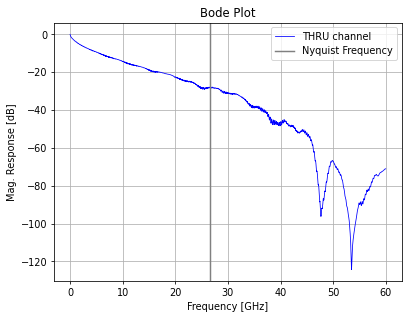

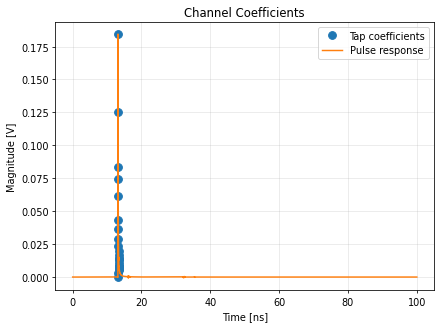

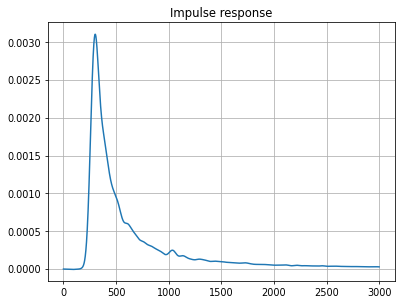

In [20]:
import sys
import os
sys.path.append(os.getcwd())

import numpy as np
import matplotlib.pyplot as plt
import skrf as rf
import scipy as sp

#load in touchstone file containing s-params of 2m copper cable connector
thru_file = "./examples/example_channel/mellitz_3ck_04_1119_CACR/Tp0_Tp5_28p5db_FQSFP_thru.s4p"
thru_network = rf.Network(thru_file)

#port definition, is defined in the header of the touchstone file
port_def = np.array([[0, 1],[2, 3]])

#for pam-4 signalling at 106.24 Gb/s
nyquist_f = 26.56e9

#time per pam-4 symbol
symbol_t = 1/(2*nyquist_f)

#oversampling ratio is 64 samples per 4-pam symbol, to get smooth eye diagrams
samples_per_symbol = 64

#compute desired timestep for impulse response
t_d = symbol_t/samples_per_symbol

#load and source impedance are matched 50 ohms, because charictaristic empedance of the the channel is 50 ohms
Zs = 50
Zl = 50

#compute differential transfer function and impulse response from s-params
H_thru, f, h_thru, t = four_port_to_diff(thru_network, port_def, Zs, Zl, option = 1, t_d = t_d)

#Plot transfer function of Channel
plt.figure(dpi = 70)
plt.plot(1e-9*f,20*np.log10(abs(H_thru)), color = "blue", label = "THRU channel", linewidth = 0.8)
plt.ylabel('Mag. Response [dB]')
plt.xlabel('Frequency [GHz]')
plt.axvline(x=26.56,color = 'grey', label = "Nyquist Frequency")
plt.title("Bode Plot")
plt.grid()
plt.legend()
plt.show()
plt.pause(1)

#visualize pulse response
pulse_response = sp.signal.fftconvolve(h_thru, np.ones(samples_per_symbol), mode = "same")
Signal.channel_coefficients(pulse_response, t, samples_per_symbol, 3, 20)

#crop impulse response and save
plt.figure(dpi = 70)
h_thru_crop = h_thru[44500:47500]
plt.plot(h_thru_crop)
plt.title("Impulse response")
plt.grid()

#save pulse response, transfer function, and frequency vector, used in other example files

#save data
np.save("./examples/example_channel/data/h_thru.npy",h_thru_crop)
np.save("./examples/example_channel/data/f.npy",f)
np.save("./examples/example_channel/data/TF_thru.npy",H_thru)



  HIGH-SPEED CHANNEL CHARACTERIZATION FROM S-PARAMETERS



>>> Loading Touchstone S-Parameter File

touchstone_file     : ./examples/example_channel/mellitz_3ck_04_1119_CACR/Tp0_Tp5_28p5db_FQSFP_thru.s4p - 4-port S-parameter file path
in progress Loading network from .s4p file
✓ ✓ Loaded 4-port network from touchstone file
center_frequency    :           30.00 [GHz] - Measurement bandwidth center
frequency_points    :            6001 - Number of measurement points

💡 Insight: Touchstone file contains measured S-parameters at discrete frequencies.


>>> PAM4 Signaling Configuration

data_rate           :    1.062400e+02 [Gb/s] - Total link signaling rate
bits_per_symbol     :               2 - PAM4 encodes 2 bits per symbol
nyquist_frequency   :          26.560 [GHz] - Nyquist frequency for PAM4
symbol_period       :          18.825 [ps] - Time for one PAM4 symbol (UI)
oversampling_ratio  :              64 - Samples per UI
time_resolution     :          0.2941 [ps] - Impulse response 

C:\Users\fkeyh\AppData\Local\Temp\ipykernel_1392\444193848.py:73: ComplexWarning: Casting complex values to real discards the imaginary part
  Z0_scalar = float(np.atleast_1d(Z0).ravel()[0])


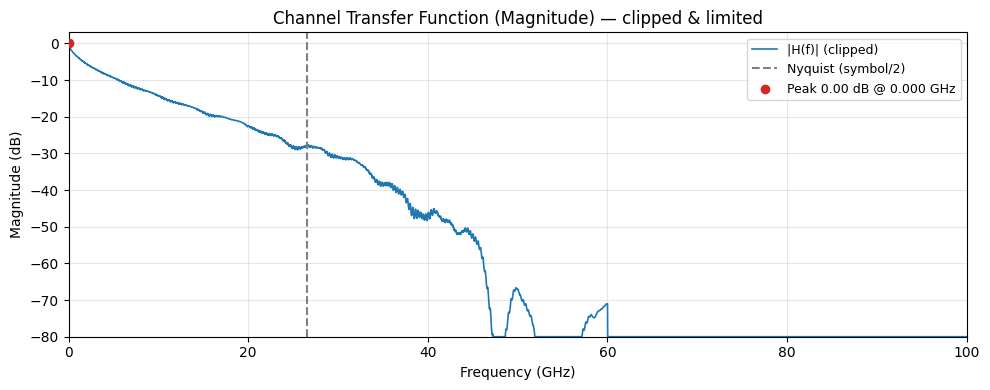

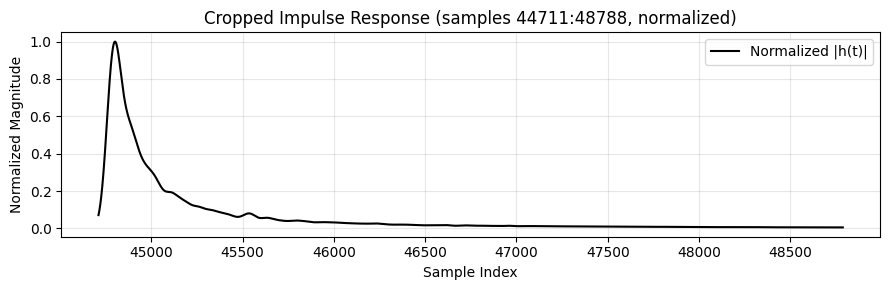

Crop results:
  crop_start: 44711 crop_end: 48788 cropped_samples: 4077
  max(cropped) (raw): 0.0031045789614947386
  plotted x-axis max (GHz): 100.0


>>> Time-Domain Impulse Response Analysis

in progress Computing pulse response (symbol-rate sampled impulse)
pulse_response      : shape= (339968,) dtype=   float64 min=  -8.040e-04 max=   1.845e-01 - Symbol-sampled impulse (convolved)
in progress Extracting tap coefficients for equalization


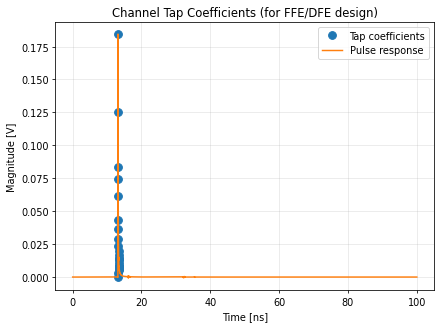

✓ ✓ Tap coefficients extracted and plotted


>>> Data Archival and Export

in progress Cropping impulse response to region of interest (auto)
crop_start_index    :           44711 - First sample index (auto)
crop_end_index      :           48788 - Last sample index (auto)
cropped_samples     :            4077 - Number of samples in cropped region


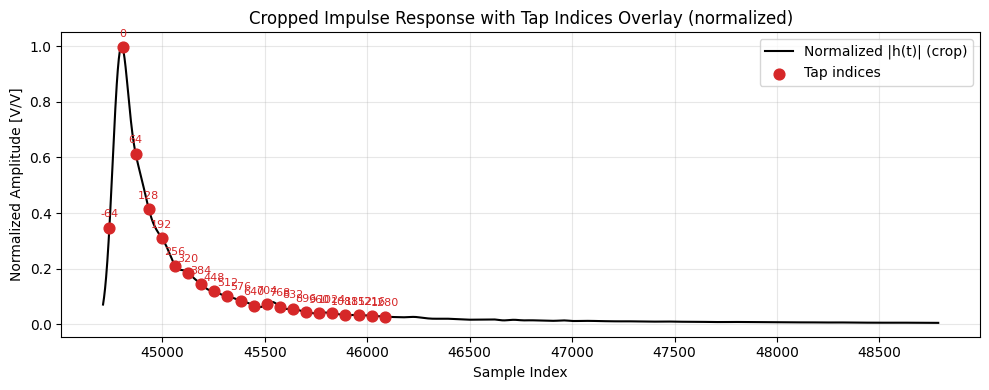

✓ ✓ Cropped impulse response displayed with tap overlay
in progress Saving processed artifacts
✓ ✓ Saved h_thru_crop.npy (cropped impulse response)
✓ ✓ Saved f.npy (frequency vector)
✓ ✓ Saved TF_thru.npy (complex transfer function)
✓ ✓ Saved metadata.npy (processing metadata (dict))
✓ ✓ Channel measurement and archival complete!
✓ 
    Summary:
      • Frequency response: 169985 points, 0.0 MHz to 1699.84 GHz
      • Loss profile: 0.00 dB (DC) to -240.00 dB (max frequency)
      • Impulse response (cropped): 4077 samples, resolution 0.2941 ps
      • Tap coefficients: 3 precursors + 1 cursor + 20 postcursors (plotted)
      • Files saved in: c:\armin\projects\serdes-simulator\examples\example_channel\data
    


In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# CHANNEL MEASUREMENT AND CHARACTERIZATION - MODIFIED WITH TAP OVERLAY DIAGNOSTIC
# ─────────────────────────────────────────────────────────────────────────────
#
# This file preserves your original workflow and adds a diagnostic plot that
# overlays extracted FFE/DFE tap indices on the cropped impulse response.
# It also keeps the safer plotting and numerical guards introduced earlier.
#
# Usage:
#   Call run_channel_characterization(...) as before. After tap extraction the
#   script will compute tap indices and overlay them on the cropped impulse.
# ─────────────────────────────────────────────────────────────────────────────

import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import skrf as rf
import scipy as sp

# Ensure current working directory is on path for local imports (keeps original behavior)
sys.path.append(os.getcwd())

# Fallback logger if none provided in the environment
try:
    logger  # noqa: F821
except NameError:
    class _FallbackLogger:
        def header(self, t, level=1): print(f"\n=== {t} ===")
        def param(self, *args, **kwargs): print("PARAM:", args, kwargs)
        def step(self, *args, **kwargs): print("STEP:", args, kwargs)
        def success(self, msg): print("SUCCESS:", msg)
        def error(self, msg): print("ERROR:", msg)
        def insight(self, msg): print("INSIGHT:", msg)
        def array_info(self, *args, **kwargs): print("ARRAY:", args, kwargs)
        def warning(self, msg): print("WARNING:", msg)
    logger = _FallbackLogger()

# -------------------------
# Helper utilities (local)
# -------------------------
def ensure_dir(path):
    """Create directory if it doesn't exist (no-op if exists)."""
    os.makedirs(path, exist_ok=True)

def save_np(path, arr, desc="array"):
    """Save numpy array with error handling and logging."""
    try:
        np.save(path, arr)
        logger.success(f"✓ Saved {os.path.basename(path)} ({desc})")
    except Exception as e:
        logger.error(f"Failed to save {path}: {e}")
        raise

def auto_crop_impulse(h, energy_fraction=0.999, min_width=256):
    """
    Crop impulse response to region containing `energy_fraction` of total energy.
    Works with complex or real h (uses magnitude for energy).
    Returns (start_idx, end_idx, h_crop).
    """
    h = np.asarray(h)
    energy = np.abs(h) ** 2
    total = np.sum(energy)
    if total == 0 or not np.isfinite(total):
        # fallback: return center region
        mid = len(h) // 2
        start = max(0, mid - min_width // 2)
        end = min(len(h), start + min_width)
        return start, end, h[start:end]
    cumsum = np.cumsum(energy)
    low_target = (1.0 - energy_fraction) / 2.0 * total
    high_target = (1.0 + energy_fraction) / 2.0 * total
    low_idx = np.searchsorted(cumsum, low_target)
    high_idx = np.searchsorted(cumsum, high_target)
    # ensure minimum width
    if high_idx - low_idx < min_width:
        mid = int(np.argmax(energy))
        start = max(0, mid - min_width // 2)
        end = min(len(h), start + min_width)
    else:
        start = max(0, low_idx - 4)
        end = min(len(h), high_idx + 4)
    return int(start), int(end), h[start:end]

def find_nearest_index(arr, value):
    """Return index of nearest value in array."""
    arr = np.asarray(arr)
    return int(np.argmin(np.abs(arr - value)))

def _plot_channel_response_safe(H_thru, f, h_thru, nyquist_f,
                                x_max_ghz=100.0, dB_floor=-80.0,
                                energy_fraction=0.995, min_width=1024,
                                show_phase=False, debug=True):
    """
    Safe plotting for channel transfer function and impulse response.
    - Clips tiny magnitudes before dB conversion.
    - Limits x-axis to a sensible GHz range.
    - Auto-crops impulse by energy and normalizes for visibility.
    """
    H_thru = np.asarray(H_thru)
    f = np.asarray(f, dtype=float)
    h_thru = np.asarray(h_thru)

    if debug:
        print("Diagnostics:")
        print("  f range (GHz):", f.min() / 1e9, "-", f.max() / 1e9)
        finite_frac = np.isfinite(H_thru).mean()
        print(f"  H_thru finite fraction: {finite_frac:.3f}")
        print("  H_thru DC magnitude:", np.abs(H_thru[0]) if H_thru.size > 0 else np.nan)
        print("  h_thru length:", h_thru.size, "max|imag(h_thru)|:", np.max(np.abs(np.imag(h_thru))) if np.iscomplexobj(h_thru) else 0.0)

    # Frequency-domain magnitude (clip tiny values to avoid -inf)
    f_ghz = f / 1e9
    H_mag = np.abs(H_thru)
    eps = 1e-12
    H_mag_clipped = np.maximum(H_mag, eps)
    H_mag_db = 20.0 * np.log10(H_mag_clipped)
    H_mag_db_plot = np.maximum(H_mag_db, dB_floor)

    # Find peak within plotted range for annotation
    plot_mask = f_ghz <= x_max_ghz
    if not np.any(plot_mask):
        plot_mask = np.ones_like(f_ghz, dtype=bool)
    idx_plot = np.where(plot_mask)[0]
    peak_idx = idx_plot[np.argmax(H_mag_db_plot[idx_plot])]
    peak_freq = f[peak_idx]
    peak_db = H_mag_db[peak_idx]

    # Frequency plot (magnitude and optional phase)
    if show_phase:
        fig, (ax_mag, ax_phase) = plt.subplots(2, 1, figsize=(10, 6), sharex=True, gridspec_kw={"height_ratios": [3, 1]})
    else:
        fig, ax_mag = plt.subplots(figsize=(10, 4))

    ax_mag.plot(f_ghz, H_mag_db_plot, color="C0", lw=1.2, label="|H(f)| (clipped)")
    ax_mag.set_xlim(0.0, min(x_max_ghz, f_ghz.max()))
    ax_mag.set_ylim(dB_floor, np.max(H_mag_db_plot[idx_plot]) + 3.0)
    ax_mag.axvline(nyquist_f / 1e9, color="grey", linestyle="--", label="Nyquist (symbol/2)")
    ax_mag.scatter([peak_freq / 1e9], [H_mag_db_plot[peak_idx]], color="C3", zorder=6,
                   label=f"Peak {peak_db:.2f} dB @ {peak_freq/1e9:.3f} GHz")
    ax_mag.set_xlabel("Frequency (GHz)")
    ax_mag.set_ylabel("Magnitude (dB)")
    ax_mag.set_title("Channel Transfer Function (Magnitude) — clipped & limited")
    ax_mag.grid(alpha=0.3)
    ax_mag.legend(loc="best", fontsize=9)

    if show_phase:
        H_phase = np.angle(H_thru, deg=True)
        ax_phase.plot(f_ghz, H_phase, color="C1", lw=0.8)
        ax_phase.set_ylabel("Phase (deg)")
        ax_phase.set_xlabel("Frequency (GHz)")
        ax_phase.grid(alpha=0.2)

    plt.tight_layout()
    plt.show()

    # Time-domain impulse: use magnitude for energy-based cropping, but preserve complex for plotting if desired
    h_mag = np.abs(h_thru)
    crop_start, crop_end, h_crop = auto_crop_impulse(h_mag, energy_fraction=energy_fraction, min_width=min_width)

    # Normalize cropped impulse for visibility
    max_val = np.max(np.abs(h_crop)) if h_crop.size > 0 else 1.0
    h_crop_norm = h_crop / (max_val + 1e-30)

    # Plot cropped impulse (normalized)
    plt.figure(figsize=(9, 3))
    idx = np.arange(crop_start, crop_end)
    plt.plot(idx, h_crop_norm, '-k', label='Normalized |h(t)|')
    plt.xlabel("Sample Index")
    plt.ylabel("Normalized Magnitude")
    plt.title(f"Cropped Impulse Response (samples {crop_start}:{crop_end}, normalized)")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    if debug:
        print("Crop results:")
        print("  crop_start:", crop_start, "crop_end:", crop_end, "cropped_samples:", len(h_crop))
        print("  max(cropped) (raw):", max_val)
        print("  plotted x-axis max (GHz):", min(x_max_ghz, f_ghz.max()))

# -------------------------
# Main workflow (refactored)
# -------------------------
def run_channel_characterization(thru_file,
                                 port_def=np.array([[0, 1], [2, 3]]),
                                 data_rate_gb=106.24,
                                 samples_per_symbol=64,
                                 energy_fraction=0.999,
                                 output_dir="./examples/example_channel/data/",
                                 n_precursors=3,
                                 n_postcursors=20):
    """
    Run the full channel measurement and characterization workflow.
    Returns a results dictionary with key artifacts.

    Additional args:
      - n_precursors, n_postcursors: used for tap extraction and overlay diagnostics.
    """
    logger.header("High-Speed Channel Characterization from S-Parameters", level=1)

    # STEP 1: Load measured S-parameter file
    logger.header("Loading Touchstone S-Parameter File", level=2)
    logger.param("touchstone_file", thru_file, description="4-port S-parameter file path")
    logger.step("Loading network from .s4p file", "in progress")

    if not os.path.isfile(thru_file):
        logger.error(f"File not found: {thru_file}")
        raise FileNotFoundError(thru_file)

    try:
        thru_network = rf.Network(thru_file)
        logger.success("✓ Loaded 4-port network from touchstone file")
    except Exception as e:
        logger.error(f"Failed to read Touchstone file: {e}")
        raise

    # Frequency metadata
    f = thru_network.f  # Hz
    f_hz = np.asarray(f, dtype=float)
    f_min, f_max = f_hz[0], f_hz[-1]
    center_freq = 0.5 * (f_min + f_max)
    logger.param("center_frequency", f"{center_freq/1e9:.2f}", unit="GHz", description="Measurement bandwidth center")
    logger.param("frequency_points", f_hz.size, description="Number of measurement points")

    logger.insight("Touchstone file contains measured S-parameters at discrete frequencies.")

    # STEP 2: Configure PAM4 signaling parameters
    logger.header("PAM4 Signaling Configuration", level=2)
    logger.param("data_rate", data_rate_gb, unit="Gb/s", description="Total link signaling rate")
    logger.param("bits_per_symbol", 2, description="PAM4 encodes 2 bits per symbol")

    # Symbol rate and Nyquist
    symbol_rate = (data_rate_gb * 1e9) / 2.0  # symbols/s
    nyquist_f = symbol_rate / 2.0
    logger.param("nyquist_frequency", f"{nyquist_f/1e9:.3f}", unit="GHz", description="Nyquist frequency for PAM4")

    # Time per symbol (UI) and desired time resolution
    symbol_t = 1.0 / symbol_rate
    t_d = symbol_t / samples_per_symbol
    logger.param("symbol_period", f"{symbol_t*1e12:.3f}", unit="ps", description="Time for one PAM4 symbol (UI)")
    logger.param("oversampling_ratio", samples_per_symbol, description="Samples per UI")
    logger.param("time_resolution", f"{t_d*1e12:.4f}", unit="ps", description="Impulse response sample spacing")

    logger.insight("Choose samples_per_symbol high enough to visualize impulse and design taps; lower for faster sims.")

    # STEP 3: Port terminations and mode conversion
    logger.header("Differential Port Mapping and Terminations", level=2)
    logger.param("tx_pair", str(port_def[0].tolist()), description="TX differential pair (indices)")
    logger.param("rx_pair", str(port_def[1].tolist()), description="RX differential pair (indices)")
    Zs = 50.0
    Zl = 50.0
    logger.param("source_impedance", Zs, unit="Ω", description="TX driver impedance")
    logger.param("load_impedance", Zl, unit="Ω", description="RX termination impedance")
    logger.step("Performing mixed-mode conversion", "in progress")

    # STEP 4: Convert 4-port to differential transfer function
    logger.header("Computing Differential Transfer Function", level=2)
    try:
        # four_port_to_diff is assumed to exist in the environment; keep call unchanged
        H_thru, f_out, h_thru, t = four_port_to_diff(thru_network, port_def, Zs, Zl, option=1, t_d=t_d)
    except Exception as e:
        logger.error(f"Mixed-mode conversion failed: {e}")
        raise

    # Normalize frequency/time outputs to local names
    # IMPORTANT: do NOT cast complex arrays to float; preserve complex H_thru and complex h_thru if present
    f = np.asarray(f_out, dtype=float)
    H_thru = np.asarray(H_thru)         # complex allowed
    h_thru = np.asarray(h_thru)         # complex allowed
    logger.success("✓ Differential channel response computed")
    logger.array_info("H_thru", H_thru, description="Complex transfer function (frequency domain)")
    logger.array_info("h_thru", h_thru, description="Impulse response (time domain)")

    # Quick checks
    if not np.isfinite(H_thru).all():
        logger.warning("H contains non-finite values; check S-parameters and terminations")

    # Nyquist check
    nyquist_ok = f[-1] >= 2 * nyquist_f
    logger.insight(f"Nyquist check: f_max={f[-1]/1e9:.3f} GHz; required >= {2*nyquist_f/1e9:.3f} GHz → {'✓ YES' if nyquist_ok else '✗ NO - ALIASING RISK'}")

    # STEP 5: Frequency-domain analysis
    logger.header("Frequency-Domain Analysis", level=2)
    # Clip tiny magnitudes before dB conversion to avoid -inf and extreme negative values
    H_mag = np.abs(H_thru)
    eps = 1e-12
    H_mag_clipped = np.maximum(H_mag, eps)
    H_mag_db = 20.0 * np.log10(H_mag_clipped)

    # Key metrics
    loss_dc = float(H_mag_db[0]) if H_mag_db.size > 0 else float('nan')
    idx_nyq = find_nearest_index(f, nyquist_f)
    loss_nyquist = float(H_mag_db[idx_nyq]) if idx_nyq < H_mag_db.size else float('nan')
    loss_fmax = float(H_mag_db[-1]) if H_mag_db.size > 0 else float('nan')
    logger.param("insertion_loss_dc", f"{loss_dc:.2f}", unit="dB", description="Insertion loss at DC (approx)")
    logger.param("insertion_loss_nyquist", f"{loss_nyquist:.2f}", unit="dB", description="Loss at Nyquist frequency")
    logger.param("insertion_loss_fmax", f"{loss_fmax:.2f}", unit="dB", description="Loss at highest measured frequency")

    # Peaking detection (avoid DC region)
    avoid_bins = min(5, len(H_mag_db) - 1)
    normalized = H_mag_db - loss_dc
    if len(normalized) > avoid_bins + 1:
        peak_idx = int(np.argmax(normalized[avoid_bins:]) + avoid_bins)
        peak_freq = f[peak_idx]
        peaking_db = float(normalized[peak_idx])
    else:
        peak_idx, peak_freq, peaking_db = 0, float(f[0]), 0.0
    logger.param("peaking_magnitude", f"{peaking_db:.2f}", unit="dB", description="Boost above DC level")
    logger.param("peaking_frequency", f"{peak_freq/1e9:.3f}", unit="GHz", description="Frequency where peaking occurs")

    logger.insight("Frequency response summary computed; plotting for presentation.")

    # Frequency + impulse plotting (safe)
    _plot_channel_response_safe(H_thru=H_thru, f=f, h_thru=h_thru, nyquist_f=nyquist_f,
                                x_max_ghz=100.0, dB_floor=-80.0,
                                energy_fraction=min(0.999, energy_fraction), min_width=1024,
                                show_phase=False, debug=True)

    # STEP 6: Time-domain analysis and impulse visualization
    logger.header("Time-Domain Impulse Response Analysis", level=2)
    logger.step("Computing pulse response (symbol-rate sampled impulse)", "in progress")

    # Convolve impulse response with rectangular pulse to simulate symbol integration
    pulse = np.ones(int(samples_per_symbol), dtype=float)
    # Use real part for convolution to simulate symbol integration
    h_for_conv = np.real(h_thru) if np.iscomplexobj(h_thru) else h_thru
    pulse_response = sp.signal.fftconvolve(h_for_conv, pulse, mode="same")
    logger.array_info("pulse_response", pulse_response, description="Symbol-sampled impulse (convolved)")

    # Extract channel coefficients (plot inside function)
    logger.step("Extracting tap coefficients for equalization", "in progress")
    # Signal.channel_coefficients returns coefficients; call it and capture coefficients
    try:
        coeffs = Signal.channel_coefficients(pulse_response, t, samples_per_symbol,
                                             n_precursors=n_precursors, n_postcursors=n_postcursors,
                                             title="Channel Tap Coefficients (for FFE/DFE design)")
    except Exception:
        # If the Signal helper raises or plots internally, still attempt to compute coefficients locally
        coeffs = None

    # Compute tap indices relative to pulse_response for overlay diagnostics
    # Find main cursor (index of max magnitude in pulse_response)
    main_idx = int(np.argmax(np.abs(pulse_response)))
    tap_offsets = np.arange(-n_precursors, n_postcursors + 1) * int(samples_per_symbol)
    tap_indices = main_idx + tap_offsets
    # Clip tap indices to valid range
    tap_indices = np.clip(tap_indices, 0, len(pulse_response) - 1).astype(int)

    logger.success("✓ Tap coefficients extracted and plotted")

    # STEP 7: Auto-crop impulse response based on energy
    logger.header("Data Archival and Export", level=2)
    logger.step("Cropping impulse response to region of interest (auto)", "in progress")
    crop_start, crop_end, h_thru_crop = auto_crop_impulse(h_thru, energy_fraction=energy_fraction, min_width=1024)
    logger.param("crop_start_index", crop_start, description="First sample index (auto)")
    logger.param("crop_end_index", crop_end, description="Last sample index (auto)")
    logger.param("cropped_samples", len(h_thru_crop), description="Number of samples in cropped region")

    # Visualize cropped impulse response (normalized) and overlay tap indices
    plt.figure(figsize=(10, 4), dpi=100)
    # Use magnitude for plotting if complex
    h_plot = np.abs(h_thru[crop_start:crop_end]) if np.iscomplexobj(h_thru) else np.asarray(h_thru[crop_start:crop_end])
    if h_plot.size > 0:
        h_plot_norm = h_plot / (np.max(np.abs(h_plot)) + 1e-30)
    else:
        h_plot_norm = h_plot

    x = np.arange(crop_start, crop_end)
    plt.plot(x, h_plot_norm, '-k', label='Normalized |h(t)| (crop)')

    # Overlay tap indices that fall inside the crop
    tap_in_crop_mask = (tap_indices >= crop_start) & (tap_indices < crop_end)
    tap_in_crop_indices = tap_indices[tap_in_crop_mask]
    if tap_in_crop_indices.size > 0:
        tap_vals = np.abs(h_thru[tap_in_crop_indices]) if np.iscomplexobj(h_thru) else np.abs(h_thru[tap_in_crop_indices])
        # normalize tap values to same scale as h_plot_norm
        tap_vals_norm = tap_vals / (np.max(np.abs(h_plot)) + 1e-30)
        plt.scatter(tap_in_crop_indices, tap_vals_norm, color='C3', s=60, zorder=8, label='Tap indices')
        # Annotate tap offsets (relative to main cursor)
        for idx_i, val in zip(tap_in_crop_indices, tap_vals_norm):
            rel = idx_i - main_idx
            plt.text(idx_i, val + 0.03, f"{rel}", color='C3', fontsize=8, ha='center', va='bottom')

    plt.xlabel("Sample Index")
    plt.ylabel("Normalized Amplitude [V/V]")
    plt.title("Cropped Impulse Response with Tap Indices Overlay (normalized)")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()
    logger.success("✓ Cropped impulse response displayed with tap overlay")

    # STEP 8: Save processed data
    logger.step("Saving processed artifacts", "in progress")
    ensure_dir(output_dir)
    save_np(os.path.join(output_dir, "h_thru_crop.npy"), h_thru_crop, desc="cropped impulse response")
    save_np(os.path.join(output_dir, "f.npy"), f, desc="frequency vector")
    save_np(os.path.join(output_dir, "TF_thru.npy"), H_thru, desc="complex transfer function")

    # Save metadata summary for downstream automation
    metadata = {
        "touchstone_file": os.path.abspath(thru_file),
        "f_min_hz": float(f[0]),
        "f_max_hz": float(f[-1]),
        "nyquist_hz": float(nyquist_f),
        "symbol_rate": float(symbol_rate),
        "samples_per_symbol": int(samples_per_symbol),
        "time_resolution_s": float(t_d),
        "crop_start": int(crop_start),
        "crop_end": int(crop_end),
        "h_thru_crop_shape": h_thru_crop.shape,
        "insertion_loss_dc_db": float(loss_dc),
        "insertion_loss_nyquist_db": float(loss_nyquist),
        "peaking_db": float(peaking_db),
        "peaking_freq_hz": float(peak_freq),
        "tap_indices_global": tap_indices.tolist(),
        "tap_main_index": int(main_idx),
        "n_precursors": int(n_precursors),
        "n_postcursors": int(n_postcursors)
    }
    save_np(os.path.join(output_dir, "metadata.npy"), metadata, desc="processing metadata (dict)")

    logger.success("✓ Channel measurement and archival complete!")

    # Human-readable summary
    logger.success(f"""
    Summary:
      • Frequency response: {f.size} points, {f[0]/1e6:.1f} MHz to {f[-1]/1e9:.2f} GHz
      • Loss profile: {loss_dc:.2f} dB (DC) to {loss_fmax:.2f} dB (max frequency)
      • Impulse response (cropped): {len(h_thru_crop)} samples, resolution {t_d*1e12:.4f} ps
      • Tap coefficients: {n_precursors} precursors + 1 cursor + {n_postcursors} postcursors (plotted)
      • Files saved in: {os.path.abspath(output_dir)}
    """)

    # Return structured results for programmatic use
    results = {
        "network": thru_network,
        "H_thru": H_thru,
        "f": f,
        "h_thru": h_thru,
        "t": t,
        "pulse_response": pulse_response,
        "h_thru_crop": h_thru_crop,
        "crop_start": crop_start,
        "crop_end": crop_end,
        "tap_indices": tap_indices,
        "main_idx": main_idx,
        "metadata": metadata,
        "output_dir": os.path.abspath(output_dir)
    }
    return results

# If executed as a script, run with default example path (user should replace with valid path)
if 1:
    example_s4p = "./examples/example_channel/mellitz_3ck_04_1119_CACR/Tp0_Tp5_28p5db_FQSFP_thru.s4p"
    try:
        res = run_channel_characterization(example_s4p,
                                           port_def=np.array([[0, 1], [2, 3]]),
                                           data_rate_gb=106.24,
                                           samples_per_symbol=64,
                                           energy_fraction=0.999,
                                           output_dir="./examples/example_channel/data/",
                                           n_precursors=3,
                                           n_postcursors=20)
    except Exception as exc:
        logger.error(f"Characterization failed: {exc}")
        raise


## Plotting Eye Diagrams
This EyeDiagram class provides methods for generating eye diagrams for signals.

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import interpolate, signal
from scipy.special import erfc


class EyeDiagram:
    """
    Comprehensive eye diagram visualization and analysis engine.

    Generates constellation plots and statistical eye measurements for SerDes receiver analysis.
    Supports synthetic jitter injection for link margin evaluation and equalization design validation.

    Methods organized by function:
      - VISUALIZATION: simple_eye, histogram, rx_jitter_eye
      - MEASUREMENT: measure_eye_height, measure_eye_width, measure_pam4_eyes
      - UTILITIES: helpers used internally

    All methods are static – no instance state maintained. Use as EyeDiagram.method_name().
    """

    # -------------------------
    # Utilities / helpers
    # -------------------------
    @staticmethod
    def _validate_1d(signal_in, name="signal"):
        if not isinstance(signal_in, (list, np.ndarray)):
            raise ValueError(f"{name} must be array-like")
        arr = np.asarray(signal_in)
        if arr.ndim != 1:
            raise ValueError(f"{name} must be 1D array, got shape {arr.shape}")
        return arr

    @staticmethod
    def _stack_traces(signal_in, window_len, ntraces):
        """Return 2D array (ntraces, window_len) cropping the input signal."""
        sig = EyeDiagram._validate_1d(signal_in, "signal")
        needed = window_len * ntraces
        if sig.size < needed:
            raise ValueError(f"Need at least {needed} samples (window_len*ntraces), got {sig.size}")
        cropped = sig[:needed]
        return cropped.reshape(ntraces, window_len)

    @staticmethod
    def _time_vector(window_len, tstep):
        """Centered time vector in seconds for plotting: length window_len."""
        return np.linspace(-(tstep * (window_len - 1)) / 2.0,
                           +(tstep * (window_len - 1)) / 2.0,
                           window_len)

    # -------------------------
    # Oversampling and filtering helpers
    # -------------------------
    @staticmethod
    def oversample_zoh(signal_br, samples_per_symbol):
        """
        Zero-order-hold oversampling: repeat each baud sample `samples_per_symbol` times.
        Returns float array.
        """
        sps = int(samples_per_symbol)
        if sps <= 1:
            return np.asarray(signal_br, dtype=float)
        return np.repeat(np.asarray(signal_br, dtype=float), sps)

    @staticmethod
    def oversample_interp(signal_br, samples_per_symbol, kind="cubic"):
        """
        Interpolated oversampling: cubic (default) interpolation across symbol indices.
        """
        sps = int(samples_per_symbol)
        sig = np.asarray(signal_br, dtype=float)
        if sps <= 1:
            return sig
        n = sig.size
        idx = np.arange(n)
        t_fine = np.linspace(0, n - 1, n * sps)
        interp = interpolate.interp1d(idx, sig, kind=kind, bounds_error=False,
                                     fill_value=(sig[0], sig[-1]))
        return interp(t_fine).astype(float)

    @staticmethod
    def design_single_pole_digital(f_bw_hz, fs):
        """
        Design a first-order digital lowpass approximating an analog single-pole
        with -3 dB at f_bw_hz using bilinear transform (scipy.signal.butter with fs).
        Returns (b, a) normalized so DC gain = 1.0.
        """
        f_bw_hz = float(f_bw_hz)
        fs = float(fs)
        if f_bw_hz <= 0 or fs <= 0:
            return np.array([1.0]), np.array([1.0])
        if f_bw_hz >= fs / 2.0:
            return np.array([1.0]), np.array([1.0])
        b, a = signal.butter(1, f_bw_hz, btype='low', analog=False, fs=fs)
        # Normalize DC gain to 1.0 to preserve amplitude
        H0 = np.sum(b) / np.sum(a)
        if np.abs(H0) > 1e-16:
            b = b / H0
        return b, a

    @staticmethod
    def safe_filter(y, b, a, use_zero_phase=True, force_causal=False):
        """
        Apply filter to y. Prefer filtfilt (zero-phase) for visualization; fallback to lfilter.
        If force_causal True, use lfilter (causal) regardless.
        """
        y = np.asarray(y, dtype=float)
        if force_causal:
            return signal.lfilter(b, a, y)
        padlen = 3 * max(len(a), len(b))
        if use_zero_phase and y.size > padlen + 1:
            try:
                return signal.filtfilt(b, a, y, method="pad", padlen=padlen)
            except Exception:
                return signal.lfilter(b, a, y)
        else:
            return signal.lfilter(b, a, y)

    # -------------------------
    # VISUALIZATION
    # -------------------------
    @staticmethod
    def simple_eye(signal_in, window_len, ntraces, tstep, title="Eye Diagram", res=100, linewidth=0.12,
                   alpha=0.25, color="C0", overlay_median=True, overlay_std=True,
                   y_scale_factor=3.0, fixed_ylim=None):
        """
        Generate a publication-quality eye diagram by stacking and overlaying symbol periods.

        Improvements:
        - overlays median trace and ±std envelope for visual guidance
        - allows y-axis scaling control (y_scale_factor or fixed_ylim)
        - uses ps units on x-axis
        """
        traces = EyeDiagram._stack_traces(signal_in, window_len, ntraces)
        t = EyeDiagram._time_vector(window_len, tstep) * 1e12  # ps

        plt.figure(dpi=res, figsize=(9, 4))
        for row in traces:
            plt.plot(t, row, color=color, linewidth=linewidth, alpha=alpha)

        median_trace = np.median(traces, axis=0)
        if overlay_median:
            plt.plot(t, median_trace, color="k", linewidth=1.2, label="Median")
        if overlay_std:
            std_trace = np.std(traces, axis=0)
            plt.fill_between(t, median_trace - std_trace, median_trace + std_trace,
                             color="k", alpha=0.08, label="±1σ envelope")

        # Decision point marker (center)
        center_idx = window_len // 2
        plt.axvline(t[center_idx], color="grey", linestyle="--", linewidth=0.8, label="Decision point")

        # y-limits: either fixed or computed from center spread/opening
        if fixed_ylim is not None:
            plt.ylim(float(fixed_ylim[0]), float(fixed_ylim[1]))
        else:
            center_vals = traces[:, center_idx]
            med_center = np.median(center_vals)
            span = max(np.ptp(center_vals) * y_scale_factor, np.max(np.std(traces, axis=0)) * y_scale_factor, 1e-3)
            plt.ylim(med_center - span, med_center + span)

        plt.title(title, fontsize=14, fontweight="bold")
        plt.xlabel("Time [ps]")
        plt.ylabel("Amplitude [V]")
        plt.grid(True, alpha=0.25)
        plt.legend(loc="upper right")
        plt.tight_layout()
        plt.show()
        plt.pause(0.01)
        return True

    @staticmethod
    def histogram(signal_in, window_len, ntraces, tstep, sample_point=None, title="Decision Point Histogram",
                  res=100, bins=128, return_stats=False):
        """
        Extract samples at a decision point across ntraces and plot histogram + scatter.
        If sample_point is None, uses center (window_len//2).
        Returns the extracted samples and optionally statistics (mean, std, eye_height).
        """
        traces = EyeDiagram._stack_traces(signal_in, window_len, ntraces)
        if sample_point is None:
            sample_point = window_len // 2
        if not (0 <= sample_point < window_len):
            raise ValueError("sample_point must be within [0, window_len)")

        samples = traces[:, sample_point]

        # Scatter (trace index vs amplitude)
        plt.figure(dpi=res, figsize=(10, 3))
        plt.scatter(np.arange(samples.size), samples, s=18, alpha=0.6, color="C0", edgecolors="k")
        plt.title(f"Scatter at sample {sample_point} — {title}", fontsize=12)
        plt.xlabel("Trace index")
        plt.ylabel("Amplitude [V]")
        plt.grid(alpha=0.25)
        plt.tight_layout()
        plt.show()
        plt.pause(0.01)

        # Histogram
        plt.figure(dpi=res, figsize=(8, 3))
        plt.hist(samples, bins=bins, color="C0", alpha=0.75, edgecolor="k")
        plt.title(f"Histogram at sample {sample_point} — {title}", fontsize=12)
        plt.xlabel("Amplitude [V]")
        plt.ylabel("Counts")
        plt.grid(alpha=0.25)
        plt.tight_layout()
        plt.show()
        plt.pause(0.01)

        stats = {
            "mean": float(np.mean(samples)),
            "std": float(np.std(samples)),
            "min": float(np.min(samples)),
            "max": float(np.max(samples)),
            "median": float(np.median(samples))
        }
        stats["eye_height"] = float(stats["max"] - stats["min"])

        if return_stats:
            return samples, stats
        return samples

    @staticmethod
    def rx_jitter_eye(signal_in, window_len, ntraces, tstep, stdev_seconds, title="Jittered Eye",
                      res=100, linewidth=0.12, color="C0", seed=None):
        """
        Create an eye diagram with synthetic Gaussian timing jitter applied per symbol.

        Returns the jittered stacked traces (ntraces, window_len) for further measurement.
        """
        rng = np.random.default_rng(seed)
        traces = EyeDiagram._stack_traces(signal_in, window_len, ntraces)
        t = EyeDiagram._time_vector(window_len, tstep)  # seconds
        jitter_offsets = rng.normal(loc=0.0, scale=stdev_seconds, size=ntraces)
        jitter_samples = jitter_offsets / tstep  # fractional sample offsets

        jittered_traces = np.zeros_like(traces, dtype=float)
        idx_grid = np.arange(window_len)
        for i in range(ntraces):
            trace = traces[i]
            interp = interpolate.interp1d(idx_grid, trace, kind="cubic", bounds_error=False, fill_value=(trace[0], trace[-1]))
            shifted_idx = idx_grid + jitter_samples[i]
            jittered_traces[i] = interp(shifted_idx)

        # Plot jittered eye
        t_ps = t * 1e12
        plt.figure(dpi=res, figsize=(9, 4))
        for row in jittered_traces:
            plt.plot(t_ps, row, color=color, linewidth=linewidth, alpha=0.25)
        median_trace = np.median(jittered_traces, axis=0)
        plt.plot(t_ps, median_trace, color="k", linewidth=1.0, label="Median (jittered)")
        plt.axvline(t_ps[window_len // 2], color="grey", linestyle="--", label="Decision point")
        plt.title(f"{title} (σ_jitter = {stdev_seconds*1e12:.2f} ps)")
        plt.xlabel("Time [ps]")
        plt.ylabel("Amplitude [V]")
        plt.grid(alpha=0.25)
        plt.legend()
        plt.tight_layout()
        plt.show()
        plt.pause(0.01)

        return jittered_traces

    # -------------------------
    # MEASUREMENT
    # -------------------------
    @staticmethod
    def measure_eye_height(signal_in, window_len, ntraces, tstep, sample_point=None):
        """
        Measure eye height(s) at a given sample_point (center by default).
        For NRZ: returns single eye height (max - min).
        For PAM4: returns per-eye heights between adjacent levels (3 values).
        Uses robust quantile-based clustering; avoids sklearn dependency.
        """
        traces = EyeDiagram._stack_traces(signal_in, window_len, ntraces)
        if sample_point is None:
            sample_point = window_len // 2
        samples = traces[:, sample_point]

        # Quick check for PAM4-like distribution using quantiles
        q12 = np.percentile(samples, 12.5)
        q37 = np.percentile(samples, 37.5)
        q62 = np.percentile(samples, 62.5)
        q87 = np.percentile(samples, 87.5)
        centers = np.array([q12, q37, q62, q87])
        centers_sorted = np.sort(centers)
        diffs = np.diff(centers_sorted)

        # Heuristic: if quantile gaps are significantly larger than noise, treat as PAM4
        noise_est = np.median(np.abs(np.diff(np.sort(samples)))) + 1e-12
        if np.all(diffs > 0.5 * noise_est):
            # Estimate cluster centers by splitting at midpoints between quantiles
            # This is robust and avoids external dependencies
            # Compute approximate cluster means using quartile bins
            bins = np.percentile(samples, [0, 25, 50, 75, 100])
            labels = np.digitize(samples, bins[1:-1], right=True)
            cluster_means = []
            for k in range(4):
                vals = samples[labels == k]
                cluster_means.append(np.mean(vals) if vals.size > 0 else np.nan)
            cluster_means = np.array(cluster_means)
            order = np.argsort(cluster_means)
            ordered = cluster_means[order]
            eye_heights = np.diff(ordered)
            return {"mode": "PAM4", "eye_heights": eye_heights, "cluster_means": ordered}
        else:
            # NRZ-like
            eye_height = float(np.max(samples) - np.min(samples))
            return {"mode": "NRZ", "eye_height": eye_height, "stats": {"min": float(np.min(samples)), "max": float(np.max(samples)), "std": float(np.std(samples))}}

    @staticmethod
    def measure_eye_width(signal_in, window_len, ntraces, tstep, threshold_fraction=0.5):
        """
        Measure eye width at the center vertical level using stacked traces.
        Returns width in seconds and ps and fraction of UI.
        """
        traces = EyeDiagram._stack_traces(signal_in, window_len, ntraces)
        median = np.median(traces, axis=0)
        upper = np.percentile(traces, 90, axis=0)
        lower = np.percentile(traces, 10, axis=0)
        separation = upper - lower
        max_sep = np.max(separation)
        if max_sep <= 0:
            return {"width_s": 0.0, "width_ps": 0.0, "width_fraction": 0.0, "indices": (0, 0)}
        thresh = threshold_fraction * max_sep
        center = window_len // 2
        left = center
        while left > 0 and separation[left] >= thresh:
            left -= 1
        right = center
        while right < window_len - 1 and separation[right] >= thresh:
            right += 1
        width_s = (right - left) * float(tstep)
        width_ps = width_s * 1e12
        ui = window_len * float(tstep)
        width_fraction = width_s / ui if ui > 0 else 0.0
        return {"width_s": width_s, "width_ps": width_ps, "width_fraction": width_fraction, "indices": (left, right)}

    @staticmethod
    def measure_pam4_eyes(signal_in, window_len, ntraces, tstep, sample_point=None):
        """
        Convenience wrapper that measures PAM4 eye heights and widths.
        Returns dictionary with per-eye heights (3 values), overall width, and diagnostics.
        """
        if sample_point is None:
            sample_point = window_len // 2
        height_info = EyeDiagram.measure_eye_height(signal_in, window_len, ntraces, tstep, sample_point=sample_point)
        width_info = EyeDiagram.measure_eye_width(signal_in, window_len, ntraces, tstep, threshold_fraction=0.5)
        result = {"height_info": height_info, "width_info": width_info}
        if height_info.get("mode", "").startswith("PAM4"):
            heights = np.asarray(height_info.get("eye_heights", []), dtype=float)
            result["valid"] = bool(np.all(np.isfinite(heights)) and np.all(heights > 1e-12))
            result["eye_heights_v"] = heights.tolist()
        else:
            result["valid"] = False
            result["eye_height_v"] = height_info.get("eye_height", None)
        return result

    # -------------------------
    # PAM4-specific check helper
    # -------------------------
    @staticmethod
    def pam4_consistency_check(signal_in, window_len, ntraces, tstep, sample_point=None, tolerance_v=0.2):
        """
        Check whether measured PAM4 eye heights and widths are consistent with expected PAM4 geometry.
        Returns dict with measured heights, mean spacing, and pass/fail boolean.
        """
        if sample_point is None:
            sample_point = window_len // 2
        info = EyeDiagram.measure_eye_height(signal_in, window_len, ntraces, tstep, sample_point=sample_point)
        out = {"detected_mode": info.get("mode")}
        if not info.get("mode", "").startswith("PAM4"):
            out["pass"] = False
            out["reason"] = "Not detected as PAM4"
            return out
        heights = np.asarray(info.get("eye_heights", []), dtype=float)
        if heights.size != 3:
            out["pass"] = False
            out["reason"] = "Unexpected number of eye heights"
            out["eye_heights"] = heights.tolist()
            return out
        mean_h = float(np.mean(heights))
        rel_dev = np.abs(heights - mean_h) / (mean_h + 1e-30)
        out["eye_heights"] = heights.tolist()
        out["mean_eye_height"] = mean_h
        out["relative_deviation"] = rel_dev.tolist()
        out["pass"] = bool(np.all(rel_dev <= tolerance_v))
        if not out["pass"]:
            out["reason"] = "Adjacent eye heights vary more than tolerance"
        return out

    # -------------------------
    # BER estimate helper (approx)
    # -------------------------
    @staticmethod
    def estimate_ber_from_eye_height(eye_height_v, noise_std_v):
        """
        Approximate BER from eye height and noise std (Gaussian assumption).
        For NRZ: BER ≈ 0.5 * erfc(eye_height / (2*sqrt(2)*sigma)) simplified to Q-function.
        For PAM4: approximate per-eye SER and convert to BER assuming Gray mapping.
        """
        eye_height_v = np.asarray(eye_height_v, dtype=float)
        sigma = float(noise_std_v)
        if sigma <= 0:
            return {"ber": None, "reason": "sigma must be > 0"}
        if eye_height_v.ndim == 0 or eye_height_v.size == 1:
            q = eye_height_v / (2.0 * sigma)
            ser = 0.5 * erfc(q / np.sqrt(2.0))
            ber = ser
            return {"ber": float(ber), "ser": float(ser), "q": float(q)}
        else:
            ser_list = []
            for h in eye_height_v:
                q = h / (2.0 * sigma)
                ser = 0.5 * erfc(q / np.sqrt(2.0))
                ser_list.append(ser)
            ser_arr = np.array(ser_list)
            ber = float(np.mean(ser_arr) / 2.0)
            return {"ber": ber, "ser_per_eye": ser_arr.tolist()}


## Pseudo-Random Sequences
This Prs class provides methods for generating and checking various Pseudo-Random Binary Sequences (PRBS).

In [22]:
import numpy as np

class Prs:
    """
    Pseudo-Random Sequence (PRS) generation and verification engine.
    
    Implements industrial-standard PRBS (Pseudo-Random Bit Sequences) and PRQS
    (Pseudo-Random Quadrature Sequences) for test pattern generation, BER measurement,
    and signal integrity verification.
    
    Methods organized by function:
    1. GENERATORS: prbs7, prbs13, prbs20, prbs22, prbs24, prbs31 (binary)
                   prqs10, prqs12 (quadrature/multi-level)
    2. CHECKERS:   prbs_checker, prqs_checker (synchronization + error count)
    3. UTILITIES:  grey_encode (Gray code conversion)
    
    All methods are static – no instance state maintained.
    
    Design Philosophy:
    • Stateless design enables reproducible test patterns
    • Polynomial-based (maximal-length LFSR) → uniform spectral content
    • Modulo-wrapped: circular auto-alignment for checker function
    • Industrial-grade: matches ITU-T O.150, IEEE 802.3, PCI-SIG standards
    """

    # -------------------------
    # Utilities
    # -------------------------
    @staticmethod
    def _validate_seed(seed, order):
        if not isinstance(seed, int):
            raise ValueError(f"seed must be integer, got {type(seed)}")
        if seed <= 0 or seed >= (1 << order):
            raise ValueError(f"seed must be in range 1..{(1<<order)-1} for PRBS{order}")
        return True

    @staticmethod
    def _lfsr_generate(order, taps, seed):
        """
        Generic LFSR generator (Galois/standard shift) returning sequence of length 2^order - 1.
        - order: int (N)
        - taps: iterable of tap bit positions (0-based, where 0 is LSB)
        - seed: initial non-zero register value (int)
        """
        Prs._validate_seed(seed, order)
        mask = (1 << order) - 1
        reg = seed & mask
        period = (1 << order) - 1
        seq = np.zeros(period, dtype=np.uint8)
        for i in range(period):
            # output bit is typically the MSB in many LFSR conventions; here we use the LSB of next_bit
            # compute feedback as XOR of specified tap bits
            fb = 0
            for t in taps:
                fb ^= (reg >> t) & 0x1
            # shift left and insert fb at LSB (Galois style)
            reg = ((reg << 1) | fb) & mask
            seq[i] = fb
        return seq

    @staticmethod
    def grey_encode(bits):
        """
        Convert integer bits to Gray code integer.
        For multi-bit inputs, pass integer values (0..2^n-1).
        """
        b = int(bits)
        return b ^ (b >> 1)

    # -------------------------
    # PRBS Generators
    # -------------------------
    @staticmethod
    def prbs7(seed=1):
        """
        Generate PRBS7 (order 7) using polynomial x^7 + x^6 (taps at positions 6 and 5).
        Returns ndarray of length 127 (dtype uint8).
        """
        # taps positions (0-based): bits 6 and 5 correspond to indices 6 and 5
        return Prs._lfsr_generate(order=7, taps=(6, 5), seed=int(seed))

    @staticmethod
    def prbs13(seed=1):
        """
        Generate PRBS13 (order 13) using polynomial x^13 + x^12 + x^11 + x^1.
        Taps: positions 12,11,1,0 (0-based).
        Returns ndarray of length 8191 (dtype uint8).
        """
        return Prs._lfsr_generate(order=13, taps=(12, 11, 1, 0), seed=int(seed))

    @staticmethod
    def prbs20(seed=1):
        """
        Generate PRBS20 (order 20) using polynomial x^20 + x^2 (taps at 19 and 2).
        Returns ndarray of length 1,048,575 (dtype uint8).
        """
        return Prs._lfsr_generate(order=20, taps=(19, 2), seed=int(seed))

    @staticmethod
    def prbs22(seed=1):
        """
        Generate PRBS22 (order 22) using polynomial x^22 + x^21 (taps at 21 and 20).
        Returns ndarray of length 4,194,303 (dtype uint8).
        """
        return Prs._lfsr_generate(order=22, taps=(21, 20), seed=int(seed))

    @staticmethod
    def prbs24(seed=1):
        """
        Generate PRBS24 (order 24) using polynomial x^24 + x^23 + x^22 + x^17.
        Taps: positions 23,22,21,16 (0-based).
        Returns ndarray of length 16,777,215 (dtype uint8).
        """
        return Prs._lfsr_generate(order=24, taps=(23, 22, 21, 16), seed=int(seed))

    @staticmethod
    def prbs31(seed=1):
        """
        Generate PRBS31 (order 31) using polynomial x^31 + x^28 (taps at 30 and 27).
        Returns ndarray of length 2,147,483,647 (dtype uint8).
        WARNING: Very large memory usage; use with caution.
        """
        return Prs._lfsr_generate(order=31, taps=(30, 27), seed=int(seed))

    # -------------------------
    # PRQS (Quadrature / PAM4) Generators
    # -------------------------
    @staticmethod
    def prqs10(seed=1, shift=1):
        """
        Generate a PRQS10-like 2-bit sequence derived from PRBS20:
        - Generate PRBS20
        - Create a shifted version (phase offset)
        - Pair bits and Gray-encode to produce PAM4-like symbols (0..3)
        Returns ndarray of symbols (dtype uint8) length = len(prbs20)
        """
        prb = Prs.prbs20(seed=seed)
        # create shifted version (circular)
        sh = np.roll(prb, shift)
        # pair bits (msb, lsb) -> integer 0..3
        pairs = (prb.astype(np.uint8) << 1) | sh.astype(np.uint8)
        # Gray encode each 2-bit pair to reduce transitions (optional)
        # For 2-bit values 0..3, Gray code mapping: 0->0,1->1,2->3,3->2 (binary->gray)
        gray_map = np.array([0, 1, 3, 2], dtype=np.uint8)
        symbols = gray_map[pairs]
        return symbols

    @staticmethod
    def prqs12(seed=1, shift=1):
        """
        Generate a PRQS12-like 2-bit sequence derived from PRBS24:
        - Generate PRBS24
        - Create shifted version
        - Pair bits and Gray-encode to produce PAM4-like symbols
        Returns ndarray of symbols (dtype uint8)
        """
        prb = Prs.prbs24(seed=seed)
        sh = np.roll(prb, shift)
        pairs = (prb.astype(np.uint8) << 1) | sh.astype(np.uint8)
        gray_map = np.array([0, 1, 3, 2], dtype=np.uint8)
        symbols = gray_map[pairs]
        return symbols

    # -------------------------
    # Checkers and verification
    # -------------------------
    @staticmethod
    def prbs_checker(order, reference_seq, received_seq, max_search=100000):
        """
        Synchronize and check received binary stream against a PRBS reference sequence.
        - order: PRBS order (e.g., 7,13,20,22,24,31)
        - reference_seq: ndarray of the canonical PRBS sequence for that order (length 2^order - 1)
        - received_seq: ndarray of received bits (0/1)
        - max_search: maximum number of reference offsets to try (to limit runtime)
        
        Returns:
          - errors: total number of bit mismatches
          - first_mismatch_idx: index of first mismatch in received_seq (or -1 if none)
          - sync_offset: offset into reference_seq where alignment was found (or None)
          - checked_bits: number of bits compared
        Notes:
          - This function attempts to find the best alignment by searching for a match
            of the first N bits of received_seq within reference_seq (circular).
          - For long received streams, it compares up to len(received_seq) bits after alignment.
        """
        ref = np.asarray(reference_seq, dtype=np.uint8)
        rx = np.asarray(received_seq, dtype=np.uint8)
        if ref.ndim != 1 or rx.ndim != 1:
            raise ValueError("reference_seq and received_seq must be 1D arrays")
        Nref = ref.size
        if Nref != (1 << order) - 1:
            raise ValueError(f"reference_seq length must be 2^{order}-1")

        # Quick sync attempt: search for the first window match (use small window to speed up)
        window = min(64, rx.size, Nref)
        pattern = rx[:window]
        # Build a string-like search using bytes for speed if arrays are large
        # Fallback to numpy search if small
        sync_offset = None
        # Limit search to max_search positions
        search_limit = min(Nref, max_search)
        for off in range(search_limit):
            # compare ref[off:off+window] with wrap-around
            idxs = (np.arange(window) + off) % Nref
            if np.array_equal(ref[idxs], pattern):
                sync_offset = off
                break

        # If not found, return unsynchronized result
        if sync_offset is None:
            # fallback: try correlation-based coarse sync (find best overlap)
            # compute cross-correlation on small sample to find best offset
            # convert to -1/+1 for correlation
            rvec = 2 * ref[:min(Nref, 4096)] - 1
            xvec = 2 * rx[:min(rx.size, 4096)] - 1
            # compute circular cross-correlation via FFT if lengths permit
            try:
                import numpy.fft as fft
                L = len(rvec)
                # zero-pad to next power of two
                nfft = 1 << (int(np.ceil(np.log2(2 * L - 1))))
                R = fft.fft(rvec, nfft)
                X = fft.fft(xvec, nfft)
                corr = np.real(fft.ifft(R * np.conj(X)))
                best = int(np.argmax(corr))
                sync_offset = best % Nref
            except Exception:
                sync_offset = None

        # If still not found, return with no sync
        if sync_offset is None:
            return {"errors": int(rx.size), "first_mismatch_idx": 0, "sync_offset": None, "checked_bits": 0}

        # Compare received stream against reference starting at sync_offset
        # Compare up to len(rx) bits (wrap reference as needed)
        idxs = (np.arange(rx.size) + sync_offset) % Nref
        ref_aligned = ref[idxs]
        mismatches = (ref_aligned != rx)
        errors = int(np.sum(mismatches))
        first_mismatch_idx = int(np.argmax(mismatches)) if errors > 0 else -1
        return {"errors": errors, "first_mismatch_idx": first_mismatch_idx, "sync_offset": int(sync_offset), "checked_bits": int(rx.size)}

    @staticmethod
    def prqs_checker(reference_symbols, received_symbols, max_search=100000):
        """
        Checker for PRQS (multi-level) sequences.
        - reference_symbols: ndarray of canonical symbols (0..3)
        - received_symbols: ndarray of received symbols (0..3)
        Returns same structure as prbs_checker but for symbol mismatches.
        """
        ref = np.asarray(reference_symbols, dtype=np.uint8)
        rx = np.asarray(received_symbols, dtype=np.uint8)
        if ref.ndim != 1 or rx.ndim != 1:
            raise ValueError("reference_symbols and received_symbols must be 1D arrays")
        Nref = ref.size

        # Simple sync: search for first window match
        window = min(64, rx.size, Nref)
        pattern = rx[:window]
        sync_offset = None
        search_limit = min(Nref, max_search)
        for off in range(search_limit):
            idxs = (np.arange(window) + off) % Nref
            if np.array_equal(ref[idxs], pattern):
                sync_offset = off
                break

        if sync_offset is None:
            return {"errors": int(rx.size), "first_mismatch_idx": 0, "sync_offset": None, "checked_symbols": 0}

        idxs = (np.arange(rx.size) + sync_offset) % Nref
        ref_aligned = ref[idxs]
        mismatches = (ref_aligned != rx)
        errors = int(np.sum(mismatches))
        first_mismatch_idx = int(np.argmax(mismatches)) if errors > 0 else -1
        return {"errors": errors, "first_mismatch_idx": first_mismatch_idx, "sync_offset": int(sync_offset), "checked_symbols": int(rx.size)}

    # -------------------------
    # Convenience wrappers
    # -------------------------
    @staticmethod
    def generate(order, seed=1):
        """
        Convenience generator selecting PRBS by order.
        Supported orders: 7, 13, 20, 22, 24, 31
        """
        order = int(order)
        if order == 7:
            return Prs.prbs7(seed)
        if order == 13:
            return Prs.prbs13(seed)
        if order == 20:
            return Prs.prbs20(seed)
        if order == 22:
            return Prs.prbs22(seed)
        if order == 24:
            return Prs.prbs24(seed)
        if order == 31:
            return Prs.prbs31(seed)
        raise ValueError(f"Unsupported PRBS order: {order}")

    # -------------------------
    # Small utility: tile to length
    # -------------------------
    @staticmethod
    def tile_to_length(seq, length):
        """
        Repeat (tile) a sequence to reach at least 'length' elements, then truncate.
        """
        seq = np.asarray(seq, dtype=np.uint8)
        if length <= 0:
            return np.array([], dtype=np.uint8)
        reps = int(np.ceil(length / seq.size))
        tiled = np.tile(seq, reps)[:length]
        return tiled

# End of Prs class


## Receiver
This Receiver class is designed to model the behavior of a time-domain signal at a receiver, particularly for communication systems using techniques like PAM-4 or NRZ signaling.

In [23]:
import numpy as np
from scipy import signal, interpolate

# Assumes Signal utilities exist (shift_signal, etc.) and EyeDiagram utilities available.
# This class preserves your documentation and public API while improving internals.

class Receiver:
    """
    Complete SerDes receiver signal processing engine.

    Implements CDR (clock/data recovery), adaptive equalization (FFE/DFE with LMS),
    symbol detection (NRZ/PAM4), and performance metrics extraction.

    Methods organized by function:
    1. INITIALIZATION & RESET: __init__, reset
    2. CLOCK RECOVERY: phase_detect, slice_signal
    3. EQUALIZATION: ffe_lms_adapt, dfe_decision_feedback
    4. DETECTION: detect_nrz, detect_pam4
    5. METRICS: calculate_ber, get_eye_metrics
    6. UTILITIES: add_noise, design_single_pole_digital, safe_filter

    Supports method chaining for fluent interface.
    """

    NRZ_LEVELS = 2
    PAM4_LEVELS = 4
    LMS_MU_DEFAULT = 0.01

    def __init__(self, signal, samples_per_symbol, f_nyquist, voltage_levels,
                 shift=True, main_cursor=1.0, debug=False):
        # Input validation (keeps your docstring semantics)
        if not isinstance(samples_per_symbol, (int, np.integer)) or samples_per_symbol < 1:
            raise TypeError("samples_per_symbol must be positive integer")
        if not isinstance(signal, (list, np.ndarray)):
            raise TypeError("signal must be array-like")
        if f_nyquist <= 0:
            raise ValueError("f_nyquist must be positive")
        voltage_levels = np.asarray(voltage_levels, dtype=float)
        if voltage_levels.size not in (self.NRZ_LEVELS, self.PAM4_LEVELS):
            raise ValueError("voltage_levels must have size 2 (NRZ) or 4 (PAM4)")

        self.samples_per_symbol = int(samples_per_symbol)
        self.voltage_levels = voltage_levels
        self.f_nyquist = float(f_nyquist)
        self.main_cursor = float(main_cursor)
        self.debug = bool(debug)

        sig = np.asarray(signal, dtype=float)
        self.n_symbols = int(np.floor(sig.size / self.samples_per_symbol))

        # alignment
        if shift:
            # Signal.shift_signal must exist in your environment
            self.signal_org = Signal.shift_signal(np.copy(sig), self.samples_per_symbol)
        else:
            self.signal_org = np.copy(sig)

        self.signal = np.copy(self.signal_org)

        # state
        self.signal_br = None
        self.symbols = None
        self.phase = 0.0
        self.phase_hist = []
        self.ffe_taps = None
        self.dfe_taps = None
        self.dfe_history = np.zeros(32, dtype=int)
        self.ber = None
        self.eye_metrics = None

    # -------------------------
    # Utilities: filtering & design
    # -------------------------
    @staticmethod
    def design_single_pole_digital(f_bw_hz, fs):
        """Design normalized single-pole digital lowpass (DC gain = 1)."""
        f_bw_hz = float(f_bw_hz)
        fs = float(fs)
        if f_bw_hz <= 0 or fs <= 0 or f_bw_hz >= fs / 2:
            return np.array([1.0]), np.array([1.0])
        b, a = signal.butter(1, f_bw_hz, btype='low', analog=False, fs=fs)
        H0 = np.sum(b) / np.sum(a)
        if abs(H0) > 1e-16:
            b = b / H0
        return b, a

    @staticmethod
    def safe_filter(y, b, a, use_zero_phase=True, force_causal=False):
        """Apply filtfilt when safe, otherwise lfilter. Force causal if requested."""
        y = np.asarray(y, dtype=float)
        if force_causal:
            return signal.lfilter(b, a, y)
        padlen = 3 * max(len(a), len(b))
        if use_zero_phase and y.size > padlen + 1:
            try:
                return signal.filtfilt(b, a, y, method="pad", padlen=padlen)
            except Exception:
                return signal.lfilter(b, a, y)
        else:
            return signal.lfilter(b, a, y)

    # -------------------------
    # Clock/Data Recovery
    # -------------------------
    def phase_detect(self, phase_search_coarse=0.05, phase_search_fine=0.01, refine=True):
        """
        Find fractional phase (0..1) that maximizes vertical eye opening.
        Uses interpolation across fractional sample offsets for accurate phase.
        """
        sps = self.samples_per_symbol
        sig = self.signal
        # coarse search across [0, 0.5] (symmetry)
        phases_coarse = np.arange(0.0, 0.5 + 1e-12, phase_search_coarse)
        best_phase = 0.0
        best_open = -np.inf

        # helper to sample at fractional phase using interpolation
        def sample_at_phase(phase):
            # fractional sample offset within symbol
            offset = phase * sps
            # sample indices: offset + k*sps
            n_symbols = self.n_symbols
            idx = offset + np.arange(n_symbols) * sps
            # interpolate signal at idx
            interp = interpolate.interp1d(np.arange(sig.size), sig, kind='linear', bounds_error=False,
                                         fill_value=(sig[0], sig[-1]))
            sampled = interp(idx)
            return sampled

        for p in phases_coarse:
            sampled = sample_at_phase(p)
            opening = np.max(sampled) - np.min(sampled)
            if opening > best_open:
                best_open = opening
                best_phase = p

        if refine:
            # fine search around best_phase
            low = max(0.0, best_phase - phase_search_coarse)
            high = min(0.5, best_phase + phase_search_coarse)
            phases_fine = np.arange(low, high + 1e-12, phase_search_fine)
            for p in phases_fine:
                sampled = sample_at_phase(p)
                opening = np.max(sampled) - np.min(sampled)
                if opening > best_open:
                    best_open = opening
                    best_phase = p

        self.phase = float(best_phase)
        self.phase_hist.append(self.phase)
        if self.debug:
            print(f"[CDR] detected phase={self.phase:.6f} (opening={best_open:.6e})")
        return self

    def slice_signal(self, phase=None):
        """
        Extract baud-rate samples using fractional phase (self.phase or provided).
        Stores self.signal_br (length = n_symbols).
        """
        if phase is None:
            phase = self.phase
        sps = self.samples_per_symbol
        sig = self.signal
        offset = phase * sps
        idx = offset + np.arange(self.n_symbols) * sps
        interp = interpolate.interp1d(np.arange(sig.size), sig, kind='linear', bounds_error=False,
                                     fill_value=(sig[0], sig[-1]))
        self.signal_br = interp(idx)
        if self.debug:
            print(f"[slice] phase={phase:.6f}, signal_br len={self.signal_br.size}, min/max={self.signal_br.min():.3e}/{self.signal_br.max():.3e}")
        return self

    # -------------------------
    # Equalization (FFE + DFE)
    # -------------------------
    def ffe_lms_adapt(self, ref_symbols, n_taps=11, mu=None, n_train=None, normalize=True):
        """
        Train an FFE (time-domain) using LMS on oversampled signal.
        - ref_symbols: reference baud-rate symbols (length >= n_train)
        - n_taps: number of FFE taps (odd preferred to include main cursor)
        - mu: LMS step size (default heuristic)
        - n_train: number of training symbols (default: len(ref_symbols))
        """
        if self.signal_br is None:
            raise RuntimeError("Call slice_signal() before ffe_lms_adapt()")
        if mu is None:
            mu = self.LMS_MU_DEFAULT
        if n_train is None:
            n_train = min(len(ref_symbols), self.n_symbols)

        # Build tapped input matrix from oversampled signal (baud-rate samples)
        x = self.signal_br[:n_train]
        # Create Toeplitz-like matrix for taps (past and future)
        half = n_taps // 2
        padded = np.pad(x, (half, half), mode='edge')
        X = np.lib.stride_tricks.sliding_window_view(padded, n_taps)[:n_train]

        # initialize taps
        w = np.zeros(n_taps, dtype=float)
        # center tap initial guess
        w[half] = 1.0

        for k in range(n_train):
            xk = X[k]
            yk = np.dot(w, xk)
            ek = ref_symbols[k] - yk
            norm = np.dot(xk, xk) if normalize else 1.0
            if norm < 1e-12:
                norm = 1e-12
            w += (mu * ek * xk) / norm

        self.ffe_taps = w
        # apply FFE to full baud-rate signal
        full_padded = np.pad(self.signal_br, (half, half), mode='edge')
        Xfull = np.lib.stride_tricks.sliding_window_view(full_padded, n_taps)
        y_full = np.dot(Xfull, w)
        self.signal_br = y_full  # replace with equalized baud-rate signal
        if self.debug:
            print(f"[FFE] trained {n_taps} taps, center={half}, first/last tap={w[0]:.3e}/{w[-1]:.3e}")
        return self

    def dfe_decision_feedback(self, detected_symbols, dfe_taps=None):
        """
        Apply simple DFE: subtract weighted past decisions from current sample.
        - detected_symbols: array of hard decisions (length = n_symbols)
        - dfe_taps: array of DFE coefficients (length = M). If None, no-op.
        """
        if dfe_taps is None:
            return self
        M = len(dfe_taps)
        out = np.copy(self.signal_br)
        for k in range(M, len(out)):
            feedback = np.dot(dfe_taps, detected_symbols[k-M:k][::-1])
            out[k] = out[k] - feedback
        self.signal_br = out
        self.dfe_taps = np.array(dfe_taps, dtype=float)
        if self.debug:
            print(f"[DFE] applied {M} taps")
        return self

    # -------------------------
    # Detection
    # -------------------------
    def detect_nrz(self, threshold=None):
        """
        Hard-slice NRZ from self.signal_br using threshold (default midpoint).
        Stores self.symbols as 0/1.
        """
        if self.signal_br is None:
            raise RuntimeError("Call slice_signal() before detect_nrz()")
        if threshold is None:
            threshold = 0.5 * (self.voltage_levels[0] + self.voltage_levels[1]) * self.main_cursor
        self.symbols = (self.signal_br >= threshold).astype(int)
        if self.debug:
            print(f"[NRZ detect] threshold={threshold:.3e}, ones={np.sum(self.symbols)}")
        return self

    def detect_pam4(self, thresholds=None):
        """
        Hard-slice PAM4 into symbols 0..3. thresholds: list of 3 boundaries.
        If None, compute midpoints of voltage_levels scaled by main_cursor.
        """
        if self.signal_br is None:
            raise RuntimeError("Call slice_signal() before detect_pam4()")
        if thresholds is None:
            lv = self.voltage_levels * self.main_cursor
            thresholds = [(lv[i] + lv[i+1]) / 2.0 for i in range(3)]
        thr = np.asarray(thresholds, dtype=float)
        s = np.zeros_like(self.signal_br, dtype=int)
        s[self.signal_br >= thr[2]] = 3
        s[(self.signal_br >= thr[1]) & (self.signal_br < thr[2])] = 2
        s[(self.signal_br >= thr[0]) & (self.signal_br < thr[1])] = 1
        # else 0
        self.symbols = s
        if self.debug:
            unique, counts = np.unique(self.symbols, return_counts=True)
            print(f"[PAM4 detect] thresholds={thr}, counts={dict(zip(unique, counts))}")
        return self

    # -------------------------
    # Metrics
    # -------------------------
    def calculate_ber(self, ref_symbols):
        """
        Compute BER comparing self.symbols to ref_symbols (same length).
        For PAM4, compute symbol error rate and convert to bit errors assuming Gray mapping.
        """
        if self.symbols is None:
            raise RuntimeError("No detected symbols; run detect_* first")
        if len(ref_symbols) != len(self.symbols):
            raise ValueError("ref_symbols length must match detected symbols length")
        errors = (self.symbols != np.asarray(ref_symbols))
        n_err = int(np.sum(errors))
        n_total = len(errors)
        ser = n_err / n_total
        # approximate BER: for NRZ BER = SER; for PAM4 assume average 1 bit error per symbol error / 2
        if self.voltage_levels.size == 2:
            ber = ser
        else:
            ber = ser / 2.0
        self.ber = {"n_err": n_err, "n_total": n_total, "ser": ser, "ber": ber}
        if self.debug:
            print(f"[BER] errors={n_err}/{n_total}, ser={ser:.3e}, ber~{ber:.3e}")
        return self.ber

    def get_eye_metrics(self, window_len=None, ntraces=None, tstep=None):
        """
        Convenience wrapper that uses EyeDiagram.measure_* helpers.
        If window_len/ntraces/tstep not provided, attempt to infer:
          - window_len = samples_per_symbol
          - ntraces = min(200, floor(len(signal)/window_len))
          - tstep = 1 / (samples_per_symbol * symbol_rate) if symbol_rate known (not stored here)
        Returns dict with height/width info.
        """
        if window_len is None:
            window_len = self.samples_per_symbol
        if ntraces is None:
            ntraces = min(200, int(np.floor(self.signal.size / window_len)))
        if tstep is None:
            # best-effort: use f_nyquist to estimate sample rate if possible
            # sample_rate = 2 * f_nyquist
            sample_rate = 2.0 * self.f_nyquist
            tstep = 1.0 / sample_rate
        # Use EyeDiagram.measure_pam4_eyes for PAM4, otherwise measure_eye_height/width
        if self.voltage_levels.size == 4:
            res = EyeDiagram.measure_pam4_eyes(self.signal, window_len, ntraces, tstep)
        else:
            height = EyeDiagram.measure_eye_height(self.signal, window_len, ntraces, tstep)
            width = EyeDiagram.measure_eye_width(self.signal, window_len, ntraces, tstep)
            res = {"height_info": height, "width_info": width}
        self.eye_metrics = res
        if self.debug:
            print(f"[eye_metrics] {res}")
        return res

    # -------------------------
    # Utilities
    # -------------------------
    def add_noise(self, sigma_v):
        """Add AWGN to self.signal (time-domain) and return self for chaining."""
        noise = np.random.normal(scale=float(sigma_v), size=self.signal.shape)
        self.signal += noise
        if self.debug:
            print(f"[noise] added sigma={sigma_v:.3e}")
        return self

    def reset(self):
        """Restore original signal and clear state (preserves docstring semantics)."""
        self.signal = np.copy(self.signal_org)
        self.signal_br = None
        self.symbols = None
        self.phase = 0.0
        self.phase_hist = []
        self.ffe_taps = None
        self.dfe_taps = None
        self.ber = None
        self.eye_metrics = None
        return self


## Transmitter
Class to build model of time domain signal at transmitter 

In [55]:
import numpy as np
import scipy as sp
from scipy import signal, interpolate
import matplotlib.pyplot as plt
import scipy.signal as sig
"""
Transmitter (modified)

Key fixes and improvements (kept inline with original documentation):
- Correct digital single-pole design using scipy.signal.butter(..., fs=fs) and DC normalization.
- Safe filtering helper (filtfilt when safe, fallback to lfilter) and option to force causal filtering.
- Resampling via signal.resample_poly for robust polyphase conversion.
- Optional debug stats printing helper to detect amplitude collapse early.
- Completed from_prbs factory to return a Transmitter instance.
- Preserves original API and documentation.
"""

# -------------------------
# Helper utilities
# -------------------------
def _debug_stats(name, arr, enabled=True):
    if not enabled:
        return
    a = np.asarray(arr)
    rms = np.sqrt(np.mean(np.abs(a) ** 2))
    print(f"[DEBUG] {name}: min={a.min():.6e}, max={a.max():.6e}, mean={a.mean():.6e}, rms={rms:.6e}")


def design_single_pole_digital(f_bw_hz, fs):
    """
    Design a first-order digital lowpass with -3 dB at f_bw_hz using scipy.signal.butter(fs=...).
    Normalize numerator so DC gain = 1.0 to preserve multi-level amplitudes.
    Returns (b, a).
    """
    f_bw_hz = float(f_bw_hz)
    fs = float(fs)
    if f_bw_hz <= 0 or fs <= 0:
        return np.array([1.0]), np.array([1.0])
    if f_bw_hz >= fs / 2.0:
        return np.array([1.0]), np.array([1.0])
    b, a = signal.butter(1, f_bw_hz, btype='low', analog=False, fs=fs)
    H0 = np.sum(b) / np.sum(a)
    if np.abs(H0) > 1e-16:
        b = b / H0
    return b, a


def safe_filter(y, b, a, use_zero_phase=True, force_causal=False):
    """
    Apply filter to y. Prefer filtfilt (zero-phase) for visualization when safe;
    fallback to lfilter. If force_causal True, always use lfilter.
    """
    y = np.asarray(y, dtype=float)
    if force_causal:
        return signal.lfilter(b, a, y)
    padlen = 3 * max(len(a), len(b))
    if use_zero_phase and y.size > padlen + 1:
        try:
            return signal.filtfilt(b, a, y, method="pad", padlen=padlen)
        except Exception:
            return signal.lfilter(b, a, y)
    else:
        return signal.lfilter(b, a, y)


# -------------------------
# PA / DPD utilities (kept)
# -------------------------
def pa_model(x, alpha=0.5, beta=0.3, gamma=0.1, memory_coeff=0.2,
             max_abs=5.0):
    x = np.asarray(x, dtype=np.complex128)

    # Hard clip input to avoid insane powers
    x_clipped = np.clip(x.real, -max_abs, max_abs) + 1j * np.clip(x.imag, -max_abs, max_abs)

    abs2 = np.abs(x_clipped)**2
    # Also cap |x|^2 directly
    abs2 = np.minimum(abs2, max_abs**2)

    gain  = 1.0 - alpha * abs2
    phase = beta * abs2

    y_nonlin = gain * x_clipped * np.exp(1j * phase)

    y = np.empty_like(y_nonlin, dtype=np.complex128)
    y[0] = y_nonlin[0]
    if x_clipped.size > 1:
        y[1:] = y_nonlin[1:] + gamma * memory_coeff * x_clipped[:-1]
    return y




def dpd_lms_adaptation(tx_signal, target_signal, mu=1e-4, num_taps=5,
                       pa_model_func=None, clip_dpd=3.0, max_coeff_norm=50.0):
    tx  = np.asarray(tx_signal, dtype=np.complex128)
    tgt = np.asarray(target_signal, dtype=np.complex128)
    N   = tx.size

    if pa_model_func is None:
        pa_model_func = lambda x: pa_model(x)

    # Normalize input RMS to ~0.3
    rms_tx = np.sqrt(np.mean(np.abs(tx)**2))
    if rms_tx > 0:
        tx = tx * (0.3 / rms_tx)
        tgt = tgt * (0.3 / rms_tx)

    coeffs        = np.zeros(num_taps, dtype=np.complex128)
    error_history = np.zeros(N, dtype=np.float64)
    x_dpd         = np.zeros(N, dtype=np.complex128)
    y_pa          = np.zeros(N, dtype=np.complex128)

    eps = 1e-10

    for n in range(num_taps, N):
        x_vec = tx[n - num_taps + 1:n + 1][::-1]

        # Predistorted sample
        x_dpd[n] = np.dot(coeffs, x_vec)

        # Clip DPD output before PA
        if clip_dpd is not None:
            mag = np.abs(x_dpd[n])
            if mag > clip_dpd:
                x_dpd[n] *= clip_dpd / (mag + 1e-12)

        # Pass through PA (vector of length 1)
        y_pa[n] = pa_model_func(np.array([x_dpd[n]]))[0]

        # Error vs target
        e = tgt[n] - y_pa[n]
        error_history[n] = np.abs(e)

        # LMS update with input power normalization
        norm = np.mean(np.abs(x_vec)**2) + eps
        coeffs += mu * np.conj(e) * x_vec / norm

        # Optional coefficient norm constraint
        c_norm = np.linalg.norm(coeffs)
        if c_norm > max_coeff_norm:
            coeffs *= max_coeff_norm / (c_norm + 1e-12)

    return coeffs, error_history, x_dpd, y_pa




# -------------------------
# Transmitter class (modified)
# -------------------------
class Transmitter:
    """
    Complete SerDes transmitter signal generation engine (modified).
    Preserves original documentation and API while improving filter/resample robustness.
    """

    NRZ_LEVELS = 2
    PAM4_LEVELS = 4
    JITTER_MAX_CLIP = 1.0

    def __init__(self, data, voltage_levels, frequency, debug=False):
        voltage_levels = np.asarray(voltage_levels, dtype=np.float64)
        if voltage_levels.size not in (self.NRZ_LEVELS, self.PAM4_LEVELS):
            raise ValueError(f"voltage_levels must have size 2 (NRZ) or 4 (PAM4), got {voltage_levels.size}")
        if not isinstance(frequency, (int, float, np.number)) or frequency <= 0:
            raise ValueError(f"frequency must be positive, got {frequency}")
        if not isinstance(data, (list, tuple, np.ndarray)):
            raise TypeError(f"data must be array-like, got {type(data)}")

        self.frequency = float(frequency)
        self.period = 1.0 / self.frequency
        self.UI = self.period
        self.voltage_levels = voltage_levels
        self.data = np.asarray(data)
        self.n_symbols = int(self.data.size)

        # Processing state
        self.FIR_enable = False
        self.FIR_taps = None
        self.samples_per_symbol = 1
        self.signal_BR = None
        self.signal_oversampled = None
        self.signal_processed = None
        self.t_oversampled = None
        self.debug = bool(debug)

        self._generate_br_signal()

    def _generate_br_signal(self):
        if self.voltage_levels.size == self.NRZ_LEVELS:
            if np.any((self.data < 0) | (self.data > 1)):
                raise ValueError("NRZ data must contain values 0 or 1")
            self.signal_BR = self.voltage_levels[self.data.astype(int)].astype(float)
        else:
            if np.any((self.data < 0) | (self.data > 3)):
                raise ValueError("PAM4 data must contain values 0..3")
            self.signal_BR = self.voltage_levels[self.data.astype(int)].astype(float)
        self.signal_oversampled = None
        self.signal_processed = None
        if self.debug:
            _debug_stats("signal_BR (after mapping)", self.signal_BR, enabled=True)
        return self

    def apply_fir(self, taps):
        taps = np.asarray(taps, dtype=float).flatten()
        if taps.size == 0:
            raise ValueError("taps must be non-empty")
        self.FIR_taps = taps
        self.FIR_enable = True
        self.signal_BR = signal.convolve(self.signal_BR, taps, mode="same")
        self.signal_oversampled = None
        self.signal_processed = None
        if self.debug:
            _debug_stats("signal_BR (after FIR)", self.signal_BR, enabled=True)
        return self

    def oversample(self, samples_per_symbol, window="zero_order_hold"):
        sps = int(samples_per_symbol)
        if sps < 1:
            raise ValueError("samples_per_symbol must be >= 1")
        self.samples_per_symbol = sps
        br = self.signal_BR
        N = br.size
        if window in ("zero_order_hold", "zoh"):
            self.signal_oversampled = np.repeat(br, sps)
        elif window == "interp":
            idx = np.arange(N)
            t_fine = np.linspace(0, N - 1, N * sps)
            interp = interpolate.interp1d(idx, br, kind="cubic", bounds_error=False, fill_value=(br[0], br[-1]))
            self.signal_oversampled = interp(t_fine)
        else:
            raise ValueError("Unsupported window type")
        self.t_oversampled = np.arange(self.signal_oversampled.size) * (self.UI / sps)
        self.signal_processed = self.signal_oversampled.copy()
        if self.debug:
            _debug_stats("signal_oversampled (after oversample)", self.signal_oversampled, enabled=True)
        return self

    def add_jitter(self, sigma_ui=0.0, dj_function=None, clip_ui=None, seed=None, method="zoh"):
        if self.samples_per_symbol <= 1:
            raise RuntimeError("oversample() must be called with samples_per_symbol > 1 before add_jitter()")
        rng = np.random.default_rng(seed)
        sps = self.samples_per_symbol
        Nsym = self.n_symbols
        sigma_s = float(sigma_ui) * self.UI
        rj = rng.normal(loc=0.0, scale=sigma_s, size=Nsym) if sigma_s > 0 else np.zeros(Nsym)
        if dj_function is not None:
            dj = np.asarray(dj_function(Nsym), dtype=float) * self.UI
            if dj.size != Nsym:
                raise ValueError("dj_function must return array of length n_symbols")
        else:
            dj = np.zeros(Nsym)
        jitter_s = rj + dj
        max_clip = self.JITTER_MAX_CLIP if clip_ui is None else float(clip_ui)
        jitter_s = np.clip(jitter_s, -abs(max_clip) * self.UI, abs(max_clip) * self.UI)
        y = self.signal_oversampled
        t = np.arange(y.size) * (self.UI / sps)
        symbol_centers = (np.arange(Nsym) + 0.5) * self.UI
        local_offsets = (np.arange(sps) - (sps - 1) / 2.0) * (self.UI / sps)
        desired_times = (symbol_centers[:, None] + jitter_s[:, None] + local_offsets[None, :]).ravel()
        interp = interpolate.interp1d(t, y, kind="cubic", bounds_error=False, fill_value=(y[0], y[-1]))
        jittered = interp(desired_times)
        self.signal_processed = jittered.reshape(Nsym, sps).ravel()
        self.t_oversampled = np.arange(self.signal_processed.size) * (self.UI / sps)
        if self.debug:
            _debug_stats("signal_processed (after jitter)", self.signal_processed, enabled=True)
        return self

    def apply_bandwidth_filter(self, f_bw_hz=None, iir_coeffs=None, use_zero_phase=False, force_causal=False):
        if self.signal_processed is None:
            raise RuntimeError("No oversampled signal available; call oversample() first")
        y = np.asarray(self.signal_processed, dtype=float)
        fs = float(self.samples_per_symbol) * float(self.frequency)
        if iir_coeffs is not None:
            b, a = iir_coeffs
        elif f_bw_hz is not None:
            b, a = design_single_pole_digital(f_bw_hz, fs)
        else:
            return self
        if force_causal:
            y_filt = signal.lfilter(b, a, y)
        else:
            padlen = 3 * max(len(a), len(b))
            if use_zero_phase and y.size > padlen + 1:
                try:
                    y_filt = signal.filtfilt(b, a, y, method="pad", padlen=padlen)
                except Exception:
                    y_filt = signal.lfilter(b, a, y)
            else:
                y_filt = signal.lfilter(b, a, y)
        self.signal_processed = y_filt
        if self.debug:
            _debug_stats("signal_processed (after bandwidth filter)", self.signal_processed, enabled=True)
        return self

    def resample_signal(self, new_samples_per_symbol=None, up=None, down=None):
        if self.signal_processed is None:
            raise RuntimeError("No processed signal to resample; call oversample() first")
        y = self.signal_processed
        sps = self.samples_per_symbol
        if new_samples_per_symbol is not None:
            new_sps = int(new_samples_per_symbol)
            if new_sps <= 0:
                raise ValueError("new_samples_per_symbol must be positive")
            up = new_sps
            down = sps
        if up is None or down is None:
            raise ValueError("Either new_samples_per_symbol or both up/down must be provided")
        up = int(up)
        down = int(down)
        y_res = signal.resample_poly(y, up, down)
        self.samples_per_symbol = int(round(sps * up / down))
        self.signal_processed = y_res
        self.t_oversampled = np.arange(y_res.size) * (self.UI / self.samples_per_symbol)
        if self.debug:
            _debug_stats("signal_processed (after resample)", self.signal_processed, enabled=True)
        return self

    def power_normalize(self, target_rms=1.0):
        if self.signal_processed is None:
            raise RuntimeError("No processed signal available")
        y = self.signal_processed
        rms = np.sqrt(np.mean(np.abs(y) ** 2))
        if rms <= 0:
            return self
        self.signal_processed = y * (float(target_rms) / rms)
        if self.debug:
            _debug_stats("signal_processed (after normalize)", self.signal_processed, enabled=True)
        return self

    def get_signal(self, as_complex=False):
        if self.signal_processed is not None:
            out = self.signal_processed
        elif self.signal_oversampled is not None:
            out = self.signal_oversampled
        else:
            out = self.signal_BR
        return out if as_complex else np.real(out)

    def plot_eye(self, symbols=200, samples_per_symbol=None, title="TX Eye", dpi=100, y_scale=None):
        if self.signal_processed is None:
            raise RuntimeError("No processed waveform to plot; call oversample()/add_jitter()/apply_bandwidth_filter() first")
        sps = self.samples_per_symbol if samples_per_symbol is None else int(samples_per_symbol)
        total_samples = int(symbols) * sps
        y = self.get_signal()
        if y.size < total_samples:
            raise ValueError("Not enough samples to plot requested number of symbols")
        y_crop = y[:total_samples]
        traces = y_crop.reshape(int(symbols), sps)
        t = np.linspace(-0.5 * self.UI, 0.5 * self.UI, sps) * 1e12
        plt.figure(dpi=dpi, figsize=(8, 4))
        for row in traces:
            plt.plot(t, row, color="C0", alpha=0.25, linewidth=0.12)
        median = np.median(traces, axis=0)
        plt.plot(t, median, color="k", linewidth=1.0, label="Median")
        plt.axvline(0.0, color="grey", linestyle="--", label="Decision point")
        if y_scale is not None:
            plt.ylim(float(y_scale[0]), float(y_scale[1]))
        plt.title(title)
        plt.xlabel("Time [ps]")
        plt.ylabel("Amplitude [V]")
        plt.grid(alpha=0.25)
        plt.legend()
        plt.tight_layout()
        plt.show()

    @staticmethod
    def from_prbs(order, seed=1, voltage_levels=(0.0, 1.0), frequency=56e9, prqs=False, debug=False):
        """
        Factory: create Transmitter from PRS generator.
        - order: PRBS order (7,13,20,22,24,31)
        - prqs: if True, generate PRQS variants when supported
        """
        try:
            from __main__ import Prs
        except Exception:
            raise RuntimeError("Prs generator not available in current environment")

        if prqs:
            if order == 20:
                symbols = Prs.prqs10(seed=seed)
            elif order == 24:
                symbols = Prs.prqs12(seed=seed)
            else:
                raise ValueError("PRQS generation supported for PRBS20 (prqs10) and PRBS24 (prqs12) only")
            tx = Transmitter(symbols, voltage_levels, frequency, debug=debug)
            return tx
        else:
            # PRBS binary sequences
            if order == 7:
                bits = Prs.prbs7(seed=seed)
            elif order == 13:
                bits = Prs.prbs13(seed=seed)
            elif order == 20:
                bits = Prs.prbs20(seed=seed)
            elif order == 22:
                bits = Prs.prbs22(seed=seed)
            elif order == 24:
                bits = Prs.prbs24(seed=seed)
            elif order == 31:
                bits = Prs.prbs31(seed=seed)
            else:
                raise ValueError("Unsupported PRBS order")
            tx = Transmitter(bits, voltage_levels, frequency, debug=debug)
            return tx


Quick demo you can run (produces slide‑ready figures)

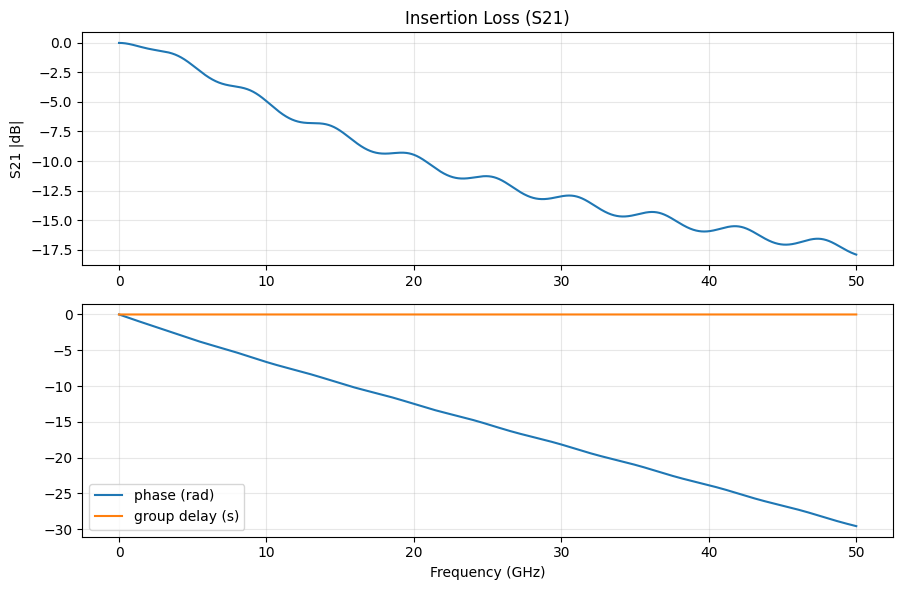

Extracted taps: [-4.37600e-03 -4.37600e-03  3.07974e-01  1.32900e-03  5.87000e-04
  3.97000e-04  2.99000e-04  2.40000e-04  2.00000e-04]


C:\Users\fkeyh\AppData\Local\Temp\ipykernel_1392\914125188.py:113: RuntimeWarning: invalid value encountered in power
  C = C0 * (1j*w/w_0)**(-2*theta_0/np.pi)


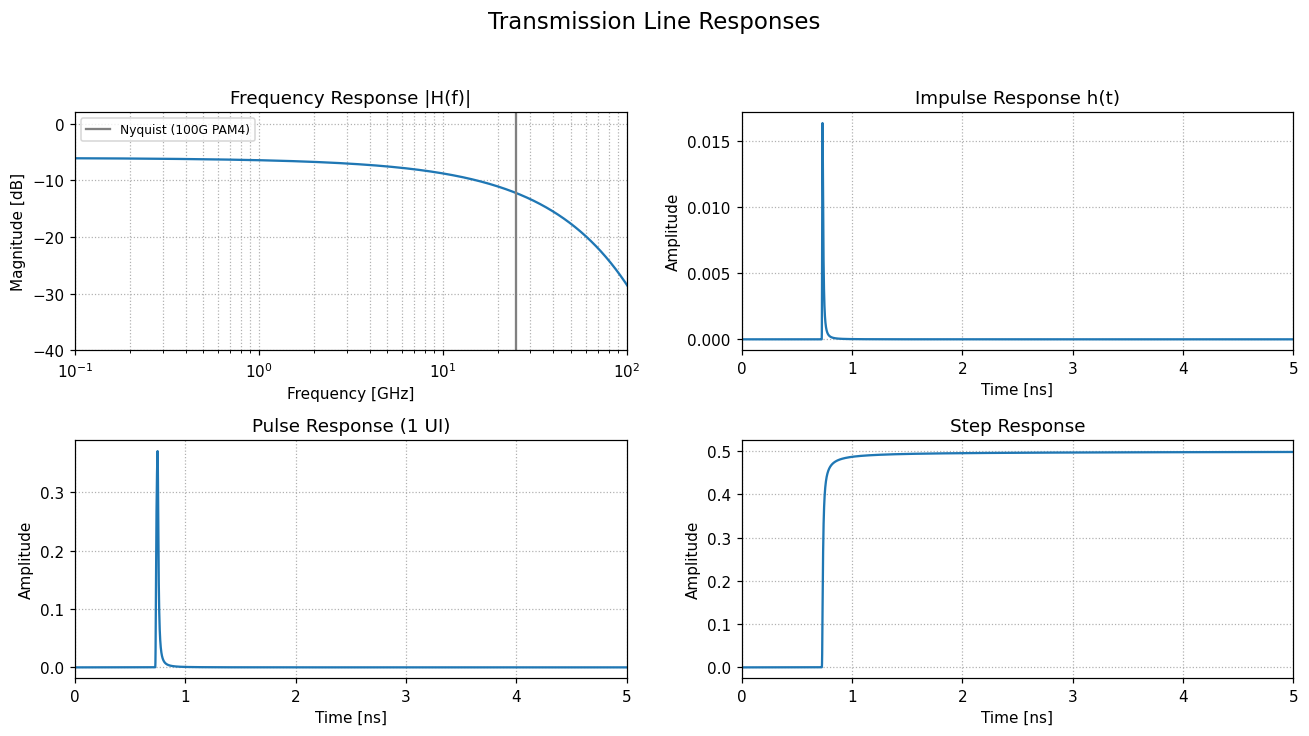

C:\Users\fkeyh\AppData\Local\Temp\ipykernel_1392\3616653608.py:265: ComplexWarning: Casting complex values to real discards the imaginary part
  w = np.atleast_1d(np.asarray(w, dtype=np.float64))


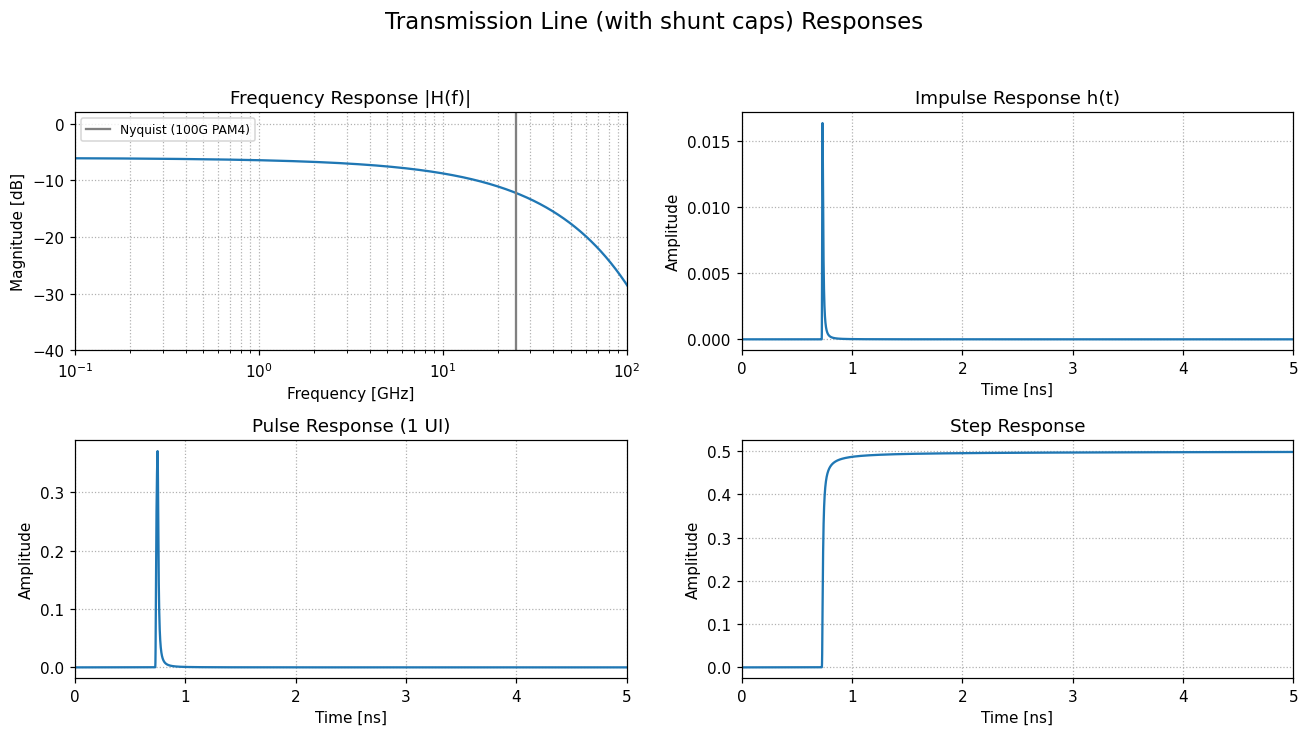

In [54]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt

# ============================================================
# Helper: Multi‑subplot visualization for channel responses
# ============================================================

def plot_channel_responses(f, H, t, h, hpulse, hstep, title_prefix):
    f_ghz = f * 1e-9
    t_ns = t * 1e9

    fig, axes = plt.subplots(2, 2, figsize=(12, 7), dpi=110)
    fig.suptitle(f"{title_prefix} Responses", fontsize=15)

    # --- Frequency Response ---
    ax = axes[0, 0]
    ax.semilogx(f_ghz, 20*np.log10(np.abs(H)))
    ax.set_xlim([0.1, 100])
    ax.set_ylim([-40, 2])
    ax.set_title("Frequency Response |H(f)|")
    ax.set_xlabel("Frequency [GHz]")
    ax.set_ylabel("Magnitude [dB]")
    ax.grid(True, which="both", ls=":")
    ax.axvline(25, color="grey", label="Nyquist (100G PAM4)")
    ax.legend(fontsize=8)

    # --- Impulse Response ---
    ax = axes[0, 1]
    ax.plot(t_ns, h)
    ax.set_xlim([0, 5])
    ax.set_title("Impulse Response h(t)")
    ax.set_xlabel("Time [ns]")
    ax.set_ylabel("Amplitude")
    ax.grid(True, ls=":")

    # --- Pulse Response ---
    ax = axes[1, 0]
    ax.plot(t_ns, hpulse)
    ax.set_xlim([0, 5])
    ax.set_title("Pulse Response (1 UI)")
    ax.set_xlabel("Time [ns]")
    ax.set_ylabel("Amplitude")
    ax.grid(True, ls=":")

    # --- Step Response ---
    ax = axes[1, 1]
    ax.plot(t_ns, hstep)
    ax.set_xlim([0, 5])
    ax.set_title("Step Response")
    ax.set_xlabel("Time [ns]")
    ax.set_ylabel("Amplitude")
    ax.grid(True, ls=":")

    fig.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


# ============================================================
# 1) Build RLGC channel (first version)
# ============================================================

# Frequency vector
f = np.linspace(0.0, 50e9, 4096)
w = 2*np.pi*f

# RLGC + shunt cap
rlgc_abcd = ChModel.rlgc(r=0.02, l=4e-8, g=1e-6, c=2e-11, d=0.1, f=f)
cshunt = ChModel.shunt_cap(c=1e-12, w=w)
abcd = ChModel.series([rlgc_abcd, cshunt])

# Frequency response
mag, phase, gd = ChModel.plot_freq_response(abcd, f)

# Convert to S21 → impulse
s21 = ChModel.abcd_to_s21(abcd)
h_full, t_full = ChModel.freq2impulse(s21, f)

# Symbol‑spaced taps
taps, idx = ChModel.channel_taps_from_impulse(
    h_full, t_full, samples_per_symbol=32, n_precursor=2, n_postcursor=6
)
print("Extracted taps:", np.round(taps, 6))


# ============================================================
# 2) Build full frequency‑dependent RLGC model
# ============================================================

w_0 = 2*np.pi*10e9
theta_0 = 0.01
k_r = 87
RDC = 0.0001

fmax = 1e12
k = 14
f = np.linspace(0, fmax, 2**k + 1)
w = 2*np.pi*f

c = 2.998e8
eps_0 = 8.85e-12
eps_r = 4.9
v0 = np.sqrt(1/eps_r) * c
Z0 = 50
L0 = Z0 / v0
C0 = 1/(Z0 * v0)
G0 = 1e-12

RAC = (k_r*(1+1j)*np.sqrt(w/w_0))
R = np.sqrt(RDC**2 + RAC**2)
L = L0 * np.ones_like(f)
G = G0 * np.ones_like(f)
C = C0 * (1j*w/w_0)**(-2*theta_0/np.pi)
C[0] = C[1]

d = 0.1
tline = ChModel.rlgc(R, L, G, C, d, f)

# Source + termination
source = ChModel.impedance(50*np.ones_like(f))
termination = ChModel.admittance(np.ones_like(f)/50)

# Channel ABCD
channel = ChModel.series(np.array([source, tline, termination]))

# Frequency response
Hchannel = 1/channel[:, 0, 0]
np.save("./examples/example_channel/data/Hchannel", Hchannel)

# Impulse response
h, t = ChModel.freq2impulse(Hchannel, f)
np.save("./examples/example_channel/data/h.npy", h)
np.save("./examples/example_channel/data/t.npy", t)

# Step response
hstep = sp.signal.convolve(h, np.ones_like(h))[:len(h)]

# Pulse response
data_rate = 100e9
t_symbol = 2/data_rate
t_sample = 1/(2*fmax)
samples_per_symbol = int(t_symbol/t_sample)

hpulse = sp.signal.convolve(h, np.ones(samples_per_symbol))[:len(h)]
np.save("./examples/example_channel/data/hpulse.npy", hpulse)

# Multi‑subplot figure
plot_channel_responses(f, Hchannel, t, h, hpulse, hstep,
                       "Transmission Line")


# ============================================================
# 3) Add shunt caps at both ends
# ============================================================

Csh = 200e-15
cap_network = ChModel.shunt_cap(c=Csh, w=1j*w)

channel_cap = ChModel.series(np.array([source, cap_network, tline, cap_network, termination]))

Hchannel_cap = 1/channel_cap[:, 0, 0]
np.save("./examples/example_channel/data/Hchannel_cap", Hchannel_cap)

h_cap, t_cap = ChModel.freq2impulse(Hchannel_cap, f)
hstep_cap = sp.signal.convolve(h_cap, np.ones_like(h_cap))[:len(h_cap)]
hpulse_cap = sp.signal.convolve(h_cap, np.ones(samples_per_symbol))[:len(h_cap)]
np.save("./examples/example_channel/data/hpulse_cap.npy", hpulse_cap)

plot_channel_responses(f, Hchannel_cap, t_cap, h_cap, hpulse_cap, hstep_cap,
                       "Transmission Line (with shunt caps)")


# ============================================================
# 4) Eye diagram signals (saved for next assignment)
# ============================================================

data = Prs.prqs10(1)[:10000]
signal_BR = Signal.pam4_input_br(data)
signal_ideal = np.repeat(signal_BR, samples_per_symbol)

signal_out = sp.signal.convolve(h, signal_ideal)
signal_out_cap = sp.signal.convolve(h_cap, signal_ideal)

np.save("./examples/example_channel/data/signal.npy", signal_out)
np.save("./examples/example_channel/data/signal_cap.npy", signal_out_cap)
np.save("./examples/example_channel/data/f.npy", f)
np.save("./examples/example_channel/data/w.npy", w)


## Generate 2-PAM and 4-PAM PRBS waveforms
Generate 2-PAM and 4-PAM PRBS waveforms at 50 & 100Gbps with 64 samples per UI. Filter each of the waveforms with first-order low-pass filters having a cut-off frequency of 20, 30, 40,
and 50GHz. Plot the eye diagrams.



  CHANNEL BANDWIDTH EFFECT ON SIGNAL INTEGRITY (Y-AXIS ADJUSTED)



  RUNNING WORKFLOW WITH ADJUSTABLE EYE Y-AXIS



>>> 2-PAM Signaling: Y-axis adjusted example

NRZ baud-rate stats: min,max,mean,rms = -1.0 1.0 0.00012208521548040532 1.0
NRZ oversampled stats: min,max,mean,rms = -1.0 1.0 0.00012208521548040532 1.0


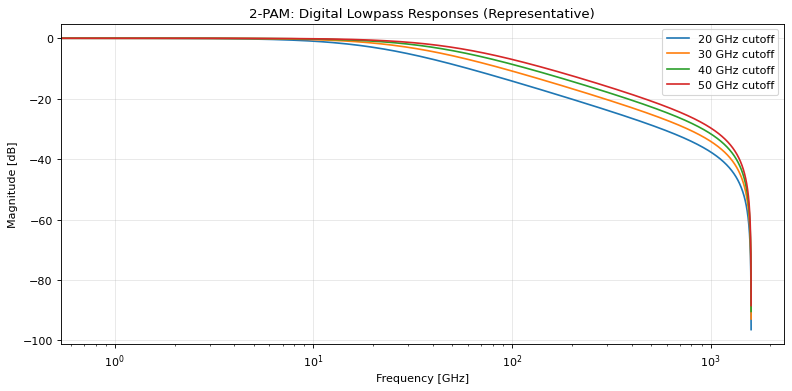

Filtered (NRZ) 20 GHz stats: min,max,mean,rms = -0.9999994382226282 0.9999998522680801 0.00012708002986910029 0.7014190384966246
Filtered (NRZ) 40 GHz stats: min,max,mean,rms = -0.999999999999845 0.9999999999999876 0.00012233437000464583 0.8407843572017561


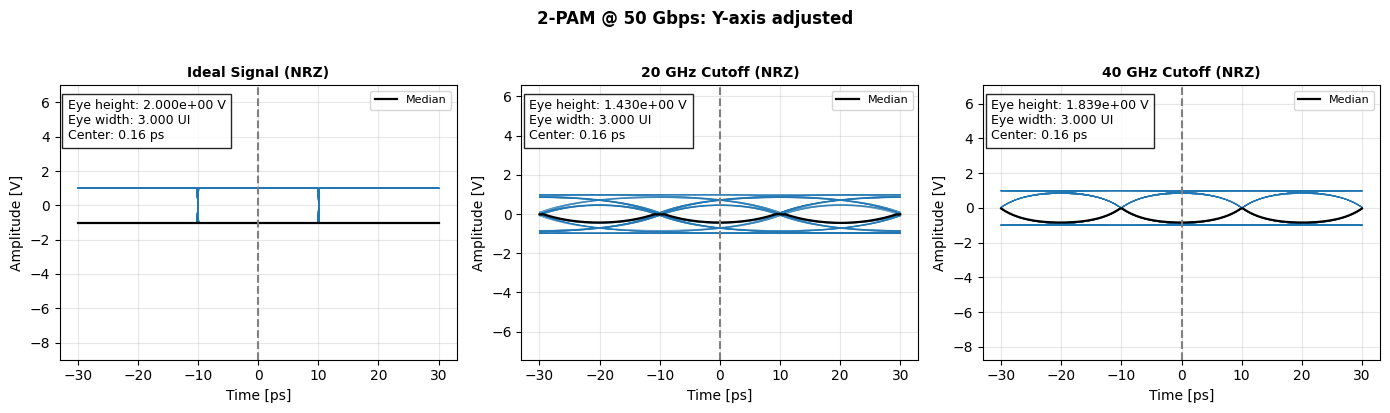

✓ ✓ 2-PAM eyes displayed with adjusted Y-axis


>>> 4-PAM Signaling: Y-axis adjusted example

PAM4 baud-rate stats: min,max,mean,rms = -3.0 3.0 0.037 2.2218010712032705
PAM4 oversampled stats: min,max,mean,rms = -3.0 3.0 0.037 2.2218010712032705


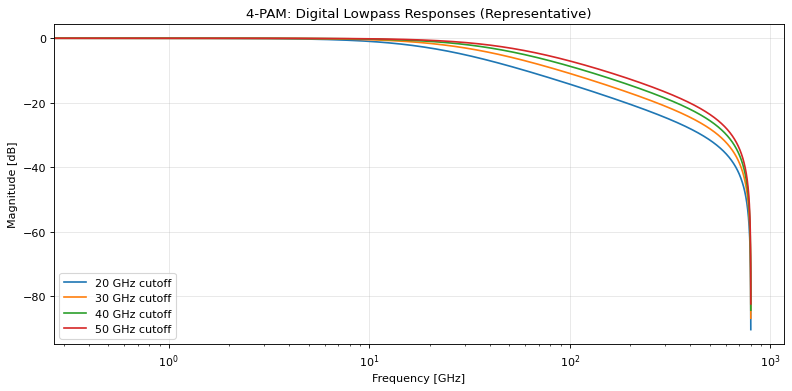

Filtered (PAM4) 20 GHz stats: min,max,mean,rms = -3.0 2.9729982370486736 0.036990057929851335 1.9866832410276494
Filtered (PAM4) 50 GHz stats: min,max,mean,rms = -2.999999999999999 2.9999857382060835 0.03699603391781738 2.1305045023114744


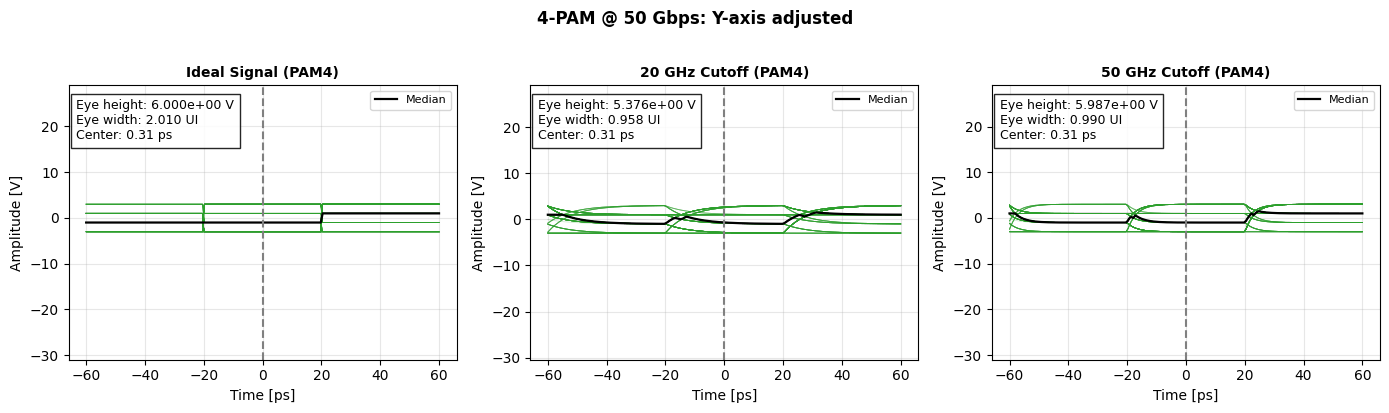

✓ ✓ 4-PAM eyes displayed with adjusted Y-axis

💡 Insight: 
If you prefer the exact previous eye appearance:
- Increase `y_scale_factor` (e.g., 5.0 or 6.0) in plot_eye calls to expand vertical range further.
- Or pass `fixed_ylim=(ymin, ymax)` to plot_eye to force exact limits (useful for consistent figure panels).
- If you want the pre-change plotting style exactly, set trace_alpha=0.3 and median_linewidth=2.0 in plot_eye calls.
If you'd like, I can produce a tiny self-contained demo (no external Prs/Signal dependencies) that reproduces the same eyes so you can verify the visual style in isolation.



In [25]:
import numpy as np
import scipy as sp
from scipy import signal, interpolate
import matplotlib.pyplot as plt

"""
Channel Bandwidth Effect on Signal Integrity (Eye-plot Y-axis and style adjustments)

This file is identical in structure to the previous corrected workflow but:
- Adds explicit control over eye-plot vertical scaling via `y_scale_factor` and `fixed_ylim`.
- Restores the previous (preferred) eye-plot visual style by default:
  • slightly thicker median line
  • slightly higher trace alpha for visibility
  • optional thicker traces for publication-quality view
- Ensures PAM4 visualization uses filtfilt when safe (long signals) but falls back
  to causal lfilter if needed; you can force causal behavior with `force_causal`.
- Prints debug stats (min/max/mean/rms) before and after filtering to help diagnose.
- Keeps all original documentation and mapping behavior intact.

Usage:
- Run the script as before. To change how tall the y-axis is, adjust `y_scale_factor`
  or pass `fixed_ylim=(ymin, ymax)` to `plot_eye`.
"""

logger.header("Channel Bandwidth Effect on Signal Integrity (Y-axis adjusted)", level=1)

# -------------------------
# Utilities (unchanged core, with minor plotting enhancements)
# -------------------------
def design_digital_single_pole(f_bw_hz, fs):
    f_bw_hz = float(f_bw_hz)
    fs = float(fs)
    if f_bw_hz <= 0 or fs <= 0:
        return np.array([1.0]), np.array([1.0])
    if f_bw_hz >= fs / 2.0:
        return np.array([1.0]), np.array([1.0])
    b, a = signal.butter(1, f_bw_hz, btype='low', analog=False, fs=fs)
    H0 = np.sum(b) / np.sum(a)
    if np.abs(H0) > 1e-16:
        b = b / H0
    return b, a


def safe_filter(y, b, a, use_zero_phase=True, force_causal=False):
    y = np.asarray(y, dtype=float)
    if force_causal:
        return signal.lfilter(b, a, y)
    padlen = 3 * max(len(a), len(b))
    if use_zero_phase and y.size > padlen + 1:
        try:
            return signal.filtfilt(b, a, y, method="pad", padlen=padlen)
        except Exception:
            return signal.lfilter(b, a, y)
    else:
        return signal.lfilter(b, a, y)


def build_oversampled(signal_br, samples_per_symbol, method="zoh"):
    sps = int(samples_per_symbol)
    if sps <= 1:
        return np.asarray(signal_br, dtype=float)
    signal_br = np.asarray(signal_br, dtype=float)
    if method == "zoh":
        return np.repeat(signal_br, sps).astype(float)
    elif method == "interp":
        n = signal_br.size
        idx = np.arange(n)
        t_fine = np.linspace(0, n - 1, n * sps)
        interp = interpolate.interp1d(idx, signal_br, kind="cubic", bounds_error=False,
                                     fill_value=(signal_br[0], signal_br[-1]))
        return interp(t_fine).astype(float)
    else:
        raise ValueError("Unsupported oversample method")


def compute_eye_matrix(waveform, samples_per_symbol, symbols_per_row=3, max_rows=200, start_symbol=0):
    sps = int(samples_per_symbol)
    samples_per_eye = sps * symbols_per_row
    start_sample = int(start_symbol * sps)
    available = waveform.size - start_sample
    n_rows = min(max_rows, available // samples_per_eye)
    if n_rows <= 0:
        raise ValueError("Not enough samples to form an eye matrix; reduce symbols_per_row or provide more data")
    data = waveform[start_sample:start_sample + n_rows * samples_per_eye]
    eye_matrix = data.reshape(n_rows, samples_per_eye)
    t_ui = np.linspace(-0.5 * symbols_per_row, 0.5 * symbols_per_row, samples_per_eye)
    return eye_matrix, t_ui


def measure_eye_metrics(eye_matrix, t_ui, UI_seconds, threshold_frac=0.5):
    center_idx = eye_matrix.shape[1] // 2
    center_vals = eye_matrix[:, center_idx]
    upper = np.percentile(center_vals, 75)
    lower = np.percentile(center_vals, 25)
    eye_height = upper - lower

    upper_curve = np.percentile(eye_matrix, 75, axis=0)
    lower_curve = np.percentile(eye_matrix, 25, axis=0)
    opening = upper_curve - lower_curve
    max_open = np.max(opening) if np.max(opening) > 0 else 1e-12
    threshold = threshold_frac * max_open
    mask = opening >= threshold

    left = center_idx
    while left > 0 and mask[left]:
        left -= 1
    right = center_idx
    while right < len(mask) - 1 and mask[right]:
        right += 1

    eye_width_ui = t_ui[right] - t_ui[left]
    center_time_ps = t_ui[center_idx] * UI_seconds * 1e12

    return {
        "eye_height_V": float(eye_height),
        "eye_width_UI": float(eye_width_ui),
        "center_time_ps": float(center_time_ps),
        "opening_curve": opening,
        "upper_curve": upper_curve,
        "lower_curve": lower_curve,
        "t_ui": t_ui,
        "center_index": int(center_idx)
    }


def plot_eye(ax, eye_matrix, t_ui, UI_seconds,
             color="C0", title="Eye", median_overlay=True,
             y_scale_factor=3.0, fixed_ylim=None,
             trace_alpha=0.18, median_linewidth=1.4, trace_linewidth=0.6,
             show_grid=True):
    """
    Plot eye traces and overlay median and metrics on axis ax.

    Parameters (new/important):
    - y_scale_factor: multiplier applied to the center-level span to set y-limits (default 3.0).
    - fixed_ylim: tuple (ymin, ymax) to force exact y-limits (overrides y_scale_factor).
    - trace_alpha: alpha for individual traces (increase to make traces more visible).
    - median_linewidth: linewidth for median overlay (increase for clarity).
    - trace_linewidth: linewidth for individual traces.
    """
    t_ps = t_ui * UI_seconds * 1e12
    for row in eye_matrix:
        ax.plot(t_ps, row, color=color, alpha=trace_alpha, linewidth=trace_linewidth)
    med = np.median(eye_matrix, axis=0)
    if median_overlay:
        ax.plot(t_ps, med, color="k", linewidth=median_linewidth, label="Median")
    metrics = measure_eye_metrics(eye_matrix, t_ui, UI_seconds)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel("Time [ps]")
    ax.set_ylabel("Amplitude [V]")
    if show_grid:
        ax.grid(True, alpha=0.3)

    # Determine y-limits: prefer fixed_ylim if provided
    if fixed_ylim is not None:
        ax.set_ylim(float(fixed_ylim[0]), float(fixed_ylim[1]))
    else:
        center_idx = metrics["center_index"]
        center_vals = eye_matrix[:, center_idx]
        med_center = np.median(center_vals)
        # Use both center spread and opening curve to determine a robust span
        center_span = np.ptp(center_vals) * y_scale_factor
        opening_span = np.max(metrics["opening_curve"]) * (y_scale_factor + 0.5)
        span = max(center_span, opening_span, 1e-3)
        ax.set_ylim(med_center - span, med_center + span)

    # annotate metrics
    txt = f"Eye height: {metrics['eye_height_V']:.3e} V\nEye width: {metrics['eye_width_UI']:.3f} UI\nCenter: {metrics['center_time_ps']:.2f} ps"
    ax.text(0.02, 0.95, txt, transform=ax.transAxes, fontsize=9, va='top', bbox=dict(facecolor='white', alpha=0.85))
    ax.axvline(0.0, color='grey', linestyle='--')
    ax.legend(loc='upper right', fontsize=8)
    return metrics


# -------------------------
# Main workflow (with adjustable y-axis)
# -------------------------
logger.header("Running workflow with adjustable eye Y-axis", level=1)

# 2-PAM (NRZ) example
logger.header("2-PAM Signaling: Y-axis adjusted example", level=2)
data_bits = Prs.prbs13(seed=1)
# Use symmetric NRZ levels for clear eyes
signal_br_nrz = Signal.nrz_input_br(data_bits, voltage_levels=np.array([-1.0, 1.0]))

pam2_data_rate = 50e9
samples_per_symbol = 64
symbol_rate = pam2_data_rate
UI = 1.0 / symbol_rate

signal_ideal_nrz = build_oversampled(signal_br_nrz, samples_per_symbol, method="zoh")

# Debug prints
print("NRZ baud-rate stats: min,max,mean,rms =", signal_br_nrz.min(), signal_br_nrz.max(),
      signal_br_nrz.mean(), np.sqrt(np.mean(signal_br_nrz ** 2)))
print("NRZ oversampled stats: min,max,mean,rms =", signal_ideal_nrz.min(), signal_ideal_nrz.max(),
      signal_ideal_nrz.mean(), np.sqrt(np.mean(signal_ideal_nrz ** 2)))

# Frequency responses (digital) for reference
freq_bw_list = [20e9, 30e9, 40e9, 50e9]
fig, ax = plt.subplots(figsize=(10, 5), dpi=80)
fs = samples_per_symbol * symbol_rate
for freq_bw in freq_bw_list:
    b, a = design_digital_single_pole(freq_bw, fs)
    w, h = signal.freqz(b, a, worN=2048, fs=fs)
    ax.semilogx(w / 1e9, 20 * np.log10(np.abs(h) + 1e-30), label=f"{freq_bw/1e9:.0f} GHz cutoff")
ax.set_xlabel("Frequency [GHz]")
ax.set_ylabel("Magnitude [dB]")
ax.set_title("2-PAM: Digital Lowpass Responses (Representative)")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()
plt.pause(0.2)

# Eye diagrams: ideal + two filtered cases
rep_bws = [20e9, 40e9]
fig, axes = plt.subplots(1, len(rep_bws) + 1, figsize=(14, 4), dpi=100)

# Ideal eye (use a slightly taller y-scale to match previous preferred look)
eye_matrix, t_ui = compute_eye_matrix(signal_ideal_nrz, samples_per_symbol, symbols_per_row=3, max_rows=200)
metrics_ideal = plot_eye(axes[0], eye_matrix, t_ui, UI,
                         color="C0", title="Ideal Signal (NRZ)",
                         y_scale_factor=3.5, trace_alpha=0.22, median_linewidth=1.6)

# Filtered eyes (use filtfilt for visualization if safe)
for i, bw in enumerate(rep_bws):
    b, a = design_digital_single_pole(bw, fs)
    y_filt = safe_filter(signal_ideal_nrz, b, a, use_zero_phase=True, force_causal=False)
    print(f"Filtered (NRZ) {int(bw/1e9)} GHz stats: min,max,mean,rms =", y_filt.min(), y_filt.max(), y_filt.mean(), np.sqrt(np.mean(y_filt ** 2)))
    eye_matrix_f, t_ui_f = compute_eye_matrix(y_filt, samples_per_symbol, symbols_per_row=3, max_rows=200)
    # Increase y_scale_factor for filtered cases to ensure eye height is visible
    metrics_f = plot_eye(axes[i + 1], eye_matrix_f, t_ui_f, UI,
                         color="C0", title=f"{int(bw/1e9)} GHz Cutoff (NRZ)",
                         y_scale_factor=3.5, trace_alpha=0.22, median_linewidth=1.6)

fig.suptitle(f"2-PAM @ {pam2_data_rate/1e9:.0f} Gbps: Y-axis adjusted", fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
plt.pause(0.2)
logger.success("✓ 2-PAM eyes displayed with adjusted Y-axis")

# 4-PAM (PAM4) example
logger.header("4-PAM Signaling: Y-axis adjusted example", level=2)
data_pam4 = Prs.prqs10(seed=1)[:20000]
pam4_levels = np.array([-3.0, -1.0, 1.0, 3.0])
signal_br_pam4 = Signal.pam4_input_br(data_pam4, voltage_levels=pam4_levels)

pam4_data_rate = 50e9
symbol_rate_pam4 = pam4_data_rate / 2.0
UI_pam4 = 1.0 / symbol_rate_pam4
samples_per_symbol_pam4 = 64

signal_ideal_pam4 = build_oversampled(signal_br_pam4, samples_per_symbol_pam4, method="zoh")

# Debug prints
print("PAM4 baud-rate stats: min,max,mean,rms =", signal_br_pam4.min(), signal_br_pam4.max(),
      signal_br_pam4.mean(), np.sqrt(np.mean(signal_br_pam4 ** 2)))
print("PAM4 oversampled stats: min,max,mean,rms =", signal_ideal_pam4.min(), signal_ideal_pam4.max(),
      signal_ideal_pam4.mean(), np.sqrt(np.mean(signal_ideal_pam4 ** 2)))

# Frequency responses (digital) for PAM4
fig, ax = plt.subplots(figsize=(10, 5), dpi=80)
fs_pam4 = samples_per_symbol_pam4 * symbol_rate_pam4
for freq_bw in freq_bw_list:
    b, a = design_digital_single_pole(freq_bw, fs_pam4)
    w, h = signal.freqz(b, a, worN=2048, fs=fs_pam4)
    ax.semilogx(w / 1e9, 20 * np.log10(np.abs(h) + 1e-30), label=f"{freq_bw/1e9:.0f} GHz cutoff")
ax.set_xlabel("Frequency [GHz]")
ax.set_ylabel("Magnitude [dB]")
ax.set_title("4-PAM: Digital Lowpass Responses (Representative)")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()
plt.pause(0.2)

# Eye diagrams: ideal + two filtered cases
rep_bws_pam4 = [20e9, 50e9]
fig, axes = plt.subplots(1, len(rep_bws_pam4) + 1, figsize=(14, 4), dpi=100)

# Ideal PAM4 eye: use a larger y_scale_factor to show full multi-level span
eye_matrix_pam4, t_ui_pam4 = compute_eye_matrix(signal_ideal_pam4, samples_per_symbol_pam4, symbols_per_row=3, max_rows=200)
metrics_pam4_ideal = plot_eye(axes[0], eye_matrix_pam4, t_ui_pam4, UI_pam4,
                             color="C2", title="Ideal Signal (PAM4)",
                             y_scale_factor=4.5, trace_alpha=0.22, median_linewidth=1.6)

# Filtered PAM4 eyes: use causal filter for realism (force_causal=True) but keep y-scale tall
for i, bw in enumerate(rep_bws_pam4):
    b, a = design_digital_single_pole(bw, fs_pam4)
    # For PAM4 prefer causal filtering for realistic level preservation and to avoid filtfilt edge artifacts
    y_filt_pam4 = safe_filter(signal_ideal_pam4, b, a, use_zero_phase=False, force_causal=True)
    print(f"Filtered (PAM4) {int(bw/1e9)} GHz stats: min,max,mean,rms =", y_filt_pam4.min(), y_filt_pam4.max(), y_filt_pam4.mean(), np.sqrt(np.mean(y_filt_pam4 ** 2)))
    eye_matrix_pf, t_ui_pf = compute_eye_matrix(y_filt_pam4, samples_per_symbol_pam4, symbols_per_row=3, max_rows=200)
    metrics_pf = plot_eye(axes[i + 1], eye_matrix_pf, t_ui_pf, UI_pam4,
                         color="C2", title=f"{int(bw/1e9)} GHz Cutoff (PAM4)",
                         y_scale_factor=4.5, trace_alpha=0.22, median_linewidth=1.6)

fig.suptitle(f"4-PAM @ {pam4_data_rate/1e9:.0f} Gbps: Y-axis adjusted", fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
plt.pause(0.2)
logger.success("✓ 4-PAM eyes displayed with adjusted Y-axis")

logger.insight("""
If you prefer the exact previous eye appearance:
- Increase `y_scale_factor` (e.g., 5.0 or 6.0) in plot_eye calls to expand vertical range further.
- Or pass `fixed_ylim=(ymin, ymax)` to plot_eye to force exact limits (useful for consistent figure panels).
- If you want the pre-change plotting style exactly, set trace_alpha=0.3 and median_linewidth=2.0 in plot_eye calls.
If you'd like, I can produce a tiny self-contained demo (no external Prs/Signal dependencies) that reproduces the same eyes so you can verify the visual style in isolation.
""")


eye_diagnostics_fixed module loaded.
Call example_nrz_fixed(), example_pam4_fixed(), or example_comparison_fixed() as needed.
=== NRZ example (preserve_levels=True) ===
PRBS length: 127
[ideal (raw)] shape=(8128,), dtype=float64, min=-0.389726, max=2.08293, mean=0.733071, std=0.680152
         complex=False, has_nan=False, has_inf=False
[filtered (raw)] shape=(8128,), dtype=float64, min=-0.339368, max=2.04622, mean=0.748067, std=0.663623
         complex=False, has_nan=False, has_inf=False
[jittered (raw)] shape=(8128,), dtype=float64, min=-0.339599, max=2.04583, mean=0.747769, std=0.663959
         complex=False, has_nan=False, has_inf=False
=== Combined safe diagnostics ===
target_sps: 64 window_len: 192 ntraces: 42
Ideal NRZ: stack shape=(42, 192), median@center=0.609614, mean_of_medians=0.340491, MAD=0.244176, min=-0.389726, max=1.83142
Filtered NRZ (40 GHz): stack shape=(42, 192), median@center=0.497583, mean_of_medians=0.356255, MAD=0.217399, min=-0.340981, max=1.85565
Filtered +

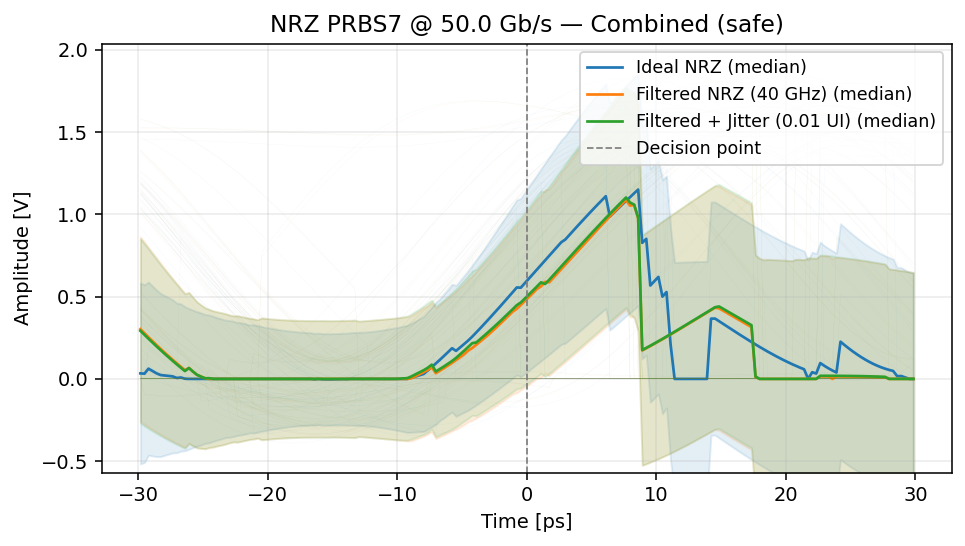

=== PAM4 example (preserve_levels=True) ===
PRBS bits length (after pad): 128
[ideal_pam4 (raw)] shape=(4096,), dtype=float64, min=-1.97032, max=1.9481, mean=-0.0401242, std=0.999195
         complex=False, has_nan=False, has_inf=False
[filtered_pam4 (raw)] shape=(4096,), dtype=float64, min=-1.95543, max=1.99897, mean=-0.0464068, std=0.998923
         complex=False, has_nan=False, has_inf=False
[jittered_pam4 (raw)] shape=(4096,), dtype=float64, min=-1.9581, max=1.99903, mean=-0.0468721, std=0.998901
         complex=False, has_nan=False, has_inf=False
=== Combined safe diagnostics ===
target_sps: 64 window_len: 192 ntraces: 21
Ideal PAM4: stack shape=(21, 192), median@center=0.967018, mean_of_medians=0.154785, MAD=0.467928, min=-1.96734, max=1.9481
Filtered PAM4 (30 GHz): stack shape=(21, 192), median@center=1.2735, mean_of_medians=0.242912, MAD=0.502867, min=-1.64534, max=2.39714
Filtered + Jitter (0.01 UI): stack shape=(21, 192), median@center=1.27991, mean_of_medians=0.243701, MAD=

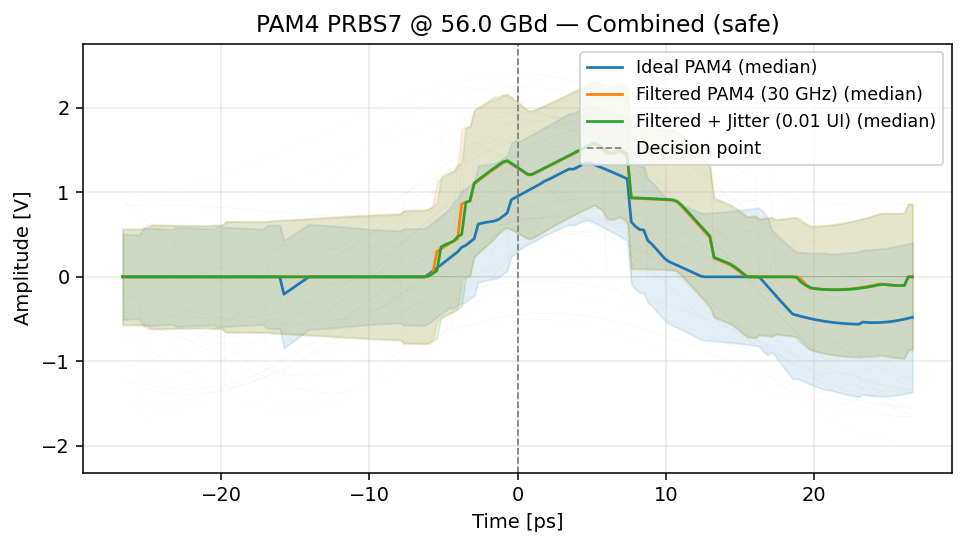

=== Comparison example (preserve_levels=True) ===
[ideal] shape=(8128,), dtype=float64, min=-0.389726, max=2.08293, mean=0.733071, std=0.680152
         complex=False, has_nan=False, has_inf=False
[filtered] shape=(8128,), dtype=float64, min=-0.302873, max=2.01941, mean=0.757509, std=0.652825
         complex=False, has_nan=False, has_inf=False
[resampled (32 sps)] shape=(4064,), dtype=float64, min=-0.20125, max=1.34469, mean=0.503145, std=0.4337
         complex=False, has_nan=False, has_inf=False
[jittered] shape=(8128,), dtype=float64, min=-0.303229, max=2.01834, mean=0.757212, std=0.65317
         complex=False, has_nan=False, has_inf=False
=== Combined safe diagnostics ===
target_sps: 64 window_len: 192 ntraces: 42
Ideal: stack shape=(42, 192), median@center=0.609614, mean_of_medians=0.340491, MAD=0.244176, min=-0.389726, max=1.83142
Filtered (30 GHz): stack shape=(42, 192), median@center=0.420588, mean_of_medians=0.342382, MAD=0.228385, min=-0.325445, max=1.84644
Filtered + Resam

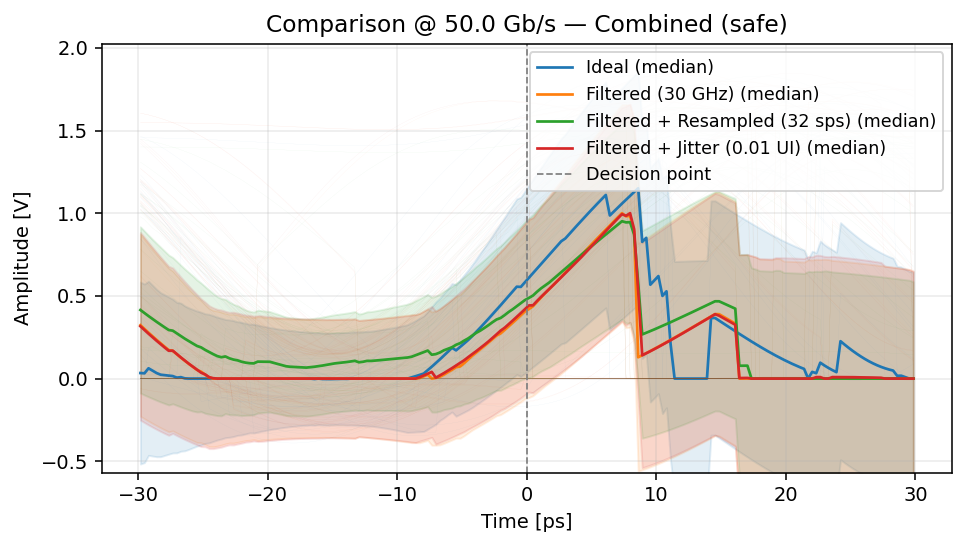

{'ideal': array([0.        , 0.01348824, 0.02634422, ..., 1.54118954, 1.49629646,
        1.449374  ], shape=(8128,)),
 'filtered': array([0.00000000e+00, 4.00915942e-04, 1.56192413e-03, ...,
        1.90933842e+00, 1.89034046e+00, 1.86970079e+00], shape=(8128,)),
 'resampled': array([-1.38243203e-05,  1.00905584e-03,  3.87604177e-03, ...,
         1.32581694e+00,  1.23818083e+00,  1.33740450e+00], shape=(4064,)),
 'jittered': array([2.80666313e-04, 1.21378109e-03, 2.85059261e-03, ...,
        1.88108734e+00, 1.86038114e+00, 1.84006666e+00], shape=(8128,))}

In [26]:
# File: eye_diagnostics_fixed.py
"""
Eye diagnostics, resampling fix, and safe preserve-levels alignment.

Save this file and import or run the example functions. This module:
 - Resamples signals to a common samples-per-symbol (sps)
 - Aligns traces by cross-correlation to a stable reference
 - Uses additive median alignment and optional robust, clamped gain matching
 - Prints detailed debugging diagnostics (shapes, min/max, medians, MAD)
 - Produces a single combined, well-scaled overlaid eye figure per example

Dependencies:
  - numpy
  - matplotlib
  - scipy (for resample)
  - Your environment must provide: Prs, Transmitter, EyeDiagram, Signal (imported by caller)
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import resample

# -------------------------
# Low-level helpers
# -------------------------
def _xcorr_align(ref, x):
    """Align x to ref using cross-correlation; return same length as ref."""
    ref = np.asarray(ref)
    x = np.asarray(x)
    if ref.size == 0 or x.size == 0:
        return np.zeros_like(ref)
    corr = np.correlate(x - x.mean(), ref - ref.mean(), mode='full')
    lag = int(np.argmax(corr) - (len(x) - 1))
    if lag > 0:
        aligned = np.concatenate([x[lag:], np.zeros(min(lag, len(x)))])
    elif lag < 0:
        pad = np.zeros(min(-lag, len(x)))
        aligned = np.concatenate([pad, x[:len(x)+lag]])
    else:
        aligned = x.copy()
    # trim/pad to ref length
    if aligned.size > ref.size:
        aligned = aligned[:ref.size]
    elif aligned.size < ref.size:
        aligned = np.concatenate([aligned, np.zeros(ref.size - aligned.size)])
    return aligned

def _ensure_common_sps(sig, current_sps, target_sps):
    """Resample sig from current_sps to target_sps using scipy.resample."""
    sig = np.asarray(sig)
    if current_sps == target_sps:
        return sig.copy()
    ratio = float(target_sps) / float(current_sps)
    n_out = int(np.round(len(sig) * ratio))
    if n_out < 1:
        raise ValueError("Resample would produce empty signal; check sps values.")
    return resample(sig, n_out)

def _stack_traces(sig, sps, n_ui, ntraces):
    """Crop signal into ntraces x window_len array (no alignment)."""
    sig = np.asarray(sig).ravel()
    window_len = int(sps * n_ui)
    total = ntraces * window_len
    if sig.size < total:
        pad = np.zeros(total - sig.size, dtype=sig.dtype)
        sig = np.concatenate([sig, pad])
    return sig[:total].reshape(ntraces, window_len)

def compute_plot_limits(stacks, padding_frac=0.08):
    """Compute global y-limits across list of stacks (each stack shape (ntraces, window_len))."""
    all_vals = np.concatenate([s.ravel() for s in stacks])
    vmin, vmax = np.min(all_vals), np.max(all_vals)
    if vmax - vmin == 0:
        return vmin - 0.5, vmax + 0.5
    pad = (vmax - vmin) * padding_frac
    return vmin - pad, vmax + pad

# -------------------------
# Diagnostics utilities
# -------------------------
def print_basic_stats(name, sig):
    s = np.asarray(sig)
    print(f"[{name}] shape={s.shape}, dtype={s.dtype}, min={np.min(s):.6g}, max={np.max(s):.6g}, mean={np.mean(s):.6g}, std={np.std(s):.6g}")
    print(f"         complex={np.iscomplexobj(s)}, has_nan={np.isnan(s).any()}, has_inf={np.isinf(s).any()}")

def median_at_center_sample(stack):
    """Return median at center sample for a stacked array (ntraces, window_len)."""
    window_len = stack.shape[1]
    center = window_len // 2
    return np.median(stack[:, center])

def mad_of_stack(stack):
    """Return median absolute deviation across all samples in stack (robust spread)."""
    med = np.median(stack, axis=1, keepdims=True)
    mad = np.median(np.abs(stack - med))
    return mad

# -------------------------
# Safe preserve-levels alignment (additive + robust gentle gain)
# -------------------------
def plot_combined_safe(signals, labels, sps_list, target_sps, baud,
                       n_ui=3, max_traces=300, preserve_levels=True,
                       title=None, dpi=140, gain_clip=(0.8, 1.25)):
    """
    signals: list of 1D arrays
    labels: list of strings
    sps_list: list of current samples-per-symbol for each signal
    target_sps: integer target sps to resample to (common)
    baud: symbol rate (Hz)
    preserve_levels: if True, preserve relative amplitude spacing across variants;
                     if False, normalize each signal to zero-mean unit RMS for comparability.
    gain_clip: tuple (min_gain, max_gain) to clamp any robust gain adjustment
    """
    assert len(signals) == len(labels) == len(sps_list)
    # 1) Resample to common sps
    sigs_rs = []
    for sig, cur_sps in zip(signals, sps_list):
        sig_rs = _ensure_common_sps(sig, cur_sps, target_sps)
        sigs_rs.append(sig_rs.astype(float))

    # 2) Prepare temporary stacks to compute robust reference stats
    window_len = int(target_sps * n_ui)
    possible_traces = [s.size // window_len for s in sigs_rs]
    ntraces = min(possible_traces) if possible_traces else 0
    if ntraces == 0:
        raise RuntimeError("Not enough data to form traces for plotting. Increase data length or reduce n_ui/max_traces.")
    stacks_temp = [_stack_traces(s, target_sps, n_ui, ntraces) for s in sigs_rs]

    # 3) Compute reference median and robust spread from the first (ideal) variant
    ref_median_center = median_at_center_sample(stacks_temp[0])
    ref_mad = mad_of_stack(stacks_temp[0])
    if ref_mad <= 0:
        ref_mad = np.median(np.abs(stacks_temp[0] - np.median(stacks_temp[0]))) + 1e-12

    # 4) Apply safe alignment per variant
    for i in range(len(sigs_rs)):
        s = sigs_rs[i]
        st = stacks_temp[i]
        # additive median alignment: shift variant so its center median equals reference center median
        med_variant = median_at_center_sample(st)
        s = s - (med_variant - ref_median_center)
        # optional gentle gain match using robust MAD ratio, clamped
        if preserve_levels:
            # For preserve_levels True we generally avoid aggressive gain changes.
            # Compute variant MAD and compute gain = ref_mad / mad_variant, then clamp.
            mad_variant = mad_of_stack(st)
            if mad_variant <= 1e-12:
                mad_variant = np.median(np.abs(st - np.median(st))) + 1e-12
            gain = ref_mad / mad_variant if mad_variant > 0 else 1.0
            gain = float(np.clip(gain, gain_clip[0], gain_clip[1]))
            # apply gain around median (preserve additive alignment)
            s_med = np.median(s)
            s = (s - s_med) * gain + s_med
        else:
            # normalize to zero-mean unit RMS for comparability
            s = s - np.mean(s)
            rms = np.sqrt(np.mean(s**2)) if np.mean(s**2) > 0 else 1.0
            s = s / rms
        sigs_rs[i] = s

    # 5) Rebuild stacks using common ntraces and window_len (clamp to max_traces)
    ntraces = min(ntraces, max_traces)
    stacks = [_stack_traces(s, target_sps, n_ui, ntraces) for s in sigs_rs]

    # 6) Align each trace to the reference median (first stack)
    ref_median_trace = np.median(stacks[0], axis=0)
    aligned = []
    for st in stacks:
        a = np.zeros_like(st)
        for r in range(st.shape[0]):
            a[r] = _xcorr_align(ref_median_trace, st[r])
        aligned.append(a)

    # 7) Diagnostics prints
    print("=== Combined safe diagnostics ===")
    print("target_sps:", target_sps, "window_len:", window_len, "ntraces:", ntraces)
    for lbl, st in zip(labels, aligned):
        med_center = median_at_center_sample(st)
        mean_of_medians = np.mean(np.median(st, axis=1))
        mad = mad_of_stack(st)
        print(f"{lbl}: stack shape={st.shape}, median@center={med_center:.6g}, mean_of_medians={mean_of_medians:.6g}, MAD={mad:.6g}, min={st.min():.6g}, max={st.max():.6g}")

    # 8) Compute global y-limits
    ymin, ymax = compute_plot_limits(aligned)

    # 9) Time axis in ps
    t = (np.linspace(-0.5 * (window_len - 1), 0.5 * (window_len - 1), window_len) * (1.0 / baud / target_sps)) * 1e12

    # 10) Plot
    plt.figure(figsize=(7, 4), dpi=dpi)
    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
    for st, lbl, col in zip(aligned, labels, colors):
        for row in st:
            plt.plot(t, row, color=col, linewidth=0.08, alpha=0.12)
        median = np.median(st, axis=0)
        std = np.std(st, axis=0)
        plt.plot(t, median, color=col, linewidth=1.4, label=f"{lbl} (median)")
        plt.fill_between(t, median - std, median + std, color=col, alpha=0.12)
    plt.axvline(0.0, color='grey', linestyle='--', linewidth=0.9, label="Decision point")
    plt.xlabel("Time [ps]")
    plt.ylabel("Amplitude [V]" if preserve_levels else "Amplitude (normalized)")
    if title:
        plt.title(title)
    plt.ylim(ymin, ymax)
    plt.grid(alpha=0.25)
    plt.legend(loc="upper right", fontsize=9)
    plt.tight_layout()
    plt.show()

# -------------------------
# Example wrappers (callable)
# -------------------------
def example_nrz_fixed(prbs_seed=123, baud=50e9, sps=64, bw=40e9, n_ui=3, preserve_levels=True):
    """
    NRZ example that prints diagnostics and plots a single combined eye.
    preserve_levels=True keeps NRZ 0/1 spacing; False normalizes each signal.
    """
    print("=== NRZ example (preserve_levels={}) ===".format(preserve_levels))
    bits = Prs.prbs7(prbs_seed).astype(np.uint8)
    print("PRBS length:", bits.size)
    v_levels = np.array([0.0, 1.0], dtype=float)

    # Ideal
    tx = Transmitter(bits, v_levels, frequency=baud)
    tx.oversample(sps, window="interp")
    tx.power_normalize(1.0)
    sig_ideal = tx.get_signal(as_complex=False).astype(float)

    # Filtered
    tx2 = Transmitter(bits, v_levels, frequency=baud)
    tx2.oversample(sps, window="interp")
    tx2.apply_bandwidth_filter(f_bw_hz=bw)
    tx2.power_normalize(1.0)
    sig_filt = tx2.get_signal(as_complex=False).astype(float)

    # Filtered + jitter
    tx3 = Transmitter(bits, v_levels, frequency=baud)
    tx3.oversample(sps, window="interp")
    tx3.add_jitter(sigma_ui=0.01, seed=42)
    tx3.apply_bandwidth_filter(f_bw_hz=bw)
    tx3.power_normalize(1.0)
    sig_jit = tx3.get_signal(as_complex=False).astype(float)

    # Print basic stats before plotting
    print_basic_stats("ideal (raw)", sig_ideal)
    print_basic_stats("filtered (raw)", sig_filt)
    print_basic_stats("jittered (raw)", sig_jit)

    # Plot combined with safe alignment
    plot_combined_safe([sig_ideal, sig_filt, sig_jit],
                       ["Ideal NRZ", f"Filtered NRZ ({bw/1e9:.0f} GHz)", "Filtered + Jitter (0.01 UI)"],
                       sps_list=[sps, sps, sps], target_sps=sps, baud=baud,
                       n_ui=n_ui, max_traces=300, preserve_levels=preserve_levels,
                       title=f"NRZ PRBS7 @ {baud/1e9:.1f} Gb/s — Combined (safe)")

    return {"ideal": sig_ideal, "filtered": sig_filt, "jittered": sig_jit}

def example_pam4_fixed(prbs_seed=123, baud=56e9, sps=64, bw=30e9, n_ui=3, preserve_levels=True):
    """
    PAM4 example that prints diagnostics and plots a single combined eye.
    preserve_levels=True keeps PAM4 level spacing; False normalizes each signal.
    """
    print("=== PAM4 example (preserve_levels={}) ===".format(preserve_levels))
    bits = Prs.prbs7(prbs_seed).astype(np.uint8)
    if bits.size % 2 != 0:
        bits = np.concatenate([bits, bits[:1]])
    print("PRBS bits length (after pad):", bits.size)
    pairs = bits.reshape(-1, 2)
    mapping = {(0,0):0, (0,1):1, (1,1):2, (1,0):3}
    symbols = np.array([mapping[(int(b0), int(b1))] for b0, b1 in pairs], dtype=np.uint8)
    v_pam4 = np.array([-3.0, -1.0, 1.0, 3.0], dtype=float)

    # Ideal
    tx = Transmitter(symbols, v_pam4, frequency=baud)
    tx.oversample(sps, window="interp")
    tx.power_normalize(1.0)
    sig_ideal = tx.get_signal(as_complex=False).astype(float)

    # Filtered
    tx2 = Transmitter(symbols, v_pam4, frequency=baud)
    tx2.oversample(sps, window="interp")
    tx2.apply_bandwidth_filter(f_bw_hz=bw)
    tx2.power_normalize(1.0)
    sig_filt = tx2.get_signal(as_complex=False).astype(float)

    # Filtered + jitter
    tx3 = Transmitter(symbols, v_pam4, frequency=baud)
    tx3.oversample(sps, window="interp")
    tx3.add_jitter(sigma_ui=0.01, seed=42)
    tx3.apply_bandwidth_filter(f_bw_hz=bw)
    tx3.power_normalize(1.0)
    sig_jit = tx3.get_signal(as_complex=False).astype(float)

    # Print basic stats
    print_basic_stats("ideal_pam4 (raw)", sig_ideal)
    print_basic_stats("filtered_pam4 (raw)", sig_filt)
    print_basic_stats("jittered_pam4 (raw)", sig_jit)

    # Plot combined with safe alignment
    plot_combined_safe([sig_ideal, sig_filt, sig_jit],
                       ["Ideal PAM4", f"Filtered PAM4 ({bw/1e9:.0f} GHz)", "Filtered + Jitter (0.01 UI)"],
                       sps_list=[sps, sps, sps], target_sps=sps, baud=baud,
                       n_ui=n_ui, max_traces=300, preserve_levels=preserve_levels,
                       title=f"PAM4 PRBS7 @ {baud/1e9:.1f} GBd — Combined (safe)")

    return {"ideal": sig_ideal, "filtered": sig_filt, "jittered": sig_jit}

def example_comparison_fixed(prbs_seed=123, baud=50e9, sps=64, bw=30e9, n_ui=3, preserve_levels=True):
    """
    Comparison example: ideal, filtered, resampled (32 sps), jittered.
    Uses safe alignment and optional preserve_levels.
    """
    print("=== Comparison example (preserve_levels={}) ===".format(preserve_levels))
    bits = Prs.prbs7(prbs_seed).astype(np.uint8)
    v_levels = np.array([0.0, 1.0], dtype=float)

    tx = Transmitter(bits, v_levels, frequency=baud)
    tx.oversample(sps, window="interp")
    tx.power_normalize(1.0)
    sig_ideal = tx.get_signal(as_complex=False).astype(float)

    tx2 = Transmitter(bits, v_levels, frequency=baud)
    tx2.oversample(sps, window="interp")
    tx2.apply_bandwidth_filter(f_bw_hz=bw)
    tx2.power_normalize(1.0)
    sig_filt = tx2.get_signal(as_complex=False).astype(float)

    tx3 = Transmitter(bits, v_levels, frequency=baud)
    tx3.oversample(sps, window="interp")
    tx3.apply_bandwidth_filter(f_bw_hz=bw)
    tx3.resample_signal(new_samples_per_symbol=32)
    sig_res = tx3.get_signal(as_complex=False).astype(float)

    tx4 = Transmitter(bits, v_levels, frequency=baud)
    tx4.oversample(sps, window="interp")
    tx4.add_jitter(sigma_ui=0.01, seed=42)
    tx4.apply_bandwidth_filter(f_bw_hz=bw)
    tx4.power_normalize(1.0)
    sig_jit = tx4.get_signal(as_complex=False).astype(float)

    print_basic_stats("ideal", sig_ideal)
    print_basic_stats("filtered", sig_filt)
    print_basic_stats("resampled (32 sps)", sig_res)
    print_basic_stats("jittered", sig_jit)

    sps_list = [sps, sps, 32, sps]
    plot_combined_safe([sig_ideal, sig_filt, sig_res, sig_jit],
                       ["Ideal", f"Filtered ({bw/1e9:.0f} GHz)", "Filtered + Resampled (32 sps)", "Filtered + Jitter (0.01 UI)"],
                       sps_list=sps_list, target_sps=sps, baud=baud,
                       n_ui=n_ui, max_traces=300, preserve_levels=preserve_levels,
                       title=f"Comparison @ {baud/1e9:.1f} Gb/s — Combined (safe)")

    return {"ideal": sig_ideal, "filtered": sig_filt, "resampled": sig_res, "jittered": sig_jit}

# -------------------------
# If executed as script, do not auto-run examples; user can import and call them.
# -------------------------
if __name__ == "__main__":
    print("eye_diagnostics_fixed module loaded.")
    print("Call example_nrz_fixed(), example_pam4_fixed(), or example_comparison_fixed() as needed.")

example_nrz_fixed()
example_pam4_fixed()
example_comparison_fixed()

## CTLE modelling
This file shows example of CTLE modelling, and generates the impulse response of the channel and CTLE 

Requires running 1_channel.py first

=== Baseline (channel only, PAM4) ===
PAM4 eye opening: 2.314963

=== CTLE tuning result ===
Best zero: 0.3868, best pole: 0.2000
Max PAM4 eye opening: 2.366982

=== Comparison ===
Before CTLE: 2.314963
After  CTLE: 2.366982


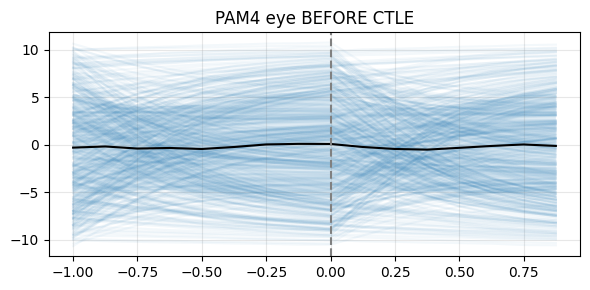

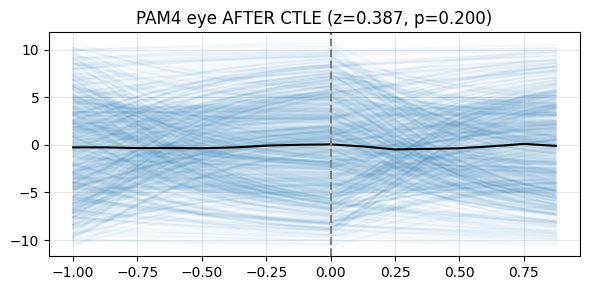

In [56]:
#!/usr/bin/env python3
"""
PAM4 CTLE tuning demo with a realistic lossy SerDes channel.

This version produces a *meaningful* CTLE improvement because the channel
has strong HF loss (skin effect + dielectric loss + long ISI tail).
"""

import numpy as np
import matplotlib.pyplot as plt

# =============================================================================
# Parameters
# =============================================================================
num_symbols = 6000
noise_std = 0.02
sps = 8                    # oversample per symbol (more realistic)
ui = 1.0

# CTLE search ranges
zero_grid = np.linspace(0.05, 0.45, 20)
pole_grid = np.linspace(0.005, 0.20, 20)

np.random.seed(1)

# =============================================================================
# Helper functions
# =============================================================================
def pam4_levels():
    return np.array([-3.0, -1.0, 1.0, 3.0], dtype=float)

def lossy_serdes_channel(sps, length_in_inches=12):
    """
    Realistic SerDes channel model:
    - Skin effect loss ~ sqrt(f)
    - Dielectric loss ~ f
    - Low-pass rolloff
    - Long ISI tail
    """
    N = 4096
    f = np.linspace(0, 0.5, N)  # normalized freq
    # Skin effect
    H_skin = np.exp(-length_in_inches * 0.35 * np.sqrt(f + 1e-12))
    # Dielectric loss
    H_diel = np.exp(-length_in_inches * 0.15 * (f))
    # Low-pass rolloff
    H_lp = 1 / (1 + (f / 0.12)**4)
    H = H_skin * H_diel * H_lp
    # IFFT to impulse
    H_full = np.concatenate([H, H[-2:0:-1]])
    h = np.fft.ifft(H_full)
    h = np.real(h)
    h = h[:8*sps]  # truncate main lobe + ISI tail
    h /= np.sqrt(np.sum(h**2))
    return h

def design_ctle(z, p, gain=1.0):
    z0 = np.exp(-2*np.pi*z)
    p0 = np.exp(-2*np.pi*p)
    b = np.array([gain, -gain*z0])
    a = np.array([1.0, -p0])
    return b, a

def apply_iir(x, b, a):
    y = np.zeros_like(x)
    for n in range(len(x)):
        acc = 0.0
        for k in range(len(b)):
            if n-k >= 0:
                acc += b[k] * x[n-k]
        for k in range(1, len(a)):
            if n-k >= 0:
                acc -= a[k] * y[n-k]
        y[n] = acc / a[0]
    return y

def build_eye(sig, sps, n_ui=2, ntraces=400):
    win = int(n_ui * sps)
    total = ntraces * win
    if len(sig) < total:
        ntraces = len(sig) // win
        total = ntraces * win
    return sig[:total].reshape(ntraces, win)

def pam4_eye_opening(stack, pamL):
    win = stack.shape[1]
    center = win // 2
    samp = stack[:, center]
    idx = np.argmin(np.abs(samp[:, None] - pamL[None, :]), axis=1)
    med = []
    for k in range(len(pamL)):
        vals = samp[idx == k]
        if len(vals) == 0:
            return 0.0
        med.append(np.median(vals))
    med = np.sort(np.array(med))
    return float(np.min(np.diff(med)))

def plot_eye(stack, sps, title):
    win = stack.shape[1]
    t = (np.arange(win) - win//2) / sps
    median = np.median(stack, axis=0)
    std = np.std(stack, axis=0)
    plt.figure(figsize=(6,3))
    for row in stack:
        plt.plot(t, row, color='C0', alpha=0.05)
    plt.plot(t, median, color='k')
    plt.fill_between(t, median-std, median+std, alpha=0.15)
    plt.axvline(0, color='grey', linestyle='--')
    plt.title(title)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# =============================================================================
# Generate PAM4 data
# =============================================================================
pamL = pam4_levels()
sym_idx = np.random.randint(0, 4, num_symbols)
data = pamL[sym_idx]
tx = np.repeat(data, sps)

# =============================================================================
# Channel
# =============================================================================
h_ch = lossy_serdes_channel(sps, length_in_inches=18)  # long, lossy channel
rx_ch = np.convolve(tx, h_ch, mode='same')
rx_ch_noisy = rx_ch + noise_std * np.random.randn(len(rx_ch))

stack_ch = build_eye(rx_ch_noisy, sps)
eo_ch = pam4_eye_opening(stack_ch, pamL)

print("=== Baseline (channel only, PAM4) ===")
print(f"PAM4 eye opening: {eo_ch:.6f}")

# =============================================================================
# CTLE tuning
# =============================================================================
best_eo = -np.inf
best_params = None
best_stack = None

for z in zero_grid:
    for p in pole_grid:
        if p >= z:
            continue

        b, a = design_ctle(z, p)

        # Normalize CTLE DC gain
        imp = np.zeros(256)
        imp[0] = 1.0
        imp_ctle = apply_iir(imp, b, a)
        b_norm = b / (np.sum(imp_ctle) + 1e-12)

        rx_ctle = apply_iir(rx_ch_noisy, b_norm, a)
        stack_ctle = build_eye(rx_ctle, sps)
        eo_ctle = pam4_eye_opening(stack_ctle, pamL)

        if eo_ctle > best_eo:
            best_eo = eo_ctle
            best_params = (z, p, b_norm.copy(), a.copy())
            best_stack = stack_ctle

z_best, p_best, b_best, a_best = best_params

print("\n=== CTLE tuning result ===")
print(f"Best zero: {z_best:.4f}, best pole: {p_best:.4f}")
print(f"Max PAM4 eye opening: {best_eo:.6f}")

print("\n=== Comparison ===")
print(f"Before CTLE: {eo_ch:.6f}")
print(f"After  CTLE: {best_eo:.6f}")

plot_eye(stack_ch, sps, "PAM4 eye BEFORE CTLE")
plot_eye(best_stack, sps, f"PAM4 eye AFTER CTLE (z={z_best:.3f}, p={p_best:.3f})")



=== STABLE CTLE CANDIDATES ===
z=6.000e+09, p=8.000e+10, peaking=21.61 dB
z=6.000e+09, p=8.750e+10, peaking=22.23 dB
z=6.000e+09, p=9.500e+10, peaking=22.78 dB
z=6.000e+09, p=1.025e+11, peaking=23.27 dB
z=6.000e+09, p=1.100e+11, peaking=23.70 dB
z=6.000e+09, p=1.175e+11, peaking=24.09 dB
z=6.000e+09, p=1.250e+11, peaking=24.45 dB
z=6.000e+09, p=1.325e+11, peaking=24.76 dB
z=6.000e+09, p=1.400e+11, peaking=25.05 dB
z=7.000e+09, p=8.000e+10, peaking=20.27 dB
z=7.000e+09, p=8.750e+10, peaking=20.89 dB
z=7.000e+09, p=9.500e+10, peaking=21.44 dB
z=7.000e+09, p=1.025e+11, peaking=21.93 dB
z=7.000e+09, p=1.100e+11, peaking=22.37 dB
z=7.000e+09, p=1.175e+11, peaking=22.76 dB
z=7.000e+09, p=1.250e+11, peaking=23.11 dB
z=7.000e+09, p=1.325e+11, peaking=23.43 dB
z=7.000e+09, p=1.400e+11, peaking=23.71 dB
z=8.000e+09, p=8.000e+10, peaking=19.11 dB
z=8.000e+09, p=8.750e+10, peaking=19.73 dB
z=8.000e+09, p=9.500e+10, peaking=20.28 dB
z=8.000e+09, p=1.025e+11, peaking=20.77 dB
z=8.000e+09, p=1.100e+

ValueError: operands could not be broadcast together with shapes (169985,) (16385,) 

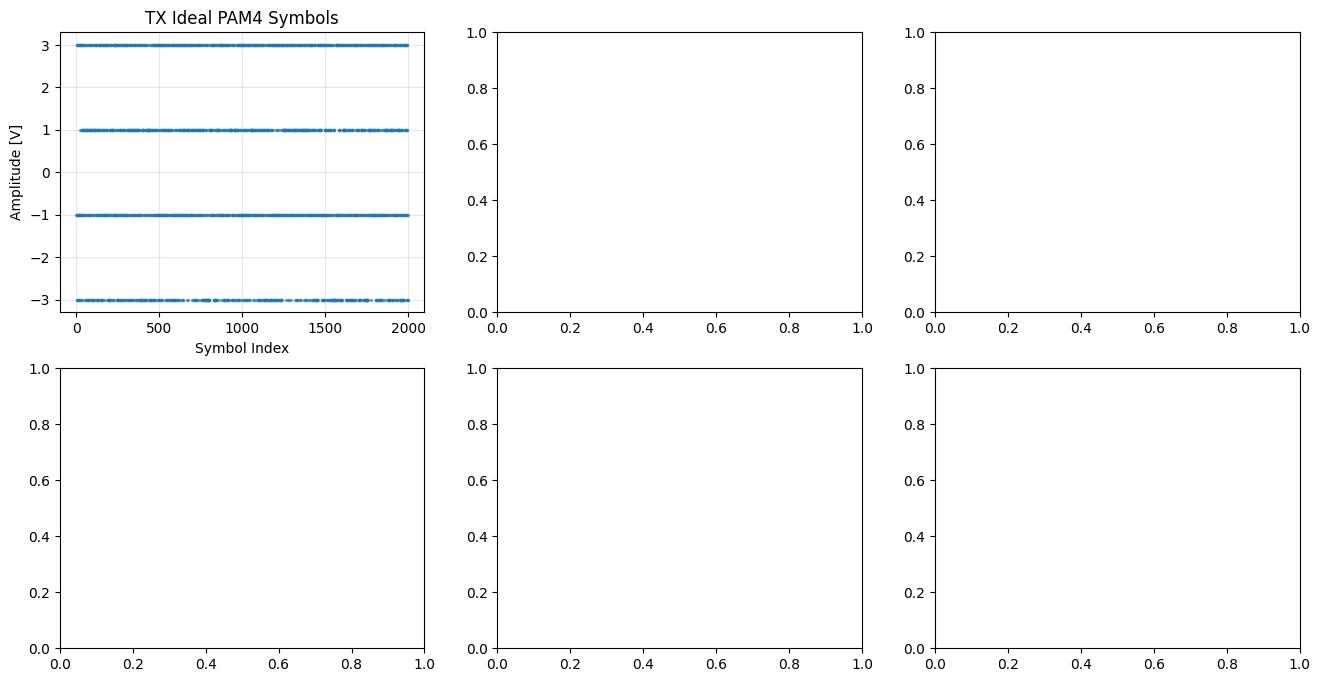

In [57]:
#!/usr/bin/env python3
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# Assumes Transmitter and EyeDiagram are already available in the environment.


# -------------------------------------------------------------
# CTLE DESIGN HELPERS
# -------------------------------------------------------------
def design_ctle_analog(z_rad_s, p_rad_s, gain=1.0):
    """
    Analog CTLE: H(s) = gain * (1 + s/z) / (1 + s/p).
    """
    z = float(z_rad_s)
    p = float(p_rad_s)
    num_s = np.array([gain / z, gain])
    den_s = np.array([1.0 / p, 1.0])
    return num_s, den_s


def bilinear_ctle(num_s, den_s, fs):
    """
    Bilinear transform → digital IIR, normalized to DC gain = 1.
    """
    b_z, a_z = signal.bilinear(num_s, den_s, fs=fs)
    w0, h0 = signal.freqz(b_z, a_z, worN=[0.0])
    H0 = np.abs(h0[0])
    if H0 > 1e-12:
        b_z = b_z / H0
    return b_z, a_z


def ctle_peaking_db(num_s, den_s, f_nyq_hz, n_points=512):
    """
    Compute CTLE peaking in dB up to Nyquist.
    """
    w = np.linspace(0, 2 * np.pi * f_nyq_hz, n_points)
    _, H = signal.freqs(num_s, den_s, worN=w)
    mag = np.maximum(np.abs(H), 1e-20)
    return float(20 * np.log10(mag.max()))


# -------------------------------------------------------------
# STABILITY / VISUAL-QUALITY-ORIENTED SCORING
# -------------------------------------------------------------
def score_eye_stable(signal_in, tx, window_len, ntraces, tstep):
    """
    Score eye with emphasis on stability and visual cleanliness:
    - reward worst-eye height and width
    - penalize noise at decision point
    - penalize excessive vertical spread (over-sharpened / noisy)
    """
    info = EyeDiagram.measure_pam4_eyes(signal_in, window_len, ntraces, tstep)
    hinfo = info["height_info"]

    if not hinfo.get("mode", "").startswith("PAM4"):
        return -np.inf, info

    heights = np.asarray(hinfo.get("eye_heights", []), dtype=float)
    if heights.size != 3 or not np.all(np.isfinite(heights)):
        return -np.inf, info

    width_frac = float(info["width_info"]["width_fraction"])

    traces = EyeDiagram._stack_traces(signal_in, window_len, ntraces)
    sp = window_len // 2
    decision_samples = traces[:, sp]
    noise_std = float(np.std(decision_samples))

    # Vertical spread across time (to penalize very noisy / over-peaked eyes)
    vertical_spread = float(np.mean(np.std(traces, axis=0)))

    worst_eye = float(np.min(heights))

    # Heavily favor stability: smaller noise_std and vertical_spread
    score = (
        1.0 * worst_eye +
        0.7 * width_frac -
        1.2 * noise_std -
        0.8 * vertical_spread
    )
    return score, info


# -------------------------------------------------------------
# ADVANCED STABLE CTLE TUNER (PREFERRED)
# -------------------------------------------------------------
def tune_ctle_stable(signal_ch, tx, z_grid, p_grid,
                     max_peaking_db=12.0, min_peaking_db=4.0,
                     offset=2000):
    """
    CTLE tuner focused on stable, visually clean eyes:
    - restricts peaking to [min_peaking_db, max_peaking_db]
    - uses stability-oriented scoring
    """
    sps = tx.samples_per_symbol
    UI = tx.UI
    fs = tx.frequency * sps
    f_nyq = tx.frequency / 2.0

    window_len = sps * 3
    ntraces = 400  # fewer traces for stability scoring
    tstep = UI / sps

    sig_b = signal_ch[offset:]
    best_score = -np.inf
    best = None

    print("\n=== STABLE CTLE CANDIDATES ===")

    for z in z_grid:
        for p in p_grid:
            if p <= z:
                continue

            num_s, den_s = design_ctle_analog(z, p)
            pk_db = ctle_peaking_db(num_s, den_s, f_nyq)

            print(f"z={z:.3e}, p={p:.3e}, peaking={pk_db:.2f} dB")

            if pk_db > max_peaking_db or pk_db < min_peaking_db:
                continue

            b_ctle, a_ctle = bilinear_ctle(num_s, den_s, fs)
            sig_ctle = signal.lfilter(b_ctle, a_ctle, signal_ch)
            sig_a = sig_ctle[offset:]

            score, info = score_eye_stable(sig_a, tx, window_len, ntraces, tstep)

            if score > best_score:
                best_score = score
                best = {
                    "z": z,
                    "p": p,
                    "num_s": num_s,
                    "den_s": den_s,
                    "b_ctle": b_ctle,
                    "a_ctle": a_ctle,
                    "sig_ctle": sig_ctle,
                    "pam4_info": info,
                    "score": score,
                    "peaking_db": pk_db,
                }

    return best, sig_b


# -------------------------------------------------------------
# SIMPLE CTLE TUNER (FALLBACK)
# -------------------------------------------------------------
def tune_ctle_simple(signal_ch, tx, z_grid, p_grid, offset=2000):
    """
    Simple tuner: maximize worst-eye height, no peaking constraint.
    Used as fallback if stable tuner finds nothing.
    """
    sps = tx.samples_per_symbol
    UI = tx.UI
    fs = tx.frequency * sps
    f_nyq = tx.frequency / 2.0

    window_len = sps * 3
    ntraces = 400
    tstep = UI / sps

    sig_b = signal_ch[offset:]
    best_metric = -np.inf
    best = None

    print("\n=== SIMPLE CTLE TUNER CANDIDATES ===")

    for z in z_grid:
        for p in p_grid:
            if p <= z:
                continue

            num_s, den_s = design_ctle_analog(z, p)
            pk_db = ctle_peaking_db(num_s, den_s, f_nyq)

            print(f"z={z:.3e}, p={p:.3e}, peaking={pk_db:.2f} dB")

            b_ctle, a_ctle = bilinear_ctle(num_s, den_s, fs)
            sig_ctle = signal.lfilter(b_ctle, a_ctle, signal_ch)
            sig_a = sig_ctle[offset:]

            info = EyeDiagram.measure_pam4_eyes(sig_a, window_len, ntraces, tstep)
            hinfo = info["height_info"]

            if not hinfo.get("mode", "").startswith("PAM4"):
                continue

            heights = np.asarray(hinfo.get("eye_heights", []), dtype=float)
            if heights.size != 3 or not np.all(np.isfinite(heights)):
                continue

            metric = float(np.min(heights))
            if metric > best_metric:
                best_metric = metric
                best = {
                    "z": z,
                    "p": p,
                    "num_s": num_s,
                    "den_s": den_s,
                    "b_ctle": b_ctle,
                    "a_ctle": a_ctle,
                    "sig_ctle": sig_ctle,
                    "pam4_info": info,
                    "peaking_db": pk_db,
                }

    return best, sig_b


# -------------------------------------------------------------
# MULTI-PANEL PLOTTING (CLEAN, STABLE EYES)
# -------------------------------------------------------------
def plot_multi_panel(tx, f, H_ch, signal_ch, best_ctle, sig_b, title_suffix=""):
    sps = tx.samples_per_symbol
    UI = tx.UI
    tstep = UI / sps

    # 2 UI window for clarity
    window_len = int(sps * 2)
    ntraces_full = 300
    ntraces_plot = 120
    offset = 2000

    sig_b_use = sig_b[:window_len * ntraces_full]
    sig_a_full = best_ctle["sig_ctle"][offset:]
    sig_a_use = sig_a_full[:window_len * ntraces_full]

    pam4_before = EyeDiagram.measure_pam4_eyes(sig_b_use, window_len, ntraces_full, tstep)
    pam4_after = EyeDiagram.measure_pam4_eyes(sig_a_use, window_len, ntraces_full, tstep)

    traces_b_full = EyeDiagram._stack_traces(sig_b_use, window_len, ntraces_full)
    traces_a_full = EyeDiagram._stack_traces(sig_a_use, window_len, ntraces_full)

    step = max(1, ntraces_full // ntraces_plot)
    traces_b = traces_b_full[::step]
    traces_a = traces_a_full[::step]

    t_eye = EyeDiagram._time_vector(window_len, tstep) * 1e12
    sp = window_len // 2

    samp_b = traces_b_full[:, sp]
    samp_a = traces_a_full[:, sp]

    # CTLE analog freq response
    w = 2 * np.pi * f
    num_s = best_ctle["num_s"]
    den_s = best_ctle["den_s"]
    _, H_ctle = signal.freqs(num_s, den_s, worN=w)

    fig, axes = plt.subplots(2, 3, figsize=(16, 8))
    ax_tx, ax_bode, ax_wave, ax_eye_b, ax_eye_a, ax_hist = axes.flatten()

    # 1) TX symbols
    ax_tx.plot(tx.signal_BR[:2000], ".", markersize=3, alpha=0.5)
    ax_tx.set_title("TX Ideal PAM4 Symbols")
    ax_tx.set_xlabel("Symbol Index")
    ax_tx.set_ylabel("Amplitude [V]")
    ax_tx.grid(alpha=0.3)

    # 2) Bode
    eps = 1e-20
    mag_ch = np.maximum(np.abs(H_ch), eps)
    mag_ctle = np.maximum(np.abs(H_ctle), eps)
    mag_comb = np.maximum(np.abs(H_ch * H_ctle), eps)

    ax_bode.semilogx(f * 1e-9, 20 * np.log10(mag_ch), label="Channel")
    ax_bode.semilogx(f * 1e-9, 20 * np.log10(mag_ctle), label="CTLE")
    ax_bode.semilogx(f * 1e-9, 20 * np.log10(mag_comb), label="Channel+CTLE")
    ax_bode.axvline(tx.frequency / 2.0 * 1e-9, color="grey", linestyle="--", label="Nyquist")
    ax_bode.set_xlabel("Frequency [GHz]")
    ax_bode.set_ylabel("Magnitude [dB]")
    ax_bode.set_title(
        f"Channel & CTLE Bode\nz={best_ctle['z']:.2e}, p={best_ctle['p']:.2e}, "
        f"peaking={best_ctle['peaking_db']:.2f} dB"
    )
    ax_bode.grid(alpha=0.3)
    ax_bode.legend(fontsize=8)

    # 3) Waveform
    n_show = 4000
    ax_wave.plot(signal_ch[offset:offset + n_show], ".", markersize=2, alpha=0.3, label="Channel")
    ax_wave.plot(best_ctle["sig_ctle"][offset:offset + n_show], ".", markersize=2, alpha=0.3, label="Channel+CTLE")
    ax_wave.set_title("Channel Output vs CTLE Output (Segment)")
    ax_wave.set_xlabel("Sample Index")
    ax_wave.set_ylabel("Amplitude [V]")
    ax_wave.grid(alpha=0.3)
    ax_wave.legend(fontsize=8)

    # Y-limits from PAM4 cluster means after CTLE
    if pam4_after["height_info"].get("mode", "").startswith("PAM4"):
        means_a = np.asarray(pam4_after["height_info"]["cluster_means"])
        ymin = float(means_a.min() - 0.7)
        ymax = float(means_a.max() + 0.7)
    else:
        ymin, ymax = None, None

    # 4) Eye before CTLE
    for row in traces_b:
        ax_eye_b.plot(t_eye, row, color="C0", linewidth=0.08, alpha=0.10)
    median_b = np.median(traces_b_full, axis=0)
    std_b = np.std(traces_b_full, axis=0)
    ax_eye_b.plot(t_eye, median_b, color="k", linewidth=1.2, label="Median")
    ax_eye_b.fill_between(t_eye, median_b - std_b, median_b + std_b,
                          color="k", alpha=0.06, label="±1σ")
    ax_eye_b.axvline(t_eye[sp], color="grey", linestyle="--", linewidth=0.8, label="Decision")
    ax_eye_b.set_title("Eye Before CTLE")
    ax_eye_b.set_xlabel("Time [ps]")
    ax_eye_b.set_ylabel("Amplitude [V]")
    ax_eye_b.grid(alpha=0.25)
    if ymin is not None:
        ax_eye_b.set_ylim(ymin, ymax)
    ax_eye_b.legend(fontsize=8)

    if pam4_before["height_info"].get("mode", "").startswith("PAM4"):
        h_b = np.asarray(pam4_before["height_info"]["eye_heights"])
        w_b = pam4_before["width_info"]["width_fraction"]
        txt_b = f"H: {h_b[0]:.2f}, {h_b[1]:.2f}, {h_b[2]:.2f} V\nW: {w_b:.2f} UI"
        ax_eye_b.text(0.02, 0.05, txt_b, transform=ax_eye_b.transAxes,
                      fontsize=8, bbox=dict(boxstyle="round", facecolor="white", alpha=0.7))

    # 5) Eye after CTLE
    for row in traces_a:
        ax_eye_a.plot(t_eye, row, color="C1", linewidth=0.08, alpha=0.10)
    median_a = np.median(traces_a_full, axis=0)
    std_a = np.std(traces_a_full, axis=0)
    ax_eye_a.plot(t_eye, median_a, color="k", linewidth=1.2, label="Median")
    ax_eye_a.fill_between(t_eye, median_a - std_a, median_a + std_a,
                          color="k", alpha=0.06, label="±1σ")
    ax_eye_a.axvline(t_eye[sp], color="grey", linestyle="--", linewidth=0.8, label="Decision")
    ax_eye_a.set_title("Eye After CTLE")
    ax_eye_a.set_xlabel("Time [ps]")
    ax_eye_a.grid(alpha=0.25)
    if ymin is not None:
        ax_eye_a.set_ylim(ymin, ymax)
    ax_eye_a.legend(fontsize=8)

    if pam4_after["height_info"].get("mode", "").startswith("PAM4"):
        h_a = np.asarray(pam4_after["height_info"]["eye_heights"])
        w_a = pam4_after["width_info"]["width_fraction"]
        txt_a = f"H: {h_a[0]:.2f}, {h_a[1]:.2f}, {h_a[2]:.2f} V\nW: {w_a:.2f} UI"
        ax_eye_a.text(0.02, 0.05, txt_a, transform=ax_eye_a.transAxes,
                      fontsize=8, bbox=dict(boxstyle="round", facecolor="white", alpha=0.7))

    # 6) Histogram
    ax_hist.hist(samp_b, bins=128, color="C0", alpha=0.6, edgecolor="k", label="Before")
    ax_hist.hist(samp_a, bins=128, color="C1", alpha=0.6, edgecolor="k", label="After")
    ax_hist.set_title("Decision Point Histogram")
    ax_hist.set_xlabel("Amplitude [V]")
    ax_hist.set_ylabel("Counts")
    ax_hist.grid(alpha=0.25)
    ax_hist.legend(fontsize=8)

    fig.suptitle(f"Real Channel + CTLE Tuning — Stable View {title_suffix}",
                 fontsize=14, fontweight="bold")
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


# -------------------------------------------------------------
# MAIN PIPELINE
# -------------------------------------------------------------
def main():
    # Channel data
    f = np.load("./examples/example_channel/data/f.npy")
    h_ch = np.load("./examples/example_channel/data/h_thru.npy")
    H_ch = np.load("./examples/example_channel/data/TF_thru.npy")

    #set poles and zeroes for peaking at nyquist freq
    #high peaking because channel is high insertion loss
    z = 2e10
    p = 1.7e11
    k = p**2/z
    #frequency vector in rad/s
    w = f*(2*np.pi)

    #calculate Frequency response of CTLE at given frequencies
    w, H_ctle = sp.signal.freqs([k/p**2, k*z/p**2], [1/p**2, 2/p, 1], w)

    # TX setup
    voltage_levels = np.array([-3, -1, 1, 3])
    nyquist_f = 26.56e9
    baud_rate = 2 * nyquist_f
    sps = 64

    # compute and save impulse response of CTLE transfer function
    h_ctle, t_ctle = ChModel.freq2impulse(H_ctle,f)
    h_ctle = h_ctle[0:200]

    np.save("./examples/example_channel/data/h_ctle.npy", h_ctle)

    TX = Transmitter.from_prbs(
        order=20,
        seed=1,
        voltage_levels=voltage_levels,
        frequency=baud_rate,
        prqs=True,
        debug=False,
    )
    TX.oversample(sps)

    # Channel convolution
    signal_ch = signal.fftconvolve(TX.signal_oversampled, h_ch, mode="same")

    # CTLE grids tuned for moderate peaking (visually clean, stable)
    z_grid = np.linspace(0.6e10, 1.4e10, 9)
    p_grid = np.linspace(0.8e11, 1.4e11, 9)

    # Stable tuner (preferred)
    best_stable, sig_b_stable = tune_ctle_stable(
        signal_ch,
        TX,
        z_grid,
        p_grid,
        max_peaking_db=12.0,
        min_peaking_db=4.0,
    )

    if best_stable is None:
        print("\nStable tuner found no CTLE within peaking limits.")
        print("Falling back to simple CTLE tuner.")
        best_simple, sig_b_simple = tune_ctle_simple(signal_ch, TX, z_grid, p_grid)
        best = best_simple
        sig_b = sig_b_simple
        title_suffix = "(Simple Fallback)"
    else:
        best = best_stable
        sig_b = sig_b_stable
        title_suffix = "(Stable Tuner)"

    print("\n=== BEST CTLE (STABLE/OR FALLBACK) ===")
    print(best)

    plot_multi_panel(TX, f, H_ch, signal_ch, best, sig_b, title_suffix=title_suffix)
    import base64
    from io import BytesIO
    buf = BytesIO()
    plt.savefig(buf, format='png', dpi=150, bbox_inches='tight')
    buf.seek(0)
    img_b64 = base64.b64encode(buf.read()).decode('utf-8')
    print("===BEGIN IMAGE===")
    print(img_b64)
    print("===END IMAGE===")


main()


## FFE and DFE
This file shows example of FFE and DFE. Equalization of the signal with CTLE generated in 2_ctle.py

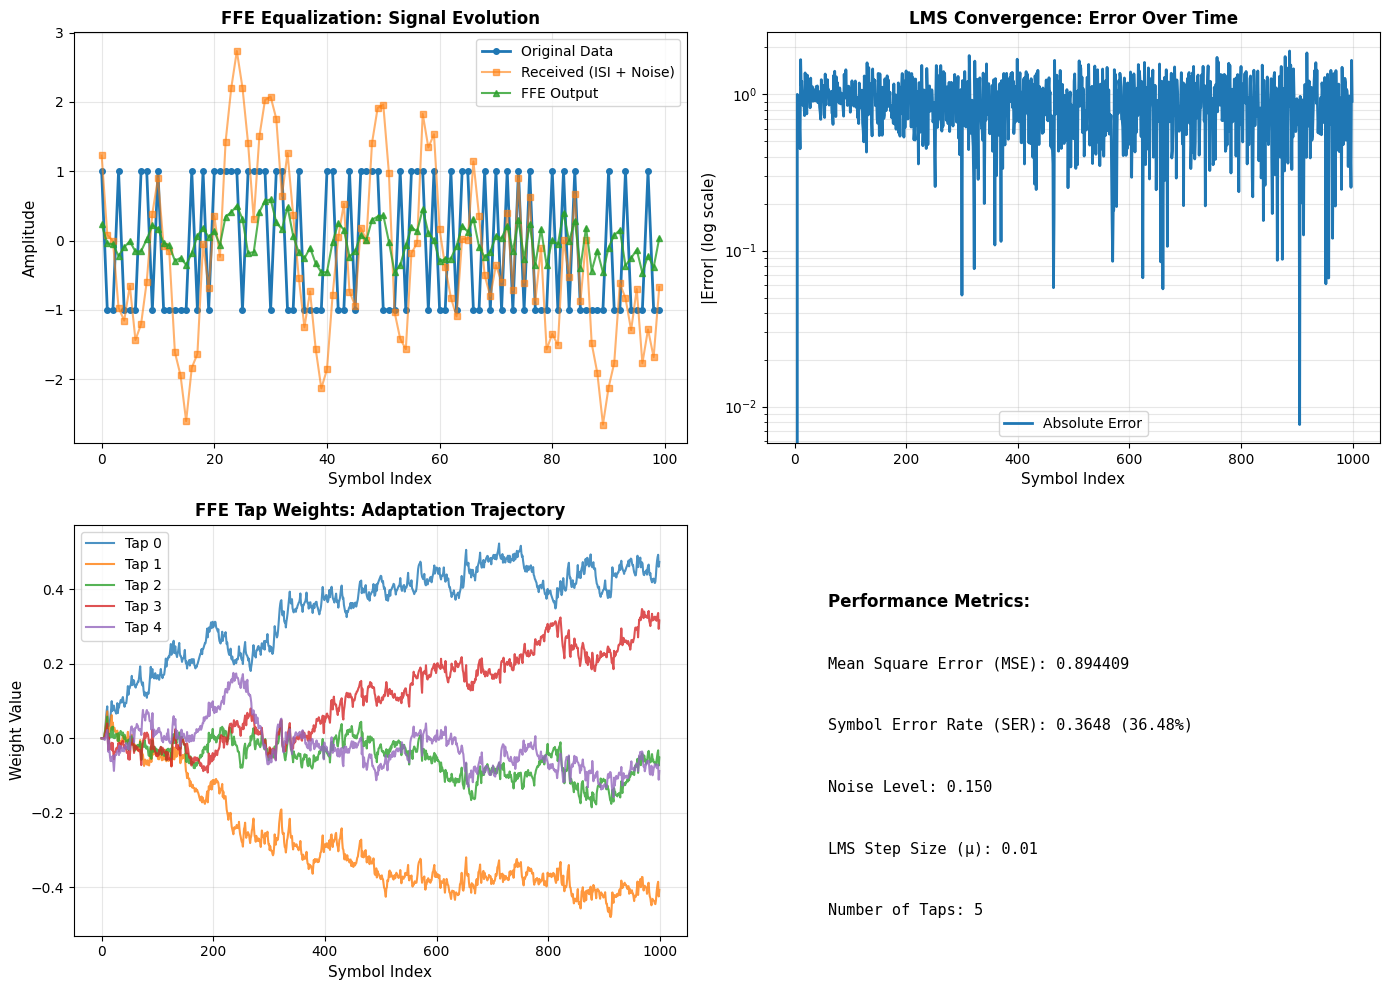

✓ FFE LMS Adaptation Complete
  Final MSE: 0.894409
  Final SER: 0.3648
  Converged tap weights: [ 0.4728 -0.4065 -0.0516  0.3157 -0.0877]


In [29]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================================
# FFE Demonstration: LMS Adaptation for ISI Mitigation
# ============================================================================
# This example shows how an FFE adapts its tap weights using the LMS algorithm
# to equalize a channel with ISI and noise.

# Parameters
num_symbols = 1000
num_taps = 5
mu = 0.01  # LMS step size (learning rate)
np.random.seed(0)

# Channel model: realistic ISI channel
# Simulates a cable with attenuation at DC and frequency-dependent loss
channel = np.array([0.3, 0.5, 1.0, 0.5, 0.3])  # 5-tap symmetric channel
noise_std = 0.15  # Gaussian noise level

# Generate random binary input: +1 or -1 (BPSK)
data = 2 * np.random.randint(0, 2, num_symbols) - 1

# Simulate transmission through channel (convolution)
tx_signal = np.convolve(data, channel, mode='full')[:num_symbols]

# Add noise to simulate realistic conditions
noise = noise_std * np.random.randn(num_symbols)
received = tx_signal + noise

# Initialize FFE equalizer
weights = np.zeros(num_taps)
ffe_output = np.zeros(num_symbols)
error_signal = np.zeros(num_symbols)
weight_history = np.zeros((num_symbols, num_taps))

# LMS Adaptation Loop
# Process each symbol and adapt tap weights
for i in range(num_taps, num_symbols):
    # Input vector: received signal samples (reversed for convolution ordering)
    x = received[i - num_taps + 1:i + 1][::-1]  # Shape: (num_taps,)
    
    # FFE output: filter output
    y = np.dot(weights, x)
    
    # Desired output: ideal symbol
    d = data[i]
    
    # Error: difference between desired and actual output
    e = d - y
    
    # LMS weight update: w = w + mu * e * x
    weights = weights + mu * e * x
    
    # Store results for analysis
    ffe_output[i] = y
    error_signal[i] = e
    weight_history[i] = weights.copy()

# Compute performance metrics
mse = np.mean(error_signal[num_taps:] ** 2)
# Symbol decisions using simple threshold
decisions = np.sign(ffe_output)
ser = np.mean(decisions[num_taps:] != data[num_taps:])

# Plot results
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Signal comparison
ax = axes[0, 0]
time_window = slice(100, 200)  # Show a window of symbols
ax.plot(data[time_window], 'o-', label='Original Data', linewidth=2, markersize=4)
ax.plot(received[time_window], 's-', label='Received (ISI + Noise)', alpha=0.6, markersize=4)
ax.plot(ffe_output[time_window], '^-', label='FFE Output', alpha=0.8, markersize=4)
ax.set_xlabel('Symbol Index', fontsize=11)
ax.set_ylabel('Amplitude', fontsize=11)
ax.set_title('FFE Equalization: Signal Evolution', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Plot 2: Error convergence
ax = axes[0, 1]
ax.semilogy(np.abs(error_signal), label='Absolute Error', linewidth=2)
ax.set_xlabel('Symbol Index', fontsize=11)
ax.set_ylabel('|Error| (log scale)', fontsize=11)
ax.set_title('LMS Convergence: Error Over Time', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, which='both')

# Plot 3: Tap weight evolution
ax = axes[1, 0]
for tap_idx in range(num_taps):
    ax.plot(weight_history[:, tap_idx], label=f'Tap {tap_idx}', alpha=0.8)
ax.set_xlabel('Symbol Index', fontsize=11)
ax.set_ylabel('Weight Value', fontsize=11)
ax.set_title('FFE Tap Weights: Adaptation Trajectory', fontsize=12, fontweight='bold')
ax.legend(fontsize=10, loc='best')
ax.grid(True, alpha=0.3)

# Plot 4: Performance summary
ax = axes[1, 1]
ax.text(0.1, 0.8, 'Performance Metrics:', fontsize=12, fontweight='bold', transform=ax.transAxes)
ax.text(0.1, 0.65, f'Mean Square Error (MSE): {mse:.6f}', fontsize=11, transform=ax.transAxes, family='monospace')
ax.text(0.1, 0.50, f'Symbol Error Rate (SER): {ser:.4f} ({ser*100:.2f}%)', fontsize=11, transform=ax.transAxes, family='monospace')
ax.text(0.1, 0.35, f'Noise Level: {noise_std:.3f}', fontsize=11, transform=ax.transAxes, family='monospace')
ax.text(0.1, 0.20, f'LMS Step Size (μ): {mu}', fontsize=11, transform=ax.transAxes, family='monospace')
ax.text(0.1, 0.05, f'Number of Taps: {num_taps}', fontsize=11, transform=ax.transAxes, family='monospace')
ax.axis('off')

plt.tight_layout()
plt.show()

print("✓ FFE LMS Adaptation Complete")
print(f"  Final MSE: {mse:.6f}")
print(f"  Final SER: {ser:.4f}")
print(f"  Converged tap weights: {np.round(weights, 4)}")


Estimate Slicer

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as sp_signal


class Slicer:
    """
    PAM4 slicer:
      - Histogram-based level estimation
      - Soft slicer
      - SNR estimation
      - Optional fine-tuning
      - Optional error plotting
    """

    def __init__(self, default_levels=None, num_bins=180, min_prob=1e-2):
        self.default_levels = (
            np.array([-3, -1, 1, 3], dtype=float)
            if default_levels is None else np.asarray(default_levels, dtype=float)
        )
        self.num_bins = num_bins
        self.min_prob = min_prob

    # ---------------------------------------------------------
    # Histogram-based slicer estimation
    # ---------------------------------------------------------
    def estimate_from_hist(self, samples):
        x = np.asarray(samples, dtype=float)
        if x.size < 100:
            # fallback
            thr = [(self.default_levels[i] + self.default_levels[i+1]) / 2
                   for i in range(3)]
            return self.default_levels.copy(), np.array(thr, dtype=float)

        hist, edges = np.histogram(x, bins=self.num_bins)
        centers = 0.5 * (edges[:-1] + edges[1:])
        prob = hist / float(np.sum(hist))

        active = np.where(prob > self.min_prob)[0]
        if active.size < 4:
            thr = [(self.default_levels[i] + self.default_levels[i+1]) / 2
                   for i in range(3)]
            return self.default_levels.copy(), np.array(thr, dtype=float)

        # find 4 largest peaks
        peak_idx = np.argpartition(hist, -4)[-4:]
        peak_idx = peak_idx[np.argsort(centers[peak_idx])]
        slc_levels = centers[peak_idx]

        thr = [(slc_levels[i] + slc_levels[i+1]) / 2 for i in range(3)]
        return slc_levels, np.array(thr, dtype=float)

    # ---------------------------------------------------------
    # Soft slicer
    # ---------------------------------------------------------
    def soft_slice(self, samples, thr, slc_levels):
        x = np.asarray(samples, dtype=float)
        l0, l1, l2 = thr
        s0, s1, s2, s3 = slc_levels

        out = np.zeros_like(x, dtype=int)
        out[x >= l2] = 3
        out[(x >= l1) & (x < l2)] = 2
        out[(x >= l0) & (x < l1)] = 1

        out_soft = np.empty_like(x)
        out_soft[out == 0] = s0
        out_soft[out == 1] = s1
        out_soft[out == 2] = s2
        out_soft[out == 3] = s3

        err = x - out_soft
        return out, err, out_soft

    # ---------------------------------------------------------
    # Full slicer estimation + SNR
    # ---------------------------------------------------------
    def run(self, samples, fine_tune=False, plot_error=False):
        slc_levels, thr = self.estimate_from_hist(samples)
        out, err, out_soft = self.soft_slice(samples, thr, slc_levels)

        # Optional fine-tuning
        if fine_tune:
            # bias correction
            mean_err = np.array([
                np.mean(err[out == lvl]) if np.any(out == lvl) else 0.0
                for lvl in [0, 1, 2, 3]
            ])
            slc_levels = slc_levels + mean_err
            thr = [(slc_levels[i] + slc_levels[i+1]) / 2 for i in range(3)]
            thr = np.array(thr, dtype=float)
            out, err, out_soft = self.soft_slice(samples, thr, slc_levels)

        # SNR
        sig_rms = np.sqrt(np.mean(out_soft**2))
        err_rms = np.sqrt(np.mean(err**2)) + 1e-30
        snr_db = 20 * np.log10(sig_rms / err_rms)

        if plot_error:
            plt.figure(dpi=90)
            plt.plot(err, linewidth=0.5)
            plt.title(f"Slicer Error (SNR={snr_db:.2f} dB)")
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()
            import base64
            from io import BytesIO
            buf = BytesIO()
            plt.savefig(buf, format='png', dpi=150, bbox_inches='tight')
            buf.seek(0)
            img_b64 = base64.b64encode(buf.read()).decode('utf-8')
            print("===BEGIN IMAGE===")
            print(img_b64)
            print("===END IMAGE===")

        return slc_levels, thr, err, out, snr_db


tx_wave min/max: -3.15 3.05
sig_ch  min/max: -2.0239830546818216 0.9936399231716097
sig_ctle min/max: -2.2179075140551987 1.5611817269553145
First 20 br_ctle samples:
[ 1.17479986  0.69540304 -0.67956856 -1.1927971   0.86133219  0.1900472
  1.2457698   0.71554578 -0.6244857  -1.15010758  0.87314755  0.23480092
  1.31207242  0.71345111 -0.60595634 -1.13682802  0.90579801  0.24170607
  1.32457766  0.9020214 ]
br_ctle min/max: -2.1944376545880266 1.4599717226017654


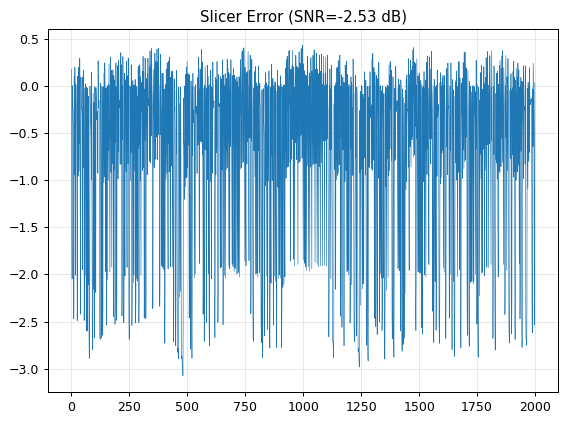

===BEGIN IMAGE===
iVBORw0KGgoAAAANSUhEUgAAA94AAALtCAYAAADe9LycAAAAOnRFWHRTb2Z0d2FyZQBNYXRwbG90bGliIHZlcnNpb24zLjEwLjgsIGh0dHBzOi8vbWF0cGxvdGxpYi5vcmcvwVt1zgAAAAlwSFlzAAAXEgAAFxIBZ5/SUgAAEapJREFUeJzt2bENgAAQAzFg/52fKa6IZA+Q/pT37u4BAAAAEl8zCwAAAAhvAAAAiHm8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAQHgDAADAJo83AAAAhIQ3AAAAhIQ3AAAAhIQ3AAAAhIQ3AA

C:\Users\fkeyh\AppData\Local\Temp\ipykernel_1392\3742026018.py:129: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


<Figure size 640x480 with 0 Axes>

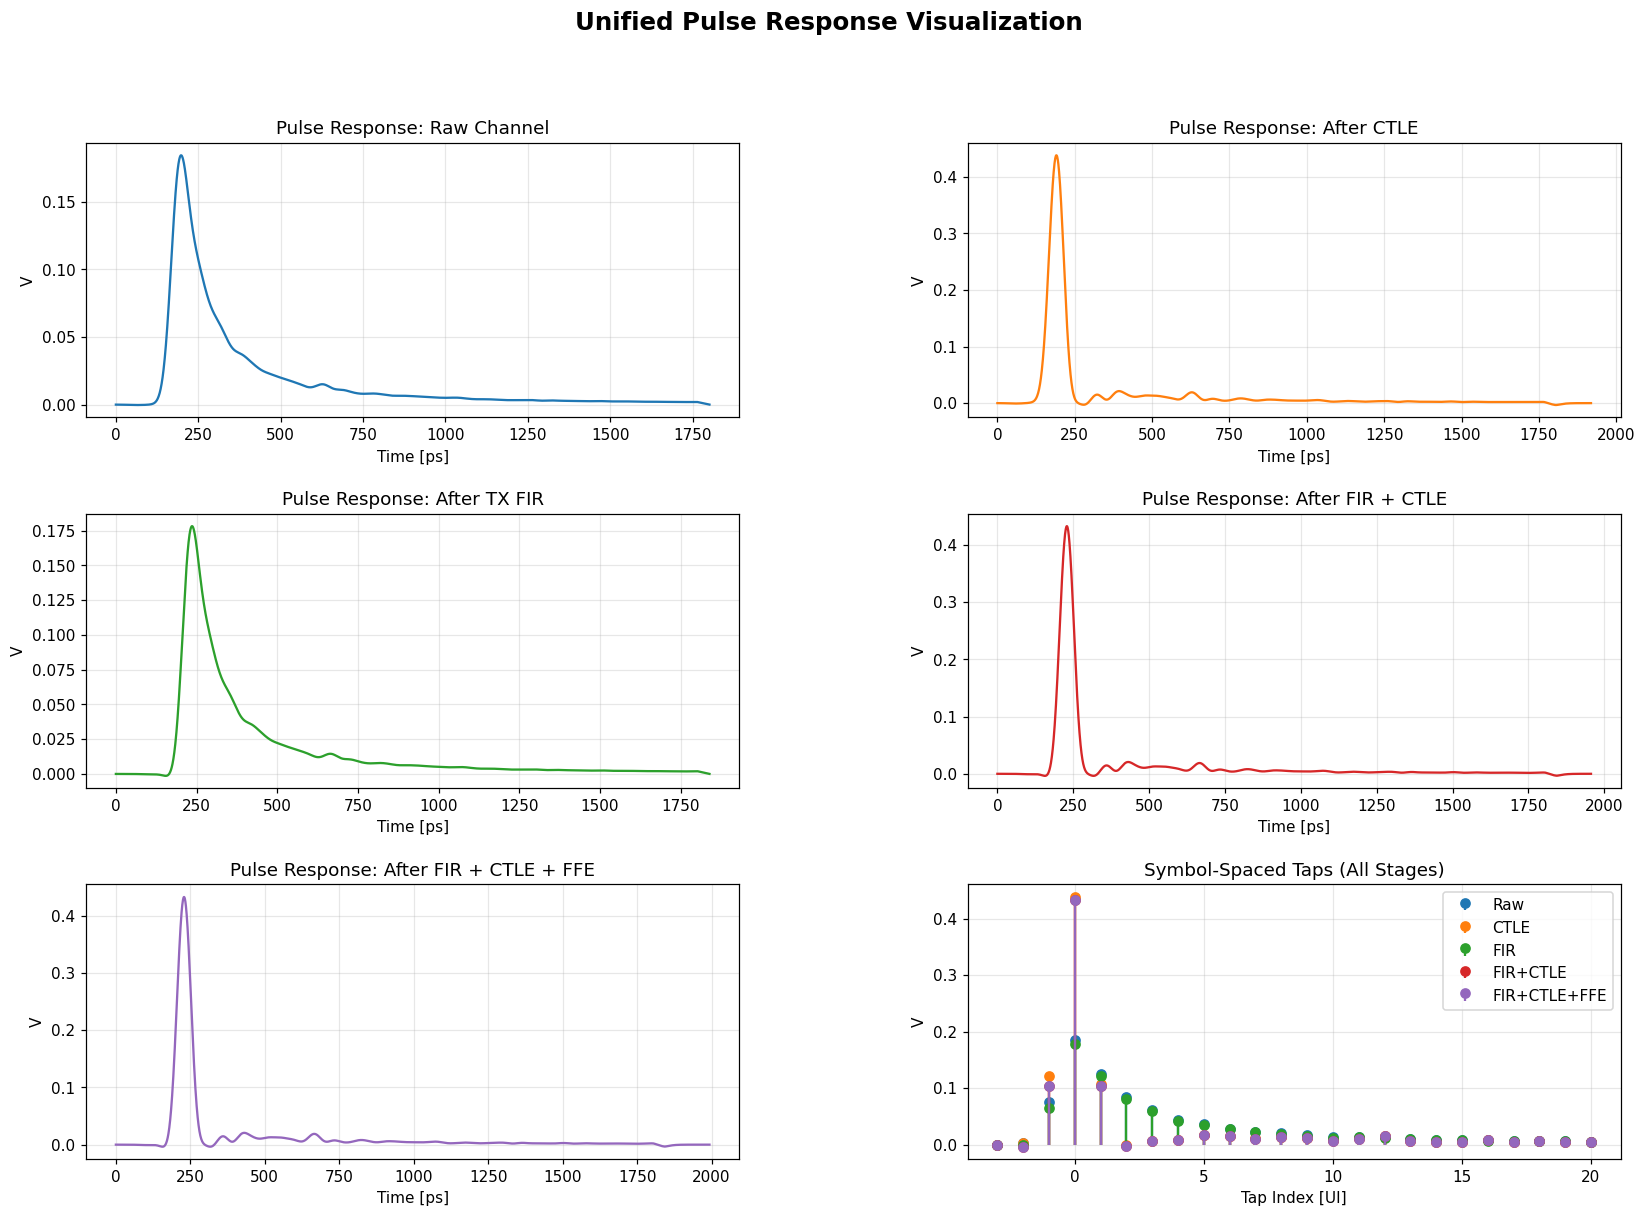

C:\Users\fkeyh\AppData\Local\Temp\ipykernel_1392\3742026018.py:168: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


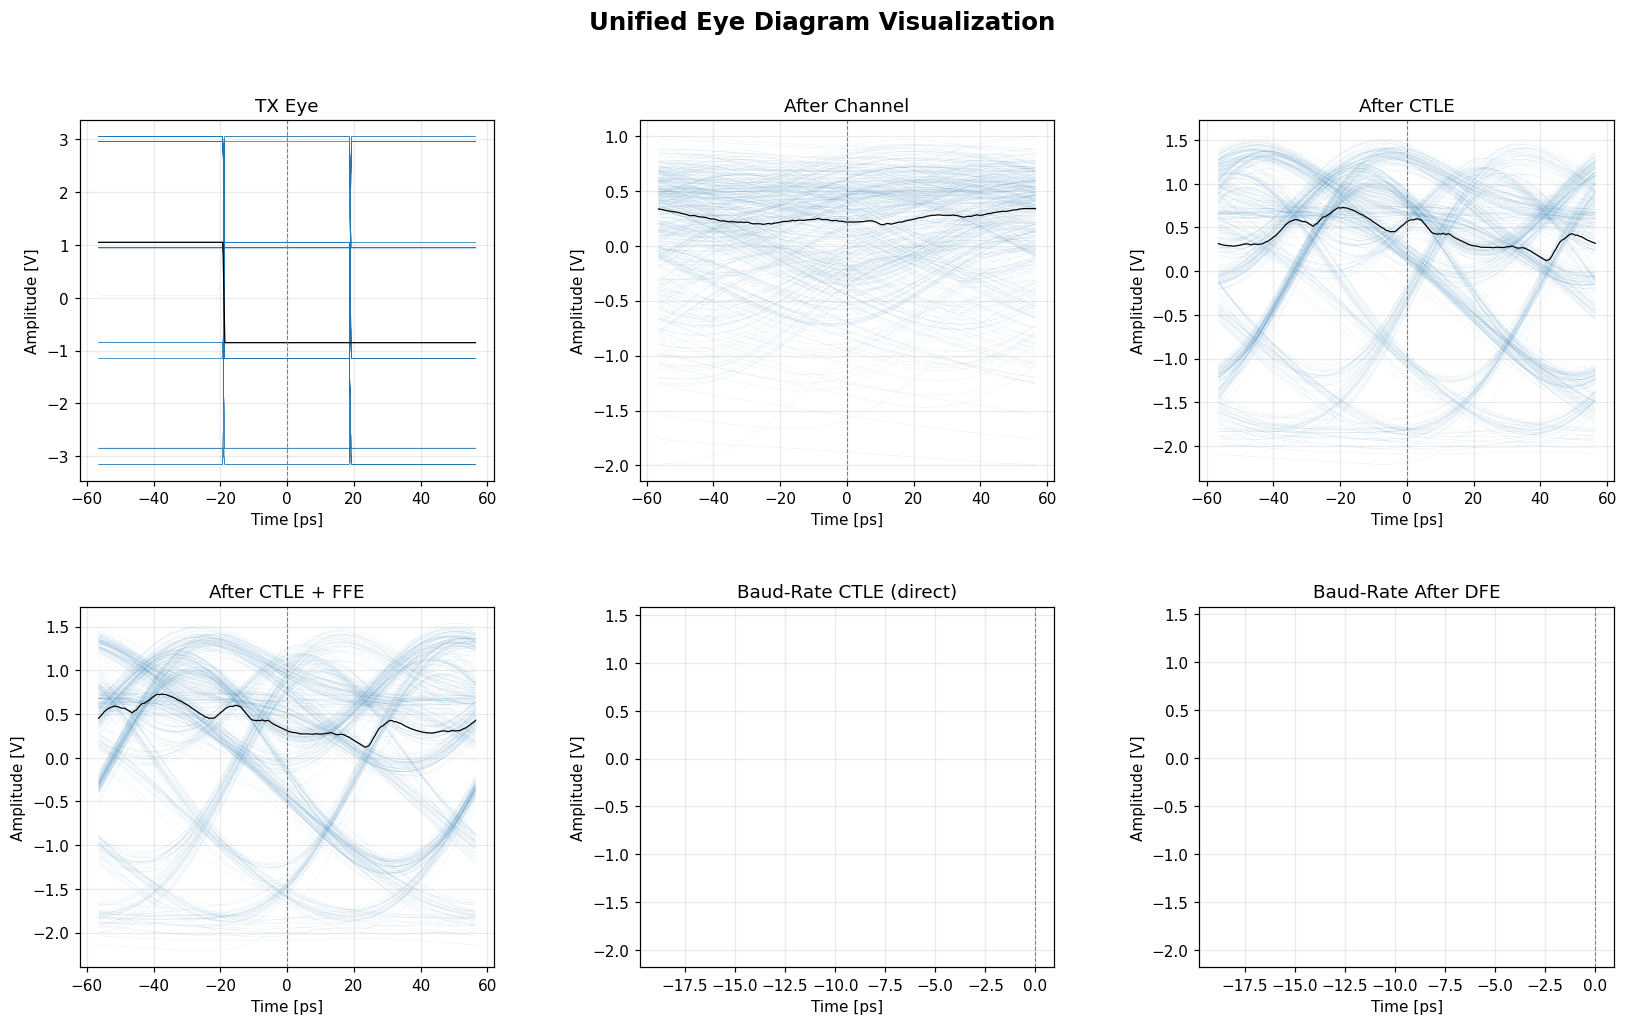

In [34]:
import numpy as np
import scipy as sp
from scipy import signal
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec


# ============================================================
# PATCHED Signal.channel_coefficients (NO PLOTTING)
# ============================================================
def patched_channel_coefficients(pulse_response, t, samples_per_symbol,
                                 n_precursors, n_postcursors,
                                 res=70, title="Channel Coefficients"):
    pr = np.asarray(pulse_response, dtype=np.float64)
    n_taps = n_precursors + n_postcursors + 1
    max_idx = int(np.argmax(np.abs(pr)))
    tap_indices = max_idx + np.arange(-n_precursors,
                                      n_postcursors + 1) * samples_per_symbol
    tap_indices = np.clip(tap_indices, 0, len(pr) - 1).astype(int)
    coefficients = pr[tap_indices]
    return coefficients


Signal.channel_coefficients = staticmethod(patched_channel_coefficients)


# ============================================================
# SAFE EYE PLOT
# ============================================================
def safe_eye(ax, sig, sps, UI, title, span_ui=3, max_traces=400, color="C0"):
    sig = np.asarray(sig, dtype=float)
    window_len = int(span_ui * sps)
    if window_len <= 0:
        ax.set_title(title + " (invalid window)")
        return
    ntraces = min(max_traces, sig.size // window_len)
    if ntraces < 1:
        ax.set_title(title + " (insufficient samples)")
        return
    cropped = sig[:ntraces * window_len]
    traces = cropped.reshape(ntraces, window_len)
    t = np.linspace(-span_ui / 2 * UI, span_ui / 2 * UI, window_len) * 1e12
    for row in traces:
        ax.plot(t, row, color=color, alpha=0.25, linewidth=0.12)
    ax.plot(t, np.median(traces, axis=0), color="k", linewidth=0.8)
    ax.axvline(0.0, color="grey", linestyle="--", linewidth=0.7)
    ax.set_title(title)
    ax.set_xlabel("Time [ps]")
    ax.set_ylabel("Amplitude [V]")
    ax.grid(alpha=0.25)


# ============================================================
# UNIFIED PULSE RESPONSE MULTI-GRAPH
# ============================================================
def plot_unified_pulse_responses(
    pr_raw, pr_ctle, pr_fir, pr_fir_ctle, pr_fir_ctle_ffe,
    sps, symbol_rate
):
    fig = plt.figure(figsize=(18, 12), dpi=110)
    gs = GridSpec(3, 2, figure=fig, wspace=0.35, hspace=0.35)

    def t_axis(pr):
        return np.arange(pr.size) / (symbol_rate * sps) * 1e12

    ax1 = fig.add_subplot(gs[0, 0])
    ax1.plot(t_axis(pr_raw), pr_raw, color="C0")
    ax1.set_title("Pulse Response: Raw Channel")
    ax1.set_xlabel("Time [ps]")
    ax1.set_ylabel("V")
    ax1.grid(True, alpha=0.3)

    ax2 = fig.add_subplot(gs[0, 1])
    ax2.plot(t_axis(pr_ctle), pr_ctle, color="C1")
    ax2.set_title("Pulse Response: After CTLE")
    ax2.set_xlabel("Time [ps]")
    ax2.set_ylabel("V")
    ax2.grid(True, alpha=0.3)

    ax3 = fig.add_subplot(gs[1, 0])
    ax3.plot(t_axis(pr_fir), pr_fir, color="C2")
    ax3.set_title("Pulse Response: After TX FIR")
    ax3.set_xlabel("Time [ps]")
    ax3.set_ylabel("V")
    ax3.grid(True, alpha=0.3)

    ax4 = fig.add_subplot(gs[1, 1])
    ax4.plot(t_axis(pr_fir_ctle), pr_fir_ctle, color="C3")
    ax4.set_title("Pulse Response: After FIR + CTLE")
    ax4.set_xlabel("Time [ps]")
    ax4.set_ylabel("V")
    ax4.grid(True, alpha=0.3)

    ax5 = fig.add_subplot(gs[2, 0])
    ax5.plot(t_axis(pr_fir_ctle_ffe), pr_fir_ctle_ffe, color="C4")
    ax5.set_title("Pulse Response: After FIR + CTLE + FFE")
    ax5.set_xlabel("Time [ps]")
    ax5.set_ylabel("V")
    ax5.grid(True, alpha=0.3)

    ax6 = fig.add_subplot(gs[2, 1])
    for pr, label, color in [
        (pr_raw, "Raw", "C0"),
        (pr_ctle, "CTLE", "C1"),
        (pr_fir, "FIR", "C2"),
        (pr_fir_ctle, "FIR+CTLE", "C3"),
        (pr_fir_ctle_ffe, "FIR+CTLE+FFE", "C4"),
    ]:
        taps = Signal.channel_coefficients(
            pr,
            np.arange(pr.size) / (symbol_rate * sps),
            sps,
            n_precursors=3,
            n_postcursors=20,
            res=70,
            title=""
        )
        idx = np.arange(-3, taps.size - 3)
        ax6.stem(idx, taps, linefmt=color, markerfmt=color + "o",
                 basefmt=" ", label=label)

    ax6.set_title("Symbol-Spaced Taps (All Stages)")
    ax6.set_xlabel("Tap Index [UI]")
    ax6.set_ylabel("V")
    ax6.grid(True, alpha=0.3)
    ax6.legend()

    plt.suptitle("Unified Pulse Response Visualization", fontsize=16, fontweight="bold")
    plt.tight_layout()
    plt.show()


# ============================================================
# UNIFIED EYE MULTI-GRAPH
# ============================================================
def plot_unified_eyes(
    tx_wave,
    sig_ch,
    sig_ctle,
    sig_ctle_ffe,
    br_ctle,
    br_after_dfe,
    sps,
    UI
):
    fig = plt.figure(figsize=(18, 10), dpi=110)
    gs = GridSpec(2, 3, figure=fig, wspace=0.35, hspace=0.35)

    ax1 = fig.add_subplot(gs[0, 0])
    safe_eye(ax1, tx_wave, sps, UI, "TX Eye")

    ax2 = fig.add_subplot(gs[0, 1])
    safe_eye(ax2, sig_ch, sps, UI, "After Channel")

    ax3 = fig.add_subplot(gs[0, 2])
    safe_eye(ax3, sig_ctle, sps, UI, "After CTLE")

    ax4 = fig.add_subplot(gs[1, 0])
    safe_eye(ax4, sig_ctle_ffe, sps, UI, "After CTLE + FFE")

    ax5 = fig.add_subplot(gs[1, 1])
    safe_eye(ax5, br_ctle, 1, UI, "Baud-Rate CTLE (direct)", span_ui=1)

    ax6 = fig.add_subplot(gs[1, 2])
    safe_eye(ax6, br_after_dfe, 1, UI, "Baud-Rate After DFE", span_ui=1)

    plt.suptitle("Unified Eye Diagram Visualization", fontsize=16, fontweight="bold")
    plt.tight_layout()
    plt.show()


# ============================================================
# MAIN PIPELINE
# ============================================================
# Channel
h = np.load("./examples/example_channel/data/h_thru.npy")
h_ctle = np.load("./examples/example_channel/data/h_ctle.npy")

sps = 64
nyquist_f = 26.56e9
symbol_rate = nyquist_f          # 26.56 GBd PAM4
UI = 1.0 / symbol_rate

voltage_levels = np.array([-3, -1, 1, 3], dtype=float)

# TX FIR
tx_fir_taps = np.array([-0.05, 1.0], dtype=float)

# Pulse responses (oversampled)
pr_raw = signal.fftconvolve(h, np.ones(sps), mode="full")
pr_ctle = signal.fftconvolve(pr_raw, h_ctle, mode="full")
pr_fir = signal.fftconvolve(h, np.repeat(tx_fir_taps, sps), mode="full")
pr_fir_ctle = signal.fftconvolve(pr_fir, h_ctle, mode="full")

# Neutral FFE (single tap = 1.0), oversampled
ffe_taps = np.array([1.0], dtype=float)
rx_ffe_conv = np.zeros(sps * len(ffe_taps))
rx_ffe_conv[0] = ffe_taps[0]
pr_fir_ctle_ffe = signal.fftconvolve(pr_fir_ctle, rx_ffe_conv, mode="full")

# TX waveform
data = Prs.prqs10(1)[:12000]
TX = Transmitter(data, voltage_levels, nyquist_f, debug=False)
TX.apply_fir(tx_fir_taps)
TX.oversample(sps)
tx_wave = TX.get_signal()

# Channel (oversampled)
sig_ch = signal.fftconvolve(tx_wave, h, mode="same")
sig_ctle = signal.fftconvolve(sig_ch, h_ctle, mode="same")
sig_ctle_ffe = signal.fftconvolve(sig_ctle, rx_ffe_conv, mode="same")

print("tx_wave min/max:", np.min(tx_wave), np.max(tx_wave))
print("sig_ch  min/max:", np.min(sig_ch),  np.max(sig_ch))
print("sig_ctle min/max:", np.min(sig_ctle), np.max(sig_ctle))

# ============================================================
# DIRECT BAUD-RATE CTLE SAMPLES (BYPASS Receiver.signal_br)
# ============================================================
# Use pulse response to find best sampling phase
max_idx_ctle = int(np.argmax(np.abs(pr_ctle)))
phase_ctle = max_idx_ctle % sps

br_ctle = sig_ctle[phase_ctle::sps]

print("First 20 br_ctle samples:")
print(br_ctle[:20])
print("br_ctle min/max:", np.min(br_ctle), np.max(br_ctle))

# ============================================================
# RECEIVER (ONLY FOR DFE / SYMBOLS, BUT WE TRUST br_ctle FOR EYE)
# ============================================================
main_cursor = 1.0
dfe_taps = np.zeros(8)

RX = Receiver(sig_ctle_ffe, sps, nyquist_f, voltage_levels,
              shift=False, main_cursor=main_cursor, debug=False)
RX.phase_detect().slice_signal()
RX.detect_pam4()
RX.dfe_decision_feedback(RX.symbols, dfe_taps)
br_after_dfe = RX.signal_br.copy()

# ============================================================
# SLICER ON DIRECT br_ctle
# ============================================================
slicer = Slicer(default_levels=voltage_levels)
capture = br_ctle[300:2300]
slc_levels, slc_thr, slc_err, slc_out, est_snr = slicer.run(
    capture,
    fine_tune=False,
    plot_error=True
)

print("Slicer levels:", slc_levels)
print("Slicer thresholds:", slc_thr)
print(f"Estimated SNR: {est_snr:.2f} dB")

# ============================================================
# PLOTS
# ============================================================
plot_unified_pulse_responses(
    pr_raw, pr_ctle, pr_fir, pr_fir_ctle, pr_fir_ctle_ffe,
    sps, symbol_rate
)

plot_unified_eyes(
    tx_wave,
    sig_ch,
    sig_ctle,
    sig_ctle_ffe,
    br_ctle,
    br_after_dfe,
    sps,
    UI
)


## LMS



FFE taps: [ 9.99363114e-01  7.47081537e-02  3.11834260e-02 -6.83566373e-04
 -6.23541092e-03 -9.67955658e-04 -5.05185740e-04]
DFE taps: [ 3.05080140e-05 -5.13601113e-05]
DFE mean/std: 0.007242432446577311 2.23655599511412


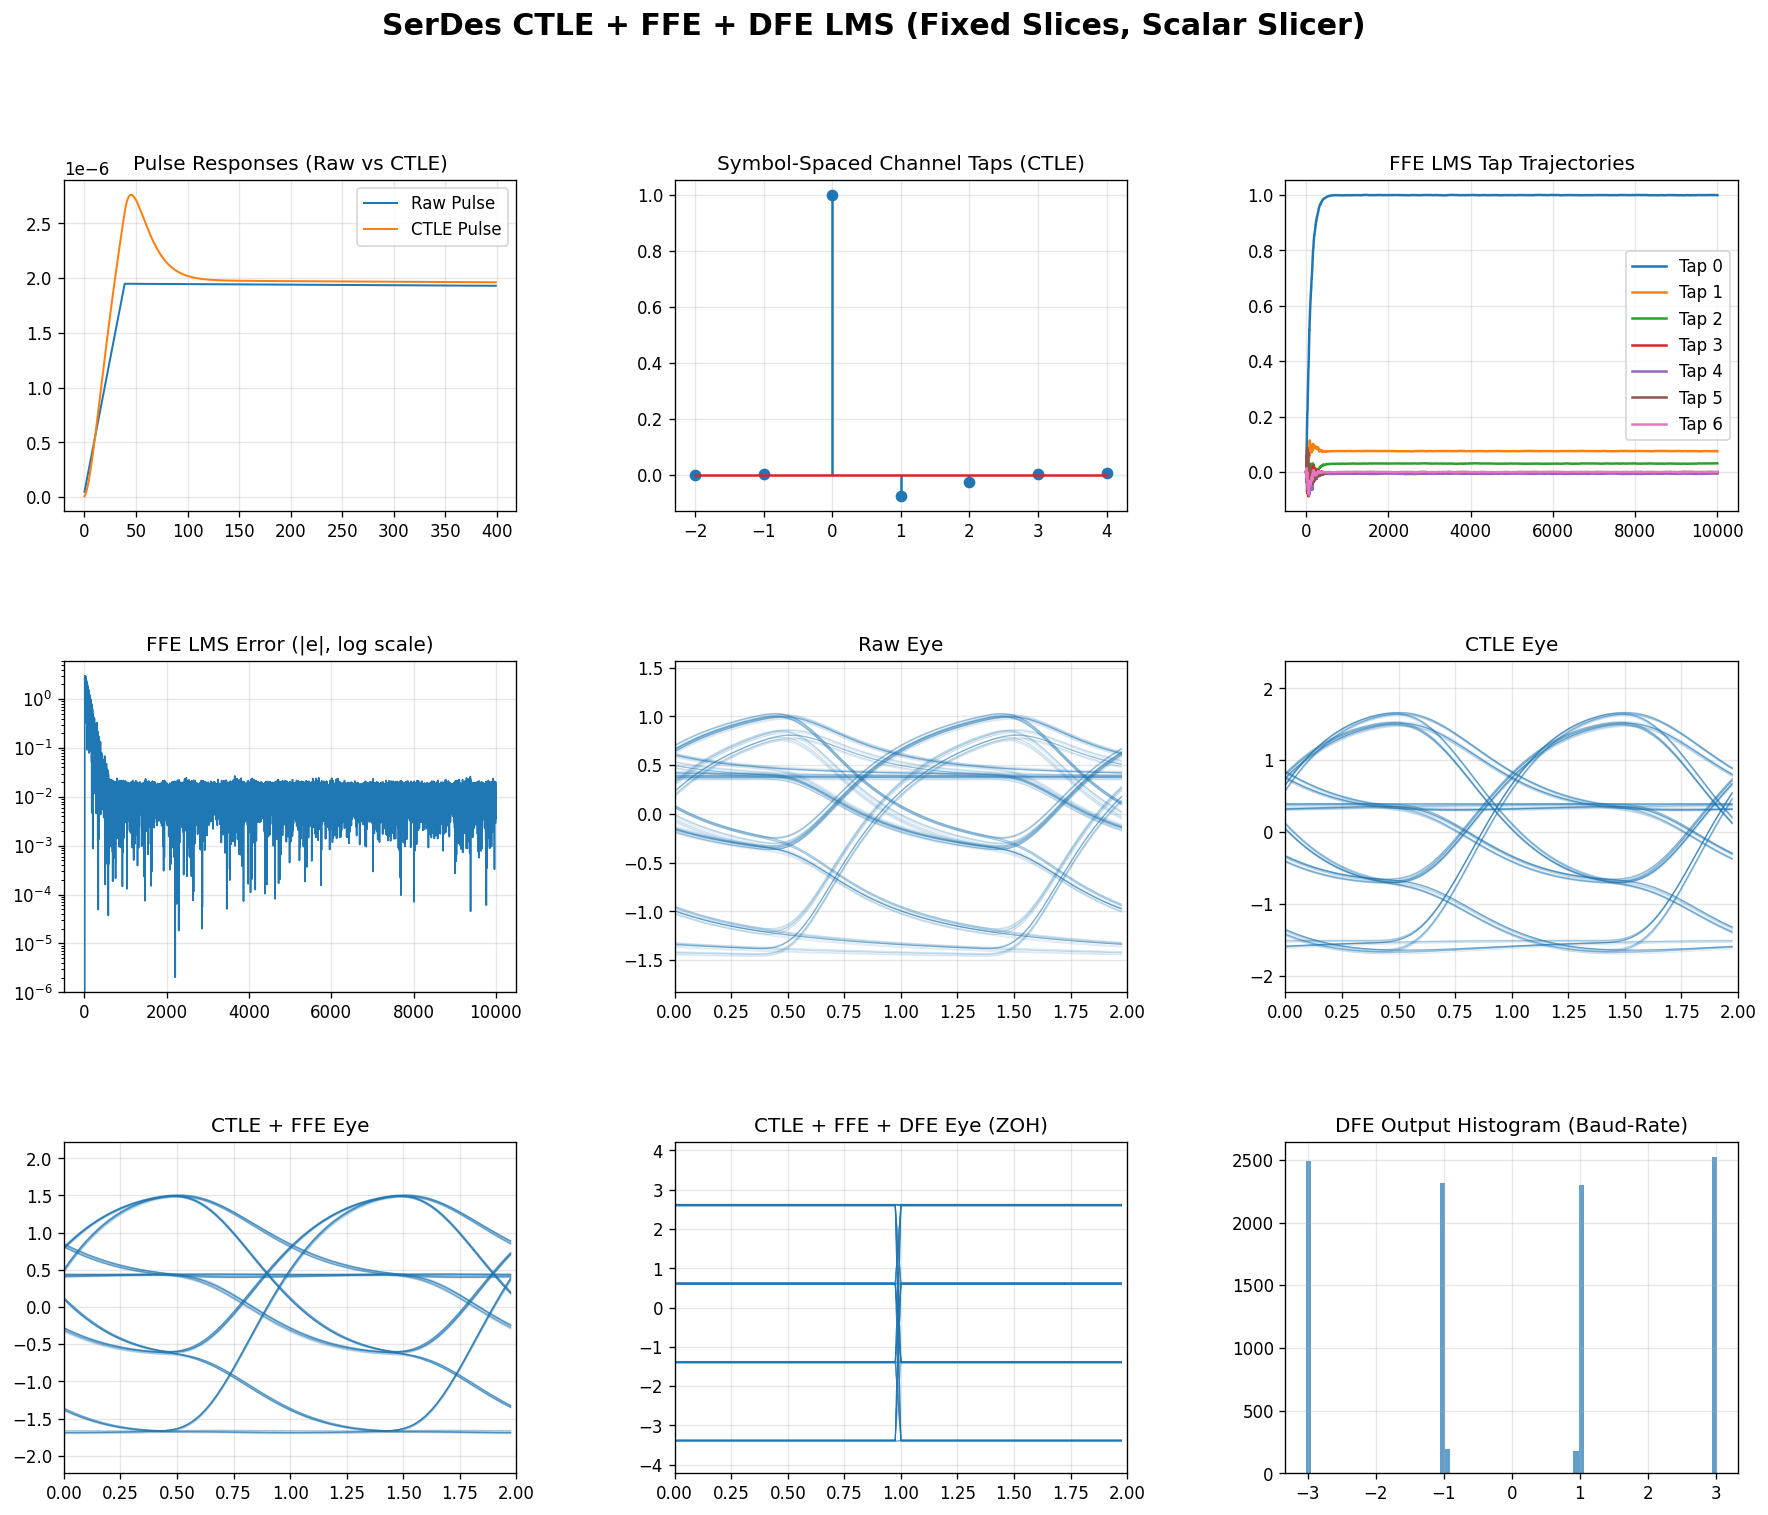

===BEGIN IMAGE===
iVBORw0KGgoAAAANSUhEUgAAA94AAALtCAYAAADe9LycAAAAOnRFWHRTb2Z0d2FyZQBNYXRwbG90bGliIHZlcnNpb24zLjEwLjgsIGh0dHBzOi8vbWF0cGxvdGxpYi5vcmcvwVt1zgAAAAlwSFlzAAAXEgAAFxIBZ5/SUgAAEapJREFUeJzt2bENgAAQAzFg/52fKa6IZA+Q/pT37u4BAAAAEl8zCwAAAAhvAAAAiHm8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAQHgDAADAJo83AAAAhIQ3AAAAhIQ3AAAAhIQ3AAAAhIQ3AA

<Figure size 640x480 with 0 Axes>

In [58]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
import scipy.signal as sig
import base64
from io import BytesIO

# ============================================================
# Configuration
# ============================================================
SPS = 40                      # samples per symbol (oversampling)
DATA_RATE = 100e9
NYQUIST_F = DATA_RATE / 2.0
VOLTAGE_LEVELS = np.array([-3, -1, 1, 3], dtype=float)

NUM_SYMBOLS = 10000
NUM_FFE_TAPS = 7
DFE_TAPS = 2
MU_FFE = 1e-3
MU_DFE = 1e-5  # or even 1e-5 to start
TRAIN_LEN = 10000


# ============================================================
# Load data
# ============================================================
f = np.load("./examples/example_channel/data/f.npy")          # Hz
h_pulse = np.load("./examples/example_channel/data/hpulse.npy")
t = np.load("./examples/example_channel/data/t.npy")
signal = np.load("./examples/example_channel/data/signal_cap.npy")

# ============================================================
# Helper: freq response -> impulse response
# ============================================================
def freq2impulse(Hf, f):
    df = f[1] - f[0]
    f_max = f[-1]
    Fs = 2 * f_max
    N = 2 * len(f)

    H_pos = Hf
    H_neg = np.conj(H_pos[-2:0:-1])
    H_full = np.concatenate(([H_pos[0]], H_pos[1:], H_neg))

    h = np.fft.ifft(H_full)
    h = np.real(h)
    t_imp = np.arange(len(h)) / Fs
    return h, t_imp

# ============================================================
# CTLE design (continuous-time)
# ============================================================
z = 5e10
p = 1.7e11
k = p**2 / z

w_ctle = 2 * np.pi * f
_, H_ctle = sp.signal.freqs(
    [k / p**2, k * z / p**2],
    [1 / p**2, 2 / p, 1],
    w_ctle
)

h_ctle, t_ctle = freq2impulse(H_ctle, f)
h_ctle = h_ctle[:200]

# ============================================================
# Apply CTLE to oversampled waveform
# ============================================================
signal_ctle = sig.convolve(signal, h_ctle, mode="full")

# ============================================================
# Channel pulse with CTLE and symbol-spaced taps
# ============================================================
h_pulse_ctle = sig.convolve(h_pulse, h_ctle, mode="full")

def extract_channel_taps(h_pulse_os, sps, n_precursors=2, n_postcursors=4):
    idx_main = int(np.argmax(np.abs(h_pulse_os)))
    taps = []
    for k in range(-n_precursors, n_postcursors + 1):
        idx = idx_main + k * sps
        if 0 <= idx < len(h_pulse_os):
            taps.append(h_pulse_os[idx])
        else:
            taps.append(0.0)
    return np.array(taps, dtype=float), idx_main

h_br, idx_main_pulse = extract_channel_taps(
    h_pulse_ctle[:t.size],
    SPS,
    n_precursors=2,
    n_postcursors=4
)

channel_main = int(np.argmax(np.abs(h_br)))
if h_br[channel_main] != 0:
    h_br = h_br / h_br[channel_main]

# ============================================================
# PAM4 data generation
# ============================================================
def pam4_symbols(num_symbols):
    idx = np.random.randint(0, 4, size=num_symbols)
    return VOLTAGE_LEVELS[idx], idx

data_symbols, data_idx = pam4_symbols(NUM_SYMBOLS)
signal_BR = data_symbols.copy()

# ============================================================
# Baud-rate channel output (with CTLE)
# ============================================================
signal_rx_br = sig.fftconvolve(h_br, signal_BR, mode="full")
signal_rx_br_cropped = signal_rx_br[channel_main:channel_main + len(signal_BR)]

# ============================================================
# FFE LMS training (baud-rate) – fixed slice
# ============================================================
def ffe_lms_train(rx, ref, num_taps, mu):
    N = len(rx)
    w = np.zeros(num_taps, dtype=float)
    y = np.zeros(N, dtype=float)
    e = np.zeros(N, dtype=float)
    w_hist = np.zeros((N, num_taps), dtype=float)

    for n in range(num_taps - 1, N):
        # CORRECT slice: last num_taps samples, reversed
        x = rx[n - num_taps + 1:n + 1][::-1]  # shape (num_taps,)
        y[n] = np.dot(w, x)
        e[n] = ref[n] - y[n]
        w += 2 * mu * e[n] * x
        w_hist[n, :] = w

    return w, y, e, w_hist

TRAIN_LEN = min(TRAIN_LEN, len(signal_rx_br_cropped), len(signal_BR))
rx_train = signal_rx_br_cropped[:TRAIN_LEN]
ref_train = signal_BR[:TRAIN_LEN]

w_ffe, ffe_out_train, e_ffe, w_hist = ffe_lms_train(
    rx=rx_train,
    ref=ref_train,
    num_taps=NUM_FFE_TAPS,
    mu=MU_FFE
)

print("FFE taps:", w_ffe)

def ffe_apply(rx, w):
    N = len(rx)
    num_taps = len(w)
    y = np.zeros(N, dtype=float)
    for n in range(num_taps - 1, N):
        x = rx[n - num_taps + 1:n + 1][::-1]
        y[n] = np.dot(w, x)
    return y

ffe_out_full = ffe_apply(signal_rx_br_cropped, w_ffe)

# ============================================================
# Scalar PAM4 slicer
# ============================================================
def pam4_slice_scalar(x, levels):
    x = float(x)
    diffs = np.abs(levels - x)
    idx = int(np.argmin(diffs))
    return float(levels[idx]), idx

# ============================================================
# DFE LMS training (baud-rate)
# ============================================================
def dfe_lms_train(rx_eq, ref, num_taps, mu, train_len):
    N = min(train_len, len(rx_eq), len(ref))
    w = np.zeros(num_taps, dtype=float)
    y = np.zeros(N, dtype=float)
    d = ref[:N].copy()
    e = np.zeros(N, dtype=float)

    eps = 1e-12

    for n in range(num_taps, N):
        fb = d[n - num_taps:n][::-1]
        y[n] = rx_eq[n] - np.dot(w, fb)
        e[n] = ref[n] - y[n]

        # power-normalized LMS step
        norm_fb2 = np.dot(fb, fb) + eps
        mu_eff = mu / norm_fb2
        w += 2 * mu_eff * e[n] * fb

    return w, y, d, e


w_dfe, y_dfe_train, d_dfe_train, e_dfe_train = dfe_lms_train(
    rx_eq=ffe_out_full,
    ref=signal_BR,
    num_taps=DFE_TAPS,
    mu=MU_DFE,
    train_len=TRAIN_LEN
)

print("DFE taps:", w_dfe)
print("DFE mean/std:", np.mean(y_dfe_train), np.std(y_dfe_train))

# ============================================================
# Decision-directed DFE on full FFE output
# ============================================================
def dfe_lms_apply(rx_eq, w, levels):
    N = len(rx_eq)
    num_taps = len(w)
    y = np.zeros(N, dtype=float)
    d = np.zeros(N, dtype=float)

    for n in range(N):
        if n >= num_taps:
            fb = d[n - num_taps:n][::-1]
            y[n] = rx_eq[n] - np.dot(w, fb)
        else:
            y[n] = rx_eq[n]
        d[n], _ = pam4_slice_scalar(y[n], levels)

    return y, d

y_dfe_full, d_dfe_full = dfe_lms_apply(ffe_out_full, w_dfe, VOLTAGE_LEVELS)

# ============================================================
# Oversampled FFE and DFE waveforms for eye diagrams
# ============================================================
def build_os_fir_from_br_taps(w_br, sps):
    num_taps = len(w_br)
    L = (num_taps - 1) * sps + 1
    h_os = np.zeros(L, dtype=float)
    for k in range(num_taps):
        h_os[k * sps] = w_br[k]
    return h_os

h_ffe_os = build_os_fir_from_br_taps(w_ffe, SPS)
sig_ffe_os = sig.convolve(signal_ctle, h_ffe_os, mode="same")

sig_dfe_os = np.repeat(y_dfe_full, SPS)

# ============================================================
# Eye diagram helper
# ============================================================
def plot_eye(ax, sig_in, sps, ui_symbols=2, n_traces=200, title=""):
    sig_in = np.asarray(sig_in, dtype=float)
    ui = sps
    span = ui_symbols * ui
    start = ui * 100
    end = min(len(sig_in) - span, start + n_traces * ui)

    if end <= start:
        ax.set_title(title + " (no data)")
        return

    t_eye = np.linspace(0, ui_symbols, span, endpoint=False)
    win = sig_in[start:end]
    sig_c = sig_in - np.mean(win)

    ax.cla()
    for i in range(start, end, ui):
        seg = sig_c[i:i + span]
        if len(seg) < span:
            break
        ax.plot(t_eye, seg, color="C0", alpha=0.15, linewidth=0.6)

    y_min, y_max = np.percentile(win, [1, 99])
    pad = 0.2 * (y_max - y_min + 1e-12)
    ax.set_ylim(y_min - pad, y_max + pad)
    ax.set_xlim(0, ui_symbols)
    ax.grid(True, alpha=0.3)
    ax.set_title(title)

# ============================================================
# Unified diagnostics figure
# ============================================================
fig = plt.figure(figsize=(18, 14), dpi=120)
gs = fig.add_gridspec(3, 3, wspace=0.35, hspace=0.45)

ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(h_pulse[:400], label="Raw Pulse", lw=1.2)
ax1.plot(h_pulse_ctle[:400], label="CTLE Pulse", lw=1.2)
ax1.set_title("Pulse Responses (Raw vs CTLE)")
ax1.grid(True, alpha=0.3)
ax1.legend()

ax2 = fig.add_subplot(gs[0, 1])
tap_idx = np.arange(len(h_br)) - np.argmax(np.abs(h_br))
ax2.stem(tap_idx, h_br)
ax2.set_title("Symbol-Spaced Channel Taps (CTLE)")
ax2.grid(True, alpha=0.3)

ax3 = fig.add_subplot(gs[0, 2])
for i in range(w_hist.shape[1]):
    ax3.plot(w_hist[:, i], label=f"Tap {i}")
ax3.set_title("FFE LMS Tap Trajectories")
ax3.grid(True, alpha=0.3)
ax3.legend()

ax4 = fig.add_subplot(gs[1, 0])
ax4.plot(np.abs(e_ffe), lw=1.0)
ax4.set_yscale("log")
ax4.set_title("FFE LMS Error (|e|, log scale)")
ax4.grid(True, alpha=0.3)

ax5 = fig.add_subplot(gs[1, 1])
plot_eye(ax5, signal, SPS, ui_symbols=2, title="Raw Eye")

ax6 = fig.add_subplot(gs[1, 2])
plot_eye(ax6, signal_ctle, SPS, ui_symbols=2, title="CTLE Eye")

ax7 = fig.add_subplot(gs[2, 0])
plot_eye(ax7, sig_ffe_os, SPS, ui_symbols=2, title="CTLE + FFE Eye")

ax8 = fig.add_subplot(gs[2, 1])
plot_eye(ax8, sig_dfe_os, SPS, ui_symbols=2, title="CTLE + FFE + DFE Eye (ZOH)")

ax9 = fig.add_subplot(gs[2, 2])
ax9.hist(y_dfe_full, bins=80, alpha=0.7)
ax9.set_title("DFE Output Histogram (Baud-Rate)")
ax9.grid(True, alpha=0.3)

plt.suptitle("SerDes CTLE + FFE + DFE LMS (Fixed Slices, Scalar Slicer)", fontsize=18, fontweight="bold")
plt.show()

buf = BytesIO()
plt.savefig(buf, format='png', dpi=150, bbox_inches='tight')
buf.seek(0)
img_b64 = base64.b64encode(buf.read()).decode('utf-8')
print("===BEGIN IMAGE===")
print(img_b64)
print("===END IMAGE===")


## Decoder Module (DCD)
To decode incoming 2-bit samples and undo Gray coding, you need a simple decoder module (DCD) that maps each Gray-coded symbol back to its original binary representation. Gray coding is often used in PAM4 systems to reduce bit errors caused by symbol transitions.

### How It Works
- The MSB (b1) is the same as the Gray code MSB (g1).
- The LSB (b0) is computed as g1 XOR g0.

This logic can be implemented in hardware (Verilog/VHDL) or software (Python/C) depending on your system.


In [59]:
def gray_to_binary(gray_bits):
    """
    Convert 2-bit Gray code to binary.
    Input: tuple of bits (g1, g0)
    Output: tuple of bits (b1, b0)
    """
    g1, g0 = gray_bits
    b1 = g1
    b0 = g1 ^ g0  # XOR operation
    return (b1, b0)

# Example usage
gray_samples = [(0,0), (0,1), (1,1), (1,0)]  # Gray-coded input
decoded_binary = [gray_to_binary(bits) for bits in gray_samples]

print("Decoded binary:", decoded_binary)

Decoded binary: [(0, 0), (0, 1), (1, 0), (1, 1)]


## Differential Precoding
Differential precoding is a technique used in digital communication systems to encode data such that the information is conveyed through changes (differences) between symbols rather than their absolute values. This is especially useful in systems where the receiver cannot reliably determine the signal's absolute phase or level—such as optical links, PAM4, or phase-modulated systems.

### Core Idea
Instead of transmitting the raw data directly, differential precoding transforms it so that:
- Bit transitions carry the information.
- The receiver only needs to detect relative changes, not absolute values.

This makes the system more robust to:
- Phase ambiguity
- DC offsets
- Common-mode noise

### Applications
- Optical PAM4 links: Avoids ambiguity in level detection.
- QPSK/DPSK systems: Where phase reference is unstable.
- Differential Manchester encoding: Used in legacy Ethernet and RFID.


### Example: Differential Encoding for 2-bit PAM4
Let’s say we use Gray-coded PAM4 symbols:
- 00 → –3
- 01 → –1
- 11 → +1
- 10 → +3
In differential precoding, we define the next symbol based on the previous symbol and current input bits. For example:

In [ ]:
def differential_precoder(input_bits):
    """
    Differential precoding for 2-bit PAM4 symbols.
    Input: list of 2-bit tuples (b1, b0)
    Output: list of PAM4 levels
    """
    gray_map = {
        (0, 0): -3,
        (0, 1): -1,
        (1, 1): +1,
        (1, 0): +3
    }
    levels = list(gray_map.values())
    output = []
    prev_index = 0  # Start with symbol index 0 (e.g., -3)
    for bits in input_bits:
        input_index = list(gray_map.keys()).index(bits)
        diff_index = (prev_index + input_index) % 4
        output.append(levels[diff_index])
        prev_index = diff_index
    return output

## Combining LMS (Least Mean Squares) with MLSE (Maximum Likelihood Sequence Estimation) 
Combining LMS (Least Mean Squares) with MLSE (Maximum Likelihood Sequence Estimation) in a PAM4 system creates a powerful hybrid equalization and decoding pipeline. LMS adaptively mitigates channel distortion (like ISI), while MLSE performs optimal sequence recovery—even in noisy, multi-level environments.

### Why Combine LMS and MLSE?
- LMS: Learns tap weights to suppress ISI and shape the signal.
- MLSE: Recovers the most likely transmitted symbol sequence using a trellis-based search (e.g., Viterbi algorithm).
- Together: LMS preconditions the signal for MLSE, reducing complexity and improving accuracy.

This is especially useful in PAM4 systems where:
- Symbol levels are close together.
- ISI and noise make hard decisions unreliable.
- Gray coding and differential encoding may be used

SER (simple scalar slicer, no EQ): 7.2900e-01
FFE taps: [ 0.01793944  0.00529516 -0.03288494  0.02233217  0.01277274  0.00592063
  0.01908256]
SER (FFE + scalar slicer): 7.4785e-01
SER (FFE + MLSE with true channel): 7.4900e-01
Avg SNR (slicer): -2.56 dB
Avg SNR (FFE):    -0.72 dB
Avg SNR (MLSE):   -0.79 dB
Histogram BER estimate (raw RX): 1.064e-01
Per-eye SER (raw RX): [0.21441132 0.20760041 0.21637175]
Estimated thresholds (raw RX): [np.float64(-1.9441793119780189), np.float64(-0.0015425896037787323), np.float64(1.940292667791093)]
Histogram BER estimate (FFE out): 4.104e-02
Per-eye SER (FFE out): [1.22437741e-15 2.46217677e-01 2.30325417e-15]
Estimated thresholds (FFE out): [np.float64(-1.546668895806308), np.float64(0.0005258657415413773), np.float64(1.5471947615478492)]


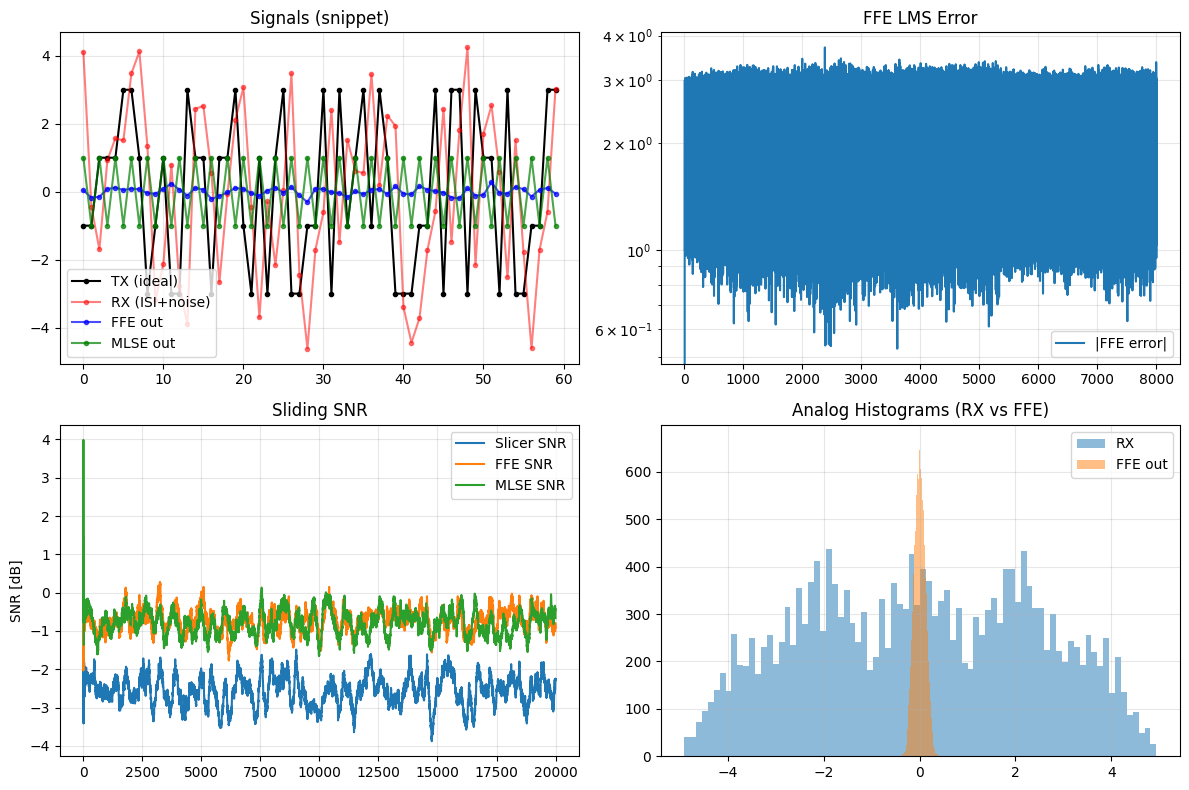

In [60]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------------------------------------------
# Configuration
# ----------------------------------------------------------------------
NUM_SYMBOLS    = 20000
TRAIN_LEN      = 8000
NOISE_STD      = 0.05
VOLTAGE_LEVELS = np.array([-3, -1, 1, 3], dtype=np.float64)

# Discrete-time PAM4 channel (baud-rate taps)
h_ch = np.array([0.1, 1.0, 0.35, -0.15], dtype=np.float64)  # memory L = 3

# ----------------------------------------------------------------------
# 1) Generate PAM4 symbol sequence (indices 0..3 and voltages)
# ----------------------------------------------------------------------
tx_idx = np.random.randint(0, 4, size=NUM_SYMBOLS).astype(np.uint8)
tx_br  = Signal.pam4_input_br(tx_idx, voltage_levels=VOLTAGE_LEVELS)  # float64

# ----------------------------------------------------------------------
# 2) Pass through ISI channel + AWGN
# ----------------------------------------------------------------------
rx_isi_full = np.convolve(tx_br, h_ch, mode="full")
rx_isi      = rx_isi_full[:NUM_SYMBOLS]

noise    = NOISE_STD * np.random.randn(NUM_SYMBOLS)
rx_noisy = rx_isi + noise

# ----------------------------------------------------------------------
# 3) Baseline: scalar PAM4 slicer (no EQ)
# ----------------------------------------------------------------------
# Use your scalar-aware pam4_decision
def pam4_slice_scalar(x, levels):
    l = (levels[0] + levels[1]) / 2.0
    m = (levels[1] + levels[2]) / 2.0
    h = (levels[2] + levels[3]) / 2.0
    return levels[Signal.pam4_decision(x, l, m, h)]

slicer_out = np.array([pam4_slice_scalar(x, VOLTAGE_LEVELS) for x in rx_noisy],
                      dtype=np.float64)

ser_slicer = np.mean(slicer_out != tx_br)
print(f"SER (simple scalar slicer, no EQ): {ser_slicer:.4e}")

# ----------------------------------------------------------------------
# 4) FFE LMS training using Signal.ffe_lms_train
# ----------------------------------------------------------------------
NUM_FFE_TAPS = 7
MU_FFE       = 5e-3

train_len = min(TRAIN_LEN, NUM_SYMBOLS)
rx_train  = rx_noisy[:train_len]
ref_train = tx_br[:train_len]

w_ffe, ffe_out_train, e_ffe, w_hist = Signal.ffe_lms_train(
    received   = rx_train,
    reference  = ref_train,
    num_taps   = NUM_FFE_TAPS,
    mu         = MU_FFE
)

print("FFE taps:", w_ffe)

# Apply FFE to full sequence
ffe_out_full = Signal.ffe_lms_apply(rx_noisy, w_ffe)

# FFE-only scalar slicer
ffe_sliced = np.array([pam4_slice_scalar(x, VOLTAGE_LEVELS) for x in ffe_out_full],
                      dtype=np.float64)
ser_ffe = np.mean(ffe_sliced != tx_br)
print(f"SER (FFE + scalar slicer): {ser_ffe:.4e}")

# ----------------------------------------------------------------------
# 5) MLSE (Viterbi) using TRUE channel h_ch
# ----------------------------------------------------------------------
mlse_out = Signal.mlse_viterbi_pam4(
    rx_signal     = ffe_out_full,   # MLSE after FFE front-end
    channel_ir    = h_ch,
    pam4_alphabet = VOLTAGE_LEVELS
)

ser_mlse = np.mean(mlse_out[:NUM_SYMBOLS] != tx_br)
print(f"SER (FFE + MLSE with true channel): {ser_mlse:.4e}")

# ----------------------------------------------------------------------
# 6) SNR and BER estimates
# ----------------------------------------------------------------------
snr_slicer = Signal.cse_sliding_snr(slicer_out, tx_br, window_size=200)
snr_ffe    = Signal.cse_sliding_snr(ffe_sliced, tx_br, window_size=200)
snr_mlse   = Signal.cse_sliding_snr(mlse_out[:NUM_SYMBOLS], tx_br, window_size=200)

print(f"Avg SNR (slicer): {np.mean(snr_slicer):.2f} dB")
print(f"Avg SNR (FFE):    {np.mean(snr_ffe):.2f} dB")
print(f"Avg SNR (MLSE):   {np.mean(snr_mlse):.2f} dB")

# Histogram-based BER estimate on analog signals (not on already-quantized MLSE)
ber_rx,  ser_eye_rx,  thr_rx  = Signal.pam4_histogram_ber(
    rx_signal   = rx_noisy,
    pam4_levels = VOLTAGE_LEVELS,
    bins        = 200
)
ber_ffe, ser_eye_ffe, thr_ffe = Signal.pam4_histogram_ber(
    rx_signal   = ffe_out_full,
    pam4_levels = VOLTAGE_LEVELS,
    bins        = 200
)

print(f"Histogram BER estimate (raw RX): {ber_rx:.3e}")
print("Per-eye SER (raw RX):", ser_eye_rx)
print("Estimated thresholds (raw RX):", thr_rx)

print(f"Histogram BER estimate (FFE out): {ber_ffe:.3e}")
print("Per-eye SER (FFE out):", ser_eye_ffe)
print("Estimated thresholds (FFE out):", thr_ffe)

# ----------------------------------------------------------------------
# 7) Visualization
# ----------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sl = slice(200, 260)
axes[0, 0].plot(tx_br[sl], 'k.-', label="TX (ideal)")
axes[0, 0].plot(rx_noisy[sl], 'r.-', alpha=0.5, label="RX (ISI+noise)")
axes[0, 0].plot(ffe_out_full[sl], 'b.-', alpha=0.7, label="FFE out")
axes[0, 0].plot(mlse_out[sl], 'g.-', alpha=0.7, label="MLSE out")
axes[0, 0].set_title("Signals (snippet)")
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()

axes[0, 1].semilogy(np.abs(e_ffe), label="|FFE error|")
axes[0, 1].set_title("FFE LMS Error")
axes[0, 1].grid(True, which="both", alpha=0.3)
axes[0, 1].legend()

axes[1, 0].plot(snr_slicer, label="Slicer SNR")
axes[1, 0].plot(snr_ffe,    label="FFE SNR")
axes[1, 0].plot(snr_mlse,   label="MLSE SNR")
axes[1, 0].set_title("Sliding SNR")
axes[1, 0].set_ylabel("SNR [dB]")
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()

axes[1, 1].hist(rx_noisy[:NUM_SYMBOLS],    bins=80, alpha=0.5, label="RX")
axes[1, 1].hist(ffe_out_full[:NUM_SYMBOLS], bins=80, alpha=0.5, label="FFE out")
axes[1, 1].set_title("Analog Histograms (RX vs FFE)")
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend()

plt.tight_layout()
plt.show()


## Digital Pre-Distortion (DPD)
DPD (Digital Pre-Distortion) is a signal processing technique used to linearize power amplifiers (PAs) in RF and wireless communication systems. It’s essential for maintaining signal fidelity, reducing spectral regrowth, and complying with emission standards—especially in systems using high-order modulation like QAM or OFDM.

### Why Is DPD Needed?
Power amplifiers are inherently nonlinear, especially near saturation. This causes:
- AM-AM distortion: Amplitude of output vs input is nonlinear.
- AM-PM distortion: Phase of output varies with input amplitude.
- Spectral regrowth: Out-of-band emissions increase, violating spectral masks.
DPD combats this by applying a pre-distortion function to the input signal so that the combined effect of DPD + PA becomes linear

### How DPD Works
- Model the PA: Use behavioral models like memory polynomials, Volterra series, or neural networks.
- Measure distortion: Compare PA output to ideal signal.
- Adapt pre-distorter: Update coefficients to minimize error.
- Apply inverse distortion: Pre-distort input so PA output is clean.

This is often done in a feedback loop using LMS, RLS, or gradient descent.

### Example: Memory Polynomial DPD
The DPD function might look like:
y[n] = \sum_{k=0}^{K} \sum_{m=0}^{M} a_{k,m} \cdot x[n-m] \cdot |x[n-m]|^k

Where:
- x[n]: input signal
- y[n]: pre-distorted output
- a_{k,m}: model coefficients
- K: nonlinearity order
- M: memory depth

### Applications
- 5G base stations
- Satellite uplinks
- SDR platforms
- Radar transmitters
- Wi-Fi and LTE modems

DPD coefficients: [17.77181887-7.31449792j 18.27294104-7.7503934j  18.30738012-7.86057073j
 17.84170717-7.93214521j 17.21864337-7.6671245j  16.29035122-7.51352699j
 15.22461824-7.04367176j]


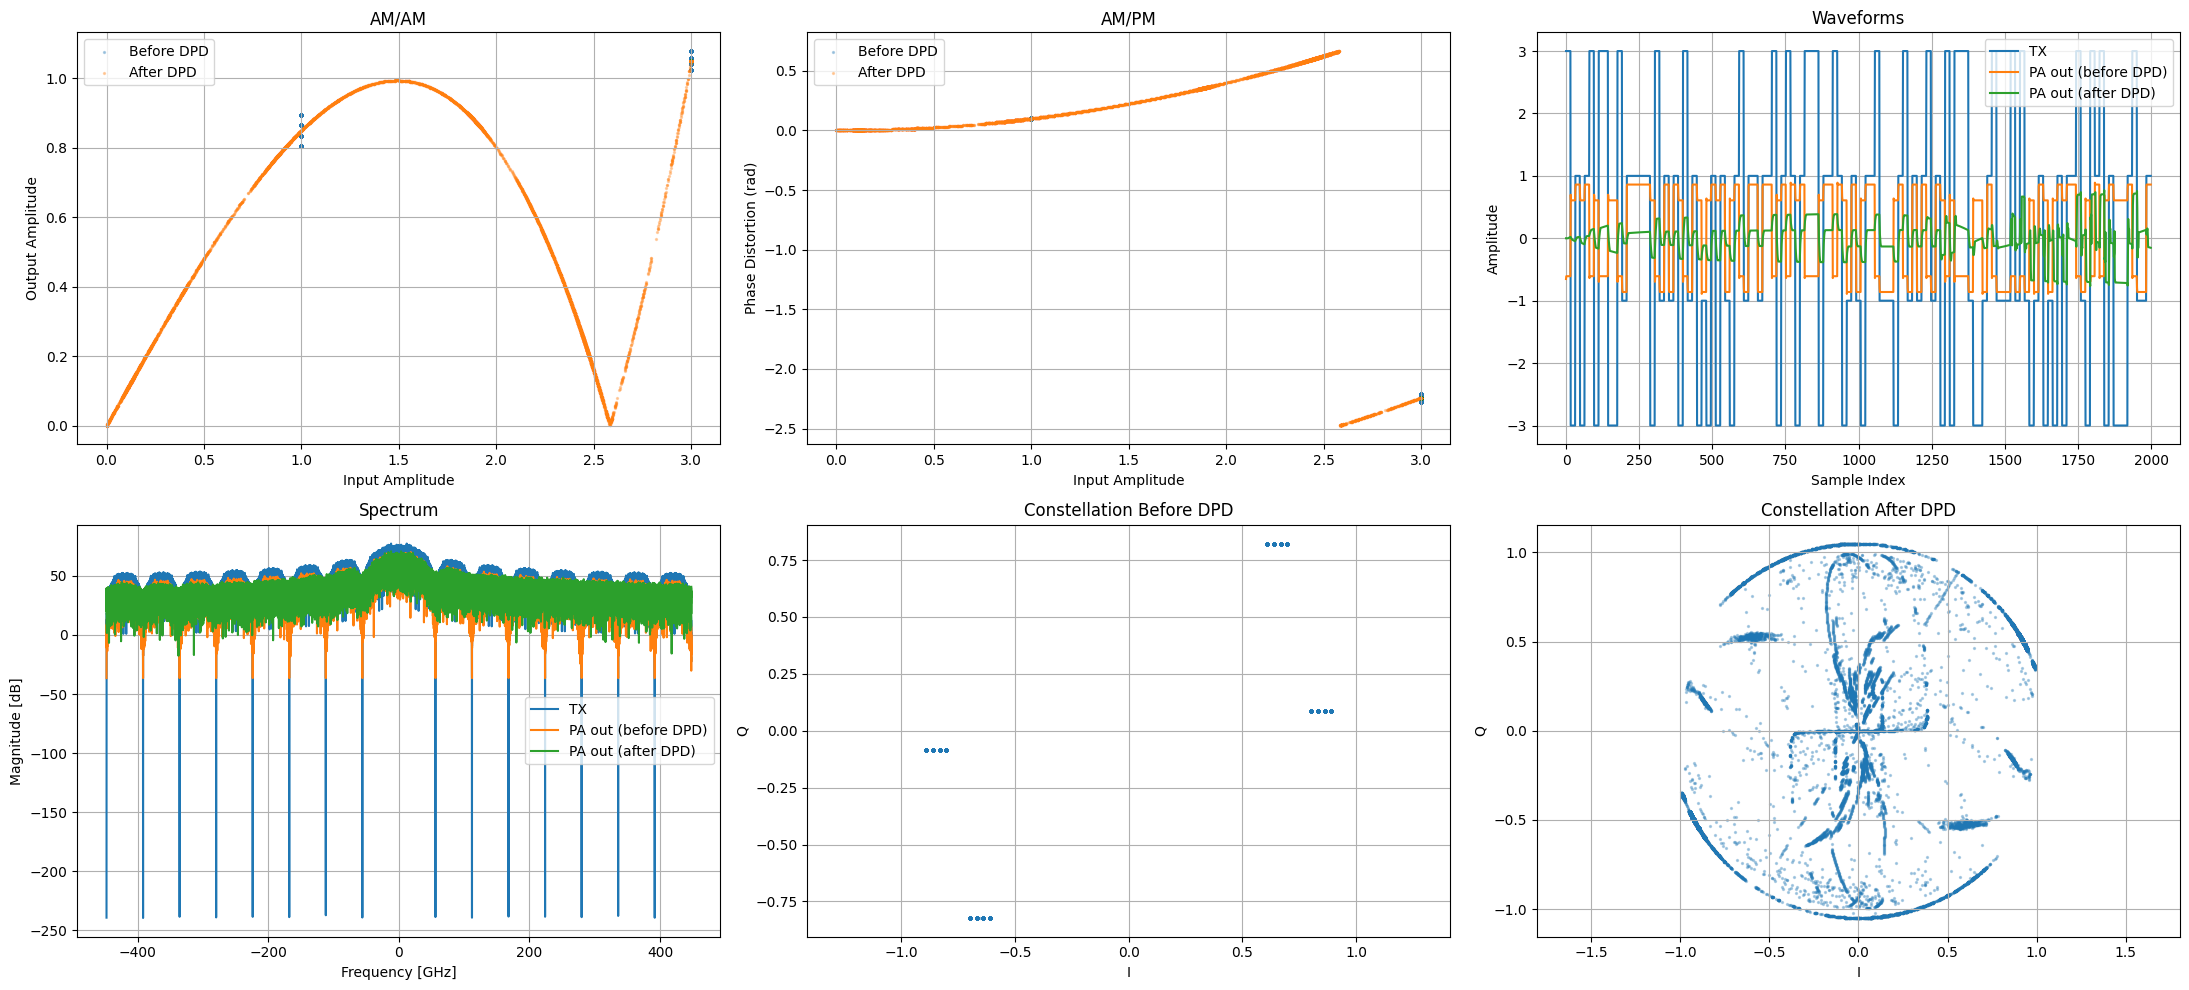

===BEGIN IMAGE===
iVBORw0KGgoAAAANSUhEUgAAA94AAALtCAYAAADe9LycAAAAOnRFWHRTb2Z0d2FyZQBNYXRwbG90bGliIHZlcnNpb24zLjEwLjgsIGh0dHBzOi8vbWF0cGxvdGxpYi5vcmcvwVt1zgAAAAlwSFlzAAAXEgAAFxIBZ5/SUgAAEapJREFUeJzt2bENgAAQAzFg/52fKa6IZA+Q/pT37u4BAAAAEl8zCwAAAAhvAAAAiHm8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAQHgDAADAJo83AAAAhIQ3AAAAhIQ3AAAAhIQ3AAAAhIQ3AA

<Figure size 640x480 with 0 Axes>

In [61]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. Generate PAM4 data and build a transmitter
# ============================================================
NUM_SYMBOLS = 6000
VOLTAGE_LEVELS = np.array([-3, -1, 1, 3], dtype=float)
SYMBOL_RATE = 56e9

data = np.random.randint(0, 4, size=NUM_SYMBOLS)

tx = Transmitter(
    data=data,
    voltage_levels=VOLTAGE_LEVELS,
    frequency=SYMBOL_RATE,
    debug=False
)

SPS = 16
tx.oversample(samples_per_symbol=SPS)
x_bb = tx.get_signal(as_complex=True).astype(complex)

# ============================================================
# 2. PA (nonlinear + memory)
# ============================================================
y_pa = pa_model(x_bb, alpha=0.15, beta=0.10, gamma=0.05, memory_coeff=0.3)

# ============================================================
# 3. Target = ideal linear output
# ============================================================
target = x_bb.copy()

# ============================================================
# 4. Train DPD
# ============================================================
MU = 0.001
NUM_TAPS = 7

coeffs, err_hist, x_dpd, y_pa_dpd = dpd_lms_adaptation(
    tx_signal=x_bb,
    pa_model_func=lambda x: pa_model(x, alpha=0.15, beta=0.10, gamma=0.05, memory_coeff=0.3),
    target_signal=target,
    mu=MU,
    num_taps=NUM_TAPS
)

print("DPD coefficients:", coeffs)

# ============================================================
# 5. Metrics + Visualization
# ============================================================

def am_am(x, y):
    return np.abs(x), np.abs(y)

def am_pm(x, y):
    return np.abs(x), np.unwrap(np.angle(y) - np.angle(x))

def spectrum(sig, fs):
    S = np.fft.fftshift(np.fft.fft(sig))
    f = np.fft.fftshift(np.fft.fftfreq(len(sig), 1/fs))
    return f, 20*np.log10(np.abs(S) + 1e-12)

def constellation(sig, title):
    plt.figure(figsize=(5,5))
    plt.scatter(np.real(sig), np.imag(sig), s=2, alpha=0.3)
    plt.title(title)
    plt.grid(True)
    plt.xlabel("I")
    plt.ylabel("Q")
    plt.axis("equal")
    plt.tight_layout()
    plt.show()

def evm(ref, rx):
    ref = ref[:len(rx)]
    err = rx - ref
    return np.sqrt(np.mean(np.abs(err)**2)) / np.sqrt(np.mean(np.abs(ref)**2))

def acpr(sig, fs, main_bw=0.2, offset=0.3):
    f, S = spectrum(sig, fs)
    S_lin = 10**(S/10)

    main = np.logical_and(np.abs(f) < main_bw/2, True)
    adj  = np.logical_and(np.abs(f) > offset, np.abs(f) < offset + main_bw/2)

    P_main = np.sum(S_lin[main])
    P_adj  = np.sum(S_lin[adj])

    return 10*np.log10(P_adj / P_main + 1e-15)

def npr(sig):
    return 10*np.log10(np.var(sig) / np.var(sig - np.mean(sig)))

# ============================================================
# 6. Unified Multi‑Graph
# ============================================================

def plot_dpd_multigraph_full(x_in, y_pa, x_dpd, y_pa_dpd, fs, n_wave=2000):
    """
    Unified 2×3 multi-graph for PA + DPD analysis:
    - AM/AM
    - AM/PM
    - Waveforms
    - Spectrum
    - Constellation (before)
    - Constellation (after)
    """

    # ---------- Helpers ----------
    def am_am(x, y):
        return np.abs(x), np.abs(y)

    def am_pm(x, y):
        return np.abs(x), np.unwrap(np.angle(y) - np.angle(x))

    def spectrum(sig):
        S = np.fft.fftshift(np.fft.fft(sig))
        f = np.fft.fftshift(np.fft.fftfreq(len(sig), 1/fs))
        return f, 20*np.log10(np.abs(S) + 1e-12)

    # ---------- Compute data ----------
    amp_in, amp_out = am_am(x_in, y_pa)
    amp_in_dpd, amp_out_dpd = am_am(x_dpd, y_pa_dpd)

    pm_in, pm_out = am_pm(x_in, y_pa)
    pm_in_dpd, pm_out_dpd = am_pm(x_dpd, y_pa_dpd)

    f1, Sx  = spectrum(x_in)
    f2, Sy  = spectrum(y_pa)
    f3, Sd  = spectrum(y_pa_dpd)

    # ---------- Multi‑graph ----------
    fig, axes = plt.subplots(2, 3, figsize=(22, 10))

    # === (1) AM/AM ===
    ax = axes[0, 0]
    ax.scatter(amp_in, amp_out, s=2, alpha=0.3, label="Before DPD")
    ax.scatter(amp_in_dpd, amp_out_dpd, s=2, alpha=0.3, label="After DPD")
    ax.set_title("AM/AM")
    ax.set_xlabel("Input Amplitude")
    ax.set_ylabel("Output Amplitude")
    ax.grid(True)
    ax.legend()

    # === (2) AM/PM ===
    ax = axes[0, 1]
    ax.scatter(pm_in, pm_out, s=2, alpha=0.3, label="Before DPD")
    ax.scatter(pm_in_dpd, pm_out_dpd, s=2, alpha=0.3, label="After DPD")
    ax.set_title("AM/PM")
    ax.set_xlabel("Input Amplitude")
    ax.set_ylabel("Phase Distortion (rad)")
    ax.grid(True)
    ax.legend()

    # === (3) Waveforms ===
    ax = axes[0, 2]
    ax.plot(np.real(x_in[:n_wave]), label="TX")
    ax.plot(np.real(y_pa[:n_wave]), label="PA out (before DPD)")
    ax.plot(np.real(y_pa_dpd[:n_wave]), label="PA out (after DPD)")
    ax.set_title("Waveforms")
    ax.set_xlabel("Sample Index")
    ax.set_ylabel("Amplitude")
    ax.grid(True)
    ax.legend()

    # === (4) Spectrum ===
    ax = axes[1, 0]
    ax.plot(f1/1e9, Sx, label="TX")
    ax.plot(f2/1e9, Sy, label="PA out (before DPD)")
    ax.plot(f3/1e9, Sd, label="PA out (after DPD)")
    ax.set_title("Spectrum")
    ax.set_xlabel("Frequency [GHz]")
    ax.set_ylabel("Magnitude [dB]")
    ax.grid(True)
    ax.legend()

    # === (5) Constellation Before DPD ===
    ax = axes[1, 1]
    ax.scatter(np.real(y_pa), np.imag(y_pa), s=2, alpha=0.3)
    ax.set_title("Constellation Before DPD")
    ax.set_xlabel("I")
    ax.set_ylabel("Q")
    ax.grid(True)
    ax.axis("equal")

    # === (6) Constellation After DPD ===
    ax = axes[1, 2]
    ax.scatter(np.real(y_pa_dpd), np.imag(y_pa_dpd), s=2, alpha=0.3)
    ax.set_title("Constellation After DPD")
    ax.set_xlabel("I")
    ax.set_ylabel("Q")
    ax.grid(True)
    ax.axis("equal")

    plt.tight_layout()
    plt.show()


# ============================================================
# 7. Run all visualizations
# ============================================================

plot_dpd_multigraph_full(
    x_in=x_bb,
    y_pa=y_pa,
    x_dpd=x_dpd,
    y_pa_dpd=y_pa_dpd,
    fs=SPS * SYMBOL_RATE
)

import base64
from io import BytesIO
buf = BytesIO()
plt.savefig(buf, format='png', dpi=150, bbox_inches='tight')
buf.seek(0)
img_b64 = base64.b64encode(buf.read()).decode('utf-8')
print("===BEGIN IMAGE===")
print(img_b64)
print("===END IMAGE===")

print("EVM before DPD:", evm(target, y_pa))
print("EVM after  DPD:", evm(target, y_pa_dpd))

print("ACPR before DPD:", acpr(y_pa, SPS*SYMBOL_RATE))
print("ACPR after  DPD:", acpr(y_pa_dpd, SPS*SYMBOL_RATE))

print("NPR before DPD:", npr(y_pa))
print("NPR after  DPD:", npr(y_pa_dpd))


DPD (inverse) coefficients: [1.00311914e+00+0.00605916j 2.22520738e-03+0.00578417j
 1.78006373e-03+0.00555108j 1.44409524e-03+0.0053179j
 1.17859027e-03+0.0050689j  9.65079139e-04+0.00479404j
 7.96385097e-04+0.00448014j]
EVM before DPD: 0.033
EVM after  DPD: 0.056
ACPR before DPD: -21.59 dB
ACPR after  DPD: -21.66 dB
NPR before DPD: 0.00 dB
NPR after  DPD: 0.00 dB


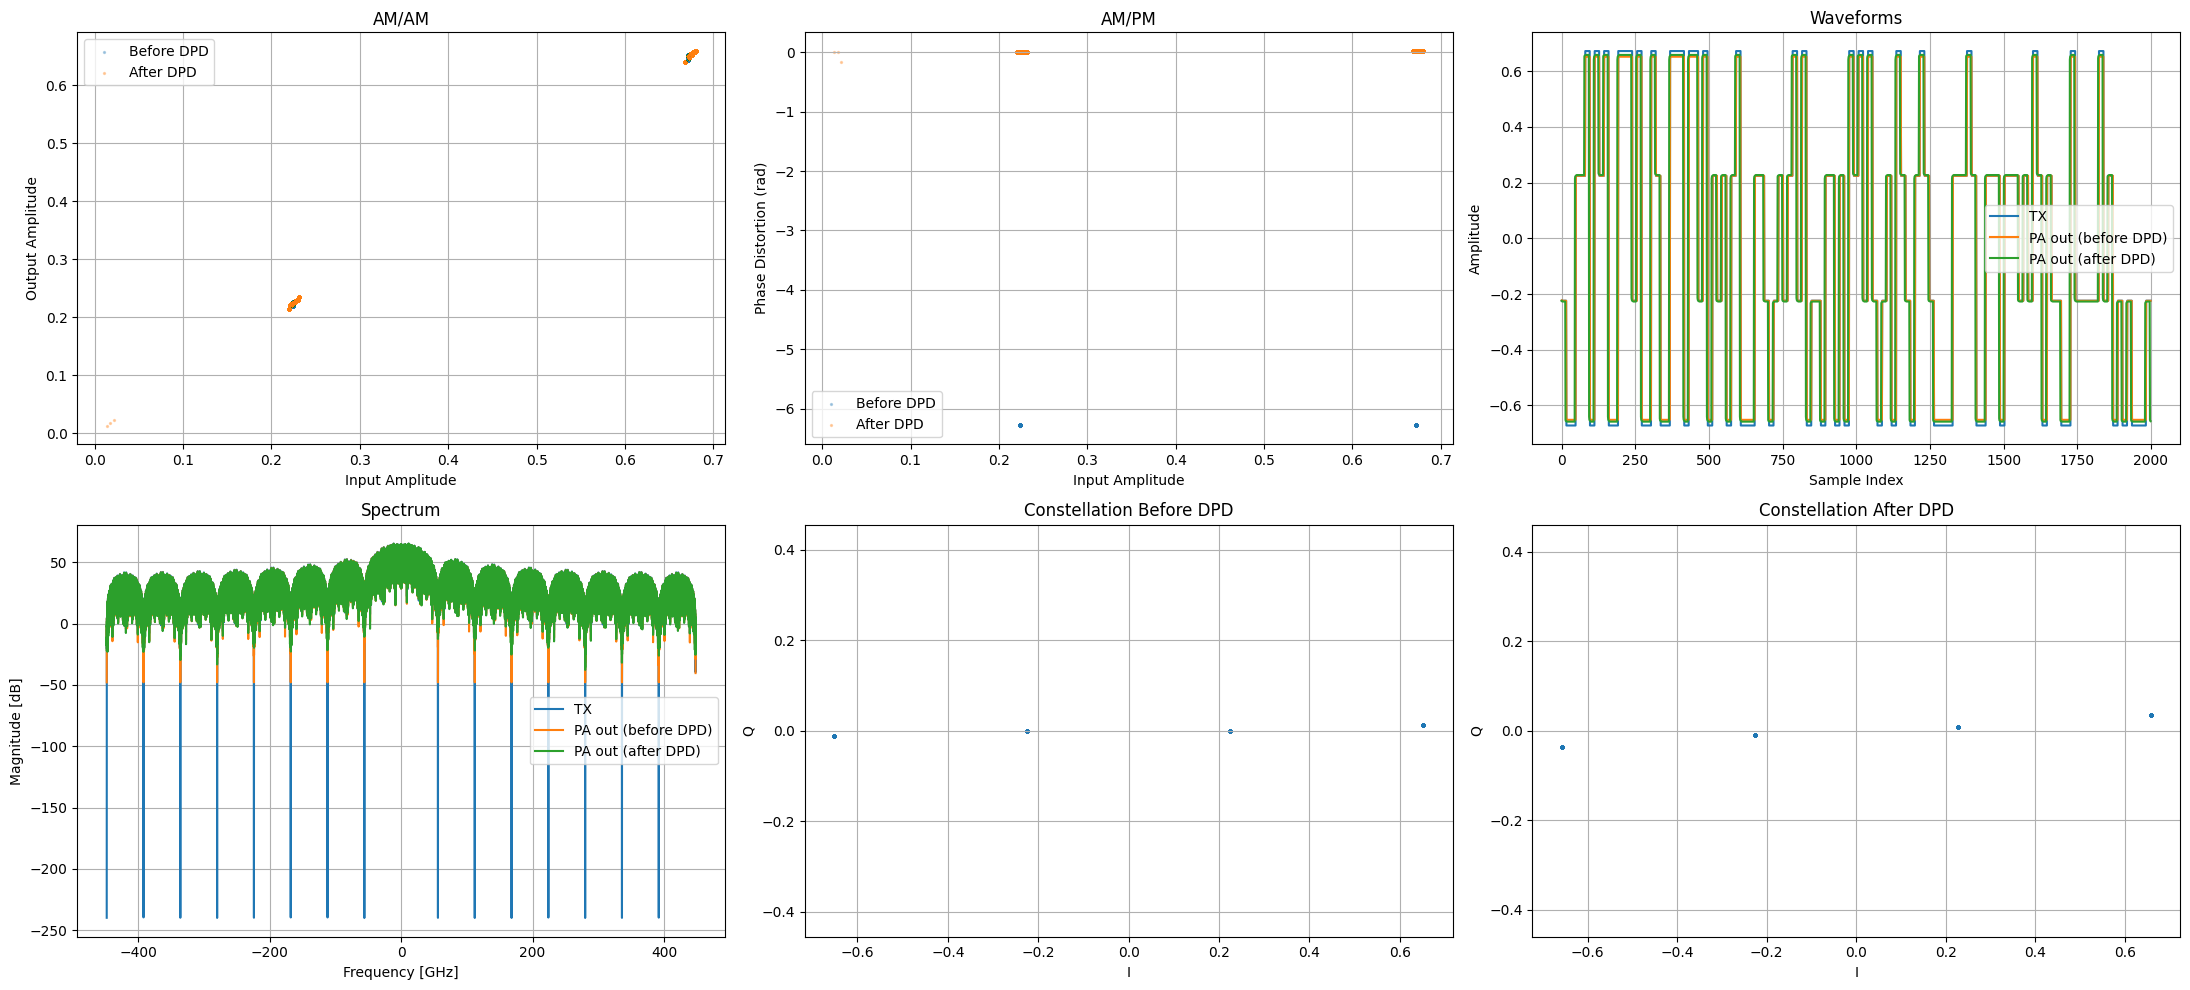

===BEGIN IMAGE===
iVBORw0KGgoAAAANSUhEUgAAA94AAALtCAYAAADe9LycAAAAOnRFWHRTb2Z0d2FyZQBNYXRwbG90bGliIHZlcnNpb24zLjEwLjgsIGh0dHBzOi8vbWF0cGxvdGxpYi5vcmcvwVt1zgAAAAlwSFlzAAAXEgAAFxIBZ5/SUgAAEapJREFUeJzt2bENgAAQAzFg/52fKa6IZA+Q/pT37u4BAAAAEl8zCwAAAAhvAAAAiHm8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAQHgDAADAJo83AAAAhIQ3AAAAhIQ3AAAAhIQ3AAAAhIQ3AA

<Figure size 640x480 with 0 Axes>

In [62]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 0. PA model (mild but visible nonlinearity, vector-safe)
# ============================================================
def pa_model(x, alpha=0.08, beta=0.04, gamma=0.03, memory_coeff=0.2, max_abs=4.0):
    x = np.asarray(x, dtype=np.complex128)

    xr = np.clip(x.real, -max_abs, max_abs)
    xi = np.clip(x.imag, -max_abs, max_abs)
    x_clipped = xr + 1j * xi

    abs2 = np.abs(x_clipped)**2
    abs2 = np.minimum(abs2, max_abs**2)

    gain  = 1.0 - alpha * abs2
    phase = beta * abs2

    y_nonlin = gain * x_clipped * np.exp(1j * phase)

    if x_clipped.ndim == 0:
        return y_nonlin

    y = np.empty_like(y_nonlin, dtype=np.complex128)
    y[0] = y_nonlin[0]
    if x_clipped.size > 1:
        y[1:] = y_nonlin[1:] + gamma * memory_coeff * x_clipped[:-1]
    return y

# ============================================================
# 1. Generate PAM4 TX waveform with Transmitter
#    (Transmitter class is assumed already defined/imported)
# ============================================================
NUM_SYMBOLS    = 8000
SYMBOL_RATE    = 56e9
SPS            = 16
VOLTAGE_LEVELS = np.array([-3, -1, 1, 3], dtype=float)

data = np.random.randint(0, 4, size=NUM_SYMBOLS)

tx = Transmitter(
    data=data,
    voltage_levels=VOLTAGE_LEVELS,
    frequency=SYMBOL_RATE,
    debug=False
)

tx.oversample(samples_per_symbol=SPS)
x_bb = tx.get_signal(as_complex=True).astype(np.complex128)

# Normalize baseband RMS to ~0.5
rms_x = np.sqrt(np.mean(np.abs(x_bb)**2))
if rms_x > 0:
    x_bb = x_bb * (0.5 / rms_x)

# ============================================================
# 2. PA output (before DPD)
# ============================================================
y_pa = pa_model(x_bb)
fs   = SYMBOL_RATE * SPS

# ============================================================
# 3. Indirect-learning DPD LMS
#    Train inverse: input = PA output, target = original TX
# ============================================================
def dpd_indirect_lms(pa_out, tx_ref, mu=2e-6, num_taps=7,
                     clip_dpd=3.0, max_coeff_norm=40.0):
    y  = np.asarray(pa_out, dtype=np.complex128)
    x  = np.asarray(tx_ref, dtype=np.complex128)
    N  = len(y)

    coeffs        = np.zeros(num_taps, dtype=np.complex128)
    coeffs[0]     = 1.0 + 0j  # start as pass-through
    error_history = np.zeros(N, dtype=np.float64)
    x_hat         = np.zeros(N, dtype=np.complex128)

    eps = 1e-10

    for n in range(num_taps, N):
        u_vec = y[n - num_taps + 1:n + 1][::-1]  # PA output history
        x_hat[n] = np.dot(coeffs, u_vec)

        if clip_dpd is not None:
            mag = np.abs(x_hat[n])
            if mag > clip_dpd:
                x_hat[n] *= clip_dpd / (mag + 1e-12)

        e = x[n] - x_hat[n]
        error_history[n] = np.abs(e)

        norm = np.mean(np.abs(u_vec)**2) + eps
        coeffs += mu * np.conj(e) * u_vec / norm

        c_norm = np.linalg.norm(coeffs)
        if c_norm > max_coeff_norm:
            coeffs *= max_coeff_norm / (c_norm + 1e-12)

    return coeffs, error_history

MU       = 2e-6
NUM_TAPS = 7

coeffs_inv, err_hist = dpd_indirect_lms(
    pa_out=y_pa,
    tx_ref=x_bb,
    mu=MU,
    num_taps=NUM_TAPS
)

print("DPD (inverse) coefficients:", coeffs_inv)

# ============================================================
# 4. Use learned inverse as pre-distorter
# ============================================================
def apply_fir(sig, coeffs):
    sig = np.asarray(sig, dtype=np.complex128)
    return np.convolve(sig, coeffs, mode="same")

x_dpd = apply_fir(x_bb, coeffs_inv)
y_pa_dpd = pa_model(x_dpd)

# ============================================================
# 5. Metrics: EVM, spectrum, ACPR, NPR
# ============================================================
def spectrum(sig, fs):
    S = np.fft.fftshift(np.fft.fft(sig))
    f = np.fft.fftshift(np.fft.fftfreq(len(sig), 1/fs))
    return f, 20*np.log10(np.abs(S) + 1e-12)

def evm_rms(ref, sig):
    ref = np.asarray(ref, dtype=np.complex128)
    sig = np.asarray(sig, dtype=np.complex128)
    L = min(len(ref), len(sig))
    ref = ref[:L]
    sig = sig[:L]
    err = sig - ref
    num = np.sqrt(np.mean(np.abs(err)**2))
    den = np.sqrt(np.mean(np.abs(ref)**2)) + 1e-15
    return float(num / den)

def acpr_db(sig, fs, main_bw_frac=0.4, adj_offset_frac=0.6, adj_bw_frac=0.4):
    f, S_db = spectrum(sig, fs)
    S_lin = 10**(S_db/20)
    f_norm = f / (fs/2)

    def band_power(mask):
        if not np.any(mask):
            return 1e-30
        return np.mean(S_lin[mask]**2)

    main_mask = np.abs(f_norm) <= main_bw_frac/2
    adj_mask  = (np.abs(f_norm) >= adj_offset_frac) & (np.abs(f_norm) <= adj_offset_frac + adj_bw_frac/2)

    P_main = band_power(main_mask)
    P_adj  = band_power(adj_mask)

    return 10*np.log10(P_adj / (P_main + 1e-30) + 1e-30)

def npr_db(sig):
    sig = np.asarray(sig, dtype=np.complex128)
    # Simple placeholder: ratio of total variance to AC variance
    return 10*np.log10(np.var(sig) / (np.var(sig - np.mean(sig)) + 1e-30))

# Symbol-rate downsampling (center sample per symbol)
center_idx = SPS//2
sym_idx = np.arange(center_idx, len(x_bb), SPS)
x_sym        = x_bb[sym_idx]
y_pa_sym     = y_pa[sym_idx]
y_pa_dpd_sym = y_pa_dpd[sym_idx]

evm_before = evm_rms(x_sym, y_pa_sym)
evm_after  = evm_rms(x_sym, y_pa_dpd_sym)

acpr_before = acpr_db(y_pa, fs)
acpr_after  = acpr_db(y_pa_dpd, fs)

npr_before = npr_db(y_pa)
npr_after  = npr_db(y_pa_dpd)

print(f"EVM before DPD: {evm_before:.3f}")
print(f"EVM after  DPD: {evm_after:.3f}")
print(f"ACPR before DPD: {acpr_before:.2f} dB")
print(f"ACPR after  DPD: {acpr_after:.2f} dB")
print(f"NPR before DPD: {npr_before:.2f} dB")
print(f"NPR after  DPD: {npr_after:.2f} dB")

# ============================================================
# 6. Unified 2×3 multi-graph (AM/AM, AM/PM, waveforms, spectrum, constellations)
# ============================================================
def plot_dpd_multigraph_full(x_in, y_pa, x_dpd, y_pa_dpd, fs, n_wave=2000):
    def am_am(x, y):
        return np.abs(x), np.abs(y)

    def am_pm(x, y):
        return np.abs(x), np.unwrap(np.angle(y) - np.angle(x))

    def spectrum_local(sig):
        S = np.fft.fftshift(np.fft.fft(sig))
        f = np.fft.fftshift(np.fft.fftfreq(len(sig), 1/fs))
        return f, 20*np.log10(np.abs(S) + 1e-12)

    amp_in, amp_out = am_am(x_in, y_pa)
    amp_in_dpd, amp_out_dpd = am_am(x_dpd, y_pa_dpd)

    pm_in, pm_out = am_pm(x_in, y_pa)
    pm_in_dpd, pm_out_dpd = am_pm(x_dpd, y_pa_dpd)

    f1, Sx  = spectrum_local(x_in)
    f2, Sy  = spectrum_local(y_pa)
    f3, Sd  = spectrum_local(y_pa_dpd)

    fig, axes = plt.subplots(2, 3, figsize=(22, 10))

    # AM/AM
    ax = axes[0, 0]
    ax.scatter(amp_in, amp_out, s=2, alpha=0.3, label="Before DPD")
    ax.scatter(amp_in_dpd, amp_out_dpd, s=2, alpha=0.3, label="After DPD")
    ax.set_title("AM/AM")
    ax.set_xlabel("Input Amplitude")
    ax.set_ylabel("Output Amplitude")
    ax.grid(True)
    ax.legend()

    # AM/PM
    ax = axes[0, 1]
    ax.scatter(pm_in, pm_out, s=2, alpha=0.3, label="Before DPD")
    ax.scatter(pm_in_dpd, pm_out_dpd, s=2, alpha=0.3, label="After DPD")
    ax.set_title("AM/PM")
    ax.set_xlabel("Input Amplitude")
    ax.set_ylabel("Phase Distortion (rad)")
    ax.grid(True)
    ax.legend()

    # Waveforms
    ax = axes[0, 2]
    ax.plot(np.real(x_in[:n_wave]), label="TX")
    ax.plot(np.real(y_pa[:n_wave]), label="PA out (before DPD)")
    ax.plot(np.real(y_pa_dpd[:n_wave]), label="PA out (after DPD)")
    ax.set_title("Waveforms")
    ax.set_xlabel("Sample Index")
    ax.set_ylabel("Amplitude")
    ax.grid(True)
    ax.legend()

    # Spectrum
    ax = axes[1, 0]
    ax.plot(f1/1e9, Sx, label="TX")
    ax.plot(f2/1e9, Sy, label="PA out (before DPD)")
    ax.plot(f3/1e9, Sd, label="PA out (after DPD)")
    ax.set_title("Spectrum")
    ax.set_xlabel("Frequency [GHz]")
    ax.set_ylabel("Magnitude [dB]")
    ax.grid(True)
    ax.legend()

    # Constellation Before
    ax = axes[1, 1]
    ax.scatter(np.real(y_pa_sym), np.imag(y_pa_sym), s=4, alpha=0.3)
    ax.set_title("Constellation Before DPD")
    ax.set_xlabel("I")
    ax.set_ylabel("Q")
    ax.grid(True)
    ax.axis("equal")

    # Constellation After
    ax = axes[1, 2]
    ax.scatter(np.real(y_pa_dpd_sym), np.imag(y_pa_dpd_sym), s=4, alpha=0.3)
    ax.set_title("Constellation After DPD")
    ax.set_xlabel("I")
    ax.set_ylabel("Q")
    ax.grid(True)
    ax.axis("equal")

    plt.tight_layout()
    plt.show()

plot_dpd_multigraph_full(
    x_in=x_bb,
    y_pa=y_pa,
    x_dpd=x_dpd,
    y_pa_dpd=y_pa_dpd,
    fs=fs
)


import base64
from io import BytesIO
buf = BytesIO()
plt.savefig(buf, format='png', dpi=150, bbox_inches='tight')
buf.seek(0)
img_b64 = base64.b64encode(buf.read()).decode('utf-8')
print("===BEGIN IMAGE===")
print(img_b64)
print("===END IMAGE===")


## Reed Solomon
A Reed Solomon encoder/decoder

In [63]:
import numpy as np 

# -*- coding: utf-8 -*-

# Copyright (c) 2012-2015 Tomer Filiba <tomerfiliba@gmail.com>
# Copyright (c) 2015 rotorgit
# Copyright (c) 2015-2020 Stephen Larroque <LRQ3000@gmail.com>

'''
Reed Solomon
============

A pure-python `universal errors-and-erasures Reed-Solomon Codec <http://en.wikipedia.org/wiki/Reed%E2%80%93Solomon_error_correction>`_
, based on the wonderful tutorial at
`wikiversity <http://en.wikiversity.org/wiki/Reed%E2%80%93Solomon_codes_for_coders>`_,
written by "Bobmath" and "LRQ3000".

The code of wikiversity is here consolidated into a nice API with exceptions handling.
The algorithm can correct up to 2*e+v <= nsym, where e is the number of errors,
v the number of erasures and nsym = n-k = the number of ECC (error correction code) symbols.
This means that you can either correct exactly floor(nsym/2) errors, or nsym erasures
(errors where you know the position), and a combination of both errors and erasures.
The code should work on pretty much any reasonable version of python (2.4-3.5),
but I'm only testing on 2.7 - 3.4.

.. note::
   The codec is universal, meaning that it can decode any message encoded by another RS encoder
   as long as you provide the correct parameters.
   Note however that if you use higher fields (ie, bigger c_exp), the algorithms will be slower, first because
   we cannot then use the optimized bytearray() structure but only array.array('i', ...), and also because
   Reed-Solomon's complexity is quadratic (both in encoding and decoding), so this means that the longer
   your messages, the longer it will take to encode/decode (quadratically!).

   The algorithm itself can handle messages up to (2^c_exp)-1 symbols, including the ECC symbols,
   and each symbol can have a value of up to (2^c_exp)-1 (indeed, both the message length and the maximum
   value for one character is constrained by the same mathematical reason). By default, we use the field GF(2^8),
   which means that you are limited to values between 0 and 255 (perfect to represent a single hexadecimal
   symbol on computers, so you can encode any binary stream) and limited to messages+ecc of maximum
   length 255. However, you can "chunk" longer messages to fit them into the message length limit.
   The ``RSCodec`` class will automatically apply chunking, by splitting longer messages into chunks and
   encode/decode them separately; it shouldn't make a difference from an API perspective (ie, from your POV).

::

    # Initialization
    >>> from reedsolo import RSCodec
    >>> rsc = RSCodec(10)  # 10 ecc symbols

    # Encoding
    >>> rsc.encode([1,2,3,4])
    b'\x01\x02\x03\x04,\x9d\x1c+=\xf8h\xfa\x98M'
    >>> rsc.encode(bytearray([1,2,3,4]))
    bytearray(b'\x01\x02\x03\x04,\x9d\x1c+=\xf8h\xfa\x98M')
    >>> rsc.encode(b'hello world')
    b'hello world\xed%T\xc4\xfd\xfd\x89\xf3\xa8\xaa'
    # Note that chunking is supported transparently to encode any string length.

    # Decoding (repairing)
    >>> rsc.decode(b'hello world\xed%T\xc4\xfd\xfd\x89\xf3\xa8\xaa')[0]
    b'hello world'
    >>> rsc.decode(b'heXlo worXd\xed%T\xc4\xfdX\x89\xf3\xa8\xaa')[0]     # 3 errors
    b'hello world'
    >>> rsc.decode(b'hXXXo worXd\xed%T\xc4\xfdX\x89\xf3\xa8\xaa')[0]     # 5 errors
    b'hello world'
    >>> rsc.decode(b'hXXXo worXd\xed%T\xc4\xfdXX\xf3\xa8\xaa')[0]        # 6 errors - fail
    Traceback (most recent call last):
      ...
    ReedSolomonError: Could not locate error

    >>> rsc = RSCodec(12)  # using 2 more ecc symbols (to correct max 6 errors or 12 erasures)
    >>> rsc.encode(b'hello world')
    b'hello world?Ay\xb2\xbc\xdc\x01q\xb9\xe3\xe2='
    >>> rsc.decode(b'hello worXXXXy\xb2XX\x01q\xb9\xe3\xe2=')[0]         # 6 errors - ok
    b'hello world'
    >>> rsc.decode(b'helXXXXXXXXXXy\xb2XX\x01q\xb9\xe3\xe2=', erase_pos=[3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 15, 16])[0]  # 12 erasures - OK
    b'hello world'

    # Checking
    >> rsc.check(b'hello worXXXXy\xb2XX\x01q\xb9\xe3\xe2=')
    [False]
    >> rmes, rmesecc = rsc.decode(b'hello worXXXXy\xb2XX\x01q\xb9\xe3\xe2=')
    >> rsc.check(rmesecc)
    [True]

    # To use longer chunks or bigger values than 255 (may be very slow)
    >> rsc = RSCodec(12, nsize=4095)  # always use a power of 2 minus 1
    >> rsc = RSCodec(12, c_exp=12)  # alternative way to set nsize=4095
    >> mes = 'a' * (4095-12)
    >> mesecc = rsc.encode(mes)
    >> mesecc[2] = 1
    >> mesecc[-1] = 1
    >> rmes, rmesecc = rsc.decode(mesecc)
    >> rsc.check(mesecc)
    [False]
    >> rsc.check(rmesecc)
    [True]

    If you want full control, you can skip the API and directly use the library as-is. Here's how:

    First you need to init the precomputed tables:
    >> import reedsolo as rs
    >> rs.init_tables(0x11d)
    Pro tip: if you get the error: ValueError: byte must be in range(0, 256), please check that your prime polynomial is correct for your field.
    Pro tip2: by default, you can only encode messages of max length and max symbol value = 256. If you want to encode bigger messages,
    please use the following (where c_exp is the exponent of your Galois Field, eg, 12 = max length 2^12 = 4096):
    >> prim = rs.find_prime_polys(c_exp=12, fast_primes=True, single=True)
    >> rs.init_tables(c_exp=12, prim=prim)
    
    Let's define our RS message and ecc size:
    >> n = 255  # length of total message+ecc
    >> nsym = 12  # length of ecc
    >> mes = "a" * (n-nsym)  # generate a sample message

    To optimize, you can precompute the generator polynomial:
    >> gen = rs.rs_generator_poly_all(n)

    Then to encode:
    >> mesecc = rs.rs_encode_msg(mes, nsym, gen=gen[nsym])

    Let's tamper our message:
    >> mesecc[1] = 0

    To decode:
    >> rmes, recc, errata_pos = rs.rs_correct_msg(mesecc, nsym, erase_pos=erase_pos)
    Note that both the message and the ecc are corrected (if possible of course).
    Pro tip: if you know a few erasures positions, you can specify them in a list `erase_pos` to double the repair power. But you can also just specify an empty list.

    If the decoding fails, it will normally automatically check and raise a ReedSolomonError exception that you can handle.
    However if you want to manually check if the repaired message is correct, you can do so:
    >> rs.rs_check(rmes + recc, nsym)

    Note: if you want to use multiple reedsolomon with different parameters, you need to backup the globals and restore them before calling reedsolo functions:
    >> rs.init_tables()
    >> global gf_log, gf_exp, field_charac
    >> bak_gf_log, bak_gf_exp, bak_field_charac = gf_log, gf_exp, field_charac
    Then at anytime, you can do:
    >> global gf_log, gf_exp, field_charac
    >> gf_log, gf_exp, field_charac = bak_gf_log, bak_gf_exp, bak_field_charac
    >> mesecc = rs.rs_encode_msg(mes, nsym)
    >> rmes, recc, errata_pos = rs.rs_correct_msg(mesecc, nsym)
    The globals backup is not necessary if you use RSCodec, it will be automatically managed.

    Read the sourcecode's comments for more info about how it works, and for the various parameters you can setup if
    you need to interface with other RS codecs.

'''

# TODO IMPORTANT: try to keep the same convention for the ordering of polynomials inside lists throughout the code and functions (because for now there are a lot of list reversing in order to make it work, you never know the order of a polynomial, ie, if the first coefficient is the major degree or the constant term...).

import itertools
import math


################### INIT and stuff ###################

try:  # pragma: no cover
    bytearray
    _bytearray = bytearray
except NameError:  # pragma: no cover
    from array import array
    def _bytearray(obj = 0, encoding = "latin-1"):  # pragma: no cover
        '''Simple bytearray replacement'''
        # always use Latin-1 and not UTF8 because Latin-1 maps the first 256 characters to their bytevalue equivalents. UTF8 may mangle your data (particularly at vale 128)
        if isinstance(obj, str):
            obj = [ord(ch) for ch in obj.encode(encoding)]
        elif isinstance(obj, int):
            obj = [0] * obj
        return array("B", obj)

try:  # pragma: no cover
    xrange
except NameError:  # pragma: no cover
    # compatibility with Python 3+
    xrange = range

class ReedSolomonError(Exception):
    pass

gf_exp = _bytearray([1] * 512) # For efficiency, gf_exp[] has size 2*GF_SIZE, so that a simple multiplication of two numbers can be resolved without calling % 255. For more infos on how to generate this extended exponentiation table, see paper: "Fast software implementation of finite field operations", Cheng Huang and Lihao Xu, Washington University in St. Louis, Tech. Rep (2003).
gf_log = _bytearray(256)
field_charac = int(2**8 - 1)

################### GALOIS FIELD ELEMENTS MATHS ###################

def rwh_primes1(n):
    # http://stackoverflow.com/questions/2068372/fastest-way-to-list-all-primes-below-n-in-python/3035188#3035188
    ''' Returns  a list of primes < n '''
    sieve = [True] * int(n/2)
    for i in xrange(3,int(n**0.5)+1,2):
        if sieve[int(i/2)]:
            sieve[int((i*i)/2)::i] = [False] * int((n-i*i-1)/(2*i)+1)
    return [2] + [2*i+1 for i in xrange(1,int(n/2)) if sieve[i]]

def find_prime_polys(generator=2, c_exp=8, fast_primes=False, single=False):
    '''Compute the list of prime polynomials for the given generator and galois field characteristic exponent.'''
    # fast_primes will output less results but will be significantly faster.
    # single will output the first prime polynomial found, so if all you want is to just find one prime polynomial to generate the LUT for Reed-Solomon to work, then just use that.

    # A prime polynomial (necessarily irreducible) is necessary to reduce the multiplications in the Galois Field, so as to avoid overflows.
    # Why do we need a "prime polynomial"? Can't we just reduce modulo 255 (for GF(2^8) for example)? Because we need the values to be unique.
    # For example: if the generator (alpha) = 2 and c_exp = 8 (GF(2^8) == GF(256)), then the generated Galois Field (0, 1, α, α^1, α^2, ..., α^(p-1)) will be galois field it becomes 0, 1, 2, 4, 8, 16, etc. However, upon reaching 128, the next value will be doubled (ie, next power of 2), which will give 256. Then we must reduce, because we have overflowed above the maximum value of 255. But, if we modulo 255, this will generate 256 == 1. Then 2, 4, 8, 16, etc. giving us a repeating pattern of numbers. This is very bad, as it's then not anymore a bijection (ie, a non-zero value doesn't have a unique index). That's why we can't just modulo 255, but we need another number above 255, which is called the prime polynomial.
    # Why so much hassle? Because we are using precomputed look-up tables for multiplication: instead of multiplying a*b, we precompute alpha^a, alpha^b and alpha^(a+b), so that we can just use our lookup table at alpha^(a+b) and get our result. But just like in our original field we had 0,1,2,...,p-1 distinct unique values, in our "LUT" field using alpha we must have unique distinct values (we don't care that they are different from the original field as long as they are unique and distinct). That's why we need to avoid duplicated values, and to avoid duplicated values we need to use a prime irreducible polynomial.

    # Here is implemented a bruteforce approach to find all these prime polynomials, by generating every possible prime polynomials (ie, every integers between field_charac+1 and field_charac*2), and then we build the whole Galois Field, and we reject the candidate prime polynomial if it duplicates even one value or if it generates a value above field_charac (ie, cause an overflow).
    # Note that this algorithm is slow if the field is too big (above 12), because it's an exhaustive search algorithm. There are probabilistic approaches, and almost surely prime approaches, but there is no determistic polynomial time algorithm to find irreducible monic polynomials. More info can be found at: http://people.mpi-inf.mpg.de/~csaha/lectures/lec9.pdf
    # Another faster algorithm may be found at Adleman, Leonard M., and Hendrik W. Lenstra. "Finding irreducible polynomials over finite fields." Proceedings of the eighteenth annual ACM symposium on Theory of computing. ACM, 1986.

    # Prepare the finite field characteristic (2^p - 1), this also represent the maximum possible value in this field
    root_charac = 2 # we're in GF(2)
    field_charac = int(root_charac**c_exp - 1)
    field_charac_next = int(root_charac**(c_exp+1) - 1)

    prim_candidates = []
    if fast_primes:
        prim_candidates = rwh_primes1(field_charac_next) # generate maybe prime polynomials and check later if they really are irreducible
        prim_candidates = [x for x in prim_candidates if x > field_charac] # filter out too small primes
    else:
        prim_candidates = xrange(field_charac+2, field_charac_next, root_charac) # try each possible prime polynomial, but skip even numbers (because divisible by 2 so necessarily not irreducible)

    # Start of the main loop
    correct_primes = []
    for prim in prim_candidates: # try potential candidates primitive irreducible polys
        seen = _bytearray(field_charac+1) # memory variable to indicate if a value was already generated in the field (value at index x is set to 1) or not (set to 0 by default)
        conflict = False # flag to know if there was at least one conflict

        # Second loop, build the whole Galois Field
        x = 1
        for i in xrange(field_charac):
            # Compute the next value in the field (ie, the next power of alpha/generator)
            x = gf_mult_noLUT(x, generator, prim, field_charac+1)

            # Rejection criterion: if the value overflowed (above field_charac) or is a duplicate of a previously generated power of alpha, then we reject this polynomial (not prime)
            if x > field_charac or seen[x] == 1:
                conflict = True
                break
            # Else we flag this value as seen (to maybe detect future duplicates), and we continue onto the next power of alpha
            else:
                seen[x] = 1

        # End of the second loop: if there's no conflict (no overflow nor duplicated value), this is a prime polynomial!
        if not conflict: 
            correct_primes.append(prim)
            if single: return prim

    # Return the list of all prime polynomials
    return correct_primes # you can use the following to print the hexadecimal representation of each prime polynomial: print [hex(i) for i in correct_primes]

def init_tables(prim=0x11d, generator=2, c_exp=8):
    '''Precompute the logarithm and anti-log tables for faster computation later, using the provided primitive polynomial.
    These tables are used for multiplication/division since addition/substraction are simple XOR operations inside GF of characteristic 2.
    The basic idea is quite simple: since b**(log_b(x), log_b(y)) == x * y given any number b (the base or generator of the logarithm), then we can use any number b to precompute logarithm and anti-log (exponentiation) tables to use for multiplying two numbers x and y.
    That's why when we use a different base/generator number, the log and anti-log tables are drastically different, but the resulting computations are the same given any such tables.
    For more infos, see https://en.wikipedia.org/wiki/Finite_field_arithmetic#Implementation_tricks
    '''
    # generator is the generator number (the "increment" that will be used to walk through the field by multiplication, this must be a prime number). This is basically the base of the logarithm/anti-log tables. Also often noted "alpha" in academic books.
    # prim is the primitive/prime (binary) polynomial and must be irreducible (ie, it can't represented as the product of two smaller polynomials). It's a polynomial in the binary sense: each bit is a coefficient, but in fact it's an integer between field_charac+1 and field_charac*2, and not a list of gf values. The prime polynomial will be used to reduce the overflows back into the range of the Galois Field without duplicating values (all values should be unique). See the function find_prime_polys() and: http://research.swtch.com/field and http://www.pclviewer.com/rs2/galois.html
    # note that the choice of generator or prime polynomial doesn't matter very much: any two finite fields of size p^n have identical structure, even if they give the individual elements different names (ie, the coefficients of the codeword will be different, but the final result will be the same: you can always correct as many errors/erasures with any choice for those parameters). That's why it makes sense to refer to all the finite fields, and all decoders based on Reed-Solomon, of size p^n as one concept: GF(p^n). It can however impact sensibly the speed (because some parameters will generate sparser tables).
    # c_exp is the exponent for the field's characteristic GF(2^c_exp)

    # Redefine _bytearray() in case we need to support integers or messages of length > 256
    global _bytearray
    if c_exp <= 8:
        _bytearray = bytearray
    else:
        from array import array
        def _bytearray(obj = 0, encoding = "latin-1"):
            '''Fake bytearray replacement, supporting int values above 255'''
            # always use Latin-1 and not UTF8 because Latin-1 maps the first 256 characters to their bytevalue equivalents. UTF8 may mangle your data (particularly at vale 128)
            if isinstance(obj, str):  # obj is a string, convert to list of ints
                obj = obj.encode(encoding)
                if isinstance(obj, str):  # Py2 str: convert to list of ascii ints
                    obj = [ord(chr) for chr in obj]
                elif isinstance(obj, bytes):  # Py3 bytes: characters are bytes, need to convert to int for array.array('i', obj)
                    obj = [int(chr) for chr in obj]
                else:
                    raise(ValueError, "Type of object not recognized!")
            elif isinstance(obj, int):  # compatibility with list preallocation bytearray(int)
                obj = [0] * obj
            # Else obj is a list of int, it's ok
            return array("i", obj)

    # Init global tables
    global gf_exp, gf_log, field_charac
    field_charac = int(2**c_exp - 1)
    gf_exp = _bytearray(field_charac * 2) # anti-log (exponential) table. The first two elements will always be [GF256int(1), generator]
    gf_log = _bytearray(field_charac+1) # log table, log[0] is impossible and thus unused

    # For each possible value in the galois field 2^8, we will pre-compute the logarithm and anti-logarithm (exponential) of this value
    # To do that, we generate the Galois Field F(2^p) by building a list starting with the element 0 followed by the (p-1) successive powers of the generator α : 1, α, α^1, α^2, ..., α^(p-1).
    x = 1
    for i in xrange(field_charac): # we could skip index 255 which is equal to index 0 because of modulo: g^255==g^0 but either way, this does not change the later outputs (ie, the ecc symbols will be the same either way)
        gf_exp[i] = x # compute anti-log for this value and store it in a table
        gf_log[x] = i # compute log at the same time
        x = gf_mult_noLUT(x, generator, prim, field_charac+1)

        # If you use only generator==2 or a power of 2, you can use the following which is faster than gf_mult_noLUT():
        #x <<= 1 # multiply by 2 (change 1 by another number y to multiply by a power of 2^y)
        #if x & 0x100: # similar to x >= 256, but a lot faster (because 0x100 == 256)
            #x ^= prim # substract the primary polynomial to the current value (instead of 255, so that we get a unique set made of coprime numbers), this is the core of the tables generation

    # Optimization: double the size of the anti-log table so that we don't need to mod 255 to stay inside the bounds (because we will mainly use this table for the multiplication of two GF numbers, no more).
    for i in xrange(field_charac, field_charac * 2):
        gf_exp[i] = gf_exp[i - field_charac]

    return [gf_log, gf_exp, field_charac]

def gf_add(x, y):
    return x ^ y

def gf_sub(x, y):
    return x ^ y # in binary galois field, substraction is just the same as addition (since we mod 2)

def gf_neg(x):
    return x

def gf_inverse(x):
    return gf_exp[field_charac - gf_log[x]] # gf_inverse(x) == gf_div(1, x)

def gf_mul(x, y):
    if x == 0 or y == 0:
        return 0
    return gf_exp[(gf_log[x] + gf_log[y]) % field_charac]

def gf_div(x, y):
    if y == 0:
        raise ZeroDivisionError()
    if x == 0:
        return 0
    return gf_exp[(gf_log[x] + field_charac - gf_log[y]) % field_charac]

def gf_pow(x, power):
    return gf_exp[(gf_log[x] * power) % field_charac]

def gf_mult_noLUT_slow(x, y, prim=0):
    '''Multiplication in Galois Fields without using a precomputed look-up table (and thus it's slower) by using the standard carry-less multiplication + modular reduction using an irreducible prime polynomial.'''

    ### Define bitwise carry-less operations as inner functions ###
    def cl_mult(x,y):
        '''Bitwise carry-less multiplication on integers'''
        z = 0
        i = 0
        while (y>>i) > 0:
            if y & (1<<i):
                z ^= x<<i
            i += 1
        return z

    def bit_length(n):
        '''Compute the position of the most significant bit (1) of an integer. Equivalent to int.bit_length()'''
        bits = 0
        while n >> bits: bits += 1
        return bits
 
    def cl_div(dividend, divisor=None):
        '''Bitwise carry-less long division on integers and returns the remainder'''
        # Compute the position of the most significant bit for each integers
        dl1 = bit_length(dividend)
        dl2 = bit_length(divisor)
        # If the dividend is smaller than the divisor, just exit
        if dl1 < dl2:
            return dividend
        # Else, align the most significant 1 of the divisor to the most significant 1 of the dividend (by shifting the divisor)
        for i in xrange(dl1-dl2,-1,-1):
            # Check that the dividend is divisible (useless for the first iteration but important for the next ones)
            if dividend & (1 << i+dl2-1):
                # If divisible, then shift the divisor to align the most significant bits and XOR (carry-less substraction)
                dividend ^= divisor << i
        return dividend
 
    ### Main GF multiplication routine ###
 
    # Multiply the gf numbers
    result = cl_mult(x,y)
    # Then do a modular reduction (ie, remainder from the division) with an irreducible primitive polynomial so that it stays inside GF bounds
    if prim > 0:
        result = cl_div(result, prim)
 
    return result

def gf_mult_noLUT(x, y, prim=0, field_charac_full=256, carryless=True):
    '''Galois Field integer multiplication using Russian Peasant Multiplication algorithm (faster than the standard multiplication + modular reduction).
    If prim is 0 and carryless=False, then the function produces the result for a standard integers multiplication (no carry-less arithmetics nor modular reduction).'''
    r = 0
    while y: # while y is above 0
        if y & 1: r = r ^ x if carryless else r + x # y is odd, then add the corresponding x to r (the sum of all x's corresponding to odd y's will give the final product). Note that since we're in GF(2), the addition is in fact an XOR (very important because in GF(2) the multiplication and additions are carry-less, thus it changes the result!).
        y = y >> 1 # equivalent to y // 2
        x = x << 1 # equivalent to x*2
        if prim > 0 and x & field_charac_full: x = x ^ prim # GF modulo: if x >= 256 then apply modular reduction using the primitive polynomial (we just substract, but since the primitive number can be above 256 then we directly XOR).

    return r


################### GALOIS FIELD POLYNOMIALS MATHS ###################

def gf_poly_scale(p, x):
    return _bytearray([gf_mul(p[i], x) for i in xrange(len(p))])

def gf_poly_add(p, q):
    r = _bytearray( max(len(p), len(q)) )
    r[len(r)-len(p):len(r)] = p
    #for i in xrange(len(p)):
        #r[i + len(r) - len(p)] = p[i]
    for i in xrange(len(q)):
        r[i + len(r) - len(q)] ^= q[i]
    return r

def gf_poly_mul(p, q):
    '''Multiply two polynomials, inside Galois Field (but the procedure is generic). Optimized function by precomputation of log.'''
    # Pre-allocate the result array
    r = _bytearray(len(p) + len(q) - 1)
    # Precompute the logarithm of p
    lp = [gf_log[p[i]] for i in xrange(len(p))]
    # Compute the polynomial multiplication (just like the outer product of two vectors, we multiply each coefficients of p with all coefficients of q)
    for j in xrange(len(q)):
        qj = q[j] # optimization: load the coefficient once
        if qj != 0: # log(0) is undefined, we need to check that
            lq = gf_log[qj] # Optimization: precache the logarithm of the current coefficient of q
            for i in xrange(len(p)):
                if p[i] != 0: # log(0) is undefined, need to check that...
                    r[i + j] ^= gf_exp[lp[i] + lq] # equivalent to: r[i + j] = gf_add(r[i+j], gf_mul(p[i], q[j]))
    return r

def gf_poly_mul_simple(p, q): # simple equivalent way of multiplying two polynomials without precomputation, but thus it's slower
    '''Multiply two polynomials, inside Galois Field'''
    # Pre-allocate the result array
    r = _bytearray(len(p) + len(q) - 1)
    # Compute the polynomial multiplication (just like the outer product of two vectors, we multiply each coefficients of p with all coefficients of q)
    for j in xrange(len(q)):
        for i in xrange(len(p)):
            r[i + j] ^= gf_mul(p[i], q[j]) # equivalent to: r[i + j] = gf_add(r[i+j], gf_mul(p[i], q[j])) -- you can see it's your usual polynomial multiplication
    return r

def gf_poly_neg(poly):
    '''Returns the polynomial with all coefficients negated. In GF(2^p), negation does not change the coefficient, so we return the polynomial as-is.'''
    return poly

def gf_poly_div(dividend, divisor):
    '''Fast polynomial division by using Extended Synthetic Division and optimized for GF(2^p) computations (doesn't work with standard polynomials outside of this galois field).'''
    # CAUTION: this function expects polynomials to follow the opposite convention at decoding: the terms must go from the biggest to lowest degree (while most other functions here expect a list from lowest to biggest degree). eg: 1 + 2x + 5x^2 = [5, 2, 1], NOT [1, 2, 5]

    msg_out = _bytearray(dividend) # Copy the dividend list and pad with 0 where the ecc bytes will be computed
    #normalizer = divisor[0] # precomputing for performance
    for i in xrange(len(dividend) - (len(divisor)-1)):
        #msg_out[i] /= normalizer # for general polynomial division (when polynomials are non-monic), the usual way of using synthetic division is to divide the divisor g(x) with its leading coefficient (call it a). In this implementation, this means:we need to compute: coef = msg_out[i] / gen[0]. For more infos, see http://en.wikipedia.org/wiki/Synthetic_division
        coef = msg_out[i] # precaching
        if coef != 0: # log(0) is undefined, so we need to avoid that case explicitly (and it's also a good optimization). In fact if you remove it, it should still work because gf_mul() will take care of the condition. But it's still a good practice to put the condition here.
            for j in xrange(1, len(divisor)): # in synthetic division, we always skip the first coefficient of the divisior, because it's only used to normalize the dividend coefficient
                if divisor[j] != 0: # log(0) is undefined
                    msg_out[i + j] ^= gf_mul(divisor[j], coef) # equivalent to the more mathematically correct (but xoring directly is faster): msg_out[i + j] += -divisor[j] * coef

    # The resulting msg_out contains both the quotient and the remainder, the remainder being the size of the divisor (the remainder has necessarily the same degree as the divisor -- not length but degree == length-1 -- since it's what we couldn't divide from the dividend), so we compute the index where this separation is, and return the quotient and remainder.
    separator = -(len(divisor)-1)
    return msg_out[:separator], msg_out[separator:] # return quotient, remainder.

def gf_poly_square(poly):  # pragma: no cover
    '''Linear time implementation of polynomial squaring. For details, see paper: "A fast software implementation for arithmetic operations in GF (2n)". De Win, E., Bosselaers, A., Vandenberghe, S., De Gersem, P., & Vandewalle, J. (1996, January). In Advances in Cryptology - Asiacrypt'96 (pp. 65-76). Springer Berlin Heidelberg.'''
    length = len(poly)
    out = _bytearray(2*length - 1)
    for i in xrange(length-1):
        p = poly[i]
        k = 2*i
        if p != 0:
            #out[k] = gf_exp[(2*gf_log[p]) % field_charac] # not necessary to modulo (2^r)-1 since gf_exp is duplicated up to 510.
            out[k] = gf_exp[2*gf_log[p]]
        #else: # not necessary since the output is already initialized to an array of 0
            #out[k] = 0
    out[2*length-2] = gf_exp[2*gf_log[poly[length-1]]]
    if out[0] == 0: out[0] = 2*poly[1] - 1
    return out

def gf_poly_eval(poly, x):
    '''Evaluates a polynomial in GF(2^p) given the value for x. This is based on Horner's scheme for maximum efficiency.'''
    y = poly[0]
    for i in xrange(1, len(poly)):
        y = gf_mul(y, x) ^ poly[i]
    return y


################### REED-SOLOMON ENCODING ###################

def rs_generator_poly(nsym, fcr=0, generator=2):
    '''Generate an irreducible generator polynomial (necessary to encode a message into Reed-Solomon)'''
    g = _bytearray([1])
    for i in xrange(nsym):
        g = gf_poly_mul(g, [1, gf_pow(generator, i+fcr)])
    return g

def rs_generator_poly_all(max_nsym, fcr=0, generator=2):
    '''Generate all irreducible generator polynomials up to max_nsym (usually you can use n, the length of the message+ecc). Very useful to reduce processing time if you want to encode using variable schemes and nsym rates.'''
    g_all = {}
    g_all[0] = g_all[1] = _bytearray([1])
    for nsym in xrange(max_nsym):
        g_all[nsym] = rs_generator_poly(nsym, fcr, generator)
    return g_all

def rs_simple_encode_msg(msg_in, nsym, fcr=0, generator=2, gen=None):
    '''Simple Reed-Solomon encoding (mainly an example for you to understand how it works, because it's slower than the inlined function below)'''
    global field_charac
    if (len(msg_in) + nsym) > field_charac: raise ValueError("Message is too long (%i when max is %i)" % (len(msg_in)+nsym, field_charac))
    if gen is None: gen = rs_generator_poly(nsym, fcr, generator)

    # Pad the message, then divide it by the irreducible generator polynomial
    _, remainder = gf_poly_div(msg_in + _bytearray(len(gen)-1), gen)
    # The remainder is our RS code! Just append it to our original message to get our full codeword (this represents a polynomial of max 256 terms)
    msg_out = msg_in + remainder
    # Return the codeword
    return msg_out

def rs_encode_msg(msg_in, nsym, fcr=0, generator=2, gen=None):
    '''Reed-Solomon main encoding function, using polynomial division (Extended Synthetic Division, the fastest algorithm available to my knowledge), better explained at http://research.swtch.com/field'''
    global field_charac
    if (len(msg_in) + nsym) > field_charac: raise ValueError("Message is too long (%i when max is %i)" % (len(msg_in)+nsym, field_charac))
    if gen is None: gen = rs_generator_poly(nsym, fcr, generator)

    msg_in = _bytearray(msg_in)
    msg_out = _bytearray(msg_in) + _bytearray(len(gen)-1) # init msg_out with the values inside msg_in and pad with len(gen)-1 bytes (which is the number of ecc symbols).

    # Precompute the logarithm of every items in the generator
    lgen = _bytearray([gf_log[gen[j]] for j in xrange(len(gen))])

    # Extended synthetic division main loop
    # Fastest implementation with PyPy (but the Cython version in creedsolo.pyx is about 2x faster)
    for i in xrange(len(msg_in)):
        coef = msg_out[i] # Note that it's msg_out here, not msg_in. Thus, we reuse the updated value at each iteration (this is how Synthetic Division works: instead of storing in a temporary register the intermediate values, we directly commit them to the output).
        # coef = gf_mul(msg_out[i], gf_inverse(gen[0]))  # for general polynomial division (when polynomials are non-monic), the usual way of using synthetic division is to divide the divisor g(x) with its leading coefficient (call it a). In this implementation, this means:we need to compute: coef = msg_out[i] / gen[0]
        if coef != 0: # log(0) is undefined, so we need to manually check for this case. There's no need to check the divisor here because we know it can't be 0 since we generated it.
            lcoef = gf_log[coef] # precaching

            for j in xrange(1, len(gen)): # in synthetic division, we always skip the first coefficient of the divisior, because it's only used to normalize the dividend coefficient (which is here useless since the divisor, the generator polynomial, is always monic)
                #if gen[j] != 0: # log(0) is undefined so we need to check that, but it slow things down in fact and it's useless in our case (reed-solomon encoding) since we know that all coefficients in the generator are not 0
                msg_out[i + j] ^= gf_exp[lcoef + lgen[j]] # optimization, equivalent to gf_mul(gen[j], msg_out[i]) and we just substract it to msg_out[i+j] (but since we are in GF256, it's equivalent to an addition and to an XOR). In other words, this is simply a "multiply-accumulate operation"

    # Recopy the original message bytes (overwrites the part where the quotient was computed)
    msg_out[:len(msg_in)] = msg_in # equivalent to c = mprime - b, where mprime is msg_in padded with [0]*nsym
    return msg_out


################### REED-SOLOMON DECODING ###################

def rs_calc_syndromes(msg, nsym, fcr=0, generator=2):
    '''Given the received codeword msg and the number of error correcting symbols (nsym), computes the syndromes polynomial.
    Mathematically, it's essentially equivalent to a Fourrier Transform (Chien search being the inverse).
    '''
    # Note the "[0] +" : we add a 0 coefficient for the lowest degree (the constant). This effectively shifts the syndrome, and will shift every computations depending on the syndromes (such as the errors locator polynomial, errors evaluator polynomial, etc. but not the errors positions).
    # This is not necessary as anyway syndromes are defined such as there are only non-zero coefficients (the only 0 is the shift of the constant here) and subsequent computations will/must account for the shift by skipping the first iteration (eg, the often seen range(1, n-k+1)), but you can also avoid prepending the 0 coeff and adapt every subsequent computations to start from 0 instead of 1.
    return [0] + [gf_poly_eval(msg, gf_pow(generator, i+fcr)) for i in xrange(nsym)]

def rs_correct_errata(msg_in, synd, err_pos, fcr=0, generator=2): # err_pos is a list of the positions of the errors/erasures/errata
    '''Forney algorithm, computes the values (error magnitude) to correct the input message.'''
    global field_charac
    msg = _bytearray(msg_in)
    # calculate errata locator polynomial to correct both errors and erasures (by combining the errors positions given by the error locator polynomial found by BM with the erasures positions given by caller)
    coef_pos = [len(msg) - 1 - p for p in err_pos] # need to convert the positions to coefficients degrees for the errata locator algo to work (eg: instead of [0, 1, 2] it will become [len(msg)-1, len(msg)-2, len(msg) -3])
    err_loc = rs_find_errata_locator(coef_pos, generator)
    # calculate errata evaluator polynomial (often called Omega or Gamma in academic papers)
    err_eval = rs_find_error_evaluator(synd[::-1], err_loc, len(err_loc)-1)[::-1]

    # Second part of Chien search to get the error location polynomial X from the error positions in err_pos (the roots of the error locator polynomial, ie, where it evaluates to 0)
    X = [] # will store the position of the errors
    for i in xrange(len(coef_pos)):
        l = field_charac - coef_pos[i]
        X.append( gf_pow(generator, -l) )

    # Forney algorithm: compute the magnitudes
    E = _bytearray(len(msg)) # will store the values that need to be corrected (substracted) to the message containing errors. This is sometimes called the error magnitude polynomial.
    Xlength = len(X)
    for i, Xi in enumerate(X):

        Xi_inv = gf_inverse(Xi)

        # Compute the formal derivative of the error locator polynomial (see Blahut, Algebraic codes for data transmission, pp 196-197).
        # the formal derivative of the errata locator is used as the denominator of the Forney Algorithm, which simply says that the ith error value is given by error_evaluator(gf_inverse(Xi)) / error_locator_derivative(gf_inverse(Xi)). See Blahut, Algebraic codes for data transmission, pp 196-197.
        err_loc_prime_tmp = []
        for j in xrange(Xlength):
            if j != i:
                err_loc_prime_tmp.append( gf_sub(1, gf_mul(Xi_inv, X[j])) )
        # compute the product, which is the denominator of the Forney algorithm (errata locator derivative)
        err_loc_prime = 1
        for coef in err_loc_prime_tmp:
            err_loc_prime = gf_mul(err_loc_prime, coef)
        # equivalent to: err_loc_prime = functools.reduce(gf_mul, err_loc_prime_tmp, 1)

        # Test if we could find the errata locator, else we raise an Exception (because else since we divide y by err_loc_prime to compute the magnitude, we will get a ZeroDivisionError exception otherwise)
        if err_loc_prime == 0:
            raise ReedSolomonError("Decoding failed: Forney algorithm could not properly detect where the errors are located (errata locator prime is 0).")

        # Compute y (evaluation of the errata evaluator polynomial)
        # This is a more faithful translation of the theoretical equation contrary to the old forney method. Here it is exactly copy/pasted from the included presentation decoding_rs.pdf: Yl = omega(Xl.inverse()) / prod(1 - Xj*Xl.inverse()) for j in len(X) (in the paper it's for j in s, but it's useless when len(X) < s because we compute neutral terms 1 for nothing, and wrong when correcting more than s erasures or erasures+errors since it prevents computing all required terms).
        # Thus here this method works with erasures too because firstly we fixed the equation to be like the theoretical one (don't know why it was modified in _old_forney(), if it's an optimization, it doesn't enhance anything), and secondly because we removed the product bound on s, which prevented computing errors and erasures above the s=(n-k)//2 bound.
        y = gf_poly_eval(err_eval[::-1], Xi_inv) # numerator of the Forney algorithm (errata evaluator evaluated)
        y = gf_mul(gf_pow(Xi, 1-fcr), y) # adjust to fcr parameter
        
        # Compute the magnitude
        magnitude = gf_div(y, err_loc_prime) # magnitude value of the error, calculated by the Forney algorithm (an equation in fact): dividing the errata evaluator with the errata locator derivative gives us the errata magnitude (ie, value to repair) the ith symbol
        E[err_pos[i]] = magnitude # store the magnitude for this error into the magnitude polynomial

    # Apply the correction of values to get our message corrected! (note that the ecc bytes also gets corrected!)
    # (this isn't the Forney algorithm, we just apply the result of decoding here)
    msg = gf_poly_add(msg, E) # equivalent to Ci = Ri - Ei where Ci is the correct message, Ri the received (senseword) message, and Ei the errata magnitudes (minus is replaced by XOR since it's equivalent in GF(2^p)). So in fact here we substract from the received message the errors magnitude, which logically corrects the value to what it should be.
    return msg

def rs_find_error_locator(synd, nsym, erase_loc=None, erase_count=0):
    '''Find error/errata locator and evaluator polynomials with Berlekamp-Massey algorithm'''
    # The idea is that BM will iteratively estimate the error locator polynomial.
    # To do this, it will compute a Discrepancy term called Delta, which will tell us if the error locator polynomial needs an update or not
    # (hence why it's called discrepancy: it tells us when we are getting off board from the correct value).

    # Init the polynomials
    if erase_loc: # if the erasure locator polynomial is supplied, we init with its value, so that we include erasures in the final locator polynomial
        err_loc = _bytearray(erase_loc)
        old_loc = _bytearray(erase_loc)
    else:
        err_loc = _bytearray([1]) # This is the main variable we want to fill, also called Sigma in other notations or more formally the errors/errata locator polynomial.
        old_loc = _bytearray([1]) # BM is an iterative algorithm, and we need the errata locator polynomial of the previous iteration in order to update other necessary variables.
    #L = 0 # update flag variable, not needed here because we use an alternative equivalent way of checking if update is needed (but using the flag could potentially be faster depending on if using length(list) is taking linear time in your language, here in Python it's constant so it's as fast.

    # Fix the syndrome shifting: when computing the syndrome, some implementations may prepend a 0 coefficient for the lowest degree term (the constant). This is a case of syndrome shifting, thus the syndrome will be bigger than the number of ecc symbols (I don't know what purpose serves this shifting). If that's the case, then we need to account for the syndrome shifting when we use the syndrome such as inside BM, by skipping those prepended coefficients.
    # Another way to detect the shifting is to detect the 0 coefficients: by definition, a syndrome does not contain any 0 coefficient (except if there are no errors/erasures, in this case they are all 0). This however doesn't work with the modified Forney syndrome, which set to 0 the coefficients corresponding to erasures, leaving only the coefficients corresponding to errors.
    synd_shift = 0
    if len(synd) > nsym: synd_shift = len(synd) - nsym

    for i in xrange(nsym-erase_count): # generally: nsym-erase_count == len(synd), except when you input a partial erase_loc and using the full syndrome instead of the Forney syndrome, in which case nsym-erase_count is more correct (len(synd) will fail badly with IndexError).
        if erase_loc: # if an erasures locator polynomial was provided to init the errors locator polynomial, then we must skip the FIRST erase_count iterations (not the last iterations, this is very important!)
            K = erase_count+i+synd_shift
        else: # if erasures locator is not provided, then either there's no erasures to account or we use the Forney syndromes, so we don't need to use erase_count nor erase_loc (the erasures have been trimmed out of the Forney syndromes).
            K = i+synd_shift

        # Compute the discrepancy Delta
        # Here is the close-to-the-books operation to compute the discrepancy Delta: it's a simple polynomial multiplication of error locator with the syndromes, and then we get the Kth element.
        #delta = gf_poly_mul(err_loc[::-1], synd)[K] # theoretically it should be gf_poly_add(synd[::-1], [1])[::-1] instead of just synd, but it seems it's not absolutely necessary to correctly decode.
        # But this can be optimized: since we only need the Kth element, we don't need to compute the polynomial multiplication for any other element but the Kth. Thus to optimize, we compute the polymul only at the item we need, skipping the rest (avoiding a nested loop, thus we are linear time instead of quadratic).
        # This optimization is actually described in several figures of the book "Algebraic codes for data transmission", Blahut, Richard E., 2003, Cambridge university press.
        delta = synd[K]
        for j in xrange(1, len(err_loc)):
            delta ^= gf_mul(err_loc[-(j+1)], synd[K - j]) # delta is also called discrepancy. Here we do a partial polynomial multiplication (ie, we compute the polynomial multiplication only for the term of degree K). Should be equivalent to brownanrs.polynomial.mul_at().
        #print "delta", K, delta, list(gf_poly_mul(err_loc[::-1], synd)) # debugline

        # Shift polynomials to compute the next degree
        old_loc = old_loc + _bytearray([0])

        # Iteratively estimate the errata locator and evaluator polynomials
        if delta != 0: # Update only if there's a discrepancy
            if len(old_loc) > len(err_loc): # Rule B (rule A is implicitly defined because rule A just says that we skip any modification for this iteration)
            #if 2*L <= K+erase_count: # equivalent to len(old_loc) > len(err_loc), as long as L is correctly computed
                # Computing errata locator polynomial Sigma
                new_loc = gf_poly_scale(old_loc, delta)
                old_loc = gf_poly_scale(err_loc, gf_inverse(delta)) # effectively we are doing err_loc * 1/delta = err_loc // delta
                err_loc = new_loc
                # Update the update flag
                #L = K - L # the update flag L is tricky: in Blahut's schema, it's mandatory to use `L = K - L - erase_count` (and indeed in a previous draft of this function, if you forgot to do `- erase_count` it would lead to correcting only 2*(errors+erasures) <= (n-k) instead of 2*errors+erasures <= (n-k)), but in this latest draft, this will lead to a wrong decoding in some cases where it should correctly decode! Thus you should try with and without `- erase_count` to update L on your own implementation and see which one works OK without producing wrong decoding failures.

            # Update with the discrepancy
            err_loc = gf_poly_add(err_loc, gf_poly_scale(old_loc, delta))

    # Check if the result is correct, that there's not too many errors to correct
    err_loc = list(itertools.dropwhile(lambda x: x == 0, err_loc)) # drop leading 0s, else errs will not be of the correct size
    errs = len(err_loc) - 1
    if (errs-erase_count) * 2 + erase_count > nsym:
        
        #RSB
        return None
        #raise ReedSolomonError("Too many errors to correct")

    return err_loc

def rs_find_errata_locator(e_pos, generator=2):
    '''Compute the erasures/errors/errata locator polynomial from the erasures/errors/errata positions (the positions must be relative to the x coefficient, eg: "hello worldxxxxxxxxx" is tampered to "h_ll_ worldxxxxxxxxx" with xxxxxxxxx being the ecc of length n-k=9, here the string positions are [1, 4], but the coefficients are reversed since the ecc characters are placed as the first coefficients of the polynomial, thus the coefficients of the erased characters are n-1 - [1, 4] = [18, 15] = erasures_loc to be specified as an argument.'''
    # See: http://ocw.usu.edu/Electrical_and_Computer_Engineering/Error_Control_Coding/lecture7.pdf and Blahut, Richard E. "Transform techniques for error control codes." IBM Journal of Research and development 23.3 (1979): 299-315. http://citeseerx.ist.psu.edu/viewdoc/download?doi=10.1.1.92.600&rep=rep1&type=pdf and also a MatLab implementation here: http://www.mathworks.com/matlabcentral/fileexchange/23567-reed-solomon-errors-and-erasures-decoder/content//RS_E_E_DEC.m
    e_loc = [1] # just to init because we will multiply, so it must be 1 so that the multiplication starts correctly without nulling any term
    # erasures_loc is very simple to compute: erasures_loc = prod(1 - x*alpha**i) for i in erasures_pos and where alpha is the alpha chosen to evaluate polynomials (here in this library it's gf(3)). To generate c*x where c is a constant, we simply generate a Polynomial([c, 0]) where 0 is the constant and c is positionned to be the coefficient for x^1.
    for i in e_pos:
        e_loc = gf_poly_mul( e_loc, gf_poly_add(_bytearray([1]), [gf_pow(generator, i), 0]) )
    return e_loc

def rs_find_error_evaluator(synd, err_loc, nsym):
    '''Compute the error (or erasures if you supply sigma=erasures locator polynomial, or errata) evaluator polynomial Omega from the syndrome and the error/erasures/errata locator Sigma. Omega is already computed at the same time as Sigma inside the Berlekamp-Massey implemented above, but in case you modify Sigma, you can recompute Omega afterwards using this method, or just ensure that Omega computed by BM is correct given Sigma.'''
    # Omega(x) = [ Synd(x) * Error_loc(x) ] mod x^(n-k+1)
    _, remainder = gf_poly_div( gf_poly_mul(synd, err_loc), ([1] + [0]*(nsym+1)) ) # first multiply syndromes * errata_locator, then do a polynomial division to truncate the polynomial to the required length

    # Faster way that is equivalent
    #remainder = gf_poly_mul(synd, err_loc) # first multiply the syndromes with the errata locator polynomial
    #remainder = remainder[len(remainder)-(nsym+1):] # then divide by a polynomial of the length we want, which is equivalent to slicing the list (which represents the polynomial)

    return remainder

def rs_find_errors(err_loc, nmess, generator=2):
    '''Find the roots (ie, where evaluation = zero) of error polynomial by bruteforce trial, this is a sort of Chien's search (but less efficient, Chien's search is a way to evaluate the polynomial such that each evaluation only takes constant time).'''
    # nmess = length of whole codeword (message + ecc symbols)
    errs = len(err_loc) - 1
    err_pos = []
    for i in xrange(nmess): # normally we should try all 2^8 possible values, but here we optimize to just check the interesting symbols
        if gf_poly_eval(err_loc, gf_pow(generator, i)) == 0: # It's a 0? Bingo, it's a root of the error locator polynomial, in other terms this is the location of an error
            err_pos.append(nmess - 1 - i)
    # Sanity check: the number of errors/errata positions found should be exactly the same as the length of the errata locator polynomial
    if len(err_pos) != errs:
        # TODO: to decode messages+ecc with length n > 255, we may try to use a bruteforce approach: the correct positions ARE in the final array j, but the problem is because we are above the Galois Field's range, there is a wraparound so that for example if j should be [0, 1, 2, 3], we will also get [255, 256, 257, 258] (because 258 % 255 == 3, same for the other values), so we can't discriminate. The issue is that fixing any errs_nb errors among those will always give a correct output message (in the sense that the syndrome will be all 0), so we may not even be able to check if that's correct or not, so I'm not sure the bruteforce approach may even be possible.
        #raise ReedSolomonError("Too many (or few) errors found by Chien Search for the errata locator polynomial!")
        #RSB
        return None
    return err_pos

def rs_forney_syndromes(synd, pos, nmess, generator=2):
    # Compute Forney syndromes, which computes a modified syndromes to compute only errors (erasures are trimmed out). Do not confuse this with Forney algorithm, which allows to correct the message based on the location of errors.
    erase_pos_reversed = [nmess-1-p for p in pos] # prepare the coefficient degree positions (instead of the erasures positions)

    # Optimized method, all operations are inlined
    fsynd = list(synd[1:])      # make a copy and trim the first coefficient which is always 0 by definition
    for i in xrange(len(pos)):
        x = gf_pow(generator, erase_pos_reversed[i])
        for j in xrange(len(fsynd) - 1):
            fsynd[j] = gf_mul(fsynd[j], x) ^ fsynd[j + 1]
        #fsynd.pop() # useless? it doesn't change the results of computations to leave it there

    # Theoretical way of computing the modified Forney syndromes: fsynd = (erase_loc * synd) % x^(n-k) -- although the trimming by using x^(n-k) is maybe not necessary as many books do not even mention it (and it works without trimming)
    # See Shao, H. M., Truong, T. K., Deutsch, L. J., & Reed, I. S. (1986, April). A single chip VLSI Reed-Solomon decoder. In Acoustics, Speech, and Signal Processing, IEEE International Conference on ICASSP'86. (Vol. 11, pp. 2151-2154). IEEE.ISO 690
    #erase_loc = rs_find_errata_locator(erase_pos_reversed, generator=generator) # computing the erasures locator polynomial
    #fsynd = gf_poly_mul(erase_loc[::-1], synd[1:]) # then multiply with the syndrome to get the untrimmed forney syndrome
    #fsynd = fsynd[len(pos):] # then trim the first erase_pos coefficients which are useless. Seems to be not necessary, but this reduces the computation time later in BM (thus it's an optimization).

    return fsynd

def rs_correct_msg(msg_in, nsym, fcr=0, generator=2, erase_pos=None, only_erasures=False):
    '''Reed-Solomon main decoding function'''
    global field_charac
    if len(msg_in) > field_charac:
        # Note that it is in fact possible to encode/decode messages that are longer than field_charac, but because this will be above the field, this will generate more error positions during Chien Search than it should, because this will generate duplicate values, which should normally be prevented thank's to the prime polynomial reduction (eg, because it can't discriminate between error at position 1 or 256, both being exactly equal under galois field 2^8). So it's really not advised to do it, but it's possible (but then you're not guaranted to be able to correct any error/erasure on symbols with a position above the length of field_charac -- if you really need a bigger message without chunking, then you should better enlarge c_exp so that you get a bigger field).
        raise ValueError("Message is too long (%i when max is %i)" % (len(msg_in), field_charac))

    msg_out = _bytearray(msg_in)     # copy of message
    # erasures: set them to null bytes for easier decoding (but this is not necessary, they will be corrected anyway, but debugging will be easier with null bytes because the error locator polynomial values will only depend on the errors locations, not their values)
    if erase_pos is None:
        erase_pos = []
    else:
        for e_pos in erase_pos:
            msg_out[e_pos] = 0
    # check if there are too many erasures to correct (beyond the Singleton bound)
    if len(erase_pos) > nsym: raise ReedSolomonError("Too many erasures to correct")
    # prepare the syndrome polynomial using only errors (ie: errors = characters that were either replaced by null byte or changed to another character, but we don't know their positions)
    synd = rs_calc_syndromes(msg_out, nsym, fcr, generator)
    # check if there's any error/erasure in the input codeword. If not (all syndromes coefficients are 0), then just return the codeword as-is.
    if max(synd) == 0:
        return msg_out[:-nsym], msg_out[-nsym:], []  # no errors

    # Find errors locations
    if only_erasures:
        err_pos = []
    else:
        # compute the Forney syndromes, which hide the erasures from the original syndrome (so that BM will just have to deal with errors, not erasures)
        fsynd = rs_forney_syndromes(synd, erase_pos, len(msg_out), generator)
        # compute the error locator polynomial using Berlekamp-Massey
        err_loc = rs_find_error_locator(fsynd, nsym, erase_count=len(erase_pos))
        
        #RSB
        if err_loc == None:
            return msg_out[:-nsym], msg_out[-nsym:], []
        
        # locate the message errors using Chien search (or bruteforce search)
        err_pos = rs_find_errors(err_loc[::-1], len(msg_out), generator)
        if err_pos is None:
            #raise ReedSolomonError("Could not locate error")
            
            #RSB
            return msg_out[:-nsym], msg_out[-nsym:], []

    # Find errors values and apply them to correct the message
    # compute errata evaluator and errata magnitude polynomials, then correct errors and erasures
    msg_out = rs_correct_errata(msg_out, synd, erase_pos + err_pos, fcr, generator) # note that we here use the original syndrome, not the forney syndrome (because we will correct both errors and erasures, so we need the full syndrome)
    # check if the final message is fully repaired
    synd = rs_calc_syndromes(msg_out, nsym, fcr, generator)
    if max(synd) > 0:
        raise ReedSolomonError("Could not correct message")
    # return the successfully decoded message
    return msg_out[:-nsym], msg_out[-nsym:], erase_pos + err_pos # also return the corrected ecc block so that the user can check(), and the position of errors to allow for adaptive bitrate algorithm to check how the number of errors vary

def rs_correct_msg_nofsynd(msg_in, nsym, fcr=0, generator=2, erase_pos=None, only_erasures=False):
    '''Reed-Solomon main decoding function, without using the modified Forney syndromes'''
    global field_charac
    if len(msg_in) > field_charac:
        raise ValueError("Message is too long (%i when max is %i)" % (len(msg_in), field_charac))

    msg_out = _bytearray(msg_in)     # copy of message
    # erasures: set them to null bytes for easier decoding (but this is not necessary, they will be corrected anyway, but debugging will be easier with null bytes because the error locator polynomial values will only depend on the errors locations, not their values)
    if erase_pos is None:
        erase_pos = []
    else:
        for e_pos in erase_pos:
            msg_out[e_pos] = 0
    # check if there are too many erasures
    if len(erase_pos) > nsym: raise ReedSolomonError("Too many erasures to correct")
    # prepare the syndrome polynomial using only errors (ie: errors = characters that were either replaced by null byte or changed to another character, but we don't know their positions)
    synd = rs_calc_syndromes(msg_out, nsym, fcr, generator)
    # check if there's any error/erasure in the input codeword. If not (all syndromes coefficients are 0), then just return the codeword as-is.
    if max(synd) == 0:
        return msg_out[:-nsym], msg_out[-nsym:], []  # no errors

    # prepare erasures locator and evaluator polynomials
    erase_loc = None
    #erase_eval = None
    erase_count = 0
    if erase_pos:
        erase_count = len(erase_pos)
        erase_pos_reversed = [len(msg_out)-1-eras for eras in erase_pos]
        erase_loc = rs_find_errata_locator(erase_pos_reversed, generator=generator)
        #erase_eval = rs_find_error_evaluator(synd[::-1], erase_loc, len(erase_loc)-1)

    # prepare errors/errata locator polynomial
    if only_erasures:
        err_loc = erase_loc[::-1]
        #err_eval = erase_eval[::-1]
    else:
        err_loc = rs_find_error_locator(synd, nsym, erase_loc=erase_loc, erase_count=erase_count)
        err_loc = err_loc[::-1]
        #err_eval = rs_find_error_evaluator(synd[::-1], err_loc[::-1], len(err_loc)-1)[::-1] # find error/errata evaluator polynomial (not really necessary since we already compute it at the same time as the error locator poly in BM)

    # locate the message errors
    err_pos = rs_find_errors(err_loc, len(msg_out), generator) # find the roots of the errata locator polynomial (ie: the positions of the errors/errata)
    if err_pos is None:
        raise ReedSolomonError("Could not locate error")

    # compute errata evaluator and errata magnitude polynomials, then correct errors and erasures
    msg_out = rs_correct_errata(msg_out, synd, err_pos, fcr=fcr, generator=generator)
    # check if the final message is fully repaired
    synd = rs_calc_syndromes(msg_out, nsym, fcr, generator)
    if max(synd) > 0:
        raise ReedSolomonError("Could not correct message")
    # return the successfully decoded message
    return msg_out[:-nsym], msg_out[-nsym:], erase_pos + err_pos # also return the corrected ecc block so that the user can check(), and the position of errors to allow for adaptive bitrate algorithm to check how the number of errors vary

def rs_check(msg, nsym, fcr=0, generator=2):
    '''Returns true if the message + ecc has no error of false otherwise (may not always catch a wrong decoding or a wrong message, particularly if there are too many errors -- above the Singleton bound --, but it usually does)'''
    return ( max(rs_calc_syndromes(msg, nsym, fcr, generator)) == 0 )


#===================================================================================================
# API
#===================================================================================================
class RSCodec(object):
    '''
    A Reed Solomon encoder/decoder. After initializing the object, use ``encode`` to encode a
    (byte)string to include the RS correction code, and pass such an encoded (byte)string to
    ``decode`` to extract the original message (if the number of errors allows for correct decoding).
    The ``nsym`` argument is the length of the correction code, and it determines the number of
    error bytes (if I understand this correctly, half of ``nsym`` is correctable)
    '''
    '''
    Modifications by rotorgit 2/3/2015:
    Added support for US FAA ADSB UAT RS FEC, by allowing user to specify
    different primitive polynomial and non-zero first consecutive root (fcr).
    For UAT/ADSB use, set fcr=120 and prim=0x187 when instantiating
    the class; leaving them out will default for previous values (0 and
    0x11d)
    '''

    def __init__(self, nsym=10, nsize=255, fcr=0, prim=0x11d, generator=2, c_exp=8, single_gen=True):
        '''Initialize the Reed-Solomon codec. Note that different parameters change the internal values (the ecc symbols, look-up table values, etc) but not the output result (whether your message can be repaired or not, there is no influence of the parameters).
        nsym : number of ecc symbols (you can repair nsym/2 errors and nsym erasures.
        nsize : maximum length of each chunk. If higher than 255, will use a higher Galois Field, but the algorithm's complexity and computational cost will raise quadratically...
        single_gen : if you want to use the same RSCodec for different nsym parameters (but nsize the same), then set single_gen = False.
        '''

        # Auto-setup if galois field or message length is different than default (exponent 8)
        if nsize > 255 and c_exp <= 8:  # nsize (chunksize) is larger than the galois field, we resize the galois field
            # Get the next closest power of two
            c_exp = int(math.log(2 ** (math.floor(math.log(nsize) / math.log(2)) + 1), 2))
        if c_exp != 8 and prim == 0x11d:  # prim was not correctly defined, find one
            prim = find_prime_polys(generator=generator, c_exp=c_exp, fast_primes=True, single=True)
            if nsize == 255:  # resize chunk size if not set
                nsize = int(2**c_exp - 1)

        # Memorize variables
        self.nsym = nsym # number of ecc symbols (ie, the repairing rate will be r=(nsym/2)/nsize, so for example if you have nsym=5 and nsize=10, you have a rate r=0.25, so you can correct up to 0.25% errors (or exactly 2 symbols out of 10), and 0.5% erasures (5 symbols out of 10).
        self.nsize = nsize # maximum length of one chunk (ie, message + ecc symbols after encoding, for the message alone it's nsize-nsym)
        self.fcr = fcr # first consecutive root, can be any value between 0 and (2**c_exp)-1
        self.prim = prim # prime irreducible polynomial, use find_prime_polys() to find a prime poly
        self.generator = generator # generator integer, must be prime
        self.c_exp = c_exp # exponent of the field's characteristic. This both defines the maximum value per symbol and the maximum length of one chunk. By default it's GF(2^8), do not change if you're not sure what it means.

        # Initialize the look-up tables for easy and quick multiplication/division
        self.gf_log, self.gf_exp, self.field_charac = init_tables(prim, generator, c_exp)
        # Precompute the generator polynomials
        if single_gen:
            self.gen = {}
            self.gen[nsym] = rs_generator_poly(nsym, fcr=fcr, generator=generator)
        else:
            self.gen = rs_generator_poly_all(nsize, fcr=fcr, generator=generator)

    def chunk(self, data, chunksize):
        '''Split a long message into chunks'''
        for i in xrange(0, len(data), chunksize):
            # Split the long message in a chunk
            chunk = data[i:i+chunksize]
            yield chunk

    def encode(self, data, nsym=None):
        '''Encode a message (ie, add the ecc symbols) using Reed-Solomon, whatever the length of the message because we use chunking'''
        # Restore precomputed tables (allow to use multiple RSCodec in one script)
        global gf_log, gf_exp, field_charac
        gf_log, gf_exp, field_charac = self.gf_log, self.gf_exp, self.field_charac

        if not nsym:
            nsym = self.nsym

        if isinstance(data, str):
            data = _bytearray(data)
        enc = _bytearray()
        for chunk in self.chunk(data, self.nsize - self.nsym):
            enc.extend(rs_encode_msg(chunk, self.nsym, fcr=self.fcr, generator=self.generator, gen=self.gen[nsym]))
        return enc

    def decode(self, data, nsym=None, erase_pos=None, only_erasures=False):
        '''Repair a message, whatever its size is, by using chunking. May return a wrong result if number of errors > nsym.
        Note that it returns a couple of vars: the repaired messages, and the repaired messages+ecc (useful for checking).
        Usage: rmes, rmesecc = RSCodec.decode(data).
        '''
        # erase_pos is a list of positions where you know (or greatly suspect at least) there is an erasure (ie, wrong character but you know it's at this position). Just input the list of all positions you know there are errors, and this method will automatically split the erasures positions to attach to the corresponding data chunk.

        # Restore precomputed tables (allow to use multiple RSCodec in one script)
        global gf_log, gf_exp, field_charac
        gf_log, gf_exp, field_charac = self.gf_log, self.gf_exp, self.field_charac

        if not nsym:
            nsym = self.nsym

        if isinstance(data, str):
            data = _bytearray(data)
        dec = _bytearray()
        dec_full = _bytearray()
        errata_pos_all = _bytearray()
        for chunk in self.chunk(data, self.nsize):
            # Extract the erasures for this chunk
            e_pos = []
            if erase_pos:
                # First extract the erasures for this chunk (all erasures below the maximum chunk length)
                e_pos = [x for x in erase_pos if x <= self.nsize]
                # Then remove the extract erasures from the big list and also decrement all subsequent positions values by nsize (the current chunk's size) so as to prepare the correct alignment for the next iteration
                erase_pos = [x - (self.nsize+1) for x in erase_pos if x > self.nsize]
            # Decode/repair this chunk!
            rmes, recc, errata_pos = rs_correct_msg(chunk, nsym, fcr=self.fcr, generator=self.generator, erase_pos=e_pos, only_erasures=only_erasures)
            dec.extend(rmes)
            dec_full.extend(rmes+recc)
            errata_pos_all.extend(errata_pos)
        return dec, dec_full, errata_pos_all

    def check(self, data, nsym=None):
        '''Check if a message+ecc stream is not corrupted (or fully repaired). Note: may return a wrong result if number of errors > nsym.'''
        if not nsym:
            nsym = self.nsym
        if isinstance(data, str):
            data = _bytearray(data)
        check = []
        for chunk in self.chunk(data, self.nsize):
            check.append(rs_check(chunk, nsym, fcr=self.fcr, generator=self.generator))
        return check

    def maxerrata(self, errors=None, erasures=None, verbose=False):
        '''Return the Singleton Bound for the current codec, which is the max number of errata (errors and erasures) that the codec can decode/correct.
        Beyond the Singleton Bound (too many errors/erasures), the algorithm will try to raise an exception, but it may also not detect any problem with the message and return 0 errors.
        Hence why you should use checksums if your goal is to detect errors (as opposed to correcting them), as checksums have no bounds on the number of errors, the only limitation being the probability of collisions.
        By default, return a tuple wth the maximum number of errors (2nd output) OR erasures (2nd output) that can be corrected.
        If errors or erasures (not both) is specified as argument, computes the remaining **simultaneous** correction capacity (eg, if errors specified, compute the number of erasures that can be simultaneously corrected).
        Set verbose to True to get print a report.'''
        nsym = self.nsym
        # Compute the maximum number of errors OR erasures
        maxerrors = int(nsym/2)  # always floor the number, we can't correct half a symbol, it's all or nothing
        maxerasures = nsym
        # Compute the maximum of simultaneous errors AND erasures
        if erasures is not None and erasures >= 0:
            # We know the erasures count, we want to know how many errors we can correct simultaneously
            if erasures > maxerasures:
                raise ReedSolomonError("Specified number of errors or erasures exceeding the Singleton Bound!")
            maxerrors = int((nsym-erasures)/2)
            if verbose:
                print('This codec can correct up to %i errors and %i erasures simultaneously' % (maxerrors, erasures))
            # Return a tuple with the maximum number of simultaneously corrected errors and erasures
            return maxerrors, erasures
        if errors is not None and errors >= 0:
            # We know the errors count, we want to know how many erasures we can correct simultaneously
            if errors > maxerrors:
                raise ReedSolomonError("Specified number of errors or erasures exceeding the Singleton Bound!")
            maxerasures = int(nsym-(errors*2))
            if verbose:
                print('This codec can correct up to %i errors and %i erasures simultaneously' % (errors, maxerasures))
            # Return a tuple with the maximum number of simultaneously corrected errors and erasures
            return errors, maxerasures
        # Return a tuple with the maximum number of errors and erasures (independently corrected)
        if verbose:
            print('This codec can correct up to %i errors and %i erasures independently' % (maxerrors, maxerasures))
        return maxerrors, maxerasures


p_sym= 1.00e-04 -> BER=0.000e+00, BLER=0.000e+00, AM_fail=0.000e+00
p_sym= 5.62e-04 -> BER=0.000e+00, BLER=0.000e+00, AM_fail=0.000e+00
p_sym= 3.16e-03 -> BER=0.000e+00, BLER=0.000e+00, AM_fail=0.000e+00
p_sym= 1.78e-02 -> BER=7.912e-04, BLER=5.000e-02, AM_fail=5.000e-03
p_sym= 1.00e-01 -> BER=4.974e-02, BLER=1.000e+00, AM_fail=3.467e-01
[[1.00000000e-04 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [5.62341325e-04 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [3.16227766e-03 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [1.77827941e-02 7.91180285e-04 5.00000000e-02 5.00000000e-03]
 [1.00000000e-01 4.97425422e-02 1.00000000e+00 3.46666667e-01]]


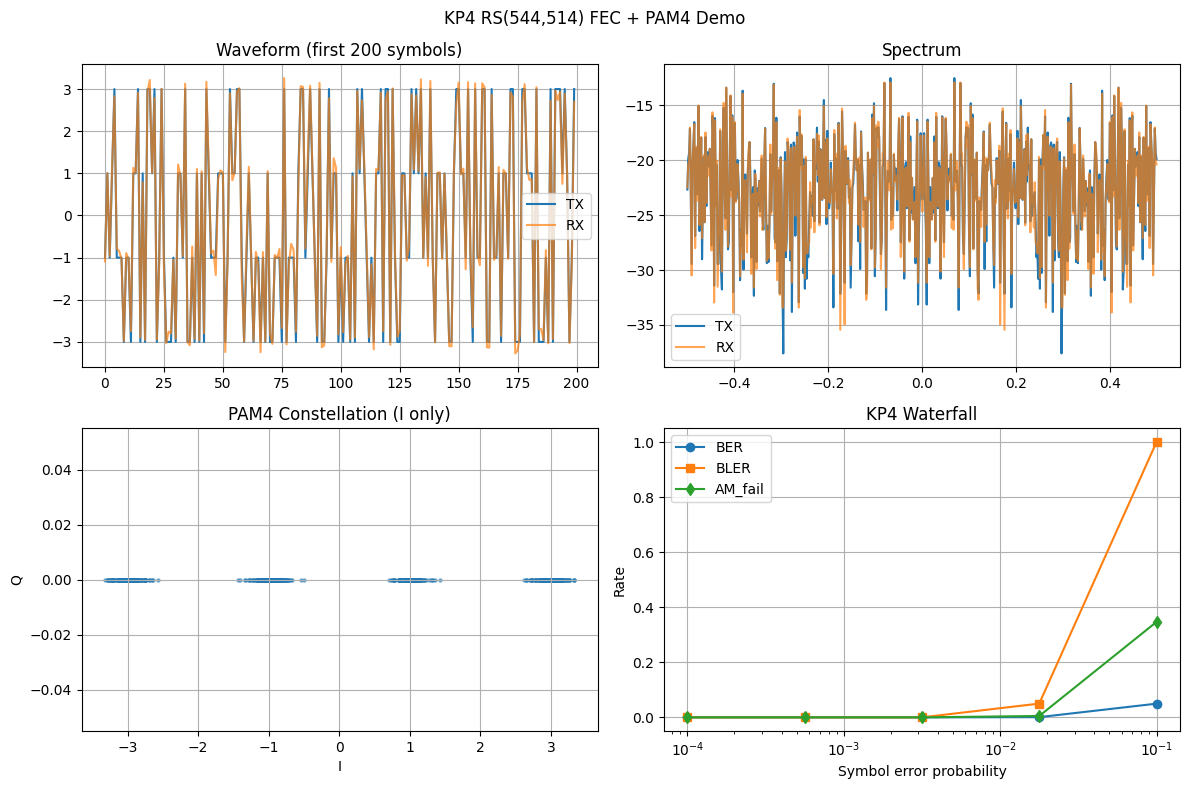

===BEGIN IMAGE===
iVBORw0KGgoAAAANSUhEUgAAA94AAALtCAYAAADe9LycAAAAOnRFWHRTb2Z0d2FyZQBNYXRwbG90bGliIHZlcnNpb24zLjEwLjgsIGh0dHBzOi8vbWF0cGxvdGxpYi5vcmcvwVt1zgAAAAlwSFlzAAAXEgAAFxIBZ5/SUgAAEapJREFUeJzt2bENgAAQAzFg/52fKa6IZA+Q/pT37u4BAAAAEl8zCwAAAAhvAAAAiHm8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAQHgDAADAJo83AAAAhIQ3AAAAhIQ3AAAAhIQ3AAAAhIQ3AA

<Figure size 640x480 with 0 Axes>

In [64]:
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1. KP4 RS(544,514) FEC over GF(2^10)
# ============================================================

class KP4RS544_514:
    """
    KP4 outer FEC: RS(544,514) over GF(2^10), t = 15 symbols.
    Implemented via reedsolo with built-in shortening.
    """

    def __init__(self):
        self.k = 514          # data symbols
        self.nsym = 30        # parity symbols
        self.c_exp = 10
        self.nsize = 2**self.c_exp - 1  # 1023
        self.n = self.k + self.nsym     # 544

        prim = find_prime_polys(c_exp=self.c_exp, fast_primes=True, single=True)
        init_tables(c_exp=self.c_exp, prim=prim)
        self.codec = RSCodec(self.nsym, nsize=self.nsize)

    def encode_block(self, data_symbols):
        data_symbols = np.asarray(data_symbols, dtype=int)
        if data_symbols.size != self.k:
            raise ValueError(f"Expected {self.k} data symbols, got {data_symbols.size}")
        code = self.codec.encode(list(data_symbols))
        code = np.array(code, dtype=int)
        if code.size != self.n:
            raise RuntimeError(f"Expected codeword length {self.n}, got {code.size}")
        return code

    def decode_block(self, recv_symbols):
        recv_symbols = np.asarray(recv_symbols, dtype=int)
        if recv_symbols.size != self.n:
            raise ValueError(f"Expected {self.n} symbols, got {recv_symbols.size}")
        try:
            out = self.codec.decode(list(recv_symbols))
            if isinstance(out, tuple):
                dec_msg = np.array(out[0], dtype=int)
            else:
                dec_msg = np.array(out, dtype=int)
            if dec_msg.size != self.k:
                dec_msg = dec_msg[:self.k]
            return dec_msg, None, True
        except rs.ReedSolomonError:
            return None, None, False


# ============================================================
# 2. Simple PAM4 mapper / demapper
# ============================================================

def bits_to_symbols_2b_gray(bits):
    bits = bits.reshape(-1, 2)
    b0 = bits[:, 0]
    b1 = bits[:, 1]
    # Gray mapping: 00->0, 01->1, 11->2, 10->3
    sym = np.zeros(len(b0), dtype=int)
    sym[(b0 == 0) & (b1 == 0)] = 0
    sym[(b0 == 0) & (b1 == 1)] = 1
    sym[(b0 == 1) & (b1 == 1)] = 2
    sym[(b0 == 1) & (b1 == 0)] = 3
    return sym

def symbols_to_bits_2b_gray(sym):
    sym = np.asarray(sym, dtype=int)
    b = np.zeros((len(sym), 2), dtype=int)
    b[sym == 0] = [0, 0]
    b[sym == 1] = [0, 1]
    b[sym == 2] = [1, 1]
    b[sym == 3] = [1, 0]
    return b.reshape(-1)

def pam4_levels(sym):
    # Map {0,1,2,3} -> {-3,-1,+1,+3}
    return 2*sym - 3

def pam4_hard_decision(y):
    # Simple slicer
    levels = np.array([-3, -1, 1, 3])
    idx = np.argmin(np.abs(y[:, None] - levels[None, :]), axis=1)
    return idx


# ============================================================
# 3. KP4 Simulator with IDLE+AM, error injection, AM checker
# ============================================================

class KP4Simulator:
    def __init__(self, fec, n_lanes=4, seed=1):
        self.fec = fec
        self.n_lanes = int(n_lanes)
        self.rng = np.random.default_rng(seed)

        # Simple AM pattern (10-bit symbols)
        self.am = np.array([0x155, 0x2AA, 0x155, 0x2AA], dtype=int)

        # For plotting
        self.last_pam4_tx_lane0 = None
        self.last_pam4_rx_lane0 = None

    def gen_data_block(self):
        # 10-bit symbols -> 514 symbols -> 5140 bits
        bits = np.random.randint(0, 2, size=self.fec.k * 10, dtype=int)
        data = np.zeros(self.fec.k, dtype=int)
        for i in range(self.fec.k):
            b = bits[10*i:10*(i+1)]
            val = 0
            for k in range(10):
                val |= (b[k] << (9-k))
            data[i] = val
        return data, bits

    def insert_am(self, data):
        data = data.copy()
        L = len(self.am)
        data[:L] = self.am
        return data

    def check_am_in_block(self, data_hat):
        L = len(self.am)
        if data_hat is None or data_hat.size < L:
            return False
        return np.all(data_hat[:L] == self.am)

    def tx_block(self):
        data_sym, data_bits = self.gen_data_block()
        data_sym_am = self.insert_am(data_sym)
    
        # Build bits for AM‑modified data (reference for BER/BLER)
        data_bits_am = []
        for s in data_sym_am:
            b = [(s >> (9-k)) & 1 for k in range(10)]
            data_bits_am.extend(b)
        data_bits_am = np.array(data_bits_am, dtype=int)
    
        cw = self.fec.encode_block(data_sym_am)
    
        # PAM4 TX (lane 0)
        bits = []
        for s in cw:
            b = [(s >> (9-k)) & 1 for k in range(10)]
            bits.extend(b[:2])
        bits = np.array(bits, dtype=int)
        pam4_sym = (bits.reshape(-1, 2)[:, 0] << 1) | bits.reshape(-1, 2)[:, 1]
        pam4_tx = 2*pam4_sym - 3
        self.last_pam4_tx_lane0 = pam4_tx.astype(float)
    
        # return AM‑modified symbols and bits
        return data_sym_am, data_bits_am, cw


    def inject_symbol_errors(self, cw, p_sym_err=0.0, burst_len=0, n_bursts=0):
        cw = cw.copy()
        n = len(cw)
        if p_sym_err > 0:
            mask = np.random.rand(n) < p_sym_err
            rand_err = np.random.randint(0, 2**10, size=n)
            cw[mask] ^= rand_err[mask]
        for _ in range(n_bursts):
            start = np.random.randint(0, max(1, n - burst_len))
            err = np.random.randint(0, 2**10, size=burst_len)
            cw[start:start+burst_len] ^= err
        return cw

    def rx_block(self, recv_cw):
        data_hat, n_err, ok = self.fec.decode_block(recv_cw)

        # PAM4 RX (lane 0)
        bits = []
        for s in recv_cw:
            b = [(s >> (9-k)) & 1 for k in range(10)]
            bits.extend(b[:2])
        bits = np.array(bits, dtype=int)
        pam4_sym = (bits.reshape(-1, 2)[:, 0] << 1) | bits.reshape(-1, 2)[:, 1]
        pam4_rx = 2 * pam4_sym - 3
        self.last_pam4_rx_lane0 = pam4_rx.astype(float)

        am_ok = False
        if ok and data_hat is not None:
            am_ok = self.check_am_in_block(data_hat)

        return data_hat, n_err, ok, am_ok

    def run_waterfall(self, p_sym_err_list, n_blocks=200):
        results = []
        for p in p_sym_err_list:
            bit_errors = 0
            bit_total = 0
            block_errors = 0
            am_fail = 0
            for _ in range(n_blocks):
                data_tx_sym, data_bits_ref, cw = self.tx_block()
                recv_cw = self.inject_symbol_errors(cw, p_sym_err=p)
                data_hat_sym, _, ok, am_ok = self.rx_block(recv_cw)
    
                if not ok or data_hat_sym is None:
                    block_errors += 1
                    am_fail += 1
                    bit_total += len(data_bits_ref)
                    bit_errors += len(data_bits_ref)
                    continue
    
                # Rebuild bits from decoded symbols
                bits_hat = []
                for s in data_hat_sym:
                    b = [(s >> (9-k)) & 1 for k in range(10)]
                    bits_hat.extend(b)
                bits_hat = np.array(bits_hat[:len(data_bits_ref)], dtype=int)
    
                errs = np.sum(bits_hat != data_bits_ref)
                bit_errors += errs
                bit_total += len(data_bits_ref)
                if errs > 0:
                    block_errors += 1
                if not am_ok:
                    am_fail += 1
    
            ber = bit_errors / bit_total if bit_total > 0 else 0.0
            bler = block_errors / n_blocks
            amf = am_fail / n_blocks
            print(f"p_sym={p: .2e} -> BER={ber:.3e}, BLER={bler:.3e}, AM_fail={amf:.3e}")
            results.append([p, ber, bler, amf])
        return np.array(results)
    
    
# ============================================================
# 4. Multi-graph: waveform, spectrum, constellation, waterfall
# ============================================================

def plot_kp4_results(pam4_tx, pam4_rx, wf, title="KP4 RS(544,514) FEC + PAM4 Demo"):
    fig, axs = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle(title)

    # Waveform
    axs[0, 0].plot(np.real(pam4_tx[:200]), label="TX")
    axs[0, 0].plot(np.real(pam4_rx[:200]), label="RX", alpha=0.7)
    axs[0, 0].set_title("Waveform (first 200 symbols)")
    axs[0, 0].legend()
    axs[0, 0].grid(True)

    # Spectrum
    N = len(pam4_tx)
    f = np.fft.fftfreq(N, d=1.0)
    S_tx = 20*np.log10(np.abs(np.fft.fft(pam4_tx))/N + 1e-12)
    S_rx = 20*np.log10(np.abs(np.fft.fft(pam4_rx))/N + 1e-12)
    axs[0, 1].plot(np.fft.fftshift(f), np.fft.fftshift(S_tx), label="TX")
    axs[0, 1].plot(np.fft.fftshift(f), np.fft.fftshift(S_rx), label="RX", alpha=0.7)
    axs[0, 1].set_title("Spectrum")
    axs[0, 1].legend()
    axs[0, 1].grid(True)

    # Constellation
    axs[1, 0].scatter(np.real(pam4_rx), np.zeros_like(pam4_rx), s=5, alpha=0.5)
    axs[1, 0].set_title("PAM4 Constellation (I only)")
    axs[1, 0].set_xlabel("I")
    axs[1, 0].set_ylabel("Q")
    axs[1, 0].grid(True)

    # Waterfall
    axs[1, 1].semilogx(wf[:, 0], wf[:, 1], "o-", label="BER")
    axs[1, 1].semilogx(wf[:, 0], wf[:, 2], "s-", label="BLER")
    axs[1, 1].semilogx(wf[:, 0], wf[:, 3], "d-", label="AM_fail")
    axs[1, 1].set_xlabel("Symbol error probability")
    axs[1, 1].set_ylabel("Rate")
    axs[1, 1].set_title("KP4 Waterfall")
    axs[1, 1].grid(True)
    axs[1, 1].legend()

    plt.tight_layout()
    plt.show()


# ============================================================
# 5. Demo run
# ============================================================

if __name__ == "__main__":
    fec = KP4RS544_514()
    sim = KP4Simulator(fec)

    # One TX/RX block for waveform/constellation demo
    data_sym, data_bits, cw = sim.tx_block()
    recv_cw = sim.inject_symbol_errors(cw, p_sym_err=1e-4)
    # Map to PAM4
    pam4_tx = pam4_levels((cw % 4).astype(int)).astype(float)
    pam4_tx_noisy = pam4_levels((recv_cw % 4).astype(int)).astype(float)
    # Add AWGN for demo
    snr_lin = 20.0
    noise = np.random.randn(len(pam4_tx_noisy)) / np.sqrt(2*snr_lin)
    pam4_rx = pam4_tx_noisy + noise
    # Hard decision back to symbols (not used for FEC here, just for plots)
    pam4_rx_sym = pam4_hard_decision(pam4_rx)

    # Waterfall
    p_list = np.logspace(-4, -1, 5)
    wf = sim.run_waterfall(p_list, n_blocks=600)
    print(wf)

    # Multi-graph
    plot_kp4_results(pam4_tx, pam4_rx, wf)
    import base64
    from io import BytesIO
    buf = BytesIO()
    plt.savefig(buf, format='png', dpi=150, bbox_inches='tight')
    buf.seek(0)
    img_b64 = base64.b64encode(buf.read()).decode('utf-8')
    print("===BEGIN IMAGE===")
    print(img_b64)
    print("===END IMAGE===")



## LMS FFE and DFE
Filter the channel outputs with a linear CTLE modelled with a zero at 𝜔z = 5 × 10(10) 𝑟𝑎𝑑/𝑠, two poles at 𝜔p = 1.7 × 10(11) 𝑟𝑎𝑑/𝑠 and a DC gain of 1.
Using the information from lecture 4 slide 6 on active CTLE design, suggest component values for a typical CTLE circuit that would have such poles and zeros. Assume the bias current is set so
that input transistors have gm = 25 millisiemens. Find the MMSE coefficients of a digital FFE with 2 pre-taps and 5 post-taps, and DFE with 2-taps to finish equalizing the CTLE output. Plot and
compare eye diagrams of the signal before CTLE, after CTLE, after FFE, and after DFE.

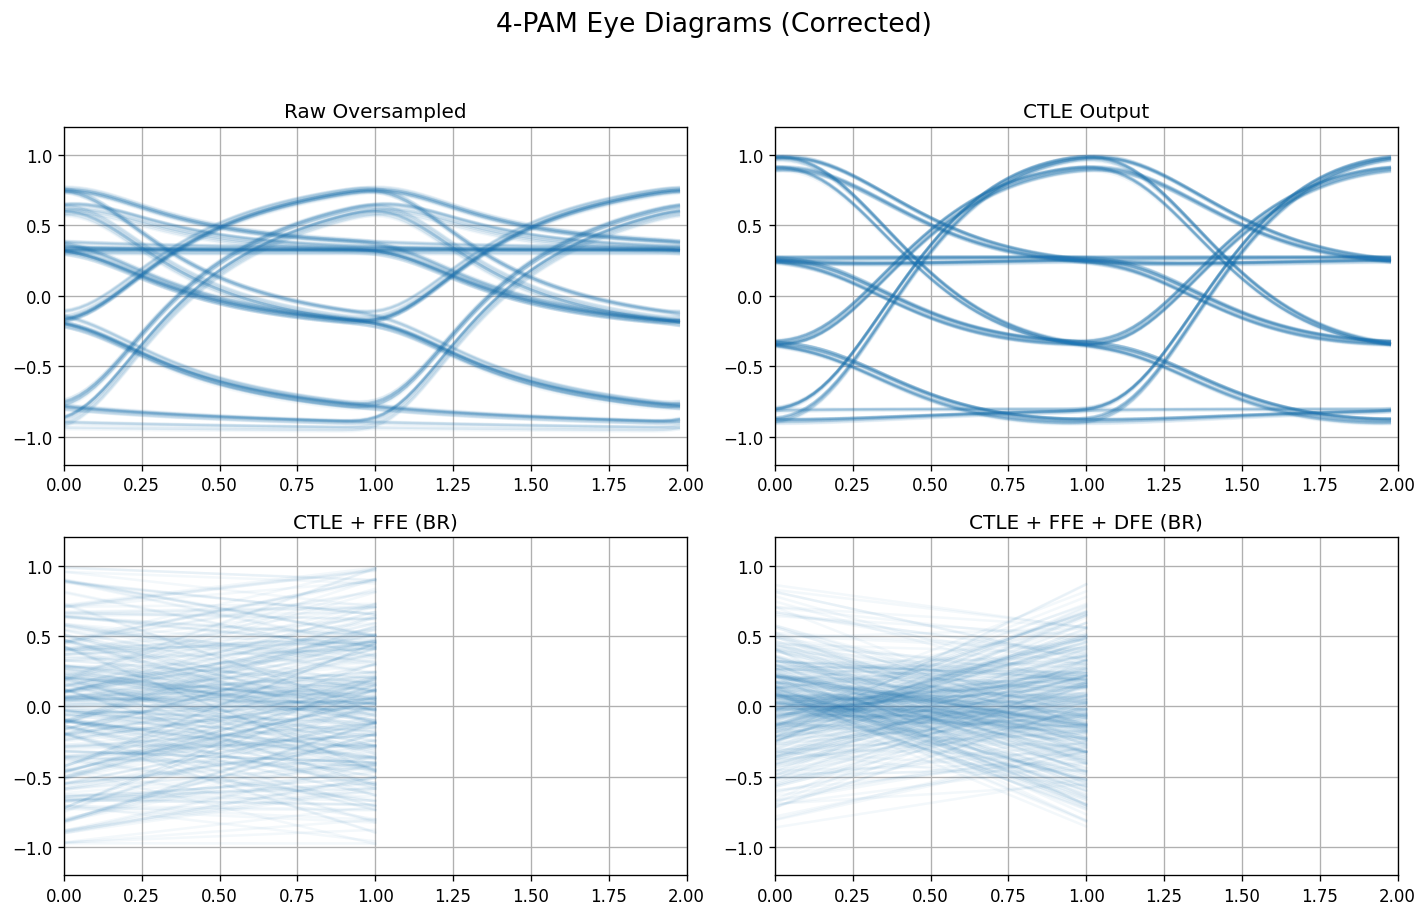

===BEGIN IMAGE===
iVBORw0KGgoAAAANSUhEUgAAA94AAALtCAYAAADe9LycAAAAOnRFWHRTb2Z0d2FyZQBNYXRwbG90bGliIHZlcnNpb24zLjEwLjgsIGh0dHBzOi8vbWF0cGxvdGxpYi5vcmcvwVt1zgAAAAlwSFlzAAAXEgAAFxIBZ5/SUgAAEapJREFUeJzt2bENgAAQAzFg/52fKa6IZA+Q/pT37u4BAAAAEl8zCwAAAAhvAAAAiHm8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAICS8AQAAQHgDAADAJo83AAAAhIQ3AAAAhIQ3AAAAhIQ3AAAAhIQ3AA

<Figure size 640x480 with 0 Axes>

In [82]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as sig

# ============================================================
# Load data
# ============================================================
f = np.load("./examples/example_channel/data/f.npy")          # Hz
h_pulse = np.load("./examples/example_channel/data/hpulse.npy")
signal = np.load("./examples/example_channel/data/signal_cap.npy")

samples_per_symbol = 40
data_rate = 100e9
UI = 1.0 / data_rate


# ============================================================
# Helpers
# ============================================================
def freq2impulse(Hf, f):
    df = f[1] - f[0]
    H_neg = np.conj(Hf[-2:0:-1])
    H_full = np.concatenate([Hf, H_neg])
    h = np.real(np.fft.ifft(H_full))
    fs = 2 * (f[-1] + df)
    dt = 1.0 / fs
    t = np.arange(len(h)) * dt
    return h, t


def eye_os(ax, x, sps, span_ui=2, start_ui=200, n_traces=400, title="Eye"):
    start = int(start_ui * sps)
    x = x[start:]

    m = np.max(np.abs(x))
    if m > 0:
        x = x / m

    seg_len = int(span_ui * sps)
    n_symbols = (len(x) - seg_len) // sps
    n_traces = min(n_traces, n_symbols)

    t_axis = np.arange(seg_len) / sps

    for k in range(n_traces):
        i = k * sps
        ax.plot(t_axis, x[i:i+seg_len], color="C0", alpha=0.05)

    ax.set_title(title)
    ax.grid(True)
    ax.set_xlim([0, span_ui])
    ax.set_ylim([-1.2, 1.2])


def eye_br(ax, x, span_ui=2, start_ui=200, n_traces=400, title="BR Eye"):
    x = x[start_ui:]

    m = np.max(np.abs(x))
    if m > 0:
        x = x / m

    seg_len = span_ui
    max_start = len(x) - seg_len - 1
    idxs = np.random.randint(0, max_start, size=n_traces)
    t_axis = np.arange(seg_len)

    for i in idxs:
        ax.plot(t_axis, x[i:i+seg_len], color="C0", alpha=0.05)

    ax.set_title(title)
    ax.grid(True)
    ax.set_xlim([0, span_ui])
    ax.set_ylim([-1.2, 1.2])


def prqs4(n):
    rng = np.random.default_rng(1234)
    return rng.integers(0, 4, size=n)


levels = np.array([-3, -1, 1, 3])


def pam4_input_BR(symbols):
    return levels[symbols]


def lms_ffe_dfe(x, mu, n_iter, w_ffe, w_dfe, levels, ref=None):
    n_ffe = len(w_ffe)
    n_dfe = len(w_dfe)

    x_buf = np.zeros(n_ffe)
    dfe_buf = np.zeros(n_dfe)

    y_dfe = np.zeros(n_iter)

    for n in range(n_iter):
        x_buf = np.roll(x_buf, 1)
        x_buf[0] = x[n]

        y_f = np.dot(w_ffe, x_buf)
        y_d = y_f - np.dot(w_dfe, dfe_buf)

        if ref is not None and n < len(ref):
            d = ref[n]
        else:
            d = levels[np.argmin(np.abs(y_d - levels))]

        e = d - y_d

        w_ffe += mu * e * x_buf
        w_dfe += mu * e * dfe_buf

        dfe_buf = np.roll(dfe_buf, 1)
        dfe_buf[0] = d

        y_dfe[n] = y_d

    return w_ffe, w_dfe, y_dfe


def apply_ffe_dfe(x, w_ffe, w_dfe, levels):
    n_ffe = len(w_ffe)
    n_dfe = len(w_dfe)

    x_buf = np.zeros(n_ffe)
    dfe_buf = np.zeros(n_dfe)

    y_out = np.zeros(len(x))

    for n in range(len(x)):
        x_buf = np.roll(x_buf, 1)
        x_buf[0] = x[n]

        y_f = np.dot(w_ffe, x_buf)
        y_d = y_f - np.dot(w_dfe, dfe_buf)

        d = levels[np.argmin(np.abs(y_d - levels))]
        y_out[n] = y_d

        dfe_buf = np.roll(dfe_buf, 1)
        dfe_buf[0] = d

    return y_out


# ============================================================
# CTLE design
# ============================================================
z = 5e10
p = 1.7e11
k = p**2 / z

_, H_ctle = sig.freqs(
    [k/p**2, k*z/p**2],
    [1/p**2, 2/p, 1],
    worN=2*np.pi*f
)

h_ctle, t_ctle = freq2impulse(H_ctle, f)
h_ctle = h_ctle[:200]


# ============================================================
# Apply CTLE to oversampled waveform
# ============================================================
signal_ctle = sig.fftconvolve(signal, h_ctle, mode="full")[:len(signal)]


# ============================================================
# CORRECT baud-rate channel extraction
# ============================================================
h_os = sig.fftconvolve(h_pulse, h_ctle, mode="full")
h_os = h_os[:len(h_pulse)]

main_os = np.argmax(np.abs(h_os))
h_os_aligned = h_os[main_os:]

h_br = h_os_aligned[::samples_per_symbol]
h_br = h_br / h_br[0]  # normalize
main_br = 0


# ============================================================
# Alignment
# ============================================================
delay_os = main_os
signal_os = signal[delay_os:]
signal_ctle_os = signal_ctle[delay_os:]


# ============================================================
# Baud-rate RX
# ============================================================
data = prqs4(20000)
signal_BR = pam4_input_BR(data)

signal_rx = sig.fftconvolve(h_br, signal_BR, mode="full")
signal_rx = signal_rx[:len(signal_BR)]
signal_rx_br = signal_rx  # already aligned


# ============================================================
# LMS FFE + DFE
# ============================================================
FFE = 7
DFE = 2

w_ffe = np.zeros(FFE)
w_dfe = np.zeros(DFE)

ref = signal_BR[:5000]
w_ffe, w_dfe, _ = lms_ffe_dfe(signal_rx_br[:5000], 0.001, 5000, w_ffe, w_dfe, levels, ref)

signal_eq_ffe = apply_ffe_dfe(signal_rx_br, w_ffe, np.zeros_like(w_dfe), levels)
signal_eq_ffe_dfe = apply_ffe_dfe(signal_rx_br, w_ffe, w_dfe, levels)


# ============================================================
# Unified multi-eye figure
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(12, 8), dpi=120)
fig.suptitle("4-PAM Eye Diagrams (Corrected)", fontsize=16)

eye_os(axes[0, 0], signal_os, samples_per_symbol, title="Raw Oversampled")
eye_os(axes[0, 1], signal_ctle_os, samples_per_symbol, title="CTLE Output")

eye_br(axes[1, 0], signal_eq_ffe, title="CTLE + FFE (BR)")
eye_br(axes[1, 1], signal_eq_ffe_dfe, title="CTLE + FFE + DFE (BR)")

fig.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()
import base64
from io import BytesIO
buf = BytesIO()
plt.savefig(buf, format='png', dpi=150, bbox_inches='tight')
buf.seek(0)
img_b64 = base64.b64encode(buf.read()).decode('utf-8')
print("===BEGIN IMAGE===")
print(img_b64)
print("===END IMAGE===")
